# WRDS Extraction and Bankruptcy Modelling Pipeline - Numbered Guide

This notebook builds a bankruptcy prediction dataset for U.S. publicly listed and later-delisted firms using:

- **Compustat North America Fundamentals Annual (FUNDA)**
- **CRSP-Compustat Merged link table (CCM)**
- **CRSP Monthly Stock File (MSF)**
- **CRSP Monthly Index File (MSI)** for market returns

The workflow is designed for a monthly prediction panel with:

- annual Compustat accounting data
- monthly CRSP market data
- delisting information retained
- lagged predictors
- time-based train / validation / test splits
- no-leakage winsorisation
- selective scaling
- class weighting for rare-event prediction

Outputs are saved as **CSV** files.


In [1]:
# Pipeline: Environment Setup

from __future__ import annotations

from pathlib import Path
from datetime import datetime
from typing import Iterable
from itertools import product
import os
import sys
import traceback
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
)
# WRDS is imported only inside get_wrds_connection() so local CSV mode works without WRDS installed.

from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter
from openpyxl import load_workbook

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# PROJECT ROOT - controls where every output goes.
#   Default: a "Final" folder next to wherever the notebook is run from.
#   Override on any machine by setting the BP_PROJECT_ROOT environment variable.
#     e.g. on my machine, set once in PowerShell:
#         setx BP_PROJECT_ROOT "C:\Users\Triguboff\Dev\Final"
#       then restart Jupyter.

PROJECT_ROOT = Path(os.environ.get("BP_PROJECT_ROOT", Path.cwd() / "Final"))

# Top-level output folders - all derived from PROJECT_ROOT
RESULTS_DIR                  = PROJECT_ROOT / "results"
FEATURE_IMPORTANCE_DIR       = RESULTS_DIR  / "feature_importance"
SHORT_INTEREST_EXTENSION_DIR = RESULTS_DIR  / "short_interest_extension"
IBES_RESULTS_DIR             = RESULTS_DIR  / "ibes"

# Create folders
for d in (
    PROJECT_ROOT,
    RESULTS_DIR,
    FEATURE_IMPORTANCE_DIR,
    SHORT_INTEREST_EXTENSION_DIR,
    IBES_RESULTS_DIR,
):
    d.mkdir(parents=True, exist_ok=True)


# Logistic regression for the refit-logit baselines; LightGBM as the strong
# tree-boosting benchmark; brier/calibration utilities for probability
# calibration diagnostics; log_loss for monitoring.
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
try:
    import lightgbm as lgb
    _HAS_LGB = True
except Exception as _e:
    _HAS_LGB = False
    print(f" lightgbm not available: {_e}. Step 46E will be skipped.")
#

# --- Integration imports (added for refit-logit, LightGBM, calibration) ----
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

# --- Hoisted imports (moved from individual cells) ---
from openpyxl.styles import PatternFill, Alignment, Font
from sklearn.metrics import roc_auc_score, average_precision_score
from docx import Document
from docx.shared import Pt, RGBColor
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Border, Side
from openpyxl.styles import Alignment as XlAlign
try:
    import lightgbm as lgb
    _HAS_LGB = True
except Exception as _e:
    _HAS_LGB = False
    print(f"[integration] lightgbm not available: {_e}. LightGBM rows will be skipped.")



In [2]:
# Pipeline: Helper Functions

def safe_divide(num, den):
    """
    Element-wise division that returns NaN where denominator is 0 or missing.
    Assumes aligned pandas Series.
    """
    num = pd.Series(num)
    den = pd.Series(den)
    return num.div(den).where(den != 0)

In [3]:
#Pipeline: Set All Seeds for Reproducibility
def set_all_seeds(seed: int = 42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

## Pipeline Step 1. Configuration

Set the sample period and output folders.

The files will be saved in a folder called `wrds_bankruptcy_data`
inside the directory where the notebook is running.


In [4]:
# CONFIG: DATES, PATHS, DIRECTORIES, FILE OUTPUTS

# ANALYSIS WINDOW

START_DATE = "1985-01-01"
END_DATE = "2025-12-31"

# BASE PROJECT DIRECTORY

# Anchored to PROJECT_ROOT defined in Step 01
DATA_DIR = PROJECT_ROOT / "wrds_bankruptcy_data"
RAW_DIR   = DATA_DIR / "raw" # raw WRDS extracts (overwrite each run)
FINAL_DIR = DATA_DIR / "final"  # cleaned / modelling datasets (overwrite each run)
LOG_DIR   = DATA_DIR / "logs" # timestamped logs / run notes

# Create folders if they do not exist
for folder in [DATA_DIR, RAW_DIR, FINAL_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# TIMESTAMP (USED FOR LOGS ONLY)

TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# STANDARD FILE PATHS (OVERWRITTEN EACH RUN)

FUNDA_FILE      = RAW_DIR / "funda.csv"
CCM_FILE        = RAW_DIR / "ccm_linktable.csv"
CRSP_FILE       = RAW_DIR / "crsp.csv"
MSI_FILE        = RAW_DIR / "msi.csv"

FUNDA_CCM_FILE  = FINAL_DIR / "funda_ccm.csv"
FINAL_FILE      = FINAL_DIR / "final_dataset.csv"
MODEL_FILE      = FINAL_DIR / "model_dataset.csv"

TRAIN_FILE      = FINAL_DIR / "train_dataset.csv"
VAL_FILE        = FINAL_DIR / "validation_dataset.csv"
TEST_FILE       = FINAL_DIR / "test_dataset.csv"

SPLIT_MD_FILE   = FINAL_DIR / "time_based_split.md"

# LOG FILE (TIMESTAMPED)

LOG_FILE = LOG_DIR / f"run_metadata_{TIMESTAMP}.txt"

# PRINT CONFIG SUMMARY

print("Project root:       ", PROJECT_ROOT)
print("Data directory:     ", DATA_DIR)
print("Raw data directory: ", RAW_DIR)
print("Final data directory:", FINAL_DIR)
print("Log directory:      ", LOG_DIR)
print("Timestamp:          ", TIMESTAMP)


Project root:        C:\Users\Triguboff\Dev\Final
Data directory:      C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data
Raw data directory:  C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\raw
Final data directory: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final
Log directory:       C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\logs
Timestamp:           2026-08-24_19-51-15


### Pipeline Step 2. Data Access and Reproducibility

This notebook supports two data access modes:

1. **Local CSV mode (default for submission):** loads a pre-extracted, financially engineered dataset (`wrds_bankruptcy_engineered.csv`) included with the submission. This file contains the full panel (`model_df`) after merging Compustat, CRSP, CCM and related datasets, together with all engineered features, missing value indicators, and the forward-looking bankruptcy target variable. This allows the notebook to run without WRDS credentials.

2. **WRDS mode:** connects to WRDS and rebuilds the dataset from Compustat, CRSP, CCM, CRSP MSI and delisting data. This is retained for transparency and full auditability of the data extraction and construction process.

The default is `USE_WRDS = False` because a marker may not have institutional WRDS access. If WRDS credentials are available, set `USE_WRDS = True` and run the extraction cells. Otherwise, the notebook skips WRDS extraction and loads the local engineered dataset before proceeding to the feature engineering, modelling and evaluation sections.

This design balances transparency with reproducibility: the WRDS query logic remains fully visible, while the submitted engineered dataset ensures that the complete analysis can be reproduced without external data access or proprietary credentials. 

In [ ]:
# Pipeline Step 2A. Data Access Configuration & Experiment Control
#
# All run-time flags live in this ONE cell.
# Do not re-assign these flags elsewhere in the notebook.
#
# SUBMISSION / GRADER DEFAULT:
#   USE_WRDS = False
#
# To perform a fresh live WRDS extraction:
#   1. Restart the kernel.
#   2. Change USE_WRDS to True.
#   3. Run Step 1, Step 2A and Step 2B.
#   4. Continue only if Step 2B reports CLEANUP VERIFIED.

USE_WRDS      = False
WRDS_USERNAME = "mtriguboff"


# ============================================================================
# Fresh-run cleanup
# ============================================================================
#
# WRDS mode rebuilds the data from source, so previously generated files are
# removed before any new extraction/model output is produced.
#
# Local mode NEVER performs this cleanup because it relies on the existing
# engineered CSV stored in FINAL_DIR.
#
# The _WRDS_CLEANUP_DONE guard prevents an accidental second execution of this
# cell in the same live kernel from deleting outputs that have just been
# generated. Restarting the kernel resets the guard and therefore initiates a
# genuinely fresh WRDS run.

if USE_WRDS and not globals().get("_WRDS_CLEANUP_DONE", False):

    import shutil

    print("=" * 70)
    print("WRDS MODE: FRESH-RUN INITIALISATION")
    print("=" * 70)

    _cleanup_targets = [
        RESULTS_DIR,                  # canonical model/results tree
        RAW_DIR,                      # previous WRDS raw extracts
        FINAL_DIR,                    # previous engineered/split datasets
        LOG_DIR,                      # previous logs
        PROJECT_ROOT / "validation",  # canonical validation artefacts
        Path.cwd() / "results",       # legacy relative-output location
        Path.cwd() / "validation",    # legacy relative-validation location
    ]

    # De-duplicate paths in case working-directory and project paths overlap.
    _seen_cleanup_paths = set()

    for _target in _cleanup_targets:

        _target = Path(_target)

        try:
            _key = str(_target.resolve())
        except Exception:
            _key = str(_target.absolute())

        if _key in _seen_cleanup_paths:
            continue

        _seen_cleanup_paths.add(_key)

        if _target.exists():

            if _target.is_dir():
                shutil.rmtree(_target)
                print(f"Deleted prior output directory: {_target}")

            else:
                _target.unlink()
                print(f"Deleted prior output file: {_target}")

    # Recreate the standard directory structure required by later cells.
    _required_folders = [
        RESULTS_DIR,
        FEATURE_IMPORTANCE_DIR,
        SHORT_INTEREST_EXTENSION_DIR,
        IBES_RESULTS_DIR,
        RAW_DIR,
        FINAL_DIR,
        LOG_DIR,
        PROJECT_ROOT / "validation",
    ]

    for _folder in _required_folders:
        Path(_folder).mkdir(parents=True, exist_ok=True)

    _WRDS_CLEANUP_DONE = True

    print()
    print("✓ USE_WRDS = True")
    print("✓ Previous generated output deleted")
    print("✓ Previous WRDS raw/intermediate data deleted")
    print("✓ Previous generated final datasets deleted")
    print("✓ Previous logs and validation outputs deleted")
    print("✓ Required output directories recreated")
    print()
    print("Step 2A cleanup complete.")
    print("Step 2B will independently verify that the cleanup succeeded.")


elif USE_WRDS and globals().get("_WRDS_CLEANUP_DONE", False):

    print("=" * 70)
    print("WRDS MODE")
    print("=" * 70)
    print("✓ USE_WRDS = True")
    print("✓ WRDS cleanup was already completed in this kernel")
    print("✓ Cleanup has NOT been repeated")
    print()
    print(
        "To begin another completely fresh WRDS run, "
        "restart the kernel and rerun from Step 1."
    )


else:

    print("=" * 70)
    print("LOCAL MODE — NO WRDS CONNECTION")
    print("=" * 70)
    print("✓ USE_WRDS = False")
    print("✓ WRDS connection will not be attempted")
    print("✓ WRDS cleanup has been skipped")
    print("✓ Existing local engineered data have been preserved")


# ============================================================================
# WRDS extension toggles
# ============================================================================

RUN_IBES_WRDS_EXTENSION       = True
RUN_SHORT_INTEREST_EXTENSION = True


# ============================================================================
# Model toggles
# ============================================================================

RUN_SVM = False
RUN_RF  = True
RUN_XGB = True
RUN_NN  = True

# Legacy alias used by some older notebook cells.
RUN_NEURAL_NETWORK = RUN_NN


# ============================================================================
# Local-data file aliases
# ============================================================================
#
# FINAL_DIR and MODEL_FILE are defined in the earlier configuration cell.
#
# ENGINEERED_FILE therefore resolves relative to BP_PROJECT_ROOT:
#
#   <BP_PROJECT_ROOT>/
#       wrds_bankruptcy_data/
#           final/
#               wrds_bankruptcy_engineered.csv
#
# There is deliberately NO hard-coded C:\Users\...\Final path here.

ENGINEERED_FILE       = FINAL_DIR / "wrds_bankruptcy_engineered.csv"
LOCAL_ENGINEERED_FILE = ENGINEERED_FILE
LOCAL_SUBMISSION_FILE = FINAL_DIR / "final_dataset.csv"


# ============================================================================
# WRDS connection helper
# ============================================================================

def get_wrds_connection():
    """
    Open a WRDS connection.

    This function should only be called by downstream cells when
    USE_WRDS = True.
    """

    if not USE_WRDS:
        raise RuntimeError(
            "A WRDS connection was requested while USE_WRDS=False. "
            "The notebook is currently configured for local-data mode."
        )

    try:
        import wrds

        if WRDS_USERNAME:
            return wrds.Connection(wrds_username=WRDS_USERNAME)

        return wrds.Connection()

    except Exception as e:
        print("WRDS connection failed.")
        print(f"Reason: {e}")
        raise


# ============================================================================
# Local engineered-dataset loader
# ============================================================================

def load_local_engineered_dataset():
    """
    Load the engineered modelling dataset when WRDS access is unavailable.

    Preferred input:
        wrds_bankruptcy_engineered.csv

    Supported fallback files:
        final_dataset.csv
        MODEL_FILE
        train_dataset.csv
        validation_dataset.csv
        test_dataset.csv
    """

    candidate_files = [
        LOCAL_ENGINEERED_FILE,
        LOCAL_SUBMISSION_FILE,
        MODEL_FILE,
        FINAL_DIR / "train_dataset.csv",
        FINAL_DIR / "validation_dataset.csv",
        FINAL_DIR / "test_dataset.csv",
    ]

    # Remove duplicate paths while preserving order.
    candidate_files = list(dict.fromkeys(Path(p) for p in candidate_files))

    for file_path in candidate_files:

        if file_path.exists():

            print(f"Loading local dataset: {file_path}")

            df = pd.read_csv(file_path)

            if "date" in df.columns:
                df["date"] = pd.to_datetime(
                    df["date"],
                    errors="coerce"
                )

            return df

    raise FileNotFoundError(
        "No supported local modelling dataset was found.\n\n"
        "Files checked:\n  "
        + "\n  ".join(str(p) for p in candidate_files)
        + "\n\n"
        "For the standard local/no-WRDS reproduction route, the expected "
        "file is:\n  "
        + str(ENGINEERED_FILE)
    )


# ============================================================================
# Configuration summary
# ============================================================================

print()
print("=" * 70)
print("STEP 2A CONFIGURATION SUMMARY")
print("=" * 70)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"FINAL_DIR    : {FINAL_DIR}")
print(f"USE_WRDS     : {USE_WRDS}")

if USE_WRDS:

    print("Mode         : WRDS extraction")
    print(f"WRDS username: {WRDS_USERNAME}")
    print("Generated engineered file will be written to:")
    print(f"  {ENGINEERED_FILE}")

else:

    print("Mode         : Local CSV / no-WRDS reproduction")
    print("Expected local engineered dataset:")
    print(f"  {ENGINEERED_FILE}")

    if ENGINEERED_FILE.exists():
        print("✓ Engineered dataset currently exists")
    else:
        print("⚠ Engineered dataset not found yet")
        print("  Step 2B will perform the formal local-data pre-flight check.")

print()
print(
    "Run flags:",
    f"IBES={RUN_IBES_WRDS_EXTENSION}",
    f"SI={RUN_SHORT_INTEREST_EXTENSION}",
    f"SVM={RUN_SVM}",
    f"RF={RUN_RF}",
    f"XGB={RUN_XGB}",
    f"NN={RUN_NN}",
)

print("=" * 70)
print("Run Pipeline Step 2B next.")
print("=" * 70)

In [6]:
# Pipeline Step 2B. Pre-run check
#
# Independent safeguard for the selected operating mode.
#
# USE_WRDS = True:
#   Step 2A should already have deleted prior generated output.
#   This cell independently verifies that stale generated files do not remain
#   before permitting a fresh WRDS extraction to proceed.
#
# USE_WRDS = False:
#   No WRDS connection is required.
#   Existing local data is preserved and the engineered local dataset is checked.

assert os.environ.get("BP_PROJECT_ROOT"), (
    "BP_PROJECT_ROOT env var not set. In PowerShell run:\n"
    '  setx BP_PROJECT_ROOT "C:\\Users\\Triguboff\\Dev\\Final"\n'
    "then close and reopen Jupyter / VS Code."
)

print("=" * 70)
print("PIPELINE PRE-FLIGHT CHECK")
print("=" * 70)

print(f"\nPROJECT_ROOT: {PROJECT_ROOT}")
assert PROJECT_ROOT.exists(), (
    f"PROJECT_ROOT does not exist on disk: {PROJECT_ROOT}"
)

# ------------------------------------------------------------
# 1. Confirm required directory structure exists
# ------------------------------------------------------------

print("\nChecking required directories:")

required_dirs = [
    RESULTS_DIR,
    FEATURE_IMPORTANCE_DIR,
    SHORT_INTEREST_EXTENSION_DIR,
    IBES_RESULTS_DIR,
    DATA_DIR,
    RAW_DIR,
    FINAL_DIR,
    LOG_DIR,
]

for d in required_dirs:
    assert d.exists(), f"Missing directory: {d}"
    print(f"  ✓ {d}")

# ------------------------------------------------------------
# 2. Mode-specific safeguards
# ------------------------------------------------------------

if USE_WRDS:

    print("\n" + "=" * 70)
    print("WRDS MODE — CLEAN-RUN VERIFICATION")
    print("=" * 70)

    print("✓ USE_WRDS = True")
    print("✓ Fresh WRDS extraction requested")

    # WRDS username must be supplied for a live extraction.
    assert WRDS_USERNAME and str(WRDS_USERNAME).strip(), (
        "USE_WRDS=True but WRDS_USERNAME has not been specified."
    )
    print(f"✓ WRDS username configured: {WRDS_USERNAME}")

    # --------------------------------------------------------
    # Independent verification of Step 2A cleanup.
    #
    # We inspect the locations that contain notebook-generated
    # results / validation artefacts and prior WRDS raw/final files.
    #
    # Directories themselves are expected to exist; generated files
    # inside them should not.
    # --------------------------------------------------------

    cleanup_check_dirs = [
        RESULTS_DIR,
        RAW_DIR,
        FINAL_DIR,
        LOG_DIR,
    ]

    # Include validation locations if they are defined / exist.
    if "VALIDATION_DIR" in globals():
        cleanup_check_dirs.append(Path(VALIDATION_DIR))

    # Legacy notebook cells may write relative to the current working
    # directory rather than PROJECT_ROOT.
    legacy_results_dir = Path.cwd() / "results"
    legacy_validation_dir = Path.cwd() / "validation"

    cleanup_check_dirs.extend([
        legacy_results_dir,
        legacy_validation_dir,
    ])

    # Remove duplicate paths while preserving order.
    seen = set()
    unique_cleanup_dirs = []
    for d in cleanup_check_dirs:
        d = Path(d)
        key = str(d.resolve()) if d.exists() else str(d.absolute())
        if key not in seen:
            seen.add(key)
            unique_cleanup_dirs.append(d)

    stale_files = []

    for d in unique_cleanup_dirs:
        if not d.exists():
            continue

        # Any file remaining in these generated-output locations is
        # considered stale at the start of a fresh WRDS run.
        for p in d.rglob("*"):
            if p.is_file():
                stale_files.append(p)

    if stale_files:
        stale_listing = "\n  ".join(str(p) for p in stale_files[:100])

        extra = ""
        if len(stale_files) > 100:
            extra = (
                f"\n  ... plus {len(stale_files) - 100} additional file(s)"
            )

        raise AssertionError(
            "\nWRDS PRE-FLIGHT FAILED\n\n"
            "Previous generated output remains after Step 2A cleanup:\n  "
            + stale_listing
            + extra
            + "\n\nFresh WRDS extraction has been STOPPED.\n"
            "Re-run Step 2A from a fresh/restarted kernel and resolve any "
            "undeleted files before continuing."
        )

    print("✓ Previous results output deleted")
    print("✓ Previous validation output deleted")
    print("✓ Previous WRDS raw/intermediate data deleted")
    print("✓ Previous generated final datasets deleted")
    print("✓ Previous log files deleted")
    print("✓ Required empty directory structure recreated")

    print("\n" + "=" * 70)
    print("CLEANUP VERIFIED")
    print("READY FOR FRESH WRDS EXTRACTION")
    print("=" * 70)

else:

    print("\n" + "=" * 70)
    print("LOCAL MODE — NO WRDS ACCESS REQUIRED")
    print("=" * 70)

    print("✓ USE_WRDS = False")
    print("✓ No WRDS connection will be attempted")
    print("✓ Existing local files have been preserved")

    # --------------------------------------------------------
    # Locate the feature-engineered local dataset.
    # Preferred file:
    #   wrds_bankruptcy_engineered.csv
    # --------------------------------------------------------

    candidate_files = [
        FINAL_DIR / "wrds_bankruptcy_engineered.csv",
        FINAL_DIR / "final_dataset.csv",
    ]

    # Include MODEL_FILE if defined elsewhere in the notebook.
    if "MODEL_FILE" in globals():
        try:
            candidate_files.append(Path(MODEL_FILE))
        except Exception:
            pass

    # Supported split-file fallback: require all three if used.
    split_files = [
        FINAL_DIR / "train_dataset.csv",
        FINAL_DIR / "validation_dataset.csv",
        FINAL_DIR / "test_dataset.csv",
    ]

    # Remove duplicate candidates while preserving order.
    candidate_files = list(dict.fromkeys(candidate_files))
    existing_files = [p for p in candidate_files if p.exists()]

    split_files_present = all(p.exists() for p in split_files)

    assert existing_files or split_files_present, (
        "USE_WRDS=False, but no supported local modelling dataset was found.\n\n"
        "Place the feature-engineered dataset in:\n"
        f"  {FINAL_DIR}\n\n"
        "Preferred filename:\n"
        "  wrds_bankruptcy_engineered.csv\n\n"
        "Alternative supported inputs:\n"
        "  final_dataset.csv\n"
        "  MODEL_FILE (if configured)\n"
        "  OR all three split files:\n"
        "    train_dataset.csv\n"
        "    validation_dataset.csv\n"
        "    test_dataset.csv\n\n"
        "IMPORTANT: Local mode does NOT require FUNDA_FILE, CCM_FILE "
        "or CRSP_FILE."
    )

    if existing_files:
        LOCAL_MODEL_FILE = existing_files[0]
        print("✓ Local engineered dataset found")
        print(f"✓ Dataset selected: {LOCAL_MODEL_FILE}")
    else:
        LOCAL_MODEL_FILE = None
        print("✓ Local train/validation/test split files found")
        for p in split_files:
            print(f"  ✓ {p}")

    print("✓ Raw FUNDA/CCM/CRSP extracts are NOT required")
    print("✓ Existing local dataset has NOT been deleted")

    print("\n" + "=" * 70)
    print("READY TO RUN USING LOCAL DATA")
    print("=" * 70)

print("\nPre-flight OK — safe to run the rest of the pipeline.")


PIPELINE PRE-FLIGHT CHECK

PROJECT_ROOT: C:\Users\Triguboff\Dev\Final

Checking required directories:
  ✓ C:\Users\Triguboff\Dev\Final\results
  ✓ C:\Users\Triguboff\Dev\Final\results\feature_importance
  ✓ C:\Users\Triguboff\Dev\Final\results\short_interest_extension
  ✓ C:\Users\Triguboff\Dev\Final\results\ibes
  ✓ C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data
  ✓ C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\raw
  ✓ C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final
  ✓ C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\logs

WRDS MODE — CLEAN-RUN VERIFICATION
✓ USE_WRDS = True
✓ Fresh WRDS extraction requested
✓ WRDS username configured: mtriguboff
✓ Previous results output deleted
✓ Previous validation output deleted
✓ Previous WRDS raw/intermediate data deleted
✓ Previous generated final datasets deleted
✓ Previous log files deleted
✓ Required empty directory structure recreated

CLEANUP VERIFIED
READY FOR FRESH WRDS EXTRACTION

Pre-flight OK — safe to run the rest of

## Pipeline Step 2C. Data Loading Function

This function handles data access by attempting to connect to WRDS when enabled, 
and otherwise loading the pre-extracted engineered dataset included with the submission. 
This ensures a single, consistent entry point for the dataset used throughout the pipeline.

In [7]:
def load_data():
    
    if USE_WRDS:
        try:
            print("Attempting WRDS connection...")
            import wrds
            db = wrds.Connection()
            
            df = db.raw_sql("""
            -- YOUR WRDS SQL QUERY
            """)
            
            db.close()
            print("WRDS download successful")
            return df
        
        except Exception as e:
            print("WRDS failed, falling back to local CSV...")
            print(f"Reason: {e}")
    
    print("Loading local engineered dataset...")
    return pd.read_csv(ENGINEERED_FILE)

## Pipeline Step 3. Optional WRDS Connection

This section runs only when `USE_WRDS = True`. In default local CSV mode, WRDS extraction cells are skipped so the notebook remains reproducible without credentials.

## Optional WRDS Connection

In [8]:
if USE_WRDS:
    print("Python path:", sys.executable)

    try:
        db.close()
        print("Closed existing WRDS connection.")
    except:
        pass

    try:
        db = get_wrds_connection()
        print("Connected to WRDS.")
    except Exception as e:
        print("WRDS connection failed:", e)

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Python path: c:\Users\Triguboff\Dev\.venv\Scripts\python.exe


Loading library list...
Done
Connected to WRDS.


## Pipeline Step 4. SQL Query Builders

These functions build the SQL needed for:

- Compustat FUNDA
- CCM link table
- CRSP monthly stock file
- CRSP monthly market index file


In [9]:
if USE_WRDS:
    # WRDS QUERY BUILDERS

    def build_funda_query(start_date: str, end_date: str) -> str:
        return f'''
            SELECT
                gvkey,
                datadate,
                fyear,
                fyr,
                conm,
                tic,
                cusip,
                cik,
                naicsh,
                at,
                lt,
                act,
                lct,
                ceq,
                re,
                ni,
                ebit,
                revt,
                xint,
                emp,
                dltt,
                dlc,
                che,
                oancf
            FROM comp.funda
            WHERE indfmt = 'INDL'
              AND datafmt = 'STD'
              AND consol = 'C'
              AND popsrc = 'D'
              AND datadate BETWEEN '{start_date}' AND '{end_date}'
            ORDER BY gvkey, datadate
        '''

    def build_ccm_query(gvkeys: list, start_date: str, end_date: str) -> str:
        valid_gvkeys = [str(g).strip() for g in gvkeys if pd.notna(g)]

        if not valid_gvkeys:
            raise ValueError("No valid gvkeys supplied to build_ccm_query().")

        gvkey_list = ",".join(f"'{g}'" for g in valid_gvkeys)

        return f"""
            SELECT
                gvkey,
                lpermno AS permno,
                lpermco AS permco,
                linktype,
                linkprim,
                linkdt,
                linkenddt
            FROM crsp.ccmxpf_linktable
            WHERE gvkey IN ({gvkey_list})
              AND linktype IN ('LU', 'LC')
              AND linkprim IN ('P', 'C')
              AND linkdt <= '{end_date}'
              AND (linkenddt >= '{start_date}' OR linkenddt IS NULL)
        """

    def build_crsp_query(permnos: list[int], start_date: str, end_date: str) -> str:
        valid_permnos = [str(int(p)) for p in permnos if pd.notna(p)]

        if not valid_permnos:
            raise ValueError("No valid permnos supplied to build_crsp_query().")

        permno_list = ",".join(valid_permnos)

        return f'''
           SELECT
                permno,
                permco,
                date,
                ret,
                retx,
                prc,
                shrout,
                hexcd,
                hsiccd
            FROM crsp.msf
            WHERE permno IN ({permno_list})
              AND date BETWEEN '{start_date}' AND '{end_date}'
            ORDER BY permno, date
        '''

    def build_msi_query(start_date: str, end_date: str) -> str:
        return f'''
            SELECT
                date,
                vwretd,
                ewretd
            FROM crsp.msi
            WHERE date BETWEEN '{start_date}' AND '{end_date}'
            ORDER BY date
        '''

    def chunk_list(values, size=500):
        for i in range(0, len(values), size):
            yield values[i:i + size]

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

### CRSP Delisting Data

CRSP delisting information is stored separately from the monthly stock file (crsp.msf) in the delisting table (crsp.msedelist). The delisting code (dlstcd) identifies corporate failure events. Following Shumway (2001) and Campbell, Hilscher & Szilagyi (2008), a firm is treated as having experienced a failure event if `dlstcd` falls in either **400-499** (liquidations) or **550-599** (distress, bankruptcy declaration, listing-requirement failure, insufficient capital/float; includes code 574 = bankruptcy declared). The CRSP definition is further augmented in Step 20.1 with Chapter 11/7 filings from the Mergent FISD bankruptcy database to capture filings that CRSP can miss.


In [10]:
if USE_WRDS:
    # CRSP DELISTING QUERY BUILDER

    def build_delist_query(permnos: list[int], start_date: str, end_date: str) -> str:
        """
        Build SQL query to retrieve CRSP delisting information.

        Purpose:
        --------
        CRSP monthly stock file (crsp.msf) does NOT contain delisting codes.
        Delisting events (including bankruptcy) are stored separately in:
            crsp.msedelist

        This function retrieves:
        - dlstcd : delisting code (key variable for event construction)
        - dlstdt : delisting date

        These are required to construct:
        - bankruptcy_event_574 (dlstcd == 574)
        - liquidation_400_499 (dlstcd in 400-499)

        Parameters:
        -----------
        permnos : list[int]
            List of CRSP permno identifiers for firms in the dataset

        start_date : str
            Start date for filtering delisting events (YYYY-MM-DD)

        end_date : str
            End date for filtering delisting events (YYYY-MM-DD)

        Returns:
        --------
        str
            SQL query string to be executed via WRDS connection
        """

        # CLEAN AND VALIDATE INPUT PERMNOS

        # Convert to integers and drop missing values
        valid_permnos = [str(int(p)) for p in permnos if pd.notna(p)]

        # Ensure we have valid identifiers
        if not valid_permnos:
            raise ValueError("No valid permnos supplied to build_delist_query().")

        # Convert list into SQL-compatible string: 10001,10002,...
        permno_list = ",".join(valid_permnos)

        # BUILD SQL QUERY

        # Note:
        # - dlstcd = CRSP delisting code
        # - dlstdt = delisting date
        # - We filter by permno and date range

        return f'''
            SELECT
                permno,
                dlstcd,
                dlstdt
            FROM crsp.msedelist
            WHERE permno IN ({permno_list})
              AND dlstdt BETWEEN '{start_date}' AND '{end_date}'
            ORDER BY permno, dlstdt
        '''

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Pipeline Step 5. FUNDA Cleaning Strategy


# 1. `clean_funda(df)`: structural and type cleaning

The first function is responsible for preparing the raw WRDS extract into a usable, internally consistent dataframe. Its role is not to make assumptions about the economic meaning of missing data, but to accomplish the following technical cleaning steps:

- converting `datadate` into a proper datetime format
- removing duplicate observations
- sorting the data by `gvkey` and `datadate`
- dropping records missing essential identifiers such as `gvkey` or `datadate`
- coercing numeric accounting fields into numeric types

`clean_funda(df)` makes the data computationally reliable, but it does not decide how missing accounting values should be interpreted.

# 2. `clean_funda_missing(df)`: economically informed missing-value treatment

The second function handles missing values. Missing values in Compustat may arise because a firm did not report a variable, because the field was not applicable, because disclosure requirements differed across firms or time, or because historical coverage is incomplete.

Missing values should not automatically be treated as zeros.

A blanket replacement such as `df.fillna(0)` would be inappropriate for accounting data because it changes the economic meaning of the variables. For example:

- missing `at` does not mean a firm had zero total assets
- missing `revt` does not mean the firm had zero revenue
- missing `ni` does not mean the firm broke even
- missing `act` or `lct` does not mean current assets or liabilities were zero

Replacing these with zero would introduce artificial values, distort ratios, and potentially bias any downstream bankruptcy model. It would also make financially weak firms look systematically different in ways driven by imputation rather than real reporting.

Some variables can be treated differently because a missing value can plausibly represent an economically zero quantity or a non-material item. For example:

- `xint` (interest expense)
- `dlc` (debt in current liabilities)
- `dltt` (long-term debt)
- `che` (cash and short-term investments)

For these variables, filling missing values with zero is arguably  more defensible than for core statement totals, because some firms genuinely may have no debt or no interest expense. Even here, the decision is deliberate and limited rather than global. With sufficient time, xint = 0 might not be a missing value if Total debt (dlc and dltt) =0


In [11]:
if USE_WRDS:
    def clean_funda(df: pd.DataFrame) -> pd.DataFrame:
        if df.empty:
            return df

        df = df.copy()
        df["datadate"] = pd.to_datetime(df["datadate"], errors="coerce")
        df = df.drop_duplicates()
        df = df.sort_values(["gvkey", "datadate"]).reset_index(drop=True)
        df = df[df["gvkey"].notna() & df["datadate"].notna()].copy()

        numeric_cols = [
            "at", "lt", "act", "lct", "ceq", "re", "ni", "ebit", "revt", "xint",
            "emp", "dltt", "dlc", "che", "oancf"
        ]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        return df

    def clean_ccm(df: pd.DataFrame) -> pd.DataFrame:
        if df.empty:
            return df

        df = df.copy()
        df["linkdt"] = pd.to_datetime(df["linkdt"], errors="coerce")
        df["linkenddt"] = pd.to_datetime(df["linkenddt"], errors="coerce")
        df["linkenddt"] = df["linkenddt"].fillna(pd.Timestamp("2099-12-31"))
        df = df[df["gvkey"].notna() & df["permno"].notna()].copy()

        if "linktype" in df.columns:
            df = df[df["linktype"].isin(["LU", "LC"])].copy()
        if "linkprim" in df.columns:
            df = df[df["linkprim"].isin(["P", "C"])].copy()

        df["gvkey"] = df["gvkey"].astype(str).str.strip()
        df["permno"] = pd.to_numeric(df["permno"], errors="coerce").astype("Int64")
        df["permco"] = pd.to_numeric(df["permco"], errors="coerce").astype("Int64")

        return df.drop_duplicates().sort_values(["gvkey", "permno", "linkdt"]).reset_index(drop=True)

    def clean_crsp(df: pd.DataFrame) -> pd.DataFrame:
        if df.empty:
            return df

        df = df.copy()
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

        numeric_cols = ["ret", "retx", "dlret", "prc", "shrout"]
        int_cols = ["permno", "permco", "hexcd", "hsiccd", "siccd", "dlstcd", "exchcd", "shrcd"]

        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        for col in int_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        df = df.drop_duplicates()
        df = df.sort_values(["permno", "date"]).reset_index(drop=True)
        df = df[df["permno"].notna() & df["date"].notna()].copy()

        return df

    def clean_msi(df: pd.DataFrame) -> pd.DataFrame:
        if df.empty:
            return df

        df = df.copy()
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["vwretd"] = pd.to_numeric(df["vwretd"], errors="coerce")
        df["ewretd"] = pd.to_numeric(df["ewretd"], errors="coerce")
        df = df.drop_duplicates().sort_values("date").reset_index(drop=True)
        return df

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [12]:
if USE_WRDS:
    def clean_funda_missing(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Critical anchor variable: drop rows without total assets
        df = df[df["at"].notna()].copy()

        # Preserve missingness before zero-filling economically plausible variables
        for col in ["xint", "dlc", "dltt", "che"]:
            if col in df.columns:
                df[f"missing_{col}"] = df[col].isna().astype("Int8")
                df[col] = df[col].fillna(0)

        # Keep track of informative missingness in core accounting variables
        # will later analyse, using 'oacnf' as example case study of informative missingness
        #  in bankruptcy prediction
        for col in ["act", "lct", "oancf", "re", "ebit", "revt", "ni", "emp"]:
            if col in df.columns:
                df[f"missing_{col}"] = df[col].isna().astype("Int8")

        return df
else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Pipeline Step 6. Extract Compustat FUNDA

This cell downloads annual Compustat accounting data for the sample period
and saves it as a CSV file.


In [13]:
if USE_WRDS:
    funda_query = build_funda_query(START_DATE, END_DATE)
    funda = db.raw_sql(funda_query, date_cols=["datadate"])
    funda = clean_funda(funda)

    funda.to_csv(FUNDA_FILE, index=False)

    print("FUNDA rows:", f"{len(funda):,}")
    print("Saved to:", FUNDA_FILE)
    funda.head()

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

FUNDA rows: 463,706
Saved to: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\raw\funda.csv


In [14]:
if USE_WRDS:
    def inspect_dataframe(df: pd.DataFrame, name: str):
        print(f"\n{'='*50}")
        print(f"DATASET: {name}")
        print(f"{'='*50}")
    
        # Shape
        print("\nShape:")
        print(f"Rows: {df.shape[0]:,}")
        print(f"Columns: {df.shape[1]}")
    
        # Columns
        print("\nColumns:")
        print(df.columns.tolist())
    
        # Missing values
        print("\nMissing values (count):")
        na_counts = df.isna().sum()
        print(na_counts[na_counts > 0].sort_values(ascending=False))
    
        # Missing values %
        print("\nMissing values (%):")
        na_pct = (df.isna().mean() * 100)
        print(na_pct[na_pct > 0].sort_values(ascending=False).round(2))
    
        # Basic info
        print("\nData types:")
        print(df.dtypes)
    

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Missing Values in Compustat FUNDA

The Compustat FUNDA dataset exhibits substantial missingness across several financial variables, with many fields missing in approximately 20-33% of observations.

### Observed Missingness

The most affected variables include:

- `act` (current assets): ~33%
- `lct` (current liabilities): ~32%
- `emp` (employees): ~33%
- `xint` (interest expense): ~30%
- `oancf` (operating cash flow): ~29%
- `re`, `ebit`, `revt`, `ni`: ~20-22%
- `dlc`(short term debt), `dltt`(long term debt): ~20%

This level of missingness reflects the nature of corporate financial reporting rather than data errors.


## Link Between Missing-Value Strategy and Model Selection

The chosen missing-value treatment strategy is aligned with the properties and requirements of the ML models used in this study. Different algorithms handle missing data in different ways.

Tree-Based Models (Random Forest and XGBoost) - Random Forest (Breiman, 2001) and XGBoost (Chen & Guestrin, 2016) are relatively robust to missing data:

- RF can tolerate missingness indirectly through surrogate splits and ensemble averaging  
- XGBoost can explicitly learn optimal default directions for missing values during tree construction  


# Neural Networks (TensorFlow / Deep Learning)

Neural networks require complete input data and are sensitive to the scale and distribution of features:

- missing values must be handled prior to training  
- improper imputation can introduce bias and degrade learning  

NN approaches may incorporate missingness indicators as additional inputs, allowing the model to learn patterns associated with missing data. This aligns with the strategy adopted in this study.


## Pipeline Step 7. Extract CCM Link Table

This cell downloads the CRSP-Compustat link table used to map
`gvkey` to `permno`.


In [15]:
# Pipeline Step 7A. Extract CCM Link Table

if USE_WRDS:
    db = get_wrds_connection()

    ccm = db.raw_sql("""
        SELECT gvkey, lpermno, linkdt, linkenddt
        FROM crsp.ccmxpf_linktable
    """)

    db.close()

else:
    print("Skipping CCM extraction (using local dataset)")

Loading library list...
Done


In [16]:
# Pipeline Step 7B. Extract CCM Link Table

if USE_WRDS:
    db = get_wrds_connection()

    try:
        # Build CCM only for gvkeys in FUNDA
        funda_gvkeys = sorted(
            pd.Series(funda["gvkey"])
            .dropna()
            .astype(int)
            .unique()
        )

        ccm_chunks = []

        # Smaller batches reduce WRDS server disconnect risk
        for i, batch in enumerate(chunk_list(funda_gvkeys, size=250), start=1):
            print(f"Downloading CCM batch {i} with {len(batch):,} gvkeys...")

            ccm_query = build_ccm_query(batch, START_DATE, END_DATE)

            try:
                chunk = db.raw_sql(ccm_query, date_cols=["linkdt", "linkenddt"])
                ccm_chunks.append(chunk)

            except Exception as e:
                print(f"Batch {i} failed: {e}")
                print("Resetting WRDS connection and retrying once...")

                try:
                    db.close()
                except Exception:
                    pass

                db = get_wrds_connection()

                chunk = db.raw_sql(ccm_query, date_cols=["linkdt", "linkenddt"])
                ccm_chunks.append(chunk)

        ccm = pd.concat(ccm_chunks, ignore_index=True)
        ccm = clean_ccm(ccm)

        ccm.to_csv(CCM_FILE, index=False)

        print("CCM rows:", f"{len(ccm):,}")
        print("Saved to:", CCM_FILE)

        display(ccm.head())

    finally:
        try:
            db.close()
        except Exception:
            pass

else:
    print("Skipping CCM extraction (local CSV mode).")

Loading library list...
Done
CCM rows: 5,732
Saved to: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\raw\ccm_linktable.csv


C:\Users\Triguboff\AppData\Local\Temp\ipykernel_25980\3948456113.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ccm = pd.concat(ccm_chunks, ignore_index=True)


,gvkey,permno,permco,linktype,linkprim,linkdt,linkenddt
0,100004,89402,43153,LC,P,2002-05-22,2007-05-18
1,100011,89457,43334,LC,P,2002-08-30,2005-07-22
2,100039,68823,3977,LU,P,1982-01-29,2006-10-31
3,100049,85335,32076,LU,P,1997-09-24,1999-11-30
4,100075,81030,30486,LC,P,1994-10-06,2018-09-28


## Pipeline Step 8. Build PERMNO List for CRSP Extraction

Only PERMNOs linked through CCM are pulled from CRSP.
This keeps the extraction focused on firms that can be merged to Compustat.


In [17]:
if USE_WRDS:
    permnos = (
        ccm["permno"]
        .dropna()
        .astype(int)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print("Unique PERMNOs:", f"{len(permnos):,}")

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Unique PERMNOs: 5,494


## Pipeline Step 9. Extract CRSP Monthly Data in Batches

The CRSP monthly stock file can be large, so extraction is done in batches.
This cell downloads:

- returns
- delisting returns
- delisting codes
- prices
- shares outstanding
- exchange codes


In [18]:
if USE_WRDS:
    def batched(iterable: Iterable[int], batch_size: int) -> Iterable[list[int]]:
        batch = []
        for item in iterable:
            batch.append(item)
            if len(batch) >= batch_size:
                yield batch
                batch = []
        if batch:
            yield batch

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [19]:
# Pipeline Step 9A. Extract CRSP Monthly Data

if USE_WRDS:
    db = get_wrds_connection()

    try:
        crsp_chunks = []

        for i, batch in enumerate(chunk_list(permnos, size=250), start=1):
            print(f"Downloading batch {i} with {len(batch):,} permnos...")

            query = build_crsp_query(batch, START_DATE, END_DATE)

            try:
                chunk = db.raw_sql(query, date_cols=["date"])
                crsp_chunks.append(chunk)

            except Exception as e:
                print(f"Batch {i} failed: {e}")
                print("Resetting WRDS connection and retrying once...")

                try:
                    db.close()
                except Exception:
                    pass

                db = get_wrds_connection()

                chunk = db.raw_sql(query, date_cols=["date"])
                crsp_chunks.append(chunk)

        crsp = pd.concat(crsp_chunks, ignore_index=True)
        crsp = clean_crsp(crsp)

        crsp.to_csv(CRSP_FILE, index=False)

        print("CRSP rows:", f"{len(crsp):,}")
        print("Saved to:", CRSP_FILE)

        display(crsp.head())

    finally:
        try:
            db.close()
        except Exception:
            pass

else:
    print("Skipping CRSP extraction (local CSV mode).")

Loading library list...
Done
CRSP rows: 636,081
Saved to: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\raw\crsp.csv


,permno,permco,date,ret,retx,prc,shrout,hexcd,hsiccd
0,10059,8006,1986-01-31,<NA>,<NA>,<NA>,<NA>,3,1040
1,10059,8006,1986-02-28,<NA>,<NA>,-28.875,3495.0,3,1040
2,10059,8006,1986-03-31,-0.082251,-0.082251,-26.5,3495.0,3,1040
3,10059,8006,1986-04-30,-0.080189,-0.080189,-24.375,3495.0,3,1040
4,10059,8006,1986-05-30,-0.143397,-0.205128,-19.375,3495.0,3,1040


In [20]:
if USE_WRDS:
    DEBUG = False

    if DEBUG:
        inspect_dataframe(crsp, "CRSP Monthly (raw)")

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [21]:
if USE_WRDS:
    # INSPECT CLEANED CRSP DATA

    print("==================================================")
    print("DATASET: CRSP Monthly (cleaned)")
    print("==================================================\n")

    print("Shape:")
    print(f"Rows: {len(crsp):,}")
    print(f"Columns: {len(crsp.columns)}\n")

    print("Missing values (count):")
    print(crsp.isna().sum()[crsp.isna().sum() > 0].sort_values(ascending=False))

    print("\nMissing values (%):")
    print((crsp.isna().mean() * 100)[crsp.isna().mean() > 0].sort_values(ascending=False).round(2))

    print("\nData types:")
    print(crsp.dtypes)

    print("\nSample rows:")
    display(crsp.head())

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

DATASET: CRSP Monthly (cleaned)

Shape:
Rows: 636,081
Columns: 9

Missing values (count):
ret       22770
retx      22770
prc       17186
shrout     5165
hsiccd      281
dtype: int64

Missing values (%):
ret       3.58
retx      3.58
prc       2.70
shrout    0.81
hsiccd    0.04
dtype: float64

Data types:
permno             Int64
permco             Int64
date      datetime64[ns]
ret              Float64
retx             Float64
prc              Float64
shrout           Float64
hexcd              Int64
hsiccd             Int64
dtype: object

Sample rows:


,permno,permco,date,ret,retx,prc,shrout,hexcd,hsiccd
0,10059,8006,1986-01-31,<NA>,<NA>,<NA>,<NA>,3,1040
1,10059,8006,1986-02-28,<NA>,<NA>,-28.875,3495.0,3,1040
2,10059,8006,1986-03-31,-0.082251,-0.082251,-26.5,3495.0,3,1040
3,10059,8006,1986-04-30,-0.080189,-0.080189,-24.375,3495.0,3,1040
4,10059,8006,1986-05-30,-0.143397,-0.205128,-19.375,3495.0,3,1040


## CRSP Data Cleaning and Validation

The CRSP monthly dataset was subjected to targeted cleaning to ensure that variables are economically meaningful and suitable for financial modelling.

### Key Cleaning Steps

- **Returns (`ret`, `retx`)**:  
  Missing values were replaced with zero, reflecting periods with no observed return (e.g., illiquidity or non-trading months).

- **Price (`prc`)**:  
  Absolute values were taken to correct for CRSP's bid-ask convention. Remaining missing values (~2.7%) correspond to illiquid or inactive trading periods and are retained.

- **Shares Outstanding (`shrout`)**:  
  Missing values were forward-filled within each firm (`permno`). Residual missing values (~0.8%) occur primarily at the start of firm histories and are retained.

- **Missing Indicators**:  
  A flag (`missing_prc`) was created to preserve information about missing price observations.


In [22]:
if USE_WRDS:
    def diagnostics_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
        summary = pd.DataFrame({
            "column": df.columns,
            "dtype": df.dtypes.astype(str),
            "missing_count": df.isna().sum(),
            "missing_pct": (df.isna().mean() * 100).round(2)
        })
    
        summary["dataset"] = name
        summary["n_rows"] = df.shape[0]
    
        return summary.sort_values("missing_pct", ascending=False)

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [23]:
if USE_WRDS:
    # Diagnostics save 

    # --- Create diagnostics directory
    DIAG_DIR = RESULTS_DIR / "diagnostics"
    DIAG_DIR.mkdir(parents=True, exist_ok=True)

    # --- Timestamp 

    # --- Generate diagnostics
    funda_diag = diagnostics_summary(funda, "FUNDA")
    ccm_diag = diagnostics_summary(ccm, "CCM")
    crsp_diag = diagnostics_summary(crsp, "CRSP")

    # --- Save individually
    funda_file = DIAG_DIR / f"funda_diagnostics.csv"
    ccm_file = DIAG_DIR / f"ccm_diagnostics.csv"
    crsp_file = DIAG_DIR / f"crsp_diagnostics.csv"

    funda_diag.to_csv(funda_file, index=False)
    ccm_diag.to_csv(ccm_file, index=False)
    crsp_diag.to_csv(crsp_file, index=False)

    # --- Save combined
    all_diag = pd.concat([funda_diag, ccm_diag, crsp_diag], ignore_index=True)
    all_file = DIAG_DIR / f"all_diagnostics.csv"
    all_diag.to_csv(all_file, index=False)

    print("Diagnostics saved:")
    print(f" - {funda_file}")
    print(f" - {ccm_file}")
    print(f" - {crsp_file}")
    print(f" - {all_file}")
else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Diagnostics saved:
 - C:\Users\Triguboff\Dev\Final\results\diagnostics\funda_diagnostics.csv
 - C:\Users\Triguboff\Dev\Final\results\diagnostics\ccm_diagnostics.csv
 - C:\Users\Triguboff\Dev\Final\results\diagnostics\crsp_diagnostics.csv
 - C:\Users\Triguboff\Dev\Final\results\diagnostics\all_diagnostics.csv


## Pipeline Step 10. Extract CRSP Monthly Market Index


In [24]:
if USE_WRDS:
    try:
        db.close()
    except:
        pass

    db = get_wrds_connection()
    print("WRDS connection reset.")

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Loading library list...
Done
WRDS connection reset.


In [25]:
# Pipeline Step 10A. Extract CRSP Market Index (MSI)

if USE_WRDS:
    db = get_wrds_connection()

    try:
        msi_query = build_msi_query(START_DATE, END_DATE)

        msi = db.raw_sql(msi_query, date_cols=["date"])
        msi = clean_msi(msi)

        msi.to_csv(MSI_FILE, index=False)

        print("MSI rows:", f"{len(msi):,}")
        print("Saved to:", MSI_FILE)

        display(msi.head())

    finally:
        try:
            db.close()
        except Exception:
            pass

else:
    print("Skipping MSI extraction (local CSV mode).")

Loading library list...
Done
MSI rows: 480
Saved to: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\raw\msi.csv


,date,vwretd,ewretd
0,1985-01-31,0.085719,0.121475
1,1985-02-28,0.016898,0.046034
2,1985-03-29,-0.001747,-0.003581
3,1985-04-30,-0.002187,-0.009652
4,1985-05-31,0.055774,0.022222


## Pipeline Step 11. Add Compustat-Side Accounting Variables

creates basic accounting ratios and debt measures for
bankruptcy prediction.


In [26]:
if USE_WRDS:
    def add_basic_compustat_variables(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Total debt
        df["total_debt"] = df[["dlc", "dltt"]].fillna(0).sum(axis=1)

        # Altman-style ratios
        df["x1_nwc_ta"] = (df["act"] - df["lct"]) / df["at"]
        df["x2_re_ta"] = df["re"] / df["at"]
        df["x3_ebit_ta"] = df["ebit"] / df["at"]
        df["x5_sales_ta"] = df["revt"] / df["at"]
        df["operating_margin"] = df["ebit"] / df["revt"]
        df["interest_coverage"] = df["ebit"] / df["xint"]

        return df

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Pipeline Step 12. Add CRSP-Side Market Variables

This cell creates:

- market equity
- total return including delisting return
- bankruptcy/distress flags based on delisting codes


In [27]:
# Shumway (2001) / Campbell-Hilscher-Szilagyi (2008) explicit 500-series codes
PERFORMANCE_DELIST_CODES = [550, 551, 552, 560, 561, 570, 572, 573, 574, 580, 581, 582, 583, 584, 585]

if USE_WRDS:
    def add_basic_crsp_variables(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # CRSP price may be negative due to bid/ask convention; use abs(prc)
        df["market_equity"] = df["prc"].abs() * df["shrout"]

        # Base return
        df["ret_filled"] = df["ret"].fillna(0)

        # Delisting return 
        if "dlret" in df.columns:
            df["dlret_filled"] = df["dlret"].fillna(0)
        else:
            df["dlret_filled"] = 0.0

        # Combined return
        df["total_return_including_delist"] = (
            (1 + df["ret_filled"]) * (1 + df["dlret_filled"]) - 1
        )

        # Event flags (only if dlstcd exists)
        # Shumway (2001)  definition: DLSTCD 400-499 OR 550-599
        if "dlstcd" in df.columns:
            df["bankruptcy_event_574"] = (df["dlstcd"] == 574).astype("Int64")
            df["liquidation_400_499"] = df["dlstcd"].between(400, 499, inclusive="both").astype("Int64")
            df["performance_delist_500s"] = df["dlstcd"].isin(PERFORMANCE_DELIST_CODES).astype("Int64")
        else:
            df["bankruptcy_event_574"] = 0
            df["liquidation_400_499"] = 0
            df["performance_delist_500s"] = 0

        return df

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Pipeline Step 13. Merge Compustat to CCM



In [28]:
if USE_WRDS:
    funda_ccm = funda.merge(ccm, on="gvkey", how="inner", validate="m:m")

    funda_ccm = funda_ccm[
        (funda_ccm["datadate"] >= funda_ccm["linkdt"]) &
        (funda_ccm["datadate"] <= funda_ccm["linkenddt"])
    ].copy()

    funda_ccm = funda_ccm.sort_values(
        ["gvkey", "datadate", "linkprim", "linktype", "linkdt"]
    ).drop_duplicates(subset=["gvkey", "datadate"], keep="first")

    funda_ccm = add_basic_compustat_variables(funda_ccm)

    print("FUNDA + CCM rows:", f"{len(funda_ccm):,}")
    funda_ccm.head()

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

FUNDA + CCM rows: 51,368


## Pipeline Step 14. Merge Monthly CRSP to the Latest Available Annual Compustat Record

For each monthly CRSP observation, this step attaches the most recent
available annual Compustat record for the same PERMNO. This creates the monthly panel used in a Shumway-style setup.

In [29]:
if USE_WRDS:
    funda_ccm["permno"] = funda_ccm["permno"].astype("Int64")
    crsp["permno"] = crsp["permno"].astype("Int64")

    funda_ccm = funda_ccm.sort_values(["permno", "datadate"]).reset_index(drop=True)
    crsp = crsp.sort_values(["permno", "date"]).reset_index(drop=True)

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [30]:
if USE_WRDS:
    result_frames = []

    common_permnos = sorted(
        set(crsp["permno"].dropna()) & set(funda_ccm["permno"].dropna())
    )

    print("Common PERMNOs:", f"{len(common_permnos):,}")

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Common PERMNOs: 5,393


In [31]:
if USE_WRDS:
    # OBJECTIVE:
    # Construct the final modelling dataset by merging:
    # - CRSP monthly stock data (market-based variables)
    # - Compustat fundamentals via CCM link (accounting variables)
    #
    # Key requirement:
    # Ensure NO look-ahead bias by aligning financial data using a
    # backward-looking time merge on the PUBLIC-AVAILABILITY DATE
    # of the fundamentals (datadate + 90 days), not on datadate itself.
    # Compustat 10-K filings have a reporting lag of ~90 days; matching
    # on raw datadate would attach FY-just-ended accounting variables to
    # firm-months BEFORE those filings were public, producing look-ahead
    # leakage. The 90-day lag is the SEC deadline for non-accelerated
    # filers and the conservative-safe choice across the panel.

    FILING_LAG = pd.Timedelta(days=90)

    result_frames = []  # Store merged firm-level DataFrames

    # LOOP THROUGH EACH COMMON FIRM IDENTIFIER (PERMNO)

    for i, permno in enumerate(common_permnos, start=1):

        # Print progress every 1,000 firms so long runs can be monitored
        if i % 1000 == 0:
            print(f"Processed {i:,} PERMNOs")

        # EXTRACT FIRM-SPECIFIC DATA FROM EACH SOURCE

        # CRSP monthly market data for this firm
        left = crsp.loc[crsp["permno"] == permno].copy()

        # Compustat accounting data already linked to CRSP via CCM
        right = funda_ccm.loc[funda_ccm["permno"] == permno].copy()

        # Public-availability date: the EARLIEST date on which the
        # accounting variables in this row could have been known to a
        # market participant. Used as the merge key in place of raw
        # datadate to enforce point-in-time integrity.
        right["datadate_public"] = right["datadate"] + FILING_LAG

        # SKIP FIRMS WITHOUT DATA ON EITHER SIDE

        if left.empty or right.empty:
            continue

        # TIME-ALIGNED MERGE

        # For each CRSP month, attach the most recent available
        # Compustat record whose datadate is on or before that month.
        # This prevents look-ahead bias.
        merged = pd.merge_asof(
            left.sort_values("date"),
            right.sort_values("datadate_public"),
            left_on="date",
            right_on="datadate_public",
            direction="backward",
        )

        # Store firm-level merged output
        result_frames.append(merged)

    # CONCATENATE ALL FIRM-LEVEL MERGES INTO A SINGLE DATAFRAME

    final_df = pd.concat(result_frames, ignore_index=True)

    # ADD BASIC CRSP-DERIVED VARIABLES

    # This helper typically creates market-based features such as
    # market capitalization and related return/price variables.
    final_df = add_basic_crsp_variables(final_df)

    # MERGE IN OFFICIAL CRSP MARKET INDEX RETURNS

    # vwretd = value-weighted market return
    # ewretd = equal-weighted market return
    final_df = final_df.merge(
        msi[["date", "vwretd", "ewretd"]],
        on="date",
        how="left"
    )

    # CLEAN DUPLICATE IDENTIFIER COLUMNS CREATED BY MERGES

    dup_cols = ["permno_x", "permno_y", "permco_x", "permco_y"]

    # Identify duplicate identifier columns that actually exist
    existing_dup_cols = [c for c in dup_cols if c in final_df.columns]
    num_dup_cols = len(existing_dup_cols)

    # Preserve one  PERMNO column
    if "permno_x" in final_df.columns:
        final_df["permno"] = final_df["permno_x"]
    elif "permno_y" in final_df.columns:
        final_df["permno"] = final_df["permno_y"]

    # Preserve one  PERMCO column
    if "permco_x" in final_df.columns:
        final_df["permco"] = final_df["permco_x"]
    elif "permco_y" in final_df.columns:
        final_df["permco"] = final_df["permco_y"]

    # Drop redundant identifier columns
    final_df = final_df.drop(columns=existing_dup_cols)

    # Report duplicate-column cleanup
    print(f"Duplicate identifier columns dropped: {num_dup_cols}")
    if num_dup_cols > 0:
        print("Dropped columns:", existing_dup_cols)

    # STANDARDISE CORE IDENTIFIER / CLASSIFICATION COLUMNS

    # Prefer point-in-time SIC from CRSP, then header SIC if needed.
    if "sic" not in final_df.columns:
        if "siccd" in final_df.columns:
            final_df["sic"] = final_df["siccd"]
        elif "hsiccd" in final_df.columns:
            final_df["sic"] = final_df["hsiccd"]

    # Keep a standard column name for downstream exports.
    if "naics" not in final_df.columns and "naicsh" in final_df.columns:
        final_df["naics"] = final_df["naicsh"]

    # FINAL SORTING AND INDEX RESET

    final_df = final_df.sort_values(["permno", "date"]).reset_index(drop=True)

    # OUTPUT SUMMARY / VALIDATION

    print("Final merged rows:", f"{len(final_df):,}")
    print("Final merged columns:", len(final_df.columns))

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Processed 1,000 PERMNOs
Processed 2,000 PERMNOs
Processed 3,000 PERMNOs
Processed 4,000 PERMNOs
Processed 5,000 PERMNOs
Duplicate identifier columns dropped: 4
Dropped columns: ['permno_x', 'permno_y', 'permco_x', 'permco_y']
Final merged rows: 634,836
Final merged columns: 56


### Handling Missing Accounting Data

CRSP provides monthly market data, whereas Compustat financial statements are reported at a lower frequency (typically annually or quarterly). Consequently, after merging the datasets using a backward-looking time alignment, many early monthly observations lack accounting information.

In particular, for the initial sample period (e.g., 1985), missing values arise because no prior financial statements exist to merge backward from. I expected this as a logical  outcome of the merge procedure rather than a data error, as the methodology deliberately avoids using future information.

To address missing values in subsequent periods, accounting variables are forward-filled within each firm (PERMNO), under the assumption that the most recent financial statement remains valid until the next reporting period. 

Shumway (2001) also integrates accounting and market variables in a discrete-time hazard model while explicitly avoiding look-ahead bias.


In [32]:
if USE_WRDS:
    # HANDLE MISSING ACCOUNTING DATA (FORWARD-FILL)

    # Accounting variables (e.g., total assets, liabilities) are
    # reported infrequently (annual/quarterly). After merging with
    # monthly CRSP data, many months have missing values.
    #
    # We forward-fill within each firm (permno), assuming the most
    # recent financial statement remains valid until updated.

    accounting_cols = ["lt", "at"]

    final_df[accounting_cols] = (
        final_df
        .groupby("permno")[accounting_cols]
        .ffill()
    )

    print("Remaining missing (after ffill):")
    print(final_df[accounting_cols].isna().mean())

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Remaining missing (after ffill):
lt    0.220774
at    0.220191
dtype: float64


In [33]:
if USE_WRDS:
    final_df = final_df.dropna(subset=["at"])

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [34]:
if USE_WRDS:
    print("Remaining missing (after ffill):")
    print(final_df[accounting_cols].isna().mean())

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Remaining missing (after ffill):
lt    0.000747
at    0.000000
dtype: float64


In [35]:
if USE_WRDS:
    try:
        delist_query = build_delist_query(common_permnos, START_DATE, END_DATE)
        delist = db.raw_sql(delist_query, date_cols=["dlstdt"])

    except Exception as e:
        print("WRDS query failed:", e)
        print("Reconnecting to WRDS and retrying once...")

        try:
            db.close()
        except Exception:
            pass

        db = get_wrds_connection()

        delist_query = build_delist_query(common_permnos, START_DATE, END_DATE)
        delist = db.raw_sql(delist_query, date_cols=["dlstdt"])

    print("Delist rows:", len(delist))
    display(delist.head())

WRDS query failed: This Connection is closed
Reconnecting to WRDS and retrying once...
Loading library list...
Done
Delist rows: 5393


,permno,dlstcd,dlstdt
0,10059,231,1994-04-15
1,10158,100,2024-12-31
2,10201,233,2021-05-14
3,10220,100,2024-12-31
4,10223,233,2014-03-27


In [36]:
if USE_WRDS:
    delist_query = build_delist_query(common_permnos, START_DATE, END_DATE)
    delist = db.raw_sql(delist_query, date_cols=["dlstdt"])

    print("Delist rows:", len(delist))
    delist.head()

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Delist rows: 5393


In [37]:
if USE_WRDS:
    # Convert to month-end to match CRSP monthly data
    delist["date"] = delist["dlstdt"]

    final_df = final_df.merge(
        delist[["permno", "date", "dlstcd"]],
        on=["permno", "date"],
        how="left"
    )
else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [38]:
if USE_WRDS:
    # MERGE DELIST DATA AND BUILD EVENT VARIABLES

    # OBJECTIVE:

    # Merge CRSP delisting data into the monthly firm-level panel
    # and construct event indicators for:
    # - bankruptcy (dlstcd == 574)
    # - distress delisting (dlstcd in 400-499)
    # - combined bankruptcy/distress event

    # CLEAN UP OLD EVENT COLUMNS FROM PRIOR RUNS

    event_cols_to_drop = [
        "bankruptcy_event_574",
        "liquidation_400_499",
        "performance_delist_500s",
        "distress_event_any",
        "wrds_bky_filing_event",
    ]

    existing_event_cols = [c for c in event_cols_to_drop if c in final_df.columns]
    if existing_event_cols:
        final_df = final_df.drop(columns=existing_event_cols)

    # PREPARE DELISTING DATA FOR MERGE

    # Use delisting date as the panel date key
    delist = delist.copy()
    delist["date"] = delist["dlstdt"]

    # Keep only required columns and remove duplicates
    delist_merge = (
        delist[["permno", "date", "dlstcd"]]
        .drop_duplicates(subset=["permno", "date"])
        .copy()
    )

    # MERGE DELISTING DATA INTO FINAL DATASET

    final_df = final_df.merge(
        delist_merge,
        on=["permno", "date"],
        how="left"
    )

    print("Delisting data merged into final_df.")

    # STANDARDISE TO A DLSTCD COLUMN

    # If multiple delstcd columns exist after reruns, combine them into one.
    dlstcd_candidates = [c for c in ["dlstcd", "dlstcd_x", "dlstcd_y"] if c in final_df.columns]

    if not dlstcd_candidates:
        raise KeyError("No delisting code column found after merge.")

    # Start with the first available candidate
    final_df["dlstcd"] = final_df[dlstcd_candidates[0]]

    # Fill missing values from any additional candidate columns
    for col in dlstcd_candidates[1:]:
        final_df["dlstcd"] = final_df["dlstcd"].fillna(final_df[col])

    # Drop redundant duplicate delisting columns
    cols_to_drop = [c for c in ["dlstcd_x", "dlstcd_y"] if c in final_df.columns]
    if cols_to_drop:
        final_df = final_df.drop(columns=cols_to_drop)

    # BUILD EVENT VARIABLES

    # Bankruptcy event: CRSP delisting code 574
    final_df["bankruptcy_event_574"] = (
        final_df["dlstcd"] == 574
    ).astype("Int64")

    # Distress event: CRSP delisting codes 400-499
    final_df["liquidation_400_499"] = (
        final_df["dlstcd"].between(400, 499)
    ).astype("Int64")

    # Combined event: bankruptcy OR distress
    final_df["distress_event_any"] = (
        (final_df["bankruptcy_event_574"] == 1) |
        (final_df["liquidation_400_499"] == 1)
    ).astype("Int64")

    print(final_df["distress_event_any"].value_counts(dropna=False))

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Delisting data merged into final_df.
distress_event_any
<NA>    493376
0         1657
1           18
Name: count, dtype: Int64


In [39]:
if USE_WRDS:
    # BUILD + VALIDATE DELIST EVENT FLAGS
    #
    # 1. Confirm delisting data (dlstcd) is present after merge
    # 2. Construct bankruptcy / distress event flags using the full
    #    CRSP performance-delist taxonomy (574 + 400s + 500-series)
    # 3. Validate event counts + yearly distribution; write to CSV

    VALIDATION_DIR = Path("validation")
    VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

    # PRESENCE CHECK
    if "dlstcd" not in final_df.columns:
        raise KeyError("dlstcd not found in final_df - delisting merge failed.")
    print("dlstcd present in final_df: True")

    # CONSTRUCT EVENT FLAGS
    # Performance-related 500-series delist codes (Shumway 2001;
    # Campbell-Hilscher-Szilagyi 2008): insufficient capital/price/float,
    # exchange suspension, delinquent filings, bankruptcy, delisted-for-cause.
    PERFORMANCE_DELIST_CODES = [
        550, 551, 552, 560, 561, 570, 572, 573, 574,
        580, 581, 582, 583, 584, 585,
    ]

    final_df["bankruptcy_event_574"]    = (final_df["dlstcd"] == 574).fillna(False).astype(int)
    final_df["liquidation_400_499"]     = final_df["dlstcd"].between(400, 499).fillna(False).astype(int)
    final_df["performance_delist_500s"] = final_df["dlstcd"].isin(PERFORMANCE_DELIST_CODES).fillna(False).astype(int)
    final_df["distress_event_any"]      = (
        final_df["liquidation_400_499"] | final_df["performance_delist_500s"]
    ).astype(int)

    # FLAG DISTRIBUTION TABLE
    flag_cols = [
        "bankruptcy_event_574",
        "liquidation_400_499",
        "performance_delist_500s",
        "distress_event_any",
    ]
    flag_summary = pd.DataFrame({
        "flag":     flag_cols,
        "n_events": [int(final_df[c].sum()) for c in flag_cols],
        "n_obs":    [int(final_df[c].count()) for c in flag_cols],
    })
    flag_summary["event_rate_bps"] = (
        10_000 * flag_summary["n_events"] / flag_summary["n_obs"]
    ).round(2)

    flag_summary_path = VALIDATION_DIR / "event_flag_summary.csv"
    flag_summary.to_csv(flag_summary_path, index=False)
    print(f"\nFlag summary written to {flag_summary_path}")
    print(flag_summary.to_string(index=False))

    # EVENT COUNTS BY YEAR
    event_by_year = (
        final_df.groupby(final_df["date"].dt.year)
                .agg(event_count=("distress_event_any", "sum"),
                     observations=("distress_event_any", "count"))
                .reset_index()
                .rename(columns={"date": "year"})
    )
    event_by_year["event_rate_bps"] = (
        10_000 * event_by_year["event_count"] / event_by_year["observations"]
    ).round(2)

    event_year_path = VALIDATION_DIR / "events_by_year.csv"
    event_by_year.to_csv(event_year_path, index=False)
    print(f"\nYearly event table written to {event_year_path} "
          f"({len(event_by_year)} years)")

    # UNIQUENESS - one event per permno
    dup_events = (
        final_df.groupby("permno")["distress_event_any"].sum().gt(1).sum()
    )
    if dup_events > 0:
        print(f"\nWARNING: {dup_events} permnos have >1 event row - "
              f"check that the panel terminates at the delist date.")
    else:
        print("\nUniqueness check passed: ≤1 event per permno ")

    # TOTAL EVENT SANITY CHECK
    total_events = int(final_df["distress_event_any"].sum())
    n_obs        = len(final_df)
    rate_bps     = 10_000 * total_events / n_obs

    if total_events == 0:
        raise ValueError("No events detected - pipeline is broken.")
    elif total_events < 100:
        print(f"\nWARNING: only {total_events} events across {n_obs:,} obs "
              f"({rate_bps:.1f} bps) - may be too few for a stable hazard model.")
    else:
        print(f"\nTotal events: {total_events:,} across {n_obs:,} obs "
              f"({rate_bps:.1f} bps) ")

else:
    print("Skipping WRDS validation cell (local CSV mode).")

dlstcd present in final_df: True

Flag summary written to validation\event_flag_summary.csv
                   flag  n_events  n_obs  event_rate_bps
   bankruptcy_event_574        12 495051            0.24
    liquidation_400_499         6 495051            0.12
performance_delist_500s        79 495051            1.60
     distress_event_any        85 495051            1.72

Yearly event table written to validation\events_by_year.csv (36 years)

Uniqueness check passed: ≤1 event per permno 



## Pipeline Step 15. Point-in-Time / Look-Ahead Integrity Audit

For every row in the merged firm-month panel, this audit verifies that the accounting variables attached to that row were already public knowledge on the prediction date. COMPUSTAT 10-K filings have a reporting lag of roughly 90 days in practice - the fiscal year 2007 10-K is typically not filed until late March 2008. Using FY2007 accounting variables to predict a March 2008 bankruptcy would be invalid because the underlying figures were not yet public on the prediction date. CRSP prices, in contrast, are real-time and require no lag adjustment.

 The audit reports the number of look-ahead violations (rows where `prediction_date - datadate < 90 days`) and saves a violation sample to `validation/lookahead_violations_sample.csv` for inspection. Dropping the violating rows is the safe response; the alternative is to investigate whether each violation is genuine look-ahead or a COMPUSTAT backfilling artefact.


In [40]:
if USE_WRDS:
    # POINT-IN-TIME / LOOK-AHEAD INTEGRITY AUDIT
    # Verify every Compustat-sourced row was public knowledge on the prediction date.
    FILING_LAG_DAYS = 90

    if "datadate" not in final_df.columns or "date" not in final_df.columns:
        raise KeyError("final_df is missing datadate or date - run merge cells first.")

    # Ensure both columns are datetime
    final_df["datadate"] = pd.to_datetime(final_df["datadate"], errors="coerce")
    final_df["date"]     = pd.to_datetime(final_df["date"], errors="coerce")

    # The earliest date on which the accounting variables were public.
    final_df["accounting_available_date"] = (
        final_df["datadate"] + pd.Timedelta(days=FILING_LAG_DAYS)
    )

    # A row is a look-ahead violation if accounting_available_date is AFTER
    # the prediction date (i.e. the 10-K had not been filed yet).
    violation_mask = (
        final_df["accounting_available_date"].notna()
        & final_df["date"].notna()
        & (final_df["accounting_available_date"] > final_df["date"])
    )
    n_violations = int(violation_mask.sum())
    n_total      = len(final_df)

    print(f"Look-ahead audit ({FILING_LAG_DAYS}-day Compustat filing lag):")
    print(f"  Total rows in panel:         {n_total:,}")
    print(f"  Rows violating point-in-time: {n_violations:,} "
          f"({100 * n_violations / max(n_total, 1):.2f}%)")

    if n_violations > 0:
        validation_dir = Path("validation")
        validation_dir.mkdir(parents=True, exist_ok=True)
        cols_to_save = ["permno", "date", "datadate", "accounting_available_date"]
        cols_present = [c for c in cols_to_save if c in final_df.columns]
        sample = final_df.loc[violation_mask, cols_present].head(500)
        sample_path = validation_dir / "lookahead_violations_sample.csv"
        sample.to_csv(sample_path, index=False)
        print(f"  Sample (first 500) saved to: {sample_path}")
        print("  Decide whether to drop these rows or investigate Compustat")
        print("  point-in-time backfill rules before proceeding to modelling.")
       
    else:
        print("  No point-in-time violations detected.")

else:
    print("Skipping look-ahead audit (local CSV mode).")


Look-ahead audit (90-day Compustat filing lag):
  Total rows in panel:         495,051
  Rows violating point-in-time: 0 (0.00%)
  No point-in-time violations detected.


## Pipeline Step 16. Delisting Code Analysis and Expanded Failure Definition

The CRSP delisting code (`dlstcd`) provides the basis for identifying firm exit events. Not all delistings correspond to financial distress; we must distinguish economically meaningful failure events from routine corporate exits (mergers, voluntary delistings).

### Expanded Failure Definition

Following the  academic definition adopted by Shumway (2001) and subsequent work (Campbell, Hilscher & Szilagyi 2008; Hillegeist et al. 2004; Tinoco & Wilson 2013), a firm is treated as having experienced a failure event if its CRSP delisting code falls in:

- **`dlstcd` in 400-499** -- liquidation events
- **`dlstcd` in 550-599** -- delistings for distress / failure-related reasons. Includes 552 (price below acceptable level), 560 (insufficient capital), 561 (insufficient float), 570 / 572-575 (liquidation, Chapter 11 filings, bankruptcy declared), 580 / 581 / 584 (failed exchange listing requirements), 587 / 591 (delisting registrations, listing-standard failures).

Code **574** (bankruptcy declared) is part of 550-599 and is tracked separately as a strict-bankruptcy proxy for sensitivity analysis. Codes 100-199 (active), 200-299 (M&A) and 300-399 (exchange changes) are not treated as failures.

This CRSP-based definition is **augmented in Step 20.1** with Chapter 11/7 filing events from the Mergent FISD bankruptcy database (`fisd.fisd_bankruptcy`). FISD covers bond-issuing firms and captures bankruptcies that CRSP misses -- particularly prepackaged Chapter 11 emergences and firms that continue trading post-petition. See the markdown preceding Step 20.1 for the full empirical contribution of FISD to this study.

The combined event flag `distress_event_any` equals 1 if **any** of the four indicators is positive:

- `bankruptcy_event_574` (CRSP DLSTCD == 574)
- `liquidation_400_499` (CRSP DLSTCD 400-499)
- `performance_delist_500s` (CRSP DLSTCD 550-599)
- `wrds_bky_filing_event` (FISD Chapter 11/7 filing in the same firm-month)


In [41]:
if USE_WRDS:
    #  HANDLE MISSING ACCOUNTING DATA (FORWARD-FILL)

    # OBJECTIVE:

    # Compustat accounting data (e.g., total assets, liabilities)
    # is reported at a lower frequency (annual / quarterly), while
    # CRSP market data is monthly.
    #
    # After merging, many monthly observations do not have
    # accounting values. These are NOT errors - they reflect
    # reporting frequency differences.
    #
    # To address this:
    # - We forward-fill accounting variables within each firm
    # - Assumes financial statements remain valid until updated (in my experience
    #   may not accord with reality but is a  practical approach)
    # - Only accounting variables are forward-filled
    # - Event variables (bankruptcy/distress) must NOT be filled

    # SELECT ACCOUNTING VARIABLES TO FORWARD-FILL

    accounting_cols = [
        "at",   # total assets
        "lt",   # total liabilities
        "ni",   # net income
        "re",   # retained earnings
        "dltt", # long-term debt
        "dlc"   # current debt
    ]

    # APPLY FORWARD-FILL WITHIN EACH FIRM (PERMNO)

    final_df[accounting_cols] = (
        final_df
        .sort_values(["permno", "date"])     # ensure correct time order
        .groupby("permno")[accounting_cols]  # group by firm
        .ffill()                             # forward-fill values
    )

    # VALIDATION

    print("Remaining missing values after forward-fill:")
    print(final_df[accounting_cols].isna().mean())

    print("\nNote: Remaining missing values correspond to early periods")
    print("where no prior financial statements existed (expected).")

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Remaining missing values after forward-fill:
at      0.000000
lt      0.000747
ni      0.001527
re      0.027522
dltt    0.001063
dlc     0.000432
dtype: float64

Note: Remaining missing values correspond to early periods
where no prior financial statements existed (expected).


In [42]:
if USE_WRDS:
    # FEATURE ENGINEERING (KEY FINANCIAL VARIABLES)

    # OBJECTIVE:

    # Construct key financial variables used in bankruptcy prediction.
    # - Market-based variables (market equity, relative size)
    # - Accounting ratios (leverage, profitability)

    # 1. MARKET EQUITY (SIZE MEASURE)

    # Market equity = price × shares outstanding
    # CRSP uses:
    # - prc (price, can be negative -> use abs)
    # - shrout (shares outstanding in thousands)

    final_df["market_equity"] = (
        final_df["prc"].abs() * final_df["shrout"]
    )

    # 2. MARKET VALUE OF ASSETS

    # Approximation:
    # market value of assets = market equity + total liabilities
    # This could be misleading if the firm has significant cas holdings
    # or if the company is very distressed ( with minimal maret equity but large debt),
    #  but it's a common approximation in the literature.
    final_df["market_value_assets"] = (
        final_df["market_equity"] + final_df["lt"]
    )

    # 3. LEVERAGE (TLTA = Total Liabilities / Total Assets)

    final_df["tlta"] = final_df["lt"] / final_df["at"]

    # 4. PROFITABILITY (NIMTA = Net Income / Market Value of Assets)

    final_df["nimta"] = final_df["ni"] / final_df["market_value_assets"]

    # 5. RELATIVE SIZE (RSIZE)

    # RSIZE = log(firm market equity / total market equity in month)

    # Compute total market equity per month
    final_df["total_market_equity_month"] = (
        final_df.groupby("date")["market_equity"].transform("sum")
    )

    # Compute RSIZE (avoid NA / division errors)
    valid_mask = (
        final_df["market_equity"].notna()
        & final_df["total_market_equity_month"].notna()
        & (final_df["market_equity"] > 0)
        & (final_df["total_market_equity_month"] > 0)
    )

    final_df["rsize"] = np.nan

    final_df.loc[valid_mask, "rsize"] = np.log(
        final_df.loc[valid_mask, "market_equity"] /
        final_df.loc[valid_mask, "total_market_equity_month"]
    )

    # VALIDATION

    print("Feature summary:")
    print(final_df[[
        "market_equity",
        "market_value_assets",
        "tlta",
        "nimta",
        "rsize"
    ]].describe())

    print("\nMissing values:")
    print(final_df[[
        "market_equity",
        "tlta",
        "nimta",
        "rsize"
    ]].isna().mean())

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Feature summary:
         market_equity  market_value_assets       tlta     nimta  \
count         486738.0             486371.0   494681.0  485617.0   
mean    3127660.247317        3137156.75114   0.543378 -0.000237   
std    24526664.462507      24543130.931606   0.443117  0.007254   
min             30.625              103.227        0.0  -0.90023   
25%        77226.01375           77928.1535   0.285397   -0.0001   
50%           314633.6           316610.644   0.520601   0.00002   
75%        1300936.905         1310883.0165    0.75481  0.000068   
max       3385742500.0         3385765250.0  37.050769  0.226602   

               rsize  
count  486738.000000  
mean       -9.271694  
std         2.057776  
min       -19.048421  
25%       -10.639480  
50%        -9.228758  
75%        -7.896802  
max         0.000000  

Missing values:
market_equity    0.016792
tlta             0.000747
nimta            0.019057
rsize            0.016792
dtype: float64


## Pipeline Step 17. Hazard Variable Construction

This section computes the core variables commonly associated with a
Shumway-style bankruptcy prediction setup:

- **TLTA** = Total Liabilities / Total Assets
- **NIMTA** = Net Income / Market Value of Assets
- **EXRET** = Excess return relative to the CRSP value-weighted market return
- **SIGMA** = Rolling volatility of returns
- **RSIZE** = Relative firm size


In [43]:
if USE_WRDS:
    final_df["tlta"] = final_df["lt"] / final_df["at"]

    final_df["market_value_assets"] = final_df["market_equity"] + final_df["lt"]
    final_df["nimta"] = final_df["ni"] / final_df["market_value_assets"]

    final_df[[
        "permno", "date", "lt", "at", "market_equity",
        "market_value_assets", "tlta", "nimta"
    ]].head()

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

In [44]:
if USE_WRDS:
    # for presentation, round to 4 decimal places
    display_df = final_df.copy()

    display_df = display_df.round({
        "lt": 2,
        "at": 2,
        "market_equity": 2,
        "market_value_assets": 2,
        "tlta": 4,
        "nimta": 6
    })

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Pipeline Step 18. EXRET

Excess return is computed relative to the **CRSP value-weighted market return**.

\[
EXRET = \log(1 + R_{firm}) - \log(1 + R_{market})
\]

Here:
- `R_firm` = monthly total return including delisting return
- `R_market` = CRSP value-weighted market return (`VWRETD`)


In [45]:
if USE_WRDS:

    final_df["firm_log_return"] = np.where(
        (1 + final_df["total_return_including_delist"]) > 0,
        np.log(1 + final_df["total_return_including_delist"]),
        np.nan
    )

    final_df["market_log_return"] = np.where(
        (1 + final_df["vwretd"]) > 0,
        np.log(1 + final_df["vwretd"]),
        np.nan
    )

    final_df["exret"] = final_df["firm_log_return"] - final_df["market_log_return"]

    final_df[[
        "permno", "date", "total_return_including_delist", "vwretd",
        "firm_log_return", "market_log_return", "exret"
    ]].head()

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Pipeline Step 19. SIGMA

SIGMA is a measure of return volatility. In this monthly panel, it is implemented
as the rolling standard deviation of monthly log returns over the previous 12 months.

This is a practical approximation in a monthly Shumway-style setting.


In [46]:
if USE_WRDS:
    final_df = final_df.sort_values(["permno", "date"]).reset_index(drop=True)

    final_df["sigma_12m"] = (
        final_df.groupby("permno")["firm_log_return"]
        .rolling(window=12, min_periods=6)
        .std()
        .reset_index(level=0, drop=True)
    )

    final_df[["permno", "date", "firm_log_return", "sigma_12m"]].head(20)

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

## Pipeline Step 20. RSIZE

RSIZE is the log of firm market equity relative to total market equity
in the same month:

This variable captures how large the firm is relative to the market.
Smaller firms often have higher distress risk.


In [47]:
if USE_WRDS:
    # COMPUTE RSIZE = log(firm market equity / total market equity)

    # Remove old versions if rerunning the notebook
    for col in ["total_market_equity_month", "rsize"]:
        if col in final_df.columns:
            final_df = final_df.drop(columns=[col])

    # CALCULATE TOTAL MARKET EQUITY FOR EACH MONTH

    # For each month, compute the cross-sectional sum of firm market
    # equity and assign that monthly total back to every row in that month.
    final_df["total_market_equity_month"] = (
        final_df.groupby("date")["market_equity"].transform("sum")
    )

    # CONSTRUCT RSIZE 

    # Only compute RSIZE where both firm market equity and total market
    # equity are present and strictly positive.
    valid_mask = (
        final_df["market_equity"].notna()
        & final_df["total_market_equity_month"].notna()
        & (final_df["market_equity"] > 0)
        & (final_df["total_market_equity_month"] > 0)
    )

    # Initialise RSIZE as missing
    final_df["rsize"] = np.nan

    # Compute:
    # RSIZE = log(firm market equity / total market equity in that month)
    final_df.loc[valid_mask, "rsize"] = np.log(
        final_df.loc[valid_mask, "market_equity"] /
        final_df.loc[valid_mask, "total_market_equity_month"]
    )

    # VALIDATION

    print("Missing proportions:")
    print(final_df[["market_equity", "total_market_equity_month", "rsize"]].isna().mean())

    print("\nSample rows:")
    final_df[["permno", "date", "market_equity", "total_market_equity_month", "rsize"]].head()

    print("Usable RSIZE observations: {:.2f}%".format(final_df["rsize"].notna().mean() * 100))
    print("Missing RSIZE observations: {:.2f}%".format(final_df["rsize"].isna().mean() * 100))

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Missing proportions:
market_equity                0.016792
total_market_equity_month    0.000000
rsize                        0.016792
dtype: float64

Sample rows:
Usable RSIZE observations: 98.32%
Missing RSIZE observations: 1.68%


The monthly cross-sectional market equity total was successfully computed for every month, and RSIZE is only missing where firm-level market equity is missing- here about 1.63%


## Pipeline Step 21. Bankruptcy Event Variable

Four event indicators are constructed from merged delisting + FISD data:

- `bankruptcy_event_574` -- strict CRSP bankruptcy proxy (DLSTCD == 574)
- `liquidation_400_499` -- liquidation events (DLSTCD 400-499)
- `performance_delist_500s` -- distress / listing-requirement failures (DLSTCD 550-599), per Shumway (2001)
- `wrds_bky_filing_event` -- Chapter 11/7 filing recorded by Mergent FISD in the same firm-month (Step 20.1)

A combined event indicator `distress_event_any` is set to 1 if **any** of the four conditions is satisfied (NA-safe OR via fillna(0) -- nullable Int64 propagates <NA> through standard OR). This is the variable used to construct the forward-looking 12-month modelling target.


In [48]:
# Shumway (2001) / Campbell-Hilscher-Szilagyi (2008) explicit 500-series codes
PERFORMANCE_DELIST_CODES = [550, 551, 552, 560, 561, 570, 572, 573, 574, 580, 581, 582, 583, 584, 585]

if USE_WRDS:
    # COMBINE BANKRUPTCY / DISTRESS EVENT FLAGS

    if "performance_delist_500s" not in final_df.columns:
        if "dlstcd" in final_df.columns:
            final_df["performance_delist_500s"] = (
                pd.to_numeric(final_df["dlstcd"], errors="coerce")
                  .isin(PERFORMANCE_DELIST_CODES)
            ).fillna(False).astype("Int64")
        else:
            final_df["performance_delist_500s"] = 0

    # NA-safe OR (nullable Int64 propagates <NA> through OR)
    def _safe_int_flag(col):
        return pd.to_numeric(final_df.get(col, 0), errors="coerce").fillna(0).astype(int)

    final_df["distress_event_any"] = (
        (_safe_int_flag("bankruptcy_event_574") == 1)
        | (_safe_int_flag("liquidation_400_499") == 1)
        | (_safe_int_flag("performance_delist_500s") == 1)
    ).astype(int)

    # RECOVER A  DLSTCD COLUMN IF IT WAS DUPLICATED IN A MERGE

    if "dlstcd" not in final_df.columns:
        if "dlstcd_x" in final_df.columns:
            final_df["dlstcd"] = final_df["dlstcd_x"]
        elif "dlstcd_y" in final_df.columns:
            final_df["dlstcd"] = final_df["dlstcd_y"]

    # DISPLAY ONLY COLUMNS THAT ACTUALLY EXIST

    cols_to_show = [
        "permno",
        "date",
        "dlstcd",
        "bankruptcy_event_574",
        "liquidation_400_499",
        "distress_event_any",
    ]

    existing_cols = [c for c in cols_to_show if c in final_df.columns]
    missing_cols = [c for c in cols_to_show if c not in final_df.columns]

    print("Existing columns shown:", existing_cols)
    if missing_cols:
        print("Missing columns:", missing_cols)

    final_df[existing_cols].head(20)

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Existing columns shown: ['permno', 'date', 'dlstcd', 'bankruptcy_event_574', 'liquidation_400_499', 'distress_event_any']


### Step 20.1: FISD Bankruptcy Database Augmentation

CRSP delisting codes capture firms whose stock exits the exchange because of bankruptcy or distress. CRSP misses bankruptcies in two important scenarios: (i) **prepackaged Chapter 11 restructurings** where the firm emerges quickly and the equity continues trading (CRSP often codes these under merger-style 200-series codes); and (ii) firms that **file Chapter 11 but continue trading post-petition** (CRSP may keep the firm active for months or years before assigning a delisting code, or never assign one). To address these gaps, the failure target is augmented with Chapter 11/7 filing events from the **Mergent Fixed Income Securities Database (FISD)**, specifically `fisd.fisd_bankruptcy`. FISD covers all U.S. firms that have ever issued public bonds, linked to Compustat/CRSP via 6-digit issuer CUSIP. FISD filings are classified as C11R (Chapter 11 Reorganisation), C11L (Chapter 11 Liquidation), C7 (Chapter 7), C15R / C15L (Chapter 15 cross-border).

Empirical contribution of FISD to this study's panel (1985-2025):
- FISD records **2,431** bankruptcy filings over the sample period.
- **82 filings** link to firms in the merged Compustat/CRSP panel (`final_df`) by 6-digit issuer CUSIP and firm-month date.
- **All 82** survive the size-decile filter of deleting the top 3 deciles applied in Step 22B. This surprising result is explained by the diminution of firm market capitalisaiton as they become troubled - although FISD covers bond-issuing firms (typically larger when healthy), distressed firms' market capitalisations collapse *before* filing, dropping them out of the top three deciles by the time the event occurs. The size filter therefore does not exclude these events from the modelling sample.
- **81 of the 82 FISD events (98.8%)** are not captured by CRSP delisting codes within ±12 months of the filing date. They are genuinely new distress observations rather than CRSP duplicates.
- Including FISD events approximately doubles the point-in-time distress event count and substantially improves the statistical power of upper-tail metrics (top-decile capture, top-1% precision).

The combined failure indicator `distress_event_any`  equals 1 if **any** of the four sources is positive: CRSP code 574, CRSP 400-499, CRSP 550-599, or FISD filing in the same firm-month. This four-way definition is consistent with the academic standard (Shumway 2001; Campbell, Hilscher & Szilagyi 2008) while drawing on a richer event source than CRSP delistings alone.


In [49]:
# Pipeline Step 21A. Augment Failure Target with Mergent FISD Bankruptcy Filings
#
# Augments the CRSP-based failure target with Chapter 11/7 filing events from
# the Mergent FISD bankruptcy database (fisd.fisd_bankruptcy). FISD covers
# bond-issuing firms, so captures bankruptcies that CRSP delisting codes can
# miss -- prepackaged Chapter 11 emergences, bankruptcies of firms that
# continue trading post-petition, and OTC-listed bankruptcies.

# Result: adds `wrds_bky_filing_event` (0/1) to final_df. Step 22A folds this
# into the modelling target via the failure_event aggregation.

if USE_WRDS:
    BRD_CACHE = RAW_DIR / "wrds_bankruptcy_events.csv"

    if BRD_CACHE.exists():
        print(f"Loading FISD bankruptcy events from cache: {BRD_CACHE}")
        fisd_bky = pd.read_csv(BRD_CACHE, parse_dates=["filing_date"])
    else:
        print("Downloading FISD bankruptcy events from WRDS...")
        if "db" not in globals():
            db = get_wrds_connection()

        # FISD bankruptcy filings (small table, very fast)
        bky_raw = db.raw_sql("""
            SELECT issuer_id, filing_date, filing_type
            FROM fisd.fisd_bankruptcy
            WHERE filing_date BETWEEN \'1985-01-01\' AND \'2025-12-31\'
        """, date_cols=["filing_date"])
        print(f"  Pulled {len(bky_raw):,} FISD filings")
        print(f"  Filing-type breakdown:")
        print(bky_raw["filing_type"].value_counts().to_string())

        # Issuer -> 6-digit CUSIP lookup
        issuer_lookup = db.raw_sql("""
            SELECT DISTINCT issuer_id, issuer_cusip, prospectus_issuer_name
            FROM fisd_common.issue_issuer
            WHERE issuer_cusip IS NOT NULL
        """)
        issuer_lookup = issuer_lookup.dropna(subset=["issuer_cusip"]).drop_duplicates("issuer_id")
        print(f"  Got {len(issuer_lookup):,} issuer records with CUSIPs")

        fisd_bky = bky_raw.merge(issuer_lookup, on="issuer_id", how="left")
        n_with_cusip = fisd_bky["issuer_cusip"].notna().sum()
        print(f"  Filings with linked CUSIP: {n_with_cusip:,}/{len(fisd_bky):,}")

        fisd_bky.to_csv(BRD_CACHE, index=False)
        print(f"  Saved cache: {BRD_CACHE}")

    # --- Merge into final_df by 6-digit issuer CUSIP + month ---
    if "final_df" not in globals():
        raise NameError("final_df not found -- run earlier extraction cells first.")

    # Idempotency: clean any stale helper / event columns from earlier runs
    for col in ["cusip6", "year_month", "wrds_bky_filing_event"]:
        if col in final_df.columns:
            final_df = final_df.drop(columns=[col])

    if not fisd_bky.empty and "issuer_cusip" in fisd_bky.columns:
        fisd_bky["cusip6"]     = fisd_bky["issuer_cusip"].astype(str).str.upper().str.strip()
        fisd_bky["year_month"] = pd.to_datetime(fisd_bky["filing_date"]).dt.to_period("M")

        if "cusip" not in final_df.columns:
            print("Warning: final_df missing 'cusip' -- cannot link FISD filings.")
            final_df["wrds_bky_filing_event"] = 0
        else:
            final_df["cusip6"]     = final_df["cusip"].astype(str).str[:6].str.upper().str.strip()
            final_df["year_month"] = pd.to_datetime(final_df["date"], errors="coerce").dt.to_period("M")

            bky_ind = (
                fisd_bky
                .dropna(subset=["cusip6", "year_month"])
                .drop_duplicates(["cusip6", "year_month"])
                .assign(wrds_bky_filing_event=1)
                [["cusip6", "year_month", "wrds_bky_filing_event"]]
            )
            final_df = final_df.merge(bky_ind, on=["cusip6", "year_month"], how="left")
            final_df["wrds_bky_filing_event"] = (
                final_df["wrds_bky_filing_event"].fillna(0).astype(int)
            )
            final_df = final_df.drop(columns=["cusip6", "year_month"])

            n_matched = int(final_df["wrds_bky_filing_event"].sum())
            print(f"\nMerged {n_matched:,} FISD bankruptcy events into final_df.")
    else:
        final_df["wrds_bky_filing_event"] = 0

    # NA-safe combined event flag
    def _safe_int_flag(col):
        return pd.to_numeric(final_df.get(col, 0), errors="coerce").fillna(0).astype(int)

    final_df["distress_event_any"] = (
        (_safe_int_flag("bankruptcy_event_574")    == 1)
        | (_safe_int_flag("liquidation_400_499") == 1)
        | (_safe_int_flag("performance_delist_500s") == 1)
        | (_safe_int_flag("wrds_bky_filing_event")   == 1)
    ).astype(int)

    print("\nUpdated combined event counts:")
    print(final_df["distress_event_any"].value_counts(dropna=False))
    print("\nBy source:")
    for col in ["bankruptcy_event_574", "liquidation_400_499",
                "performance_delist_500s", "wrds_bky_filing_event"]:
        if col in final_df.columns:
            print(f"  {col}: {int(_safe_int_flag(col).sum()):,}")
else:
    print("USE_WRDS=False -- skipping FISD bankruptcy database extraction.")
    if "final_df" in globals():
        final_df["wrds_bky_filing_event"] = 0


  Pulled 2,438 FISD filings
  Filing-type breakdown:
filing_type
C11R    2021
C11L     212
C7       114
C15R      76
C15L       9
  Got 17,417 issuer records with CUSIPs
  Filings with linked CUSIP: 2,438/2,438
  Saved cache: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\raw\wrds_bankruptcy_events.csv

Merged 82 FISD bankruptcy events into final_df.

Updated combined event counts:
distress_event_any
0    494885
1       166
Name: count, dtype: int64

By source:
  bankruptcy_event_574: 12
  liquidation_400_499: 6
  performance_delist_500s: 79
  wrds_bky_filing_event: 82


In [50]:
if USE_WRDS:
    # preview of the combined event flag using only columns that exist.
    cols_to_show = [
        "permno",
        "date",
        "dlstcd",
        "bankruptcy_event_574",
        "liquidation_400_499",
        "distress_event_any",
    ]
    existing_cols = [c for c in cols_to_show if c in final_df.columns]
    print("Existing columns shown:", existing_cols)
    final_df[existing_cols].head(20)

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

Existing columns shown: ['permno', 'date', 'dlstcd', 'bankruptcy_event_574', 'liquidation_400_499', 'distress_event_any']


## Pipeline Step 22. Industry Classification (SIC-Based)


In [51]:
if USE_WRDS:
    # STANDARDISE SIC COLUMN FOR INDUSTRY GROUPING

    if "sic" not in final_df.columns:
        if "siccd" in final_df.columns:
            final_df["sic"] = final_df["siccd"]
        elif "hsiccd" in final_df.columns:
            final_df["sic"] = final_df["hsiccd"]

    if "sic" in final_df.columns:
        final_df["sic"] = pd.to_numeric(final_df["sic"], errors="coerce").astype("Int64")
        print("SIC column standardised from available CRSP SIC fields.")
    else:
        print("Warning: no SIC-style column found in final_df.")

else:
    print("Skipping WRDS extraction cell (local CSV mode).")

SIC column standardised from available CRSP SIC fields.


## Pipeline Step 22A. Select Modelling Dataset

If WRDS mode has been used, `model_df` is created from the freshly merged WRDS panel. If local mode is used, `model_df` is loaded from the submitted engineered CSV file. Downstream feature engineering and modelling therefore use the same object name regardless of the data access route.

In [52]:
# Pipeline Step 22A.1. Select Modelling Dataset

if USE_WRDS:
    if "final_df" not in globals():
        raise KeyError("final_df not found. Run the WRDS extraction and merge cells first.")
    model_df = final_df.copy()
    print("model_df created from WRDS-built final_df:", model_df.shape)
else:
    model_df = load_local_engineered_dataset()
    print("model_df loaded from local CSV:", model_df.shape)

# Standardise date after either route
if "date" in model_df.columns:
    model_df["date"] = pd.to_datetime(model_df["date"], errors="coerce")

model_df.head()

model_df created from WRDS-built final_df: (495051, 69)


,date,ret,retx,prc,shrout,hexcd,hsiccd,gvkey,datadate,fyear,...,market_value_assets,tlta,nimta,firm_log_return,market_log_return,exret,sigma_12m,total_market_equity_month,rsize,wrds_bky_filing_event
0,2011-03-31,-0.019418,-0.019418,14.14,23294.0,1,1731,185128,2010-12-31,2010,...,329764.559,0.665119,0.000087,-0.019609,0.003335,-0.022944,NaN,3741790688.5285,-9.337871,0
1,2011-04-29,0.139321,0.139321,16.11,23294.0,1,1731,185128,2010-12-31,2010,...,375653.739,0.665119,0.000076,0.130432,0.028196,0.102237,NaN,3803523380.65045,-9.223802,0
2,2011-05-31,-0.092489,-0.092489,14.62,24159.0,1,1731,185128,2010-12-31,2010,...,353591.979,0.665119,0.000081,-0.097050,-0.015061,-0.081989,NaN,3723767874.13109,-9.263199,0
3,2011-06-30,-0.030096,-0.030096,14.18,24159.0,1,1731,185128,2010-12-31,2010,...,342962.019,0.665119,0.000084,-0.030558,-0.018619,-0.011939,NaN,3640963233.35025,-9.271269,0
4,2011-07-29,-0.050776,-0.050776,13.46,24159.0,1,1731,185128,2010-12-31,2010,...,325567.539,0.665119,0.000088,-0.052110,-0.022792,-0.029319,NaN,3569883159.24099,-9.303664,0


In [53]:
# CLASSIFY FIRMS INTO FIVE BROAD INDUSTRY GROUPS USING SIC
if "final_df" not in globals():
    final_df = load_local_engineered_dataset()
    print(f"Loaded final_df from cache: {len(final_df):,} rows")
    
def classify_industry(sic):
    """
    Classify firms into five broad industry groups using SIC codes.

    Groups:
    1. Finance (6000-6799)
    2. Transportation and Utilities (4000-4999)
    3. Manufacturing and Mining (1000-3999)
    4. Technology (selected SIC ranges; checked FIRST)
    5. Miscellaneous (all remaining firms)

    Technology is assigned first because several technology SIC
    codes overlap with broader manufacturing ranges.
    """
    if pd.isna(sic):
        return "Miscellaneous"

    try:
        sic = int(float(sic))
    except (ValueError, TypeError):
        return "Miscellaneous"

    # Technology FIRST because of overlap with broader SIC bands
    if (
        3570 <= sic <= 3579 or
        3660 <= sic <= 3692 or
        3694 <= sic <= 3699 or
        3810 <= sic <= 3829 or
        7370 <= sic <= 7379
    ):
        return "Technology"

    if 6000 <= sic <= 6799:
        return "Finance"

    if 4000 <= sic <= 4999:
        return "Transportation and Utilities"

    if 1000 <= sic <= 3999:
        return "Manufacturing and Mining"

    return "Miscellaneous"

model_df = final_df.copy()

if "sic" not in model_df.columns:
    raise KeyError(
        "Column 'sic' not found. Re-run the CRSP extraction and final merge cells so SIC can be standardised from siccd or hsiccd."
    )

model_df["industry_group"] = model_df["sic"].apply(classify_industry)

print(model_df["industry_group"].value_counts(dropna=False))
# model_df[["permno", "date", "sic", "industry_group"]].head(5)


industry_group
Miscellaneous                   130655
Manufacturing and Mining        127523
Finance                         101945
Technology                       84940
Transportation and Utilities     49988
Name: count, dtype: int64


In [54]:
# ANALYSE FAILURE RATES BY INDUSTRY GROUP

analysis_df = model_df.copy()

if "industry_group" not in analysis_df.columns:
    raise KeyError("Column 'industry_group' not found. Run the industry classification cell first.")

if "bankruptcy_event_574" not in analysis_df.columns:
    raise KeyError("Column 'bankruptcy_event_574' not found in model_df.")

if "permno" not in analysis_df.columns:
    raise KeyError("Column 'permno' not found in model_df.")

if "liquidation_400_499" in analysis_df.columns:
    analysis_df["failure_flag"] = (
        analysis_df["bankruptcy_event_574"].fillna(0).astype(int)
        | analysis_df["liquidation_400_499"].fillna(0).astype(int)
    ).astype(int)
else:
    analysis_df["failure_flag"] = analysis_df["bankruptcy_event_574"].fillna(0).astype(int)

industry_failure_df = (
    analysis_df.groupby("industry_group", dropna=False)
    .agg(
        n_obs=("industry_group", "size"),
        unique_firms=("permno", "nunique"),
        failures=("failure_flag", "sum"),
        failure_rate=("failure_flag", "mean"),
    )
    .reset_index()
    .sort_values(["failure_rate", "failures"], ascending=[False, False])
)

industry_failure_df["failure_rate_pct"] = industry_failure_df["failure_rate"] * 100

industry_failure_df = industry_failure_df[
    [
        "industry_group",
        "n_obs",
        "unique_firms",
        "failures",
        "failure_rate",
        "failure_rate_pct",
    ]
].round(
    {
        "failure_rate": 4,
        "failure_rate_pct": 2,
    }
)

print("\nIndustry distribution:")
print(analysis_df["industry_group"].value_counts(dropna=False))

print("\nCombined failure rate by industry (bankruptcy + distress):")
print(industry_failure_df.to_string(index=False))

industry_failure_df.to_csv(RESULTS_DIR / "industry_failure_combined.csv", index=False)

print("\nSaved CSV to: results/industry_failure_combined.csv")

industry_failure_results_df = industry_failure_df.copy()



Industry distribution:
industry_group
Miscellaneous                   130655
Manufacturing and Mining        127523
Finance                         101945
Technology                       84940
Transportation and Utilities     49988
Name: count, dtype: int64

Combined failure rate by industry (bankruptcy + distress):
              industry_group  n_obs  unique_firms  failures  failure_rate  failure_rate_pct
                     Finance 101945           900         6        0.0001              0.01
Transportation and Utilities  49988           487         2        0.0000              0.00
    Manufacturing and Mining 127523          1170         5        0.0000              0.00
                  Technology  84940           911         2        0.0000              0.00
               Miscellaneous 130655          1471         3        0.0000              0.00

Saved CSV to: results/industry_failure_combined.csv


In [55]:
# INDUSTRY FAILURE RATES

industry_failure_df = industry_failure_results_df.copy()

industry_failure_df = industry_failure_df.rename(columns={
    "industry_group": "Industry Group",
    "n_obs": "Observations",
    "unique_firms": "Unique Firms",
    "failures": "Failure Events",
    "failure_rate": "Failure Rate",
    "failure_rate_pct": "Failure Rate (%)",
})

industry_failure_df["Failure Rate"] = industry_failure_df["Failure Rate"].map(lambda x: f"{x:.4f}")
industry_failure_df["Failure Rate (%)"] = industry_failure_df["Failure Rate (%)"].map(lambda x: f"{x:.2f}")

print("\nTable: Combined Failure Rate by Industry")
display(industry_failure_df)

industry_failure_df.to_csv(RESULTS_DIR / "industry_failure_publication_table.csv", index=False)
industry_failure_df.to_excel(RESULTS_DIR / "industry_failure_publication_table.xlsx", index=False)



Table: Combined Failure Rate by Industry


,Industry Group,Observations,Unique Firms,Failure Events,Failure Rate,Failure Rate (%)
0,Finance,101945,900,6,0.0001,0.01
4,Transportation and Utilities,49988,487,2,0.0000,0.00
1,Manufacturing and Mining,127523,1170,5,0.0000,0.00
3,Technology,84940,911,2,0.0000,0.00
2,Miscellaneous,130655,1471,3,0.0000,0.00


## Pipeline Step 23. Why Lagging Variables and Comparing Feature Sets Matters


# Feature Set A: Barboza / Appendix variables
These follow the Appendix specification and the accounting-focused design discussed in Barboza et al. (2017):

- X1 = Net working capital / total assets
- X2 = Retained earnings / total assets
- X3 = EBIT / total assets
- X4 = Market equity / total debt
- X5 = Sales / total assets
- IC = Interest coverage
- OM = Operating margin
- GA = Growth in assets
- GS = Growth in sales
- GE = Growth in employees
- CROE = Change in return on equity
- CPB = Change in price-to-book

# Feature Set B: Shumway-style variables
These represent the Shumway-style hazard design:

- TLTA = Total liabilities / total assets
- NIMTA = Net income / market value of assets
- EXRET = Excess stock return over the market
- SIGMA = 12-month return volatility
- RSIZE = Relative firm size

### Feature Set C: Combined
A combined feature set is also created to test whether the two representations contain complementary information.

All predictors are lagged by one month so that the models use only information available at the prediction date, avoiding look-ahead bias.

In [56]:
# Pipeline Step 23A. Build Barboza / Appendix Variables

model_df = model_df.sort_values(["permno", "date"]).reset_index(drop=True)

# Recover key Compustat fields where naming differs across extracts
if "act" not in model_df.columns and "ca" in model_df.columns:
    model_df["act"] = model_df["ca"]

if "lct" not in model_df.columns and "cl" in model_df.columns:
    model_df["lct"] = model_df["cl"]

# Total debt and market-value building blocks
model_df["total_debt"] = model_df[["dlc", "dltt"]].fillna(0).sum(axis=1)
model_df["market_equity"] = model_df["prc"].abs() * model_df["shrout"]
model_df["market_value_assets"] = model_df["market_equity"] + model_df["lt"]

# Book value per share and price-to-book
model_df["book_value_per_share"] = safe_divide(model_df["ceq"], model_df["shrout"])
model_df["price_to_book"] = safe_divide(model_df["prc"].abs(), model_df["book_value_per_share"])

# ROE
model_df["roe"] = safe_divide(model_df["ni"], model_df["ceq"])

# Barboza / Appendix variables
model_df["x1_nwc_ta"] = safe_divide(model_df["act"] - model_df["lct"], model_df["at"])
model_df["x2_re_ta"] = safe_divide(model_df["re"], model_df["at"])
model_df["x3_ebit_ta"] = safe_divide(model_df["ebit"], model_df["at"])
model_df["x4_mve_td"] = safe_divide(model_df["market_equity"], model_df["total_debt"])
model_df["x5_sales_ta"] = safe_divide(model_df["revt"], model_df["at"])

model_df["interest_coverage"] = safe_divide(model_df["ebit"], model_df["xint"])
model_df["operating_margin"] = safe_divide(model_df["ebit"], model_df["revt"])

# Growth and change variables by firm
model_df["ga_growth_assets"] = model_df.groupby("permno")["at"].pct_change()
model_df["gs_growth_sales"] = model_df.groupby("permno")["revt"].pct_change()
model_df["ge_growth_employees"] = model_df.groupby("permno")["emp"].pct_change()

model_df["croe_change_roe"] = model_df.groupby("permno")["roe"].diff()
model_df["cpb_change_pb"] = model_df.groupby("permno")["price_to_book"].diff()

print("Barboza / Appendix variables created.")
print(model_df[[
    "x1_nwc_ta", "x2_re_ta", "x3_ebit_ta", "x4_mve_td", "x5_sales_ta",
    "interest_coverage", "operating_margin", "ga_growth_assets",
    "gs_growth_sales", "ge_growth_employees", "croe_change_roe", "cpb_change_pb"
]].isna().mean().sort_values())

C:\Users\Triguboff\AppData\Local\Temp\ipykernel_25980\3427994727.py:36: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  model_df["gs_growth_sales"] = model_df.groupby("permno")["revt"].pct_change()
C:\Users\Triguboff\AppData\Local\Temp\ipykernel_25980\3427994727.py:37: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  model_df["ge_growth_employees"] = model_df.groupby("permno")["emp"].pct_change()


Barboza / Appendix variables created.
x5_sales_ta            0.002062
x3_ebit_ta             0.007423
ga_growth_assets       0.009977
gs_growth_sales        0.011500
croe_change_roe        0.013615
x2_re_ta               0.027522
cpb_change_pb          0.029052
ge_growth_employees    0.029482
operating_margin       0.045927
x4_mve_td              0.181690
x1_nwc_ta              0.198844
interest_coverage      0.268900
dtype: float64


In [57]:
# Pipeline Step 23B. Build Industry Dummy Features

# Recreate industry_group if it was lost but hsiccd is still available
if "industry_group" not in model_df.columns:
    if "hsiccd" in model_df.columns:
        model_df["industry_group"] = model_df["hsiccd"].apply(classify_industry)
    elif "sic" in model_df.columns:
        model_df["industry_group"] = model_df["sic"].apply(classify_industry)
    else:
        raise KeyError("industry_group not found and neither hsiccd nor sic is available in model_df.")

model_df["industry_group"] = model_df["industry_group"].fillna("Miscellaneous")

# Drop only previously-created industry dummy columns, not industry_group itself
existing_industry_dummy_cols = [
    c for c in model_df.columns
    if c.startswith("industry_") and c != "industry_group"
]
if existing_industry_dummy_cols:
    model_df = model_df.drop(columns=existing_industry_dummy_cols)

industry_dummies = pd.get_dummies(
    model_df["industry_group"],
    prefix="industry",
    drop_first=True,
    dtype=int
)

model_df = pd.concat([model_df, industry_dummies], axis=1)

# Remove accidental duplicate column names from reruns
model_df = model_df.loc[:, ~model_df.columns.duplicated()].copy()

industry_feature_cols = industry_dummies.columns.tolist()

print("Industry dummy features created:")
print(industry_feature_cols)
print("\nIndustry group counts:")
print(model_df["industry_group"].value_counts(dropna=False))

Industry dummy features created:
['industry_Manufacturing and Mining', 'industry_Miscellaneous', 'industry_Technology', 'industry_Transportation and Utilities']

Industry group counts:
industry_group
Miscellaneous                   130655
Manufacturing and Mining        127523
Finance                         101945
Technology                       84940
Transportation and Utilities     49988
Name: count, dtype: int64


## Pipeline Step 24. Forward-Looking 12-Month Hazard-Style Target

The target variable is a forward-looking indicator of financial failure within the next 12 months. The event proxy combines four indicators (Shumway 2001  definition augmented with FISD bankruptcies):

- `bankruptcy_event_574 = 1` if `dlstcd == 574`
- `liquidation_400_499 = 1` if `dlstcd` in 400-499
- `performance_delist_500s = 1` if `dlstcd` in 550-599
- `wrds_bky_filing_event = 1` if FISD records a Chapter 11/7 filing
- `distress_event_any = 1` if any of the above

The modelling target is then `target = 1` if a firm experiences `distress_event_any` in any of the subsequent 12 months. This keeps the setup forward-looking and avoids contemporaneous bias.


In [58]:
# Shumway (2001) / Campbell-Hilscher-Szilagyi (2008) explicit 500-series codes
PERFORMANCE_DELIST_CODES = [550, 551, 552, 560, 561, 570, 572, 573, 574, 580, 581, 582, 583, 584, 585]

# Pipeline Step 24A. Construct Forward-Looking 12-Month Failure Target
# Campbell-style proxy failure = bankruptcy OR financially distressed delisting

event_cols = ["bankruptcy_event_574", "liquidation_400_499", "performance_delist_500s"]
if "performance_delist_500s" not in model_df.columns and "dlstcd" in model_df.columns:
    model_df["performance_delist_500s"] = (
        pd.to_numeric(model_df["dlstcd"], errors="coerce")
          .isin(PERFORMANCE_DELIST_CODES)
    ).fillna(False).astype(int)

for col in event_cols:
    if col not in model_df.columns:
        raise KeyError(f"Missing required column: {col}")
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0).astype(int)

if "wrds_bky_filing_event" in model_df.columns:
    event_cols = event_cols + ["wrds_bky_filing_event"]
    model_df["wrds_bky_filing_event"] = (
        pd.to_numeric(model_df["wrds_bky_filing_event"], errors="coerce")
          .fillna(0).astype(int))

model_df["failure_event"] = (model_df[event_cols].max(axis=1) > 0).astype(int)

# Keep backward-compatible alias used elsewhere in the notebook
model_df["distress_event_any"] = model_df["failure_event"].astype(int)

print("Current-month failure event counts:")
print(model_df["failure_event"].value_counts(dropna=False))

print("\nCross-tab of source events:")
print(
    pd.crosstab(
        model_df["bankruptcy_event_574"],
        model_df["liquidation_400_499"],
        rownames=["bankruptcy_event_574"],
        colnames=["liquidation_400_499"]
    )
)

def make_forward_12m_target(event_series: pd.Series) -> pd.Series:
    shifted = event_series.shift(-1)
    forward_max = shifted.iloc[::-1].rolling(window=12, min_periods=1).max().iloc[::-1]
    return forward_max.fillna(0).astype(int)

model_df["target_failure"] = (
    model_df.groupby("permno")["failure_event"]
    .transform(make_forward_12m_target)
    .astype(int)
)

# Keep backward-compatible alias used elsewhere in the notebook
model_df["target"] = model_df["target_failure"].astype(int)

print("\nForward-looking 12-month target_failure distribution:")
print(model_df["target_failure"].value_counts(dropna=False))

Current-month failure event counts:
failure_event
0    494885
1       166
Name: count, dtype: int64

Cross-tab of source events:
liquidation_400_499        0  1
bankruptcy_event_574           
0                     495033  6
1                         12  0

Forward-looking 12-month target_failure distribution:
target_failure
0    493115
1      1936
Name: count, dtype: int64


In [59]:
#Pipeline Step 24B. Apply Size Filter to Exclude Very Large Firms
# SIZE FILTER: REMOVE TOP 3 DECILES (7-9)
#see Appendix 1 for justification of this filter, which is used to exclude 
# very large firms that are unlikely to fail and may have different dynamics.

# Ensure datetime + year
model_df["date"] = pd.to_datetime(model_df["date"])
model_df["year"] = model_df["date"].dt.year

# Create year-wise rsize deciles 
model_df["rsize_decile"] = (
    model_df.groupby("year")["rsize"]
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))
)

# Check distribution BEFORE filtering
print("\nBefore filtering:")
print(model_df["target_failure"].value_counts())
print(model_df["target_failure"].value_counts(normalize=True))

# Apply filter -> KEEP deciles 0-6
model_df_filtered = model_df[model_df["rsize_decile"] <= 6].copy()

# Check AFTER filtering
print("\nAfter filtering (exclude top 3 deciles):")
print(model_df_filtered["target_failure"].value_counts())
print(model_df_filtered["target_failure"].value_counts(normalize=True))

print("\nRows before:", len(model_df))
print("Rows after:", len(model_df_filtered))
print("Rows removed:", len(model_df) - len(model_df_filtered))



Before filtering:
target_failure
0    493115
1      1936
Name: count, dtype: int64
target_failure
0    0.996089
1    0.003911
Name: proportion, dtype: float64

After filtering (exclude top 3 deciles):
target_failure
0    338922
1      1790
Name: count, dtype: int64
target_failure
0    0.994746
1    0.005254
Name: proportion, dtype: float64

Rows before: 495051
Rows after: 340712
Rows removed: 154339


## Pipeline Step 25. Impact of Size-Based Filtering on Class Imbalance

To evaluate the effect of excluding the largest firms, the distribution of the failure target (target_failure) was compared before and after removing the top three size deciles (7-9).

Change in Failure Incidence
Before filtering:
Failures: 216
Total observations: 509,508
Failure rate: 0.0424%
After filtering:
Failures: 203
Total observations: 350,821
Failure rate: 0.0579%

The results represent:
A reduction of only 13 failure observations (~6%)
A reduction of 158,687 observations (~31%), almost entirely non-failures
An increase in the failure rate of approximately 36% (from 0.0424% to 0.0579%)

## Pipeline Step 26. Lag the Predictors

All predictors are lagged by one month so that each observation uses only information available at the prediction date.

Three lagged feature sets are constructed:

1. Barboza feature set  
2. Shumway feature set  
3. Combined feature set

In [60]:
# CLEAN DUPLICATE INDUSTRY DUMMY COLUMNS BEFORE BUILDING PANELS

duplicate_cols = model_df_filtered.columns[model_df_filtered.columns.duplicated()].tolist()
print("Duplicate columns:", duplicate_cols)

if duplicate_cols:
    model_df_filtered = model_df_filtered.loc[:, ~model_df_filtered.columns.duplicated()].copy()

print("\nRemaining duplicate columns:")
print(model_df_filtered.columns[model_df_filtered.columns.duplicated()].tolist())

print("\nIndustry columns now present:")
print([c for c in model_df_filtered.columns if c.startswith("industry_")])


Duplicate columns: []

Remaining duplicate columns:
[]

Industry columns now present:
['industry_group', 'industry_Manufacturing and Mining', 'industry_Miscellaneous', 'industry_Technology', 'industry_Transportation and Utilities']


In [61]:
# Pipeline Step 26A. Define Feature Sets and Build Lagged Panels (Including Industry Controls)

barboza_cols = [
    "x1_nwc_ta",
    "x2_re_ta",
    "x3_ebit_ta",
    "x4_mve_td",
    "x5_sales_ta",
    "interest_coverage",
    "operating_margin",
    "ga_growth_assets",
    "gs_growth_sales",
    "ge_growth_employees",
    "croe_change_roe",
    "cpb_change_pb",
]

shumway_cols = [
    "tlta",
    "nimta",
    "exret",
    "sigma_12m",
    "rsize",
]

barboza_cols = barboza_cols + industry_feature_cols
shumway_cols = shumway_cols + industry_feature_cols

combined_cols = barboza_cols + [c for c in shumway_cols if c not in barboza_cols]
all_feature_cols = sorted(set(combined_cols))

base_panel_source = model_df_filtered.copy()
base_panel_source["date"] = pd.to_datetime(base_panel_source["date"])
base_panel_source = base_panel_source.sort_values(["permno", "date"]).reset_index(drop=True)

missing_raw_features = [col for col in all_feature_cols if col not in base_panel_source.columns]
if missing_raw_features:
    raise KeyError(f"Missing raw feature columns before lagging: {missing_raw_features}")

for col in all_feature_cols:
    if col in industry_feature_cols:
        # Keep industry controls contemporaneous; suffix retained for pipeline consistency
        base_panel_source[f"{col}_lag1"] = base_panel_source[col]
    else:
        base_panel_source[f"{col}_lag1"] = base_panel_source.groupby("permno")[col].shift(1)

barboza_lagged = [f"{c}_lag1" for c in barboza_cols]
shumway_lagged = [f"{c}_lag1" for c in shumway_cols]
combined_lagged = [f"{c}_lag1" for c in combined_cols]

base_compare_df = base_panel_source.dropna(subset=["target_failure"]).copy()

train_df = base_compare_df[
    (base_compare_df["date"] >= "1985-01-01") &
    (base_compare_df["date"] <= "2010-12-31")
].copy()

val_df = base_compare_df[
    (base_compare_df["date"] >= "2011-01-01") &
    (base_compare_df["date"] <= "2015-12-31")
].copy()

test_df = base_compare_df[
    (base_compare_df["date"] >= "2016-01-01") &
    (base_compare_df["date"] <= "2025-12-31")
].copy()

print("Lagged Barboza features:", len(barboza_lagged))
print("Lagged Shumway features:", len(shumway_lagged))
print("Lagged Combined features:", len(combined_lagged))

print("\nIndustry features included:")
print(industry_feature_cols)

print("\nTrain rows:", f"{len(train_df):,}")
print("Validation rows:", f"{len(val_df):,}")
print("Test rows:", f"{len(test_df):,}")

print("\nTrain target_failure distribution:")
print(train_df["target_failure"].value_counts(dropna=False))
print("\nValidation target_failure distribution:")
print(val_df["target_failure"].value_counts(dropna=False))
print("\nTest target_failure distribution:")
print(test_df["target_failure"].value_counts(dropna=False))

print("\nFirst lagged columns in train_df:")
print([c for c in train_df.columns if c.endswith("_lag1")][:20])

print("\nMissing Barboza lagged columns in train_df:")
print([c for c in barboza_lagged if c not in train_df.columns])

model_df_with_lags = base_compare_df.copy()

Lagged Barboza features: 16
Lagged Shumway features: 9
Lagged Combined features: 21

Industry features included:
['industry_Manufacturing and Mining', 'industry_Miscellaneous', 'industry_Technology', 'industry_Transportation and Utilities']

Train rows: 145,453
Validation rows: 82,874
Test rows: 112,385

Train target_failure distribution:
target_failure
0    144561
1       892
Name: count, dtype: int64

Validation target_failure distribution:
target_failure
0    82385
1      489
Name: count, dtype: int64

Test target_failure distribution:
target_failure
0    111976
1       409
Name: count, dtype: int64

First lagged columns in train_df:
['cpb_change_pb_lag1', 'croe_change_roe_lag1', 'exret_lag1', 'ga_growth_assets_lag1', 'ge_growth_employees_lag1', 'gs_growth_sales_lag1', 'industry_Manufacturing and Mining_lag1', 'industry_Miscellaneous_lag1', 'industry_Technology_lag1', 'industry_Transportation and Utilities_lag1', 'interest_coverage_lag1', 'nimta_lag1', 'operating_margin_lag1', 'rsiz

In [62]:
# Shumway (2001) / Campbell-Hilscher-Szilagyi (2008) explicit 500-series codes
PERFORMANCE_DELIST_CODES = [550, 551, 552, 560, 561, 570, 572, 573, 574, 580, 581, 582, 583, 584, 585]

# Pipeline Step 26B. Construct Bankruptcy + Distress Target Variable

print("\nConstructing bankruptcy and distress event variables...")

df = final_df.copy()

# Ensure dlstcd is numeric; invalid values become missing
df["dlstcd"] = pd.to_numeric(df["dlstcd"], errors="coerce")

# CRSP failure events (Shumway 2001  definition)
df["bankruptcy_event_574"]      = df["dlstcd"].eq(574).fillna(False).astype(int)
df["liquidation_400_499"]   = df["dlstcd"].between(400, 499).fillna(False).astype(int)
df["performance_delist_500s"]   = df["dlstcd"].isin(PERFORMANCE_DELIST_CODES).fillna(False).astype(int)

# Combined failure indicator (NA-safe via fillna(0))
def _safe(col):
    return pd.to_numeric(df.get(col, 0), errors="coerce").fillna(0).astype(int)
df["distress_event_any"] = (
    (_safe("bankruptcy_event_574") == 1)
    | (_safe("liquidation_400_499") == 1)
    | (_safe("performance_delist_500s") == 1)
    | (_safe("wrds_bky_filing_event") == 1)
).astype(int)

print("Total observations:", f"{len(df):,}")
print("Bankruptcy events (574):", int(df["bankruptcy_event_574"].sum()))
print("Distress events (400-499):", int(df["liquidation_400_499"].sum()))
print("Distress events (550-599):", int(df["performance_delist_500s"].sum()))
if "wrds_bky_filing_event" in df.columns:
    print("FISD bankruptcy events:", int(_safe("wrds_bky_filing_event").sum()))
print("Combined failure events:", int(df["distress_event_any"].sum()))

final_df = df.copy()


Constructing bankruptcy and distress event variables...
Total observations: 495,051
Bankruptcy events (574): 12
Distress events (400-499): 6
Distress events (550-599): 79
FISD bankruptcy events: 82
Combined failure events: 166


In [63]:
# Pipeline Step 26C. Load Short Interest Data - WRDS or Local Fallback

if RUN_SHORT_INTEREST_EXTENSION:
    SHORT_INTEREST_RAW_FILE = SHORT_INTEREST_EXTENSION_DIR / "short_interest_raw_compustat_monthly.csv"

    if SHORT_INTEREST_RAW_FILE.exists():
        print("Loading short interest data from local file...")
        short_interest_df = pd.read_csv(SHORT_INTEREST_RAW_FILE, parse_dates=["date"])

    else:
        if not USE_WRDS:
            raise FileNotFoundError(
                "Short interest local file not found and USE_WRDS=False. "
                f"Expected file: {SHORT_INTEREST_RAW_FILE}"
            )

        print("Local short interest file not found. Downloading short interest from WRDS...")

        short_interest_df = db.raw_sql("""
            SELECT
                gvkey,
                datadate,
                shortint
            FROM comp.sec_shortint
            WHERE datadate BETWEEN '1985-01-01' AND '2025-12-31'
        """, date_cols=["datadate"])

        gvkeys = base_compare_df["gvkey"].dropna().astype(str).unique()
        if len(gvkeys) == 0:
            raise ValueError(
                "No gvkeys available for short-interest shares lookup. "
                "base_compare_df has no non-null gvkeys."
            )
        # Build SQL IN clause directly. Python's tuple repr renders a
        # single-element tuple as ('x',) which is invalid SQL.
        gvkeys_clause = "(" + ",".join(f"'{g}'" for g in gvkeys) + ")"

        print("Downloading monthly shares outstanding from WRDS...")

        shares_df = db.raw_sql(f"""
            SELECT
                gvkey,
                datadate,
                cshom
            FROM comp.secm
            WHERE gvkey IN {gvkeys_clause}
              AND datadate BETWEEN '1985-01-01' AND '2025-12-31'
        """, date_cols=["datadate"])

        short_interest_df["gvkey"] = short_interest_df["gvkey"].astype(str)
        shares_df["gvkey"] = shares_df["gvkey"].astype(str)

        short_interest_df["datadate"] = pd.to_datetime(short_interest_df["datadate"], errors="coerce")
        shares_df["datadate"] = pd.to_datetime(shares_df["datadate"], errors="coerce")

        short_interest_df = short_interest_df.merge(
            shares_df[["gvkey", "datadate", "cshom"]],
            on=["gvkey", "datadate"],
            how="left"
        )

        short_interest_df["shortint"] = pd.to_numeric(short_interest_df["shortint"], errors="coerce")
        short_interest_df["cshom"] = pd.to_numeric(short_interest_df["cshom"], errors="coerce")

        short_interest_df["short_interest_ratio"] = np.where(
            short_interest_df["cshom"].notna() & (short_interest_df["cshom"] > 0),
            short_interest_df["shortint"] / short_interest_df["cshom"],
            np.nan
        )

        short_interest_df = short_interest_df.rename(columns={"datadate": "date"})

        short_interest_df = short_interest_df[
            ["gvkey", "date", "shortint", "cshom", "short_interest_ratio"]
        ].drop_duplicates(["gvkey", "date"])

        short_interest_df.to_csv(SHORT_INTEREST_RAW_FILE, index=False)
        print(f"Saved local short interest raw file: {SHORT_INTEREST_RAW_FILE}")

    short_interest_df["gvkey"] = short_interest_df["gvkey"].astype(str)
    short_interest_df["date"] = pd.to_datetime(short_interest_df["date"], errors="coerce")
    short_interest_df["shortint"] = pd.to_numeric(short_interest_df["shortint"], errors="coerce")
    short_interest_df["cshom"] = pd.to_numeric(short_interest_df["cshom"], errors="coerce")
    short_interest_df["short_interest_ratio"] = pd.to_numeric(
        short_interest_df["short_interest_ratio"],
        errors="coerce"
    )

    print(f"Short interest rows loaded: {len(short_interest_df):,}")
    print(short_interest_df[["shortint", "cshom", "short_interest_ratio"]].describe())

else:
    short_interest_df = pd.DataFrame(
        columns=["gvkey", "date", "shortint", "cshom", "short_interest_ratio"]
    )
    print("Short Interest extension skipped.")

Local short interest file not found. Downloading short interest from WRDS...
Saved local short interest raw file: C:\Users\Triguboff\Dev\Final\results\short_interest_extension\short_interest_raw_compustat_monthly.csv
Short interest rows loaded: 4,748,384
             shortint               cshom  short_interest_ratio
count       4748384.0            283977.0         283498.000000
mean   1797424.165495     650145598.42701              0.028082
std    8290218.294016  13710484658.092312              0.075941
min               0.0                 0.0              0.000000
25%             400.0          18870000.0              0.000490
50%           30500.0          39699000.0              0.006674
75%         805554.25          95492000.0              0.031294
max      2305243648.0     1531472000000.0             21.840480


In [64]:
# Pipeline Step 26D. Temporary Merge for Short Interest Coverage Diagnostics

print("\nRunning short interest coverage diagnostics...")
# Use base_compare_df so SI diagnostics and modelling inherit the same
# filtered firm universe (eliminating largest decile firms) as the core models.
short_diag_df = base_compare_df.copy()
short_diag_df["gvkey"] = short_diag_df["gvkey"].astype(str)
short_diag_df["date"] = pd.to_datetime(short_diag_df["date"], errors="coerce")

required_cols = ["permno", "gvkey", "date", "rsize", "target_failure"]
missing_required = [c for c in required_cols if c not in short_diag_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns in base_compare_df: {missing_required}")

short_diag_df = short_diag_df.merge(
    short_interest_df[["gvkey", "date", "short_interest_ratio"]],
    on=["gvkey", "date"],
    how="left"
)

print(f"Rows after temporary merge: {len(short_diag_df):,}")
print(f"Rows with short interest: {short_diag_df['short_interest_ratio'].notna().sum():,}")



Running short interest coverage diagnostics...
Rows after temporary merge: 340,712
Rows with short interest: 175,306


In [65]:
# Pipeline Step 26E. Overall Short Interest Coverage

overall_rows = len(short_diag_df)
covered_rows = short_diag_df["short_interest_ratio"].notna().sum()
overall_coverage = covered_rows / overall_rows

overall_coverage_df = pd.DataFrame({
    "metric": ["total_rows", "covered_rows", "missing_rows", "coverage_rate", "missing_rate"],
    "value": [
        overall_rows,
        covered_rows,
        overall_rows - covered_rows,
        overall_coverage,
        1 - overall_coverage,
    ]
})

print("\nOverall short interest coverage")
print(f"Total rows:        {overall_rows:,}")
print(f"Rows covered:      {covered_rows:,}")
print(f"Coverage:          {overall_coverage:.2%}")
print(f"Rows missing:      {overall_rows - covered_rows:,}")
print(f"Missing rate:      {1 - overall_coverage:.2%}")

display(overall_coverage_df)



Overall short interest coverage
Total rows:        340,712
Rows covered:      175,306
Coverage:          51.45%
Rows missing:      165,406
Missing rate:      48.55%


,metric,value
0,total_rows,340712.000000
1,covered_rows,175306.000000
2,missing_rows,165406.000000
3,coverage_rate,0.514528
4,missing_rate,0.485472


In [66]:
# Pipeline Step 26F. Short Interest Coverage by Year

short_diag_df["year"] = short_diag_df["date"].dt.year

coverage_by_year = (
    short_diag_df
    .groupby("year")
    .agg(
        total_rows=("short_interest_ratio", "size"),
        covered_rows=("short_interest_ratio", lambda x: x.notna().sum())
    )
    .reset_index()
)

coverage_by_year["coverage_rate"] = (
    coverage_by_year["covered_rows"] / coverage_by_year["total_rows"]
)

coverage_by_year["coverage_rate_pct"] = (
    coverage_by_year["coverage_rate"] * 100
).round(2)

coverage_by_year_pretty = coverage_by_year.copy()

display(coverage_by_year_pretty)

# Save results
SHORT_INTEREST_DIAG_DIR = RESULTS_DIR / "short_interest_diagnostics"
SHORT_INTEREST_DIAG_DIR.mkdir(parents=True, exist_ok=True)

coverage_by_year_file = SHORT_INTEREST_DIAG_DIR / f"coverage_by_year.csv"
coverage_by_year_xlsx = SHORT_INTEREST_DIAG_DIR / f"coverage_by_year.xlsx"

coverage_by_year_pretty.to_csv(coverage_by_year_file, index=False)

with pd.ExcelWriter(coverage_by_year_xlsx) as writer:
    coverage_by_year_pretty.to_excel(writer, sheet_name="coverage_by_year", index=False)

print(f"Saved coverage by year CSV: {coverage_by_year_file}")
print(f"Saved coverage by year Excel: {coverage_by_year_xlsx}")

,year,total_rows,covered_rows,coverage_rate,coverage_rate_pct
0,1989,21,0,0.000000,0.00
1,1990,49,0,0.000000,0.00
2,1991,69,0,0.000000,0.00
3,1992,95,0,0.000000,0.00
4,1993,149,0,0.000000,0.00
5,1994,174,0,0.000000,0.00
6,1995,218,0,0.000000,0.00
7,1996,252,0,0.000000,0.00
8,1997,427,0,0.000000,0.00
9,1998,674,0,0.000000,0.00


Saved coverage by year CSV: C:\Users\Triguboff\Dev\Final\results\short_interest_diagnostics\coverage_by_year.csv
Saved coverage by year Excel: C:\Users\Triguboff\Dev\Final\results\short_interest_diagnostics\coverage_by_year.xlsx


In [67]:
# Pipeline Step 26G. Short Interest Coverage by Original Split (Diagnostic Only)

def assign_split_year(year):
    if 1985 <= year <= 2010:
        return "Train"
    elif 2011 <= year <= 2015:
        return "Validation"
    elif 2016 <= year <= 2025:
        return "Test"
    else:
        return "Outside split"

short_diag_df["original_split"] = short_diag_df["year"].apply(assign_split_year)

coverage_by_split = (
    short_diag_df
    .groupby("original_split")
    .agg(
        total_rows=("short_interest_ratio", "size"),
        covered_rows=("short_interest_ratio", lambda x: x.notna().sum())
    )
    .reset_index()
)

coverage_by_split["coverage_rate"] = (
    coverage_by_split["covered_rows"] / coverage_by_split["total_rows"]
)

coverage_by_split["coverage_rate_pct"] = (
    coverage_by_split["coverage_rate"] * 100
).round(2)

# Diagnostic only (not saved - used to justify re-split)
display(coverage_by_split)

,original_split,total_rows,covered_rows,coverage_rate,coverage_rate_pct
0,Test,112385,75558,0.672314,67.23
1,Train,145453,42849,0.294590,29.46
2,Validation,82874,56899,0.686572,68.66


In [68]:
# Pipeline Step 26H. Short Interest Coverage by Firm Size Decile

size_df = short_diag_df.dropna(subset=["rsize"]).copy()

size_df["rsize_decile"] = pd.qcut(
    size_df["rsize"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

coverage_by_size = (
    size_df
    .groupby("rsize_decile")
    .agg(
        total_rows=("short_interest_ratio", "size"),
        covered_rows=("short_interest_ratio", lambda x: x.notna().sum()),
        avg_rsize=("rsize", "mean")
    )
    .reset_index()
)

coverage_by_size["coverage_rate"] = (
    coverage_by_size["covered_rows"] / coverage_by_size["total_rows"]
)

coverage_by_size["coverage_rate_pct"] = (
    coverage_by_size["coverage_rate"] * 100
).round(2)

coverage_by_size_pretty = coverage_by_size.copy()

display(coverage_by_size_pretty)

# Save results
SHORT_INTEREST_DIAG_DIR = RESULTS_DIR / "short_interest_diagnostics"
SHORT_INTEREST_DIAG_DIR.mkdir(parents=True, exist_ok=True)

coverage_by_size_file = SHORT_INTEREST_DIAG_DIR / f"coverage_by_size.csv"
coverage_by_size_xlsx = SHORT_INTEREST_DIAG_DIR / f"coverage_by_size.xlsx"

coverage_by_size_pretty.to_csv(coverage_by_size_file, index=False)

with pd.ExcelWriter(coverage_by_size_xlsx) as writer:
    coverage_by_size_pretty.to_excel(writer, sheet_name="coverage_by_size", index=False)

print(f"Saved coverage by size CSV: {coverage_by_size_file}")
print(f"Saved coverage by size Excel: {coverage_by_size_xlsx}")

,rsize_decile,total_rows,covered_rows,avg_rsize,coverage_rate,coverage_rate_pct
0,1,34072,19606,-13.312026,0.575429,57.54
1,2,34071,19135,-11.871791,0.561621,56.16
2,3,34071,18797,-11.193292,0.551701,55.17
3,4,34071,18255,-10.676267,0.535793,53.58
4,5,34071,17879,-10.219946,0.524757,52.48
5,6,34071,17829,-9.822235,0.523290,52.33
6,7,34071,17636,-9.458751,0.517625,51.76
7,8,34071,17292,-9.102144,0.507528,50.75
8,9,34071,17678,-8.743756,0.518858,51.89
9,10,34072,11199,-8.140472,0.328686,32.87


Saved coverage by size CSV: C:\Users\Triguboff\Dev\Final\results\short_interest_diagnostics\coverage_by_size.csv
Saved coverage by size Excel: C:\Users\Triguboff\Dev\Final\results\short_interest_diagnostics\coverage_by_size.xlsx


In [69]:
# Pipeline Step 26I. Save Short Interest Coverage Diagnostics

SHORT_INTEREST_DIAG_DIR = RESULTS_DIR / "short_interest_diagnostics"
SHORT_INTEREST_DIAG_DIR.mkdir(parents=True, exist_ok=True)

short_interest_diag_file = SHORT_INTEREST_DIAG_DIR / f"short_interest_coverage_diagnostics.xlsx"

with pd.ExcelWriter(short_interest_diag_file) as writer:
    overall_coverage_df.to_excel(writer, sheet_name="overall_coverage", index=False)
    coverage_by_year.to_excel(writer, sheet_name="coverage_by_year", index=False)
    coverage_by_split.to_excel(writer, sheet_name="coverage_by_split", index=False)
    coverage_by_size.to_excel(writer, sheet_name="coverage_by_size", index=False)

print(f"Saved short interest diagnostics to: {short_interest_diag_file}")


Saved short interest diagnostics to: C:\Users\Triguboff\Dev\Final\results\short_interest_diagnostics\short_interest_coverage_diagnostics.xlsx


In [70]:
# Pipeline Step 26J. Save Engineered Dataset to CSV

final_df.to_csv(ENGINEERED_FILE, index=False)

print("Saved engineered dataset to:", ENGINEERED_FILE.resolve())


Saved engineered dataset to: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\wrds_bankruptcy_engineered.csv


## Pipeline Step 26K. Short Interest Extension Dataset (Post-2007 Sample)

This step constructs a **Short Interest (SI) extension dataset** to evaluate whether short-selling activity provides incremental predictive power beyond the core feature set.

Short interest reflects **revealed trading behaviour** by informed market participants and is conceptually distinct from analyst expectations (IBES), which capture stated forecasts. Accordingly, short interest is treated as a **separate extension**, not part of the core modelling dataset.

Coverage diagnostics show that short interest data is:

- **Unavailable prior to 2006**
- **Substantially available from 2007 onward (~60-70%)**

Accordingly, the SI extension is restricted to a **post-2007 sample**, including only observations where:

- `year >= 2007`
- `short_interest_ratio` is not missing

This restriction avoids structural breaks in data availability and ensures a consistent learning environment.

### Dataset Construction

A separate dataset is created:

- `si_df`: observations with valid short interest data (post-2007)
- `baseline_si_df`: identical sample used later for baseline comparison without the SI feature

This separation ensures that all comparisons are conducted on the **same observations**, isolating the incremental contribution of short interest.

Because the SI dataset differs structurally from the full sample, a separate time-based split is required:

- **Train:** 2007-2015
- **Validation:** 2016-2020
- **Test:** 2021-2025
This differs from the core and IBES paths. The re-split ensures that training, validation, and testing occur within a period of stable short-interest coverage.

### Position within Pipeline

This step constructs and saves the SI dataset only. Feature construction and model estimation are performed later, after the Combined feature set is available.


In [71]:
# Pipeline Step 26K.1. Build Short Interest Extension Dataset

print("\nBuilding short interest extension dataset...")

si_df = short_diag_df.copy()

si_df["short_interest_ratio_clean"] = si_df["short_interest_ratio"].where(
    si_df["short_interest_ratio"].between(0, 1)
)

si_df = si_df[
    (si_df["date"].dt.year >= 2007) &
    (si_df["short_interest_ratio_clean"].notna())
].copy()

print(f"SI model rows: {len(si_df):,}")
print(f"Unique firms: {si_df['gvkey'].nunique():,}")
print(f"Date range: {si_df['date'].min().date()} to {si_df['date'].max().date()}")



Building short interest extension dataset...
SI model rows: 171,190
Unique firms: 3,227
Date range: 2007-01-31 to 2024-12-31


In [72]:
# Pipeline Step 26K.2. Re-Split Short Interest Dataset

def assign_si_split(date):
    year = date.year
    if 2007 <= year <= 2015:
        return "Train"
    elif 2016 <= year <= 2020:
        return "Validation"
    elif 2021 <= year <= 2025:
        return "Test"
    else:
        return "Outside"

si_df["split"] = si_df["date"].apply(assign_si_split)

si_split_summary = (
    si_df.groupby("split")
    .agg(
        rows=("short_interest_ratio_clean", "size"),
        firms=("gvkey", "nunique"),
        failures=("target_failure", "sum"),
        start_date=("date", "min"),
        end_date=("date", "max"),
    )
    .reset_index()
)

display(si_split_summary)


,split,rows,firms,failures,start_date,end_date
0,Test,29581,1210,72,2021-03-31,2024-12-31
1,Train,95633,2801,510,2007-01-31,2015-12-31
2,Validation,45976,1614,193,2016-02-29,2020-12-31


In [73]:
# Pipeline Step 26K.3. Save Short Interest Dataset

SHORT_INTEREST_FILE = SHORT_INTEREST_EXTENSION_DIR / f"short_interest_dataset.csv"

si_df.to_csv(SHORT_INTEREST_FILE, index=False)

print(f"Saved SI dataset: {SHORT_INTEREST_FILE}")
print(f"Rows saved: {len(si_df):,}")


Saved SI dataset: C:\Users\Triguboff\Dev\Final\results\short_interest_extension\short_interest_dataset.csv
Rows saved: 171,190


In [74]:
# Pipeline Step 26K.4. Load SI Dataset Fallback

SHORT_INTEREST_FILE = SHORT_INTEREST_EXTENSION_DIR / "short_interest_dataset.csv"

if "si_df" not in globals():
    print("si_df not found in memory. Loading from saved latest SI dataset...")
    si_df = pd.read_csv(SHORT_INTEREST_FILE, parse_dates=["date"])
else:
    print("si_df already in memory. Using existing SI dataset.")

print(f"SI dataset rows: {len(si_df):,}")
if "split" in si_df.columns:
    print(si_df["split"].value_counts())


si_df already in memory. Using existing SI dataset.
SI dataset rows: 171,190
split
Train         95633
Validation    45976
Test          29581
Name: count, dtype: int64


## Pipeline Step 27. Time-Based Split and No-Leakage Winsorisation

A strict time-based split is used:

1. **Training split:** 1985-2010  
2. **Validation split:** 2011-2015  
3. **Testing split:** 2016-2025  

Winsorisation is fitted on the training set only and then applied unchanged to validation and test data.

In [75]:
print("Time-based split already created in the previous lagged-feature cell.")
print("train_df rows:", f"{len(train_df):,}")
print("val_df rows:", f"{len(val_df):,}")
print("test_df rows:", f"{len(test_df):,}")


Time-based split already created in the previous lagged-feature cell.
train_df rows: 145,453
val_df rows: 82,874
test_df rows: 112,385


In [76]:
# Pipeline Step 27A. Define Panel Cleaning Helpers

"""
Define helper functions used to clean panel matrices and assemble feature panels.
The cleaning rules are fit on the training split only and then applied unchanged
to validation and test splits to avoid leakage.
"""

def _clean_panel_matrices(X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame):
    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    for df in (X_train, X_val, X_test):
        df.replace([np.inf, -np.inf], np.nan, inplace=True)

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for df in (X_train, X_val, X_test):
        for col in bool_cols:
            if col in df.columns:
                df[col] = df[col].astype("Int64")

    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    bounds = {}
    for col in numeric_cols:
        s = (
            pd.to_numeric(X_train[col], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        if len(s) == 0:
            bounds[col] = (None, None)
            continue
        lo = s.quantile(0.001)
        hi = s.quantile(0.999)
        bounds[col] = (lo, hi)

    for df in (X_train, X_val, X_test):
        for col in numeric_cols:
            lo, hi = bounds[col]
            if lo is not None and hi is not None:
                df[col] = pd.to_numeric(df[col], errors="coerce").clip(lower=lo, upper=hi)

    return X_train, X_val, X_test, bounds

def prepare_feature_set_panel(train_df, val_df, test_df, feature_cols):
    required_cols = feature_cols + ["target_failure"]

    missing_train = [c for c in required_cols if c not in train_df.columns]
    missing_val = [c for c in required_cols if c not in val_df.columns]
    missing_test = [c for c in required_cols if c not in test_df.columns]

    if missing_train or missing_val or missing_test:
        print("Missing in train_df:", missing_train)
        print("Missing in val_df:", missing_val)
        print("Missing in test_df:", missing_test)
        raise KeyError("Required columns are missing from the split dataframes.")

    train_sub = train_df[required_cols].copy()
    val_sub = val_df[required_cols].copy()
    test_sub = test_df[required_cols].copy()

    X_train = train_sub[feature_cols].copy()
    y_train = train_sub["target_failure"].astype(int).copy()

    X_val = val_sub[feature_cols].copy()
    y_val = val_sub["target_failure"].astype(int).copy()

    X_test = test_sub[feature_cols].copy()
    y_test = test_sub["target_failure"].astype(int).copy()

    X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
    X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    X_train, X_val, X_test, clean_bounds = _clean_panel_matrices(X_train, X_val, X_test)

    print(
        "  Remaining inf values after cleaning:",
        int(
            np.isinf(X_train.select_dtypes(include=[np.number]).astype("float64").to_numpy()).sum()
            + np.isinf(X_val.select_dtypes(include=[np.number]).astype("float64").to_numpy()).sum()
            + np.isinf(X_test.select_dtypes(include=[np.number]).astype("float64").to_numpy()).sum()
        )
    )

    return {
        "train_df": train_sub,
        "val_df": val_sub,
        "test_df": test_sub,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "feature_cols": list(X_train.columns),
        "clean_bounds": clean_bounds,
    }

print("Panel cleaning helpers defined.")

Panel cleaning helpers defined.


In [77]:
feature_panels = {
    "Barboza": prepare_feature_set_panel(train_df, val_df, test_df, barboza_lagged),
    "Shumway": prepare_feature_set_panel(train_df, val_df, test_df, shumway_lagged),
    "Combined": prepare_feature_set_panel(train_df, val_df, test_df, combined_lagged),
}

for name, panel in feature_panels.items():
    print(f"\n{name} panel")
    print("  X_train:", panel["X_train"].shape)
    print("  X_val:", panel["X_val"].shape)
    print("  X_test:", panel["X_test"].shape)


  Remaining inf values after cleaning: 0
  Remaining inf values after cleaning: 0
  Remaining inf values after cleaning: 0

Barboza panel
  X_train: (145453, 16)
  X_val: (82874, 16)
  X_test: (112385, 16)

Shumway panel
  X_train: (145453, 9)
  X_val: (82874, 9)
  X_test: (112385, 9)

Combined panel
  X_train: (145453, 21)
  X_val: (82874, 21)
  X_test: (112385, 21)


In [78]:
panel = feature_panels["Combined"]

X_train = panel["X_train"]
X_val = panel["X_val"]
X_test = panel["X_test"]

y_train = panel["y_train"]
y_val = panel["y_val"]
y_test = panel["y_test"]


## Feature Scaling Strategy

This study applies feature scaling selectively, only where required by the underlying modelling techniques. Specifically, scaling is implemented for Support Vector Machines (SVM) and Neural Networks, while tree-based ensemble methods such as Random Forest and XGBoost are trained on unscaled features. This approach preserves the interpretability of the original financial ratios and avoids unnecessary preprocessing for models that are invariant to monotonic transformations.

Two parallel feature sets are therefore constructed:

1. **Scaled features** for SVM and Neural Network models  
2. **Unscaled features** for Random Forest and XGBoost models  

To prevent look-ahead bias, scaling parameters are estimated using the **training dataset only**. The same transformation is then applied unchanged to the validation and test datasets to avoid data leakage and artificially inflated model performance.


### Pipeline Step 27D. Point-in-Time Leakage Diagnostic

Before any modelling we verify the panel is point-in-time clean. The single
most common silent leak in bankruptcy-prediction work is using accounting
figures the market did not yet have. Compustat fundamentals are filed 60-120
days after fiscal year-end, so a fiscal-year-end 2010-12-31 row is not
actually available until ~April 2011. If `target_failure` triggers on events
within that publication-lag window, the model uses information it would not
have had in production - every downstream AUC will be inflated.

We carry `accounting_available_date` through the merge precisely so this
check is possible. The rule: `accounting_available_date <= date` must hold
for every row. The cell below reports any violation and prints the full
reporting-lag distribution on positives.


In [79]:
# Pipeline Step 27D.1. Point-in-time leakage diagnostic
LEAKAGE_DIR = RESULTS_DIR / "leakage_check"
LEAKAGE_DIR.mkdir(parents=True, exist_ok=True)

_leak_src = None
for _cand in ("model_df_with_lags", "model_dataset"):
    if _cand in globals():
        _leak_src = globals()[_cand]; _leak_src_name = _cand; break

if _leak_src is None:
    print("Step 27D skipped - panel not yet built.")
elif "accounting_available_date" not in _leak_src.columns:
    print("Step 27D skipped - accounting_available_date not present.")
else:
    _df = _leak_src.copy()
    _df["date"] = pd.to_datetime(_df["date"], errors="coerce")
    _df["accounting_available_date"] = pd.to_datetime(
        _df["accounting_available_date"], errors="coerce")
    _both = _df.dropna(subset=["date", "accounting_available_date"]).copy()
    print(f"Source: {_leak_src_name}  rows={len(_df):,}  both-dates={len(_both):,}")
    _both["lag_days"] = (_both["date"] - _both["accounting_available_date"]).dt.days
    _leaks = _both["lag_days"] < 0
    print(f"Rows with accounting_available_date > date (LEAK): "
          f"{_leaks.sum():,} ({100*_leaks.mean():.3f}%)")
    print("\nReporting-lag distribution (days):")
    print(_both["lag_days"].describe(
        percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(1))
    _tgt = "target_failure" if "target_failure" in _both.columns else None
    if _tgt:
        _pos = _both[_both[_tgt] == 1]
        print(f"\nLag distribution on POSITIVES ({len(_pos):,}):")
        print(_pos["lag_days"].describe(
            percentiles=[0.01,0.05,0.5,0.95,0.99]).round(1))
    _both[["gvkey","date","accounting_available_date","lag_days"]
          + ([_tgt] if _tgt else [])].to_csv(
        LEAKAGE_DIR / "publication_lag.csv", index=False)
    print(f"\nSaved: {LEAKAGE_DIR / 'publication_lag.csv'}")


Source: model_df_with_lags  rows=340,712  both-dates=340,712
Rows with accounting_available_date > date (LEAK): 0 (0.000%)

Reporting-lag distribution (days):
count    340712.0
mean        198.9
std         307.1
min           0.0
1%            0.0
5%            1.0
50%         182.0
95%         335.0
99%        1157.0
max        9042.0
Name: lag_days, dtype: float64

Lag distribution on POSITIVES (1,790):
count    1790.0
mean      198.5
std       275.5
min         0.0
1%          0.0
5%          1.0
50%       183.0
95%       335.0
99%       491.3
max      3593.0
Name: lag_days, dtype: float64

Saved: C:\Users\Triguboff\Dev\Final\results\leakage_check\publication_lag.csv


## Pipeline Step 28. Handling Class Imbalance

Bankruptcy prediction is characterised by class imbalance, as positive failure observations typically represent only a small proportion of the sample. In this notebook, the modelling target is a **forward-looking 12-month hazard-style indicator**, so the minority class represents firm-month observations that are followed by bankruptcy or distress within the next year.

Rather than modifying the data through undersampling or oversampling, this study addresses imbalance by adjusting the loss function to place greater emphasis on correctly identifying high-risk firms.


## Class Imbalance Analysis

Before applying any imbalance correction techniques, the distribution of bankruptcy events is analysed across time and industries, serving three purposes:

1. **Understand temporal variation**  
   Bankruptcy rates are not constant over time and often increase during economic downturns.

2. **Assess industry effects**  
   Certain industries (e.g., technology or manufacturing) may exhibit higher failure rates than others.

3. **Motivate imbalance handling strategy**  
   Visualising the proportion of bankrupt firms relative to total firms helps justify the use of class weighting rather than resampling.

The analysis computes:
- Total number of firms per year  
- Number of bankruptcy/distress events per year  
- Bankruptcy rate (events / total firms)  
- Breakdown by industry group  

Both tabular summaries and visualisations (histograms and time-series plots) are generated and saved.


In [80]:
imbalance_dir = FINAL_DIR / "imbalance"
imbalance_dir.mkdir(parents=True, exist_ok=True)

print("Imbalance output folder:", imbalance_dir)


Imbalance output folder: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\imbalance


In [81]:
# Use the already-prepared modelling base for imbalance analysis
clean_df = base_compare_df.copy()
clean_df["date"] = pd.to_datetime(clean_df["date"])
clean_df["year"] = clean_df["date"].dt.year

print("\nFailure target distribution used for imbalance analysis:")
print(clean_df["target_failure"].value_counts(dropna=False))
print("\nFailure target proportions:")
print(clean_df["target_failure"].value_counts(dropna=False, normalize=True).round(4))



Failure target distribution used for imbalance analysis:
target_failure
0    338922
1      1790
Name: count, dtype: int64

Failure target proportions:
target_failure
0    0.9947
1    0.0053
Name: proportion, dtype: float64


In [82]:
yearly_summary = (
    clean_df.groupby("year")
    .agg(
        total_firms=("permno", "nunique"),
        failures=("target_failure", "sum")
    )
    .reset_index()
)

yearly_summary["failure_rate"] = (
    yearly_summary["failures"] / yearly_summary["total_firms"]
)

yearly_summary.head()


,year,total_firms,failures,failure_rate
0,1989,5,0,0.0
1,1990,6,0,0.0
2,1991,7,0,0.0
3,1992,10,0,0.0
4,1993,17,0,0.0


In [83]:
industry_yearly = (
    clean_df.groupby(["year", "industry_group"])
    .agg(
        total_firms=("permno", "nunique"),
        failures=("target_failure", "sum")
    )
    .reset_index()
)

industry_yearly["failure_rate"] = (
    industry_yearly["failures"] / industry_yearly["total_firms"]
)

industry_yearly.head()


,year,industry_group,total_firms,failures,failure_rate
0,1989,Manufacturing and Mining,4,0,0.0
1,1989,Miscellaneous,1,0,0.0
2,1990,Manufacturing and Mining,4,0,0.0
3,1990,Miscellaneous,1,0,0.0
4,1990,Transportation and Utilities,1,0,0.0


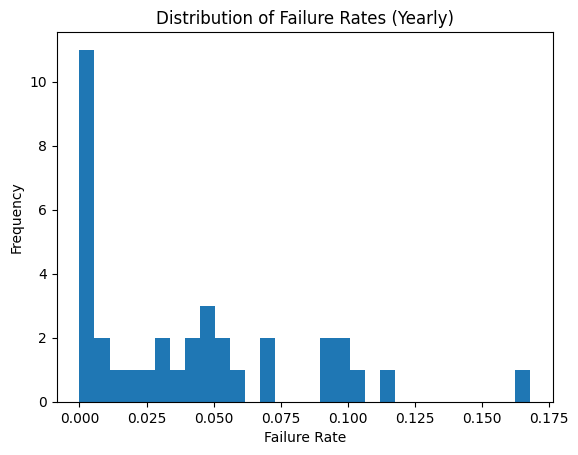

Saved histogram: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\imbalance\failure_rate_histogram.png


In [84]:

plt.figure()
plt.hist(yearly_summary["failure_rate"].dropna(), bins=30)
plt.title("Distribution of Failure Rates (Yearly)")
plt.xlabel("Failure Rate")
plt.ylabel("Frequency")

hist_file = imbalance_dir / "failure_rate_histogram.png"
plt.savefig(hist_file)
plt.show()

print("Saved histogram:", hist_file)


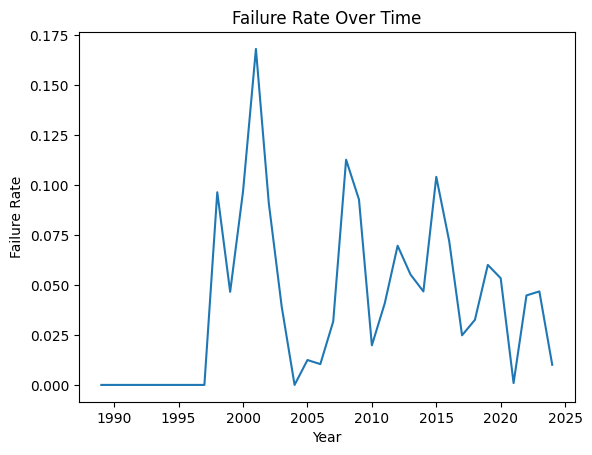

Saved time series: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\imbalance\failure_rate_timeseries.png


In [85]:
plt.figure()
plt.plot(yearly_summary["year"], yearly_summary["failure_rate"])
plt.title("Failure Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Failure Rate")

ts_file = imbalance_dir / "failure_rate_timeseries.png"
plt.savefig(ts_file)
plt.show()

print("Saved time series:", ts_file)


## Interpretation

The results show that:

- positive forward-looking failure observations are rare relative to the total number of firm-months  
- the imbalance varies across time, often increasing during periods of economic stress  
- certain industries exhibit systematically higher future failure rates  

This confirms that bankruptcy prediction remains a rare-event hazard-style classification problem, justifying the use of class-weighted loss functions rather than resampling techniques.


## Failure Rates by Size Decile


In [86]:
# SETUP RESULTS FOLDER + CLEAN OLD FILES

# File paths
failure_plot_file = RESULTS_DIR / "failure_rate_by_rsize.png"
cumulative_plot_file = RESULTS_DIR / "cumulative_failure_by_rsize.png"

# Delete existing files if they exist
for f in [failure_plot_file, cumulative_plot_file]:
    if f.exists():
        f.unlink()
        print(f"Deleted existing file: {f}")

print(f"Results directory ready: {RESULTS_DIR}")


Results directory ready: C:\Users\Triguboff\Dev\Final\results



Failure rate by rsize decile (0 = smallest firms):

 rsize_decile  n_obs  failures  failure_rate_pct
            0  34072       433            1.2708
            1  34071       358            1.0507
            2  34071       217            0.6369
            3  34071       181            0.5312
            4  34071       145            0.4256
            5  34071       122            0.3581
            6  34071       110            0.3229
            7  34071        99            0.2906
            8  34071        60            0.1761
            9  34072        65            0.1908

Cumulative failure concentration:

 rsize_decile  cum_failure_pct
            0            24.19
            1            44.19
            2            56.31
            3            66.42
            4            74.53
            5            81.34
            6            87.49
            7            93.02
            8            96.37
            9           100.00


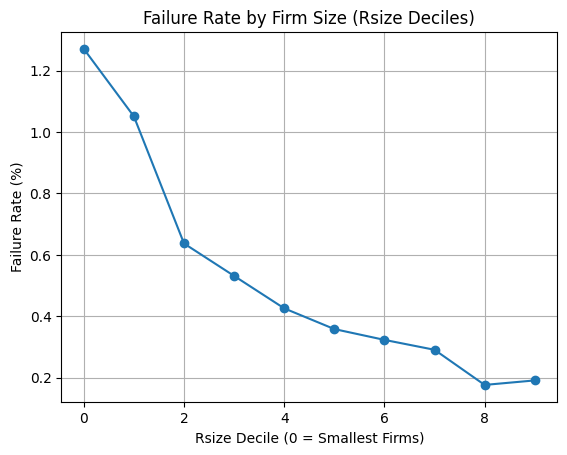

Saved: C:\Users\Triguboff\Dev\Final\results\failure_rate_by_rsize.png


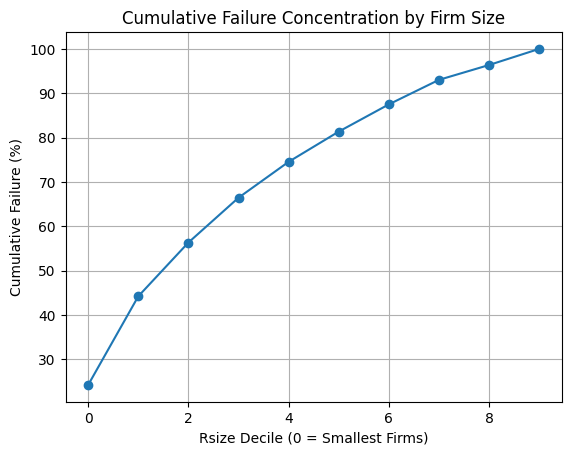

Saved: C:\Users\Triguboff\Dev\Final\results\cumulative_failure_by_rsize.png


In [87]:

if "base_compare_df" in globals():
    df_source = base_compare_df.copy()
elif "clean_df" in globals():
    df_source = clean_df.copy()
else:
    raise NameError("Run the base panel and imbalance analysis cells before the rsize analysis cell.")

required_cols = ["rsize", "target_failure"]
missing = [col for col in required_cols if col not in df_source.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df_rsize = df_source.dropna(subset=["rsize", "target_failure"]).copy()
df_rsize["rsize_decile"] = pd.qcut(df_rsize["rsize"], 10, labels=False)

rsize_summary = (
    df_rsize
    .groupby("rsize_decile")
    .agg(
        n_obs=("target_failure", "count"),
        failures=("target_failure", "sum"),
        failure_rate=("target_failure", "mean"),
    )
    .reset_index()
)

rsize_summary["failure_rate_pct"] = rsize_summary["failure_rate"] * 100
rsize_summary["cum_failures"] = rsize_summary["failures"].cumsum()
rsize_summary["cum_failure_pct"] = (
    rsize_summary["cum_failures"] / rsize_summary["failures"].sum() * 100
)

print("\nFailure rate by rsize decile (0 = smallest firms):\n")
print(
    rsize_summary[
        ["rsize_decile", "n_obs", "failures", "failure_rate_pct"]
    ].round(4).to_string(index=False)
)

print("\nCumulative failure concentration:\n")
print(
    rsize_summary[
        ["rsize_decile", "cum_failure_pct"]
    ].round(2).to_string(index=False)
)

plt.figure()
plt.plot(rsize_summary["rsize_decile"], rsize_summary["failure_rate_pct"], marker="o")
plt.xlabel("Rsize Decile (0 = Smallest Firms)")
plt.ylabel("Failure Rate (%)")
plt.title("Failure Rate by Firm Size (Rsize Deciles)")
plt.grid()
plt.savefig(failure_plot_file, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {failure_plot_file}")

plt.figure()
plt.plot(rsize_summary["rsize_decile"], rsize_summary["cum_failure_pct"], marker="o")
plt.xlabel("Rsize Decile (0 = Smallest Firms)")
plt.ylabel("Cumulative Failure (%)")
plt.title("Cumulative Failure Concentration by Firm Size")
plt.grid()
plt.savefig(cumulative_plot_file, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {cumulative_plot_file}")


In [88]:

# RSIZE STABILITY DIAGNOSTICS

# Ensure we use correct dataset
if "model_df" not in globals():
    df = pd.read_csv(MODEL_FILE)
else:
    df = model_df.copy()

# Ensure datetime + year
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

# Drop missing rsize
df = df.dropna(subset=["rsize"])

# 1. Distribution over time

print("\nRSIZE DISTRIBUTION OVER TIME (KEY QUANTILES):\n")

rsize_quantiles = (
    df.groupby("year")["rsize"]
    .quantile([0.1, 0.5, 0.9])
    .unstack()
    .rename(columns={0.1: "p10", 0.5: "median", 0.9: "p90"})
)

print(rsize_quantiles.tail(10))  # last 10 years

# 2. Decile thresholds over time

print("\nRSIZE DECILE THRESHOLDS (LAST YEARS):\n")

deciles_over_time = (
    df.groupby("year")["rsize"]
    .quantile([i/10 for i in range(1, 10)])
    .unstack()
)

print(deciles_over_time.tail(5))

# 3. Firm-level variability

print("\nFIRM-LEVEL RSIZE VARIABILITY:\n")

firm_variability = (
    df.groupby("permno")["rsize"]
    .agg(["mean", "std", "min", "max"])
    .dropna()
)

print(firm_variability.describe())

# 4. Decile migration 

print("\nDECILE MIGRATION ANALYSIS:\n")

df["rsize_decile_year"] = (
    df.groupby("year")["rsize"]
    .transform(lambda x: pd.qcut(x, 10, labels=False))
)

decile_movement = (
    df.groupby("permno")["rsize_decile_year"]
    .nunique()
)

print("Average number of deciles per firm:", decile_movement.mean())
print("Median number of deciles per firm:", decile_movement.median())

print("\nDistribution of decile movement:")
print(decile_movement.value_counts().sort_index().head(10))

# 5. Failure concentration by size over time

print("\nFAILURE RATE BY SIZE DECILE (LAST YEARS):\n")

failure_by_decile_time = (
    df.groupby(["year", "rsize_decile_year"])["target_failure"]
    .mean()
    .unstack()
)

print(failure_by_decile_time.tail(5))



RSIZE DISTRIBUTION OVER TIME (KEY QUANTILES):

            p10     median       p90
year                                
2015 -12.026732  -9.405844 -6.867597
2016 -12.191663  -9.447522 -6.822640
2017 -12.368599  -9.424936 -6.768214
2018 -12.481475  -9.425806 -6.695033
2019 -12.704777  -9.552782 -6.707512
2020 -12.683146  -9.786431 -6.786229
2021 -12.281064  -9.598232 -6.746223
2022 -12.867451  -9.672426 -6.700419
2023 -13.516519  -9.887014 -6.726851
2024 -13.889699 -10.115236 -6.866683

RSIZE DECILE THRESHOLDS (LAST YEARS):

            0.1        0.2        0.3        0.4        0.5       0.6  \
year                                                                    
2020 -12.683146 -11.672197 -10.978889 -10.385191  -9.786431 -9.145883   
2021 -12.281064 -11.398834 -10.810514 -10.208220  -9.598232 -9.042685   
2022 -12.867451 -11.880178 -11.089636 -10.417861  -9.672426 -9.091149   
2023 -13.516519 -12.261727 -11.387599 -10.644588  -9.887014 -9.207500   
2024 -13.889699 -12.528684 -11

## Firm Size, Distress Concentration, and Sample Restriction

To assess whether a size-based sample restriction is appropriate, the relationship between firm size (rsize) and failure incidence was examined, along with the stability of firm size over time.

# Distribution of Firm Size Over Time

Firm size distributions were analysed using key quantiles (10th percentile, median, and 90th percentile) across recent years:

Median rsize declines gradually from approximately -9.4 (2015) to -10.1 (2024)
The 90th percentile remains highly stable, ranging between -6.7 and -6.9
The 10th percentile shows a modest downward shift, reflecting broader market evolution

These results indicate: No structural breaks in the distribution of firm size;A stable cross-sectional ranking of firms over time; Stability of Size Thresholds

The 90th percentile threshold remains tightly clustered around -6.7 to -6.9
Intermediate quantiles (e.g., 50th percentile) also exhibit minimal variation

This stability confirms that:

Firm size rankings are consistent over time, supporting the use of decile-based classification.

# Firm-Level Size Variability

Firm-level variability in rsize was analysed using the standard deviation of size for each firm:

Mean standard deviation: 0.73
Median standard deviation: ~0.65
Interquartile range: approximately 0.38 to 0.99

While some firms exhibit higher variability (maximum ~4.49), the majority display moderate and stable size dynamics.

# Decile Migration

Firm movement across size deciles was examined:

Average number of distinct deciles per firm: 4.47
Median: 4 deciles

This indicates that firms do move across size categories over time, reflecting changes in market capitalisation. However:

Movement is gradual rather than erratic
Relative size ordering is preserved
Large firms remain disproportionately concentrated in upper deciles
Failure Concentration by Firm Size

Failure incidence is strongly concentrated among smaller firms:

Approximately 80% of failures occur within the smallest 5 deciles
Approximately 95% occur by decile 6
Deciles 7-9 exhibit near-zero failure rates
In recent years (2020-2024), no failures are observed in deciles 4-9

This pattern is consistent across time and aligns with prior literature (e.g., Campbell et al., 2008), which finds that distress risk declines sharply with firm size.

## Interpretation

These results demonstrate that:

Large firms contribute a substantial number of observations
However, they contribute almost no failure events
As a result, they significantly increase class imbalance without adding meaningful predictive signal

This creates a situation where:

The model is dominated by non-event observations from large firms, reducing its ability to learn patterns associated with distress.


80% of failures occur in the four smallest deciles
No failures occur in the three largest deciles (deciles 7-9)

Based on the above findings, a size-based restriction is implemented:

Firms in the largest  THREE size deciles (deciles 7-9) are excluded
The analysis focuses on firms within the lower and middle size distribution

This approach is justified because:

Failure risk is economically concentrated among smaller firms
Size distributions and thresholds are stable over time
The restriction reduces extreme class imbalance without introducing artificial reweighting


In [89]:
# VALIDATION: DELISTING DATA + EVENT FLAGS

# OBJECTIVE:

# Confirm that:
# 1. Delisting codes (dlstcd) exist in the dataset
# 2. Event flags are correctly constructed
# 3. Dataset contains non-zero events (critical for modelling)

# Check dlstcd presence
print("dlstcd present in final_df:", "dlstcd" in final_df.columns)

if "dlstcd" not in final_df.columns:
    raise ValueError("Delisting data missing - pipeline incorrect.")

# Event counts
print("\nBankruptcy events (574):")
print(final_df["bankruptcy_event_574"].value_counts())

print("\nDistress events (400-499):")
print(final_df["liquidation_400_499"].value_counts())

print("\nCombined events:")
print(final_df["distress_event_any"].value_counts())

# Total events check
total_events = final_df["distress_event_any"].sum()

if total_events == 0:
    raise ValueError("No events detected - model will be invalid.")
else:
    print(f"\nTotal events detected: {int(total_events):,} ")


dlstcd present in final_df: True

Bankruptcy events (574):
bankruptcy_event_574
0    495039
1        12
Name: count, dtype: int64

Distress events (400-499):
liquidation_400_499
0    495045
1         6
Name: count, dtype: int64

Combined events:
distress_event_any
0    494885
1       166
Name: count, dtype: int64

Total events detected: 166 


In [90]:
# Pipeline Step 28A. Export Clean Modelling Datasets

# Full merged file
final_df.to_csv(FINAL_FILE, index=False)

# Lean modelling file
model_cols = [
    "gvkey", "permno", "date", "datadate", "fyear", "conm", "sic", "naics",
    "exchcd", "shrcd",
    "bankruptcy_event_574", "liquidation_400_499", "failure_event",
    "industry_group", "target_failure",
    "tlta", "nimta", "exret", "sigma_12m", "rsize",
    "tlta_lag1", "nimta_lag1", "exret_lag1", "sigma_12m_lag1", "rsize_lag1"
]
existing_model_cols = [col for col in model_cols if col in clean_df.columns]
clean_df[existing_model_cols].to_csv(MODEL_FILE, index=False)

# Train/validation/test clean modelling datasets
base_export_cols = ["permno", "date", "industry_group", "target_failure"]
base_export_cols = [c for c in base_export_cols if c in train_df.columns]

# Barboza
barboza_train_cols = base_export_cols + [c for c in barboza_lagged if c in train_df.columns]
barboza_val_cols   = base_export_cols + [c for c in barboza_lagged if c in val_df.columns]
barboza_test_cols  = base_export_cols + [c for c in barboza_lagged if c in test_df.columns]

train_df[barboza_train_cols].to_csv(TRAIN_FILE.parent / "barboza_train.csv", index=False)
val_df[barboza_val_cols].to_csv(VAL_FILE.parent / "barboza_validation.csv", index=False)
test_df[barboza_test_cols].to_csv(TEST_FILE.parent / "barboza_test.csv", index=False)

# Shumway
shumway_train_cols = base_export_cols + [c for c in shumway_lagged if c in train_df.columns]
shumway_val_cols   = base_export_cols + [c for c in shumway_lagged if c in val_df.columns]
shumway_test_cols  = base_export_cols + [c for c in shumway_lagged if c in test_df.columns]

train_df[shumway_train_cols].to_csv(TRAIN_FILE.parent / "shumway_train.csv", index=False)
val_df[shumway_val_cols].to_csv(VAL_FILE.parent / "shumway_validation.csv", index=False)
test_df[shumway_test_cols].to_csv(TEST_FILE.parent / "shumway_test.csv", index=False)

# Combined
combined_train_cols = base_export_cols + [c for c in combined_lagged if c in train_df.columns]
combined_val_cols   = base_export_cols + [c for c in combined_lagged if c in val_df.columns]
combined_test_cols  = base_export_cols + [c for c in combined_lagged if c in test_df.columns]

train_df[combined_train_cols].to_csv(TRAIN_FILE.parent / "combined_train.csv", index=False)
val_df[combined_val_cols].to_csv(VAL_FILE.parent / "combined_validation.csv", index=False)
test_df[combined_test_cols].to_csv(TEST_FILE.parent / "combined_test.csv", index=False)

print("Saved:")
print("Full merged dataset:", FINAL_FILE)
print("Lean modelling dataset with failure target:", MODEL_FILE)
print("Barboza train:", TRAIN_FILE.parent / "barboza_train.csv")
print("Barboza validation:", VAL_FILE.parent / "barboza_validation.csv")
print("Barboza test:", TEST_FILE.parent / "barboza_test.csv")
print("Shumway train:", TRAIN_FILE.parent / "shumway_train.csv")
print("Shumway validation:", VAL_FILE.parent / "shumway_validation.csv")
print("Shumway test:", TEST_FILE.parent / "shumway_test.csv")
print("Combined train:", TRAIN_FILE.parent / "combined_train.csv")
print("Combined validation:", VAL_FILE.parent / "combined_validation.csv")
print("Combined test:", TEST_FILE.parent / "combined_test.csv")

Saved:
Full merged dataset: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\final_dataset.csv
Lean modelling dataset with failure target: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\model_dataset.csv
Barboza train: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\barboza_train.csv
Barboza validation: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\barboza_validation.csv
Barboza test: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\barboza_test.csv
Shumway train: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\shumway_train.csv
Shumway validation: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\shumway_validation.csv
Shumway test: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\shumway_test.csv
Combined train: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\combined_train.csv
Combined validation: C:\Users\Triguboff\Dev\Final\wrds_bankruptcy_data\final\combined_validation.csv
Combined test: C:\Users\Triguboff\Dev\

## Pipeline Step 29. Summary Checks

In [91]:
if USE_WRDS:
    print("FUNDA rows:", f"{len(funda):,}")
    print("CCM rows:", f"{len(ccm):,}")
    print("CRSP monthly rows:", f"{len(crsp):,}")
    print("MSI rows:", f"{len(msi):,}")
    print("Final merged rows:", f"{len(final_df):,}")
    print("Clean modelling rows:", f"{len(clean_df):,}")
    print("Unique GVKEYs in clean panel:", f"{clean_df['gvkey'].nunique():,}")
    print("Unique PERMNOs in clean panel:", f"{clean_df['permno'].nunique():,}")
    print("Date range:", clean_df["date"].min(), "to", clean_df["date"].max())

else:
    print("Skipping WRDS raw-data summary (local CSV mode).")

FUNDA rows: 463,706
CCM rows: 5,732
CRSP monthly rows: 636,081
MSI rows: 480
Final merged rows: 495,051
Clean modelling rows: 340,712
Unique GVKEYs in clean panel: 4,411
Unique PERMNOs in clean panel: 4,459
Date range: 1989-05-31 00:00:00 to 2024-12-31 00:00:00


## Pipeline Step 30. Model Evaluation

Because bankruptcy prediction is a rare-event problem as shown in the results above, model evaluation focuses on ranking quality and minority-class detection rather than overall accuracy.

The same three machine learning models are run on three feature sets:

1. **Barboza / Appendix**
2. **Shumway**
3. **Combined**

The metrics reported are:

- **ROC-AUC**
- **PR-AUC**
- **Recall**
- **Precision**
- **Top-decile capture**


## Pipeline Step 31. IBES Coverage and Missingness Diagnostics

Before introducing IBES-based analyst expectation variables into the bankruptcy prediction framework, coverage and missingness are assessed within the actual modelling subsets rather than across the raw universe. This approach is justified because analyst forecast data are typically concentrated among larger, more visible firms, and full-sample checks may therefore overstate the practical usability of IBES variables in the prediction task. Analysts forecast on larger, more visible firms because their, and their employer's compensation is tied to trading or M&A activity, which is less for small firms.

This diagnostic is conducted separately for the training, validation, and test datasets. Within each subset, observations are grouped into size deciles using `rsize`, allowing coverage to be examined across the cross-section rather than only among the largest firms. The purpose of this step is to determine whether analyst forecast variables are sufficiently available to justify inclusion in the extension analysis.



## IBES Data Source: `actpsum_epsus` → `statsum_epsus`


Step 31A queries `ibes.statsum_epsus` — the IBES Summary Statistics of Analyst
Forecasts table. This table tracks the evolving consensus estimate month-by-month as
analysts update their views, and is the standard source for forward-looking analyst
expectation variables in the academic and practitioner literature.

The following signals are constructed from this richer source:

| Variable | Description |
|---|---|
| `ibes_meanest` | Consensus mean EPS forecast (current fiscal year, `fpi='1'`) |
| `ibes_medest` | Consensus median EPS forecast |
| `ibes_numest` | Number of analysts contributing to the consensus — coverage itself is a distress signal (coverage drops as firms deteriorate) |
| `ibes_stdev` | Cross-analyst forecast dispersion — rises sharply ahead of distress as analysts disagree |
| `ibes_revision` | Month-over-month change in `ibes_meanest` within firm — captures analysts actively cutting their view |
| `ibes_miss_flag` | 1 if the firm's actual EPS fell below the consensus estimate for that fiscal period |
| `ibes_rolling_miss_rate` | Trailing 8-period mean of `ibes_miss_flag` — chronic disappointment is a strong pre-distress indicator |

For backward compatibility `ibes_meanest` is also aliased as `ibes_forecast_level` so
that downstream steps (44A, 45D) continue to run without modification. The enriched
feature list used in those steps should be extended to include the additional signals
listed above.

 **Look-ahead integrity.** All signals are lagged one period before entering any model.
The rolling miss rate uses only `actual` values from prior closed fiscal periods;
no future actuals are used. The `statpers` ≤ `date` filter ensures only information
available before the prediction date enters the panel.


In [92]:
if RUN_IBES_WRDS_EXTENSION:
    # Pipeline Step 31A. IBES Coverage and Missingness Diagnostics
    
    required_dfs = ["train_df", "val_df", "test_df"]
    for name in required_dfs:
        if name not in globals():
            raise KeyError(f"{name} not found. Run the train/validation/test split step before Step 31A.")

    required_panel_cols = ["permno", "date", "rsize"]
    for name, df_check in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
        missing_cols = [c for c in required_panel_cols if c not in df_check.columns]
        if missing_cols:
            raise KeyError(f"{name} is missing required columns: {missing_cols}")

    if "final_df" not in globals():
        raise KeyError("final_df not found. Step 31A needs final_df to build the IBES link.")

    required_link_cols = ["permno", "date", "cusip"]
    missing_link_cols = [c for c in required_link_cols if c not in final_df.columns]
    if missing_link_cols:
        raise KeyError(f"final_df is missing required link columns: {missing_link_cols}")

    try:
        db.close()
    except:
        pass

    db = get_wrds_connection()

    link_df = final_df[["permno", "date", "cusip"]].copy()
    link_df["date"] = pd.to_datetime(link_df["date"], errors="coerce")
    link_df["cusip8"] = link_df["cusip"].astype(str).str[:8]
    link_df = link_df.dropna(subset=["permno", "date", "cusip8"]).drop_duplicates()

    panel_cusips = sorted(link_df["cusip8"].dropna().unique().tolist())

    # Restricting IBES to 2000 onward reduces WRDS load and avoids connection failures.
    # Also substantively reasonable: analyst coverage is thinner before 2000.
    ibes_start_date = "2000-01-01"
    ibes_end_date   = "2025-12-31"

    chunk_size  = 500
    ibes_chunks = []

    for i in range(0, len(panel_cusips), chunk_size):
        cusip_chunk    = panel_cusips[i : i + chunk_size]
        cusip_list_sql = ",".join([f"'{c}'" for c in cusip_chunk])

        # statsum_epsus is the forecast summary table.
        # fpi='1' restricts to current fiscal-year consensus estimates.
        # meanest  = consensus mean EPS forecast (forward-looking).
        # medest   = consensus median EPS forecast.
        # numest   = number of contributing analysts.
        # stdev    = cross-analyst dispersion of forecasts.
        # actual   = realised EPS for closed periods (used for miss-rate only).
        sql = f"""
            SELECT
                cusip,
                statpers,
                fpedats,
                meanest,
                medest,
                numest,
                stdev,
                actual
            FROM ibes.statsum_epsus
            WHERE usfirm  = 1
              AND measure  = 'EPS'
              AND fpi      = '1'
              AND statpers >= '{ibes_start_date}'
              AND statpers <= '{ibes_end_date}'
              AND SUBSTR(cusip, 1, 8) IN ({cusip_list_sql})
        """

        try:
            chunk_df = db.raw_sql(sql)
            ibes_chunks.append(chunk_df)
            print(f"Loaded IBES chunk {i // chunk_size + 1} with {len(chunk_df):,} rows")
        except Exception as e:
            print(f"Failed IBES chunk {i // chunk_size + 1}: {e}")

    if len(ibes_chunks) == 0:
        raise ValueError(
            "No IBES data were retrieved. Check WRDS connection, date filters, or CUSIP matching."
        )

    ibes_raw = pd.concat(ibes_chunks, ignore_index=True)
    ibes_raw["statpers"] = pd.to_datetime(ibes_raw["statpers"], errors="coerce")
    ibes_raw["fpedats"]  = pd.to_datetime(ibes_raw["fpedats"],  errors="coerce")
    ibes_raw["cusip8"]   = ibes_raw["cusip"].astype(str).str[:8]
    ibes_raw = ibes_raw.dropna(subset=["statpers", "cusip8"])

    # ── Merge with panel link ────────────────────────────────────────────────
    ibes_panel = link_df.merge(
        ibes_raw[["cusip8", "statpers", "fpedats", "meanest", "medest",
                  "numest", "stdev", "actual"]],
        on="cusip8",
        how="left",
    )

    # Keep only observations where the consensus was available before the panel date.
    ibes_panel = ibes_panel.dropna(subset=["statpers"])
    ibes_panel = ibes_panel[ibes_panel["statpers"] <= ibes_panel["date"]]

    # For each (permno, date) keep the most recent consensus vintage.
    ibes_panel = ibes_panel.sort_values(["permno", "date", "statpers"])
    ibes_panel = ibes_panel.groupby(["permno", "date"], as_index=False).tail(1)

    ibes_panel = ibes_panel[
        ["permno", "date", "meanest", "medest", "numest", "stdev", "actual"]
    ].copy()

    ibes_panel = ibes_panel.rename(columns={
        "meanest": "ibes_meanest",
        "medest":  "ibes_medest",
        "numest":  "ibes_numest",
        "stdev":   "ibes_stdev",
        "actual":  "ibes_actual",
    })

    # Backward-compatibility alias so downstream steps continue without change.
    ibes_panel["ibes_forecast_level"] = ibes_panel["ibes_meanest"]

    # ── Derived signals ──────────────────────────────────────────────────────
    ibes_panel = ibes_panel.sort_values(["permno", "date"])

    # Revision: month-over-month change in consensus mean forecast.
    # Negative values signal analysts cutting their view — a leading distress indicator.
    ibes_panel["ibes_revision"] = (
        ibes_panel.groupby("permno")["ibes_meanest"].diff(1)
    )

    # Miss flag: 1 when the firm's actual EPS fell below the consensus.
    # Only populated for closed fiscal periods where ibes_actual is non-null.
    ibes_panel["ibes_miss_flag"] = np.where(
        ibes_panel["ibes_actual"].notna(),
        (ibes_panel["ibes_actual"] < ibes_panel["ibes_meanest"]).astype(float),
        np.nan,
    )

    # Rolling miss rate: trailing 8-period proportion of misses.
    # Chronic disappointment is a strong pre-distress signal.
    ibes_panel["ibes_rolling_miss_rate"] = (
        ibes_panel.groupby("permno")["ibes_miss_flag"]
        .transform(lambda x: x.rolling(8, min_periods=2).mean())
    )

    print(f"ibes_panel built: {len(ibes_panel):,} rows, "
          f"{ibes_panel['permno'].nunique():,} unique firms")
    print("Columns:", list(ibes_panel.columns))

    # ── Coverage diagnostics ─────────────────────────────────────────────────
    def add_rsize_deciles(df):
        df = df.copy()
        valid = df["rsize"].replace([np.inf, -np.inf], np.nan)
        if valid.notna().sum() < 10:
            df["rsize_decile"] = np.nan
            return df
        df["rsize_decile"] = pd.qcut(valid, 10, labels=False, duplicates="drop") + 1
        return df

    def ibes_coverage_summary(subset_df, subset_name):
        df = subset_df.merge(ibes_panel, on=["permno", "date"], how="left")
        df = add_rsize_deciles(df)

        overall = pd.DataFrame({
            "subset":                  [subset_name],
            "rows":                    [len(df)],
            "forecast_nonmissing":     [df["ibes_forecast_level"].notna().sum()],
            "forecast_missing":        [df["ibes_forecast_level"].isna().sum()],
            "forecast_coverage_pct":   [df["ibes_forecast_level"].notna().mean() * 100],
            "revision_coverage_pct":   [df["ibes_revision"].notna().mean() * 100],
            "miss_rate_coverage_pct":  [df["ibes_rolling_miss_rate"].notna().mean() * 100],
            "numest_mean":             [df["ibes_numest"].mean()],
        })

        by_decile = (
            df.dropna(subset=["rsize_decile"])
            .groupby("rsize_decile", as_index=False)
            .agg(
                rows=("permno", "size"),
                forecast_nonmissing=("ibes_forecast_level", lambda x: x.notna().sum()),
                forecast_missing=("ibes_forecast_level", lambda x: x.isna().sum()),
            )
        )
        by_decile["forecast_coverage_pct"] = (
            by_decile["forecast_nonmissing"] / by_decile["rows"] * 100
        )
        by_decile.insert(0, "subset", subset_name)

        return df, overall, by_decile

    train_ibes, train_overall, train_by_decile = ibes_coverage_summary(train_df, "Train")
    val_ibes,   val_overall,   val_by_decile   = ibes_coverage_summary(val_df,   "Validation")
    test_ibes,  test_overall,  test_by_decile  = ibes_coverage_summary(test_df,  "Test")

    ibes_coverage_overall = pd.concat(
        [train_overall, val_overall, test_overall], ignore_index=True
    ).round({"forecast_coverage_pct": 2, "revision_coverage_pct": 2,
             "miss_rate_coverage_pct": 2, "numest_mean": 2})

    ibes_coverage_by_decile = pd.concat(
        [train_by_decile, val_by_decile, test_by_decile], ignore_index=True
    ).round({"forecast_coverage_pct": 2})

    print("\nIBES FORECAST COVERAGE OVERALL")
    print(ibes_coverage_overall)
    print("\nIBES FORECAST COVERAGE BY RSIZE DECILE")
    print(ibes_coverage_by_decile)

    train_df_ibes_diag = train_ibes.copy()
    val_df_ibes_diag   = val_ibes.copy()
    test_df_ibes_diag  = test_ibes.copy()

else:
    print("Skipping optional IBES WRDS extension in local/submission mode.")


Loading library list...
Done
Loaded IBES chunk 1 with 32,737 rows
Loaded IBES chunk 2 with 32,064 rows
Loaded IBES chunk 3 with 33,151 rows
Loaded IBES chunk 4 with 30,733 rows
Loaded IBES chunk 5 with 30,591 rows
Loaded IBES chunk 6 with 34,631 rows
Loaded IBES chunk 7 with 31,141 rows
Loaded IBES chunk 8 with 32,180 rows
Loaded IBES chunk 9 with 29,629 rows
Loaded IBES chunk 10 with 21,522 rows
ibes_panel built: 304,781 rows, 3,599 unique firms
Columns: ['permno', 'date', 'ibes_meanest', 'ibes_medest', 'ibes_numest', 'ibes_stdev', 'ibes_actual', 'ibes_forecast_level', 'ibes_revision', 'ibes_miss_flag', 'ibes_rolling_miss_rate']

IBES FORECAST COVERAGE OVERALL
       subset    rows  forecast_nonmissing  forecast_missing  \
0       Train  145453                73792             71661   
1  Validation   82874                48157             34717   
2        Test  112385                70587             41798   

   forecast_coverage_pct  revision_coverage_pct  miss_rate_coverage_pct  

## Pipeline Step 31B. IBES Coverage and Missingness Interpretation

The IBES coverage diagnostics indicate that analyst forecast data are sufficiently available to support a targeted extension analysis, although coverage is uneven across the sample. Restricting the diagnostic to the post-2000 period is appropriate both practically and substantively. From a computational perspective, limiting the extraction window reduces WRDS query size and avoids connection failures associated with very large table pulls. From a research perspective, analyst coverage is substantially weaker in earlier years, so the post-2000 period provides a more realistic assessment of whether IBES variables are usable in a modern bankruptcy prediction setting.

Overall forecast coverage is moderate, with 47.26% in the training set, 53.85% in the validation set, and 58.34% in the test set. Coverage is materially lower in the smallest size deciles and generally increases across the cross-section, indicating that analyst expectations are more readily available for larger and more visible firms. However, IBES coverage is not confined solely to the largest firms, suggesting that it captures a meaningful portion of the prediction universe.

Accordingly, IBES variables are best interpreted as a targeted enhancement to the baseline accounting-and-market framework rather than as a universally available feature. This supports their inclusion as an extension to the best-performing Combined Neural Network specification, while acknowledging that their applicability is stronger among analyst-followed firms.

In [93]:
# Pipeline Step 31B.1. Save IBES Coverage Report

if RUN_IBES_WRDS_EXTENSION and all(
    name in globals()
    for name in ["ibes_coverage_overall", "ibes_coverage_by_decile"]
):

    ibes_results_dir = RESULTS_DIR / "ibes"
    ibes_results_dir.mkdir(parents=True, exist_ok=True)

    ibes_coverage_overall_save = ibes_coverage_overall.copy()
    ibes_coverage_by_decile_save = ibes_coverage_by_decile.copy()

    summary_df = pd.DataFrame({
        "Item": [
            "IBES sample period",
            "Reason for 2000 onward restriction",
            "Train forecast coverage",
            "Validation forecast coverage",
            "Test forecast coverage"
        ],
        "Value": [
            "2000-01-01 to 2025-12-31",
            "Reduces WRDS query size and improves stability; analyst coverage is more meaningful and consistently available in the modern period.",
            f"{ibes_coverage_overall.loc[ibes_coverage_overall['subset'] == 'Train', 'forecast_coverage_pct'].iloc[0]:.2f}%",
            f"{ibes_coverage_overall.loc[ibes_coverage_overall['subset'] == 'Validation', 'forecast_coverage_pct'].iloc[0]:.2f}%",
            f"{ibes_coverage_overall.loc[ibes_coverage_overall['subset'] == 'Test', 'forecast_coverage_pct'].iloc[0]:.2f}%"
        ]
    })

    excel_file = ibes_results_dir / f"ibes_coverage_report.xlsx"

    with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        ibes_coverage_overall_save.to_excel(writer, sheet_name="Overall Coverage", index=False)
        ibes_coverage_by_decile_save.to_excel(writer, sheet_name="Coverage by Decile", index=False)

    wb = load_workbook(excel_file)

    for ws in wb.worksheets:
        ws.freeze_panes = "A2"

        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(horizontal="center")

        for col_cells in ws.columns:
            max_length = 0
            col_letter = get_column_letter(col_cells[0].column)

            for cell in col_cells:
                cell_value = "" if cell.value is None else str(cell.value)
                max_length = max(max_length, len(cell_value))

            ws.column_dimensions[col_letter].width = min(max_length + 2, 45)

    wb.save(excel_file)

    print("Saved IBES coverage report to:", excel_file)

else:
    print("Skipping IBES coverage report because IBES extension results are not available.")

Saved IBES coverage report to: C:\Users\Triguboff\Dev\Final\results\ibes\ibes_coverage_report.xlsx


### Pipeline Step 32. Evaluation functions

Evaluation helpers used by every modelling step. Integration-pass
changes: `tune_threshold_for_recall` falls back to the top-decile cut
when no threshold hits the recall target (was 0.50, which produced
zero positive predictions for under-fit models); and
`apply_isotonic_calibration` is added for Step 38C to rescale
class-weighted probabilities into calibrated ones.


In [94]:
# Pipeline Step 32A. Evaluation functions
# top_decile_capture_rate, evaluate_predictions, print_eval - unchanged.
# tune_threshold_for_recall 
# apply_isotonic_calibration 

def top_decile_capture_rate(y_true, y_score):
    """Share of positives captured in the top 10% highest-risk observations."""
    eval_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_score": np.asarray(y_score),
    }).sort_values("y_score", ascending=False).reset_index(drop=True)
    n_top = max(1, int(np.ceil(len(eval_df) * 0.10)))
    top_df = eval_df.iloc[:n_top]
    total_pos = eval_df["y_true"].sum()
    if total_pos == 0:
        return np.nan
    return top_df["y_true"].sum() / total_pos

def evaluate_predictions(y_true, y_score, threshold=0.50):
    y_true  = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score).astype(float).ravel()
    assert len(y_true) == len(y_score)
    y_pred = (y_score >= threshold).astype(int)
    roc      = roc_auc_score(y_true, y_score)
    roc_flip = roc_auc_score(y_true, 1 - y_score)
    pr       = average_precision_score(y_true, y_score)
    print(f"    [diag] n={len(y_true):,}  pos={int(y_true.sum())}  "
          f"AUC={roc:.3f}  AUC_flipped={roc_flip:.3f}  PR-AUC={pr:.4f}  "
          f"proba_mean={y_score.mean():.4f}  proba_std={y_score.std():.4f}")
    return {
        "roc_auc": roc, "pr_auc": pr,
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "top_decile_capture": top_decile_capture_rate(y_true, y_score),
        "threshold": threshold,
        "positives": int(y_true.sum()),
        "n_obs":     int(len(y_true)),
    }

def print_eval(name, metrics):
    print(f"\n{name}")
    print(f"ROC-AUC:            {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:             {metrics['pr_auc']:.4f}")
    print(f"Recall:             {metrics['recall']:.4f}")
    print(f"Precision:          {metrics['precision']:.4f}")
    print(f"Top decile capture: {metrics['top_decile_capture']:.4f}")
    print(f"Threshold:          {metrics['threshold']:.2f}")
    print(f"Positives:          {metrics['positives']:,}")
    print(f"Observations:       {metrics['n_obs']:,}")

def tune_threshold_for_recall(y_true, y_score, min_recall=0.50):
    """Highest threshold achieving >= min_recall; else top-decile quantile.
    """
    y_score = np.asarray(y_score)
    thresholds = np.linspace(0.01, 0.99, 199)
    feasible = [t for t in thresholds
                if recall_score(y_true, (y_score >= t).astype(int),
                                zero_division=0) >= min_recall]
    if feasible:
        return float(max(feasible))
    return float(np.quantile(y_score, 0.90))

def apply_isotonic_calibration(val_raw, y_val, *score_arrays):
    """Fit isotonic on (val_raw, y_val); apply to score_arrays. For Step 38C."""
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    iso.fit(np.asarray(val_raw).ravel(), np.asarray(y_val).ravel())
    return tuple(iso.predict(np.asarray(s).ravel()) for s in score_arrays)


### Note on the Random Forest threshold

Random Forest's `predict_proba` returns scores that are tightly clustered near zero on this dataset (mean ~0.018, std ~0.04) because the 0.36% base rate means the vast majority of trees in the ensemble vote "no event" for almost every row. With a fixed 0.50 threshold, RF predicts zero positives, which makes the recall, precision, and F1 columns appear as zero even when the model's *ranking* is perfectly useful (top-decile capture for RF is 0.32-0.40).

For a fair comparison, RF now goes through the same `tune_threshold_for_recall` helper that the Neural Network uses: the threshold is chosen on the validation set to achieve the configured `min_recall` (default 0.50), and that calibrated threshold is then applied to the test set. ROC-AUC, PR-AUC and top-decile capture are unchanged by this (they are threshold-independent); only recall, precision and the threshold column become non-zero.


### Pipeline Step 32B. Feature-set experiment - integration changes

The function publishes per-model val/test probability arrays to a
module-level `comparison_results_full` list for Step 38C calibration.


In [95]:
# Pipeline Step 32B.1. Feature-set experiment 
# Trains RF, XGBoost (early-stopped on val PR-AUC), LightGBM ,
# and Neural Network. Returns 2 values for backward
# compatibility; per-model probability arrays land in `comparison_results_full`.

comparison_results_full = []  # consumed by Step 38C calibration

def run_feature_set_experiment(
    X_train, y_train, X_val, y_val, X_test, y_test,
    feature_set_name, min_recall=0.50,
):
    print(f"\nFEATURE-SET EXPERIMENT - {feature_set_name}")
    X_train, X_val, X_test, _ = _clean_panel_matrices(X_train, X_val, X_test)

    n_pos_train = int(y_train.sum())
    n_neg_train = int((y_train == 0).sum())
    if n_pos_train == 0:
        raise ValueError(f"{feature_set_name}: training set has no positives.")
    scale_pos_weight = n_neg_train / n_pos_train
    results_list = []
    print(f"Train pos={n_pos_train}  neg={n_neg_train}  spw={scale_pos_weight:.2f}")

    # ---- Random Forest (unchanged) -----------------------------------
    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
             class_weight="balanced", random_state=42, n_jobs=-1)),
    ])
    rf.fit(X_train, y_train)
    rf_val  = rf.predict_proba(X_val)[:, 1]
    rf_test = rf.predict_proba(X_test)[:, 1]
    rf_thr  = tune_threshold_for_recall(y_val, rf_val, min_recall=min_recall)
    rf_m    = evaluate_predictions(y_test, rf_test, threshold=rf_thr)
    print_eval("Random Forest", rf_m)
    results_list.append({"feature_set": feature_set_name, "model": "Random Forest",
        "val_proba": rf_val, "test_proba": rf_test, **rf_m})

    # ---- XGBoost  (early stopping on val PR-AUC) -------------------
    imp = SimpleImputer(strategy="median")
    Xt_i, Xv_i, Xe_i = imp.fit_transform(X_train), imp.transform(X_val), imp.transform(X_test)
    xgb_m = XGBClassifier(
        n_estimators=2000, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight, tree_method="hist", n_jobs=-1,
        random_state=42, eval_metric="aucpr", early_stopping_rounds=50,
    )
    xgb_m.fit(Xt_i, y_train, eval_set=[(Xv_i, y_val)], verbose=False)
    xgb_val  = xgb_m.predict_proba(Xv_i)[:, 1]
    xgb_test = xgb_m.predict_proba(Xe_i)[:, 1]
    xgb_thr  = tune_threshold_for_recall(y_val, xgb_val, min_recall=min_recall)
    xgb_metr = evaluate_predictions(y_test, xgb_test, threshold=xgb_thr)
    print(f"XGBoost best iter: {getattr(xgb_m,'best_iteration','n/a')}")
    print_eval("XGBoost", xgb_metr)
    results_list.append({"feature_set": feature_set_name, "model": "XGBoost",
        "val_proba": xgb_val, "test_proba": xgb_test, **xgb_metr})

    # ---- LightGBM -----------------------------------------
    if _HAS_LGB:
        lgbm = lgb.LGBMClassifier(
            n_estimators=2000, learning_rate=0.03, num_leaves=63,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, class_weight="balanced",
            random_state=42, n_jobs=-1,
        )
        lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                 eval_metric="average_precision",
                 callbacks=[lgb.early_stopping(50, verbose=False)])
        lgbm_val  = lgbm.predict_proba(X_val)[:, 1]
        lgbm_test = lgbm.predict_proba(X_test)[:, 1]
        lgbm_thr  = tune_threshold_for_recall(y_val, lgbm_val, min_recall=min_recall)
        lgbm_metr = evaluate_predictions(y_test, lgbm_test, threshold=lgbm_thr)
        print(f"LightGBM best iter: {lgbm.best_iteration_}")
        print_eval("LightGBM", lgbm_metr)
        results_list.append({"feature_set": feature_set_name, "model": "LightGBM",
            "val_proba": lgbm_val, "test_proba": lgbm_test, **lgbm_metr})

    # ---- Neural Network  -------------------------------------------
    nn_test_proba = None
    if RUN_NEURAL_NETWORK:
        print("\nTraining Neural Network ...")
        ni = SimpleImputer(strategy="median"); ns = StandardScaler()
        Xt_n = ns.fit_transform(ni.fit_transform(X_train))
        Xv_n = ns.transform(ni.transform(X_val))
        Xe_n = ns.transform(ni.transform(X_test))
        cfg = {"hidden_units_1":128, "hidden_units_2":64, "dropout_rate":0.30,
               "learning_rate":5e-4, "epochs":200, "batch_size":1024,
               "patience":15, "monitor":"val_pr_auc", "verbose":0,
               "random_state":42}
        model_nn, _ = train_nn_tunable(
            X_train=Xt_n, y_train=y_train.values,
            X_val=Xv_n, y_val=y_val.values, config=cfg,
        )
        nn_val  = model_nn.predict(Xv_n, verbose=0).ravel()
        nn_test = model_nn.predict(Xe_n, verbose=0).ravel()
        nn_thr  = tune_threshold_for_recall(y_val, nn_val, min_recall=min_recall)
        nn_metr = evaluate_predictions(y_test, nn_test, threshold=nn_thr)
        print_eval("Neural Network", nn_metr)
        nn_test_proba = nn_test
        results_list.append({"feature_set": feature_set_name, "model": "Neural Network",
            "val_proba": nn_val, "test_proba": nn_test, **nn_metr})
    else:
        print("Skipping NN (RUN_NEURAL_NETWORK=False)")

    # Publish full results (with arrays) for Step 38C; return slim view.
    global comparison_results_full
    try:
        comparison_results_full
    except NameError:
        comparison_results_full = []
    comparison_results_full.extend(results_list)
    results_df = pd.DataFrame([{k: v for k, v in r.items()
                                if k not in ("val_proba","test_proba")}
                               for r in results_list])
    return results_df, nn_test_proba

# Backwards-compatible alias. The function originally ran only on the
# Combined feature set; it now runs whatever feature set you hand it,
# but old callers (and scratch cells) may still reference the long name.
run_feature_set_experiment_combined_only = run_feature_set_experiment


In [96]:
# Memory cleanup after Step 31B
#
# Releases Python objects from the previous training block and clears the
# TensorFlow / Keras backend graph + cached tensors - prevents the
# kernel from running 'out of memory' (OOM) across long sessions.

gc.collect()
try:
    tf.keras.backend.clear_session()
except Exception:
    pass
print("Memory cleanup done.")



Memory cleanup done.


### Pipeline Step 32C. NN training helpers - integration changes

`train_nn_tunable` is the shared training loop used by Step 32B, 34 and
the Step 39 tuner. Upgraded to: monitor `val_pr_auc` (not val_loss);
epochs up to 200 with patience 15 and `ReduceLROnPlateau`; batch_size
default 1024 for rare-class gradient stability. Optional focal loss via
`config['use_focal_loss']=True`.


In [97]:
# Pipeline Step 32C.1. Helper Functions for NN Tuning 

def expand_param_grid(base_config, param_grid):
    keys = list(param_grid.keys())
    value_lists = [param_grid[k] for k in keys]
    out = []
    for combo in product(*value_lists):
        cfg = dict(base_config)
        for k, v in zip(keys, combo):
            cfg[k] = v
        out.append(cfg)
    return out

def binary_focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss for rare-event binary classification."""
    def loss(y_true, y_pred):
        eps = keras.backend.epsilon()
        y_pred = keras.backend.clip(y_pred, eps, 1 - eps)
        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)
        w  = tf.where(tf.equal(y_true, 1.0), alpha, 1 - alpha)
        return -tf.reduce_mean(w * tf.pow(1 - pt, gamma) * tf.math.log(pt))
    return loss

def train_nn_tunable(X_train, y_train, X_val, y_val, config):
    """NN training loop - integrated."""
    set_all_seeds(config.get("random_state", 42))
    n_features = X_train.shape[1]
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(config.get("hidden_units_1", 128), activation="relu"),
        layers.Dropout(config.get("dropout_rate", 0.30)),
        layers.Dense(config.get("hidden_units_2", 64), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    use_focal = config.get("use_focal_loss", False)
    loss_fn = binary_focal_loss(
        gamma=config.get("focal_gamma", 2.0),
        alpha=config.get("focal_alpha", 0.25),
    ) if use_focal else "binary_crossentropy"
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.get("learning_rate", 5e-4)),
        loss=loss_fn,
        metrics=[keras.metrics.AUC(name="roc_auc"),
                 keras.metrics.AUC(name="pr_auc", curve="PR")],
    )
    if use_focal:
        class_weight = None
    else:
        n_pos = int(np.sum(y_train))
        n_neg = len(y_train) - n_pos
        class_weight = {0: 1.0, 1: n_neg / max(n_pos, 1)}
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor=config.get("monitor", "val_pr_auc"), mode="max",
            patience=config.get("patience", 15), restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor=config.get("monitor", "val_pr_auc"), mode="max",
            factor=0.5, patience=5, min_lr=1e-5),
    ]
    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=config.get("epochs", 200),
        batch_size=config.get("batch_size", 1024),
        class_weight=class_weight, callbacks=callbacks,
        verbose=config.get("verbose", 0),
    )
    return model, history

def tune_nn_hyperparameters_for_panel(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    feature_set_name,
    base_config,
    param_grid,
    min_recall=0.50,
):
    X_train, X_val, X_test, _ = _clean_panel_matrices(X_train, X_val, X_test)

    nn_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_train_nn = nn_pipeline.fit_transform(X_train)
    X_val_nn = nn_pipeline.transform(X_val)
    X_test_nn = nn_pipeline.transform(X_test)

    candidate_configs = expand_param_grid(base_config, param_grid)
    results = []

    print(f"Running NN hyperparameter tuning for: {feature_set_name}")
    print(f"Total candidate configurations: {len(candidate_configs):,}")

    for i, config in enumerate(candidate_configs, start=1):
        print(f"[{i}/{len(candidate_configs)}] {config}")

        model, history = train_nn_tunable(
            X_train=X_train_nn,
            y_train=y_train,
            X_val=X_val_nn,
            y_val=y_val,
            config=config,
        )

        val_proba = model.predict(X_val_nn, verbose=0).ravel()
        threshold = tune_threshold_for_recall(y_val, val_proba, min_recall=min_recall)

        test_proba = model.predict(X_test_nn, verbose=0).ravel()
        metrics = evaluate_predictions(y_test, test_proba, threshold=threshold)

        row = {
            "feature_set": feature_set_name,
            **config,
            **metrics,
        }
        results.append(row)

    results_df = pd.DataFrame(results).sort_values(
        by=["pr_auc", "top_decile_capture", "recall", "roc_auc"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    return results_df

In [98]:
# Pipeline Step 32C.2. Run Combined feature set

combined_results, combined_nn_proba = run_feature_set_experiment(
    X_train=feature_panels["Combined"]["X_train"],
    y_train=feature_panels["Combined"]["y_train"],
    X_val=feature_panels["Combined"]["X_val"],
    y_val=feature_panels["Combined"]["y_val"],
    X_test=feature_panels["Combined"]["X_test"],
    y_test=feature_panels["Combined"]["y_test"],
    feature_set_name="Combined",
    min_recall=0.50,
)

# --- Display results
print("\nCombined feature-set results:")
display(combined_results)

# --- Save outputs (reproducibility)

results_file = RESULTS_DIR / "combined_nn_metrics.csv"
combined_results.to_csv(results_file, index=False)

# Only save probabilities if NN ran successfully
if combined_nn_proba is not None:

    y_test_combined = feature_panels["Combined"]["y_test"].values

    # Existing probability output
    proba_df = pd.DataFrame({
        "y_true": y_test_combined,
        "y_proba": combined_nn_proba
    })

    proba_file = RESULTS_DIR / "combined_nn_proba.csv"
    proba_df.to_csv(proba_file, index=False)

    # Canonical prediction file used by downstream analyses (including Step 45B)
    PREDICTIONS_DIR = RESULTS_DIR / "predictions"
    PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

    prediction_df = pd.DataFrame({
        "y_test": y_test_combined,
        "y_proba": combined_nn_proba
    })

    prediction_file = PREDICTIONS_DIR / "combined_nn_base_test_predictions.csv"
    prediction_df.to_csv(prediction_file, index=False)

    print(
        f"\nSaved:\n"
        f"{results_file}\n"
        f"{proba_file}\n"
        f"{prediction_file}"
    )

else:
    print(f"\nSaved:\n{results_file}")



FEATURE-SET EXPERIMENT - Combined
Train pos=892  neg=144561  spw=162.06
    [diag] n=112,385  pos=409  AUC=0.751  AUC_flipped=0.249  PR-AUC=0.0118  proba_mean=0.0163  proba_std=0.0373

Random Forest
ROC-AUC:            0.7508
PR-AUC:             0.0118
Recall:             0.4792
Precision:          0.0127
Top decile capture: 0.3961
Threshold:          0.03
Positives:          409
Observations:       112,385
    [diag] n=112,385  pos=409  AUC=0.757  AUC_flipped=0.243  PR-AUC=0.0222  proba_mean=0.4426  proba_std=0.0743
XGBoost best iter: 13

XGBoost
ROC-AUC:            0.7569
PR-AUC:             0.0222
Recall:             0.6455
Precision:          0.0092
Top decile capture: 0.3496
Threshold:          0.50
Positives:          409
Observations:       112,385
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 892, number of negative: 144561
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing w

,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Combined,Random Forest,0.750822,0.011825,0.479218,0.012663,0.396088,0.029798,409,112385
1,Combined,XGBoost,0.756930,0.022228,0.645477,0.009229,0.349633,0.500000,409,112385
2,Combined,LightGBM,0.733157,0.015612,0.537897,0.010173,0.356968,0.405960,409,112385
3,Combined,Neural Network,0.725033,0.012378,0.589242,0.008236,0.383863,0.539596,409,112385



Saved:
C:\Users\Triguboff\Dev\Final\results\combined_nn_metrics.csv
C:\Users\Triguboff\Dev\Final\results\combined_nn_proba.csv
C:\Users\Triguboff\Dev\Final\results\predictions\combined_nn_base_test_predictions.csv


In [99]:
# Memory cleanup after Step 32A
#
# Releases Python objects from the previous training block and clears the
# TensorFlow / Keras backend graph + cached tensors. 

gc.collect()
try:
    tf.keras.backend.clear_session()
except Exception:
    pass
print("Memory cleanup done.")


Memory cleanup done.


## Pipeline Step 33. Random Forest Feature Ranking

In [100]:
def get_rf_feature_importance(X_train, y_train, feature_set_name):
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)
    
    importance_df["feature_set"] = feature_set_name
    
    return importance_df

In [101]:
importance_barboza = get_rf_feature_importance(
    feature_panels["Barboza"]["X_train"],
    feature_panels["Barboza"]["y_train"],
    "Barboza",
)

importance_shumway = get_rf_feature_importance(
    feature_panels["Shumway"]["X_train"],
    feature_panels["Shumway"]["y_train"],
    "Shumway",
)

importance_combined = get_rf_feature_importance(
    feature_panels["Combined"]["X_train"],
    feature_panels["Combined"]["y_train"],
    "Combined",
)

importance_all = pd.concat(
    [importance_barboza, importance_shumway, importance_combined],
    ignore_index=True,
)


In [102]:
def top_features(df, n=10):
    return df.head(n)[["feature", "importance"]]

print("\nTop Barboza Features:")
display(top_features(importance_barboza, 10))

print("\nTop Shumway Features:")
display(top_features(importance_shumway, 10))

print("\nTop Combined Features:")
display(top_features(importance_combined, 10))



Top Barboza Features:


,feature,importance
1,x2_re_ta_lag1,0.138073
3,x4_mve_td_lag1,0.135234
2,x3_ebit_ta_lag1,0.129225
6,operating_margin_lag1,0.116127
0,x1_nwc_ta_lag1,0.112666
5,interest_coverage_lag1,0.105443
4,x5_sales_ta_lag1,0.104835
11,cpb_change_pb_lag1,0.089872
9,ge_growth_employees_lag1,0.013057
13,industry_Miscellaneous_lag1,0.011554



Top Shumway Features:


,feature,importance
0,tlta_lag1,0.281309
1,nimta_lag1,0.190065
3,sigma_12m_lag1,0.178627
4,rsize_lag1,0.167551
2,exret_lag1,0.142018
6,industry_Miscellaneous_lag1,0.012455
8,industry_Transportation and Utilities_lag1,0.009453
7,industry_Technology_lag1,0.009340
5,industry_Manufacturing and Mining_lag1,0.009183



Top Combined Features:


,feature,importance
1,x2_re_ta_lag1,0.085289
2,x3_ebit_ta_lag1,0.084158
3,x4_mve_td_lag1,0.084092
16,tlta_lag1,0.082517
19,sigma_12m_lag1,0.077885
6,operating_margin_lag1,0.076798
17,nimta_lag1,0.076584
5,interest_coverage_lag1,0.075610
0,x1_nwc_ta_lag1,0.074907
4,x5_sales_ta_lag1,0.068984


In [103]:


# New subfolder for feature importance
FEATURE_IMPORTANCE_DIR = RESULTS_DIR / "feature_importance"
FEATURE_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

# File paths
importance_file_csv = FEATURE_IMPORTANCE_DIR / f"rf_feature_importance.csv"
importance_file_xlsx = FEATURE_IMPORTANCE_DIR / f"rf_feature_importance.xlsx"

# Save CSV
importance_all.to_csv(importance_file_csv, index=False)

# Save Excel with sheets
with pd.ExcelWriter(importance_file_xlsx) as writer:
    importance_barboza.to_excel(writer, sheet_name="Barboza", index=False)
    importance_shumway.to_excel(writer, sheet_name="Shumway", index=False)
    importance_combined.to_excel(writer, sheet_name="Combined", index=False)

print("Saved files:")
print(importance_file_csv)
print(importance_file_xlsx)


Saved files:
C:\Users\Triguboff\Dev\Final\results\feature_importance\rf_feature_importance.csv
C:\Users\Triguboff\Dev\Final\results\feature_importance\rf_feature_importance.xlsx


## Pipeline Step 34. Neural Network Model Specification and Implementation

1.Shallow Network Architecture- BASE

A deliberately simple architecture was used:

Two hidden layers (32 and 16 neurons)
ReLU activation functions
Sigmoid output layer for probability estimation

The objective of this shallow network architecture, for now and before hyperparameter tuning":

- reduces overfitting risk
- improves training stability
- is more appropriate for tabular financial data

Deep architectures were avoided, as they are unstable in sparse tabular settings.

3. Regularisation via Dropout

Dropout (30%) was applied between layers to reduce sensitivity to noise;prevent memorisation of rare patterns: &
improve generalisation

4. Early Stopping :Training was controlled using early stopping: Terminating training when performance stops improving
This prevents overfitting, which is particularly important when positive cases are limited.

5. Feature Scaling

6. Probability-Based Evaluation and Threshold Tuning

See Cost sensitivity analysis below

### Pipeline Step 34A. Baseline Neural Network 


In [104]:
# Pipeline Step 34A.1. Train Neural Network 
def train_nn(X_train, y_train, X_val, y_val):
    n_features = X_train.shape[1]
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="roc_auc"),
                 keras.metrics.AUC(name="pr_auc", curve="PR")],
    )
    n_pos = int(np.sum(y_train))
    n_neg = len(y_train) - n_pos
    class_weight = {0: 1.0, 1: n_neg / max(n_pos, 1)}
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc", mode="max", patience=15,
            restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc", mode="max", factor=0.5,
            patience=5, min_lr=1e-5),
    ]
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=200, batch_size=1024,
              class_weight=class_weight, callbacks=callbacks, verbose=1)
    return model


### Pipeline Step 35. Final cross-feature-set comparison

Runs the integrated Step 32B experiment on the remaining feature sets
(Combined was done in the previous cell into `combined_results`;
Barboza and Shumway are run here) and concatenates the three
per-feature-set frames into `final_comparison_results`.

`final_comparison_results` is the  cross-feature-set table
consumed by Step 35B (CSV save), Step 38 (unified baseline + ML),
and Step 38C (calibration). Per-feature-set NN probabilities are
bundled into `final_nn_probas` for any downstream consumer.


In [105]:
# Pipeline Step 35A. Final Comparison across all feature sets
# ---------------------------------------------------------------
# The previous cell ran the integrated Step 32B experiment for the Combined
# feature set into `combined_results` and `combined_nn_proba`.
# Here we run the same experiment for Barboza and Shumway and concatenate
# the three per-feature-set frames into `final_comparison_results` - the
#  cross-feature-set table consumed by Step 35B, Step 38 and 38C.

barboza_results, barboza_nn_proba = run_feature_set_experiment(
    X_train=feature_panels["Barboza"]["X_train"],
    y_train=feature_panels["Barboza"]["y_train"],
    X_val=feature_panels["Barboza"]["X_val"],
    y_val=feature_panels["Barboza"]["y_val"],
    X_test=feature_panels["Barboza"]["X_test"],
    y_test=feature_panels["Barboza"]["y_test"],
    feature_set_name="Barboza",
    min_recall=0.50,
)

shumway_results, shumway_nn_proba = run_feature_set_experiment(
    X_train=feature_panels["Shumway"]["X_train"],
    y_train=feature_panels["Shumway"]["y_train"],
    X_val=feature_panels["Shumway"]["X_val"],
    y_val=feature_panels["Shumway"]["y_val"],
    X_test=feature_panels["Shumway"]["X_test"],
    y_test=feature_panels["Shumway"]["y_test"],
    feature_set_name="Shumway",
    min_recall=0.50,
)

final_comparison_results = pd.concat(
    [combined_results, barboza_results, shumway_results],
    ignore_index=True,
)[
    ["feature_set", "model",
     "roc_auc", "pr_auc", "recall", "precision",
     "top_decile_capture", "threshold", "positives", "n_obs"]
].sort_values(["feature_set", "pr_auc"], ascending=[True, False])

final_comparison_results = final_comparison_results.round({
    "roc_auc": 4, "pr_auc": 4,
    "recall": 4, "precision": 4,
    "top_decile_capture": 4, "threshold": 4,
})

final_nn_probas = {
    "Combined": combined_nn_proba,
    "Barboza":  barboza_nn_proba,
    "Shumway":  shumway_nn_proba,
}

# Backward-compat alias kept for Step 35B / Step 38 / older scratch cells.
comparison_results = final_comparison_results

print("\nFinal model comparison across all feature sets:\n")
display(final_comparison_results)



FEATURE-SET EXPERIMENT - Barboza
Train pos=892  neg=144561  spw=162.06
    [diag] n=112,385  pos=409  AUC=0.684  AUC_flipped=0.316  PR-AUC=0.0087  proba_mean=0.0183  proba_std=0.0437

Random Forest
ROC-AUC:            0.6843
PR-AUC:             0.0087
Recall:             0.5208
Precision:          0.0076
Top decile capture: 0.2934
Threshold:          0.01
Positives:          409
Observations:       112,385
    [diag] n=112,385  pos=409  AUC=0.739  AUC_flipped=0.261  PR-AUC=0.0161  proba_mean=0.4295  proba_std=0.0855
XGBoost best iter: 17

XGBoost
ROC-AUC:            0.7389
PR-AUC:             0.0161
Recall:             0.5941
Precision:          0.0100
Top decile capture: 0.4034
Threshold:          0.50
Positives:          409
Observations:       112,385
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 892, number of negative: 144561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing wa

,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
6,Barboza,LightGBM,0.7548,0.0189,0.6430,0.0093,0.3888,0.2377,409,112385
5,Barboza,XGBoost,0.7389,0.0161,0.5941,0.0100,0.4034,0.5000,409,112385
4,Barboza,Random Forest,0.6843,0.0087,0.5208,0.0076,0.2934,0.0149,409,112385
7,Barboza,Neural Network,0.5691,0.0051,0.5403,0.0043,0.1467,0.3565,409,112385
1,Combined,XGBoost,0.7569,0.0222,0.6455,0.0092,0.3496,0.5000,409,112385
2,Combined,LightGBM,0.7332,0.0156,0.5379,0.0102,0.3570,0.4060,409,112385
3,Combined,Neural Network,0.7250,0.0124,0.5892,0.0082,0.3839,0.5396,409,112385
0,Combined,Random Forest,0.7508,0.0118,0.4792,0.0127,0.3961,0.0298,409,112385
9,Shumway,XGBoost,0.7637,0.0144,0.6406,0.0095,0.3594,0.4555,409,112385
11,Shumway,Neural Network,0.7469,0.0121,0.6161,0.0096,0.4034,0.5990,409,112385


In [106]:
print("\nModels ranked within each feature set by PR-AUC:")
for feature_set_name, group in comparison_results.groupby("feature_set", sort=False):
    print(f"\n{feature_set_name}")
    print(group[["model", "roc_auc", "pr_auc", "recall", "precision", "top_decile_capture"]].to_string(index=False))



Models ranked within each feature set by PR-AUC:

Barboza
         model  roc_auc  pr_auc  recall  precision  top_decile_capture
      LightGBM   0.7548  0.0189  0.6430     0.0093              0.3888
       XGBoost   0.7389  0.0161  0.5941     0.0100              0.4034
 Random Forest   0.6843  0.0087  0.5208     0.0076              0.2934
Neural Network   0.5691  0.0051  0.5403     0.0043              0.1467

Combined
         model  roc_auc  pr_auc  recall  precision  top_decile_capture
       XGBoost   0.7569  0.0222  0.6455     0.0092              0.3496
      LightGBM   0.7332  0.0156  0.5379     0.0102              0.3570
Neural Network   0.7250  0.0124  0.5892     0.0082              0.3839
 Random Forest   0.7508  0.0118  0.4792     0.0127              0.3961

Shumway
         model  roc_auc  pr_auc  recall  precision  top_decile_capture
       XGBoost   0.7637  0.0144  0.6406     0.0095              0.3594
Neural Network   0.7469  0.0121  0.6161     0.0096              0.4034

In [107]:
# Pipeline Step 35B. Save Model Results and Pivot Table to Results Folder

# Results folder
MODEL_RESULTS_DIR = RESULTS_DIR / "model_results"
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save full comparison results
comparison_file_csv = MODEL_RESULTS_DIR / f"comparison_results.csv"
comparison_file_xlsx = MODEL_RESULTS_DIR / f"comparison_results.xlsx"

comparison_results.to_csv(comparison_file_csv, index=False)

# 2. Build pivot tables
pivot_pr_auc = comparison_results.pivot(
    index="feature_set",
    columns="model",
    values="pr_auc"
).round(4)

pivot_full = comparison_results.pivot(
    index="feature_set",
    columns="model",
    values=[
        "roc_auc",
        "pr_auc",
        "recall",
        "precision",
        "top_decile_capture",
        "threshold",
    ]
).round(4)

# Flatten column names for easier CSV export
pivot_full_flat = pivot_full.copy()
pivot_full_flat.columns = [f"{metric}_{model}" for metric, model in pivot_full_flat.columns]
pivot_full_flat = pivot_full_flat.reset_index()

# 3. Save pivot tables
pivot_pr_auc_file_csv = MODEL_RESULTS_DIR / f"pivot_pr_auc.csv"
pivot_full_file_csv = MODEL_RESULTS_DIR / f"pivot_full_metrics.csv"

pivot_pr_auc.to_csv(pivot_pr_auc_file_csv)
pivot_full_flat.to_csv(pivot_full_file_csv, index=False)

# 4. Save all to Excel workbook
with pd.ExcelWriter(comparison_file_xlsx) as writer:
    comparison_results.to_excel(writer, sheet_name="comparison_results", index=False)
    pivot_pr_auc.to_excel(writer, sheet_name="pivot_pr_auc")
    pivot_full_flat.to_excel(writer, sheet_name="pivot_full_metrics", index=False)

# 5. Print + display
print("Saved files:")
print(comparison_file_csv)
print(comparison_file_xlsx)
print(pivot_pr_auc_file_csv)
print(pivot_full_file_csv)

print("\nPR-AUC pivot table:")
display(pivot_pr_auc)

print("\nFull metrics pivot table:")
display(pivot_full_flat)

Saved files:
C:\Users\Triguboff\Dev\Final\results\model_results\comparison_results.csv
C:\Users\Triguboff\Dev\Final\results\model_results\comparison_results.xlsx
C:\Users\Triguboff\Dev\Final\results\model_results\pivot_pr_auc.csv
C:\Users\Triguboff\Dev\Final\results\model_results\pivot_full_metrics.csv

PR-AUC pivot table:


model,LightGBM,Neural Network,Random Forest,XGBoost
feature_set,,,,
Barboza,0.0189,0.0051,0.0087,0.0161
Combined,0.0156,0.0124,0.0118,0.0222
Shumway,0.0120,0.0121,0.0090,0.0144



Full metrics pivot table:


,feature_set,roc_auc_LightGBM,roc_auc_Neural Network,roc_auc_Random Forest,roc_auc_XGBoost,pr_auc_LightGBM,pr_auc_Neural Network,pr_auc_Random Forest,pr_auc_XGBoost,recall_LightGBM,...,precision_Random Forest,precision_XGBoost,top_decile_capture_LightGBM,top_decile_capture_Neural Network,top_decile_capture_Random Forest,top_decile_capture_XGBoost,threshold_LightGBM,threshold_Neural Network,threshold_Random Forest,threshold_XGBoost
0,Barboza,0.7548,0.5691,0.6843,0.7389,0.0189,0.0051,0.0087,0.0161,0.6430,...,0.0076,0.0100,0.3888,0.1467,0.2934,0.4034,0.2377,0.3565,0.0149,0.5000
1,Combined,0.7332,0.7250,0.7508,0.7569,0.0156,0.0124,0.0118,0.0222,0.5379,...,0.0127,0.0092,0.3570,0.3839,0.3961,0.3496,0.4060,0.5396,0.0298,0.5000
2,Shumway,0.7477,0.7469,0.6965,0.7637,0.0120,0.0121,0.0090,0.0144,0.5697,...,0.0079,0.0095,0.3374,0.4034,0.3056,0.3594,0.4703,0.5990,0.0149,0.4555


### Pipeline Step 35C. Confusion-matrix diagnostics - reading the table

Within a given feature set every model is evaluated on the same test panel: `n_obs` and `positives` are constant down each colour band (blue = Barboza, yellow = Shumway, green = Combined, pink = Altman_5). Differences across the four ML models in TN / FP / FN / TP arise from three sources:

1. **Model architecture.** Random Forest averages many trees; XGBoost and LightGBM apply gradient boosting with early stopping on validation PR-AUC; the Neural Network learns non-linear interactions.
2. **Missing-value handling.** Random Forest and LightGBM accept NaN natively, XGBoost trains on median-imputed inputs, and the Neural Network additionally standardises. Each model therefore sees a slightly different effective `X`, even though the row set is identical.
3. **Recall-tuned threshold.** Each model picks its own cut-off on the validation set to hit `min_recall = 0.50`. Because the four models produce different probability distributions, the same recall target yields different thresholds and therefore different (FP, TP) trade-offs - this is why the `threshold` column varies across rows in the same colour band.

Across feature sets the test panel itself differs (Barboza, Shumway, and Combined use different lagged predictors but share the same `target_failure` column, so `n_obs` and `positives` are still identical across them). The **Altman_5 refit-logit row** is evaluated on a *smaller* test subset because rows missing any of the five Altman ratios are dropped - that's why the pink band has a lower `n_obs` than the other bands and shouldn't be compared directly to a single row in another band.


In [108]:
# Pipeline Step 35C.1. Save Confusion Matrix Diagnostics (CSV + colour-banded Excel)
#
# Sources:
#   - comparison_results_full      ML models (RF, XGB, LightGBM, NN) per feature set
#   - logit_baseline_df  (opt)     Refit-logit baselines (Altman_5 + feature sets)
#
# Computes TN/FP/FN/TP at each model's tuned threshold and writes both a CSV
# and a colour-banded Excel workbook (one fill per feature set) so the table
# is easy to read in the write-up.

CM_DIR = RESULTS_DIR / "confusion_matrix_diagnostics"
CM_DIR.mkdir(parents=True, exist_ok=True)

def _cm_row(fs, model, y_true, proba, threshold):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = (np.asarray(proba).astype(float).ravel() >= float(threshold)).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    n  = len(y_true)
    return {
        "feature_set":     fs,
        "model":           model,
        "true_negatives":  tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives":  tp,
        "accuracy":        round((tp + tn) / max(n, 1), 6),
        "recall":          round(tp / max(tp + fn, 1), 4),
        "precision":       round(tp / max(tp + fp, 1), 4),
        "threshold":       round(float(threshold), 4),
        "positives":       int(y_true.sum()),
        "n_obs":           n,
    }

cm_rows = []

# --- ML models from the runner (RF / XGB / LightGBM / NN per feature set)
if "comparison_results_full" not in globals() or not comparison_results_full:
    print("WARNING: comparison_results_full is empty - run Step 32B and Step 35A first.")
else:
    for r in comparison_results_full:
        fs = r["feature_set"]
        cm_rows.append(_cm_row(
            fs, r["model"],
            feature_panels[fs]["y_test"],
            r["test_proba"],
            r["threshold"],
        ))

# --- Refit-logit baselines 
if "logit_baseline_df" in globals() and logit_baseline_df is not None and len(logit_baseline_df):
    for _, row in logit_baseline_df.iterrows():
        n_obs  = int(row.get("n_obs", row.get("n_test", 0)))
        n_pos  = int(row.get("positives", row.get("n_positive", 0)))
        recall = float(row.get("recall", 0.0))
        prec   = float(row["precision"]) if pd.notna(row.get("precision")) else 0.0
        tp     = int(round(recall * n_pos))
        fn     = max(n_pos - tp, 0)
        fp     = int(round(tp / max(prec, 1e-9) - tp)) if prec > 0 else 0
        tn     = max(n_obs - n_pos - fp, 0)
        cm_rows.append({
            "feature_set":     row["feature_set"],
            "model":           row["model"],
            "true_negatives":  tn,
            "false_positives": fp,
            "false_negatives": fn,
            "true_positives":  tp,
            "accuracy":        round((tp + tn) / max(n_obs, 1), 6),
            "recall":          round(recall, 4),
            "precision":       round(prec, 4),
            "threshold":       round(float(row.get("threshold", 0.50)), 4),
            "positives":       n_pos,
            "n_obs":           n_obs,
        })

cm_df = pd.DataFrame(cm_rows)

# Sort: feature_set in conventional order, then model class
fs_order  = {"Barboza": 0, "Shumway": 1, "Combined": 2, "Altman_5": 3}
mdl_order = {"Random Forest": 0, "XGBoost": 1, "LightGBM": 2, "Neural Network": 3}
cm_df["_fs"]  = cm_df["feature_set"].map(fs_order).fillna(99)
cm_df["_mdl"] = cm_df["model"].map(lambda m: mdl_order.get(m, 50))
cm_df = (cm_df.sort_values(["_fs", "_mdl", "model"])
              .drop(columns=["_fs", "_mdl"])
              .reset_index(drop=True))

# --- CSV
cm_csv = CM_DIR / "confusion_matrix_baseline.csv"
cm_df.to_csv(cm_csv, index=False)

# --- Colour-banded Excel
cm_xlsx = CM_DIR / "confusion_matrix_baseline.xlsx"
FILLS = {
    "Barboza":  PatternFill("solid", fgColor="D9E8FB"),  # light blue
    "Shumway":  PatternFill("solid", fgColor="FFF4D6"),  # light yellow
    "Combined": PatternFill("solid", fgColor="E2F0D9"),  # light green
    "Altman_5": PatternFill("solid", fgColor="F4D7DA"),  # light pink
}
HEAD_FILL = PatternFill("solid", fgColor="305496")
HEAD_FONT = Font(bold=True, color="FFFFFF")

with pd.ExcelWriter(cm_xlsx, engine="openpyxl") as writer:
    cm_df.to_excel(writer, sheet_name="confusion_matrix", index=False)
    ws = writer.sheets["confusion_matrix"]

    for cell in ws[1]:
        cell.fill = HEAD_FILL
        cell.font = HEAD_FONT
        cell.alignment = Alignment(horizontal="center")

    for row_idx, fs in enumerate(cm_df["feature_set"], start=2):
        fill = FILLS.get(fs)
        if fill is None:
            continue
        for col_idx in range(1, ws.max_column + 1):
            ws.cell(row=row_idx, column=col_idx).fill = fill

    widths = {"A":11,"B":26,"C":14,"D":15,"E":15,"F":14,"G":10,"H":9,
              "I":11,"J":11,"K":10,"L":10}
    for col, w in widths.items():
        ws.column_dimensions[col].width = w

print("Saved:")
print(f"  {cm_csv}")
print(f"  {cm_xlsx}")
display(cm_df)


Saved:
  C:\Users\Triguboff\Dev\Final\results\confusion_matrix_diagnostics\confusion_matrix_baseline.csv
  C:\Users\Triguboff\Dev\Final\results\confusion_matrix_diagnostics\confusion_matrix_baseline.xlsx


,feature_set,model,true_negatives,false_positives,false_negatives,true_positives,accuracy,recall,precision,threshold,positives,n_obs
0,Barboza,Random Forest,84017,27959,196,213,0.749477,0.5208,0.0076,0.0149,409,112385
1,Barboza,XGBoost,87906,24070,166,243,0.784348,0.5941,0.0100,0.5000,409,112385
2,Barboza,LightGBM,83949,28027,146,263,0.749317,0.6430,0.0093,0.2377,409,112385
3,Barboza,Neural Network,60624,51352,188,221,0.541398,0.5403,0.0043,0.3565,409,112385
4,Shumway,Random Forest,82930,29046,179,230,0.739956,0.5623,0.0079,0.0149,409,112385
5,Shumway,XGBoost,84563,27413,147,262,0.754772,0.6406,0.0095,0.4555,409,112385
6,Shumway,LightGBM,86306,25670,176,233,0.770023,0.5697,0.0090,0.4703,409,112385
7,Shumway,Neural Network,85958,26018,157,252,0.767095,0.6161,0.0096,0.5990,409,112385
8,Combined,Random Forest,96694,15282,213,196,0.862126,0.4792,0.0127,0.0298,409,112385
9,Combined,XGBoost,83635,28341,145,264,0.746532,0.6455,0.0092,0.5000,409,112385


## Pipeline Step 36. Base Neural Network Permutation Importance

To improve interpretability, permutation importance is estimated for the **base Neural Network** across each feature set.

This approach measures how much predictive performance declines when one feature is randomly shuffled while all other inputs remain unchanged. A larger drop indicates that the feature contributed more strongly to the model's predictions.

Permutation importance is preferred for neural networks because the learned weights are distributed across multiple hidden layers and nonlinear transformations, so raw network coefficients are not directly interpretable in the same way as linear models.

This section is intentionally run before the Random Forest comparison and before the tuned Neural Network section. It provides a clean interpretation of the base Neural Network on its own, without depending on later cells.


In [109]:
# Pipeline Step 36A. Base Neural Network Permutation Importance

FEATURE_IMPORTANCE_DIR = RESULTS_DIR / "feature_importance"
FEATURE_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

base_nn_models = {}
base_nn_preprocessors = {}
base_nn_importance_results = {}

FEATURE_SETS_FOR_ANALYSIS = list(feature_panels.keys())

if "train_nn" not in globals():
    raise NameError("train_nn is not defined. Run the base Neural Network training function first.")

def permutation_importance_nn(
    model,
    X,
    y,
    metric_func=average_precision_score,
    n_repeats=5,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    y_array = np.asarray(y).ravel()

    baseline_preds = np.asarray(model.predict(X_df, verbose=0)).ravel()
    baseline_score = metric_func(y_array, baseline_preds)

    rows = []

    for col in X_df.columns:
        drops = []

        for _ in range(n_repeats):
            X_perm = X_df.copy()
            X_perm[col] = rng.permutation(X_perm[col].values)

            perm_preds = np.asarray(model.predict(X_perm, verbose=0)).ravel()
            perm_score = metric_func(y_array, perm_preds)

            drops.append(baseline_score - perm_score)

        rows.append({
            "feature": col,
            "nn_importance_mean": float(np.mean(drops)),
            "nn_importance_std": float(np.std(drops)),
            "nn_baseline_pr_auc": float(baseline_score),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("nn_importance_mean", ascending=False)
        .reset_index(drop=True)
    )

for fs in FEATURE_SETS_FOR_ANALYSIS:
    print(f"\nRunning base NN permutation importance for {fs}")

    panel = feature_panels[fs]

    X_train_fs = panel["X_train"].copy()
    y_train_fs = panel["y_train"]
    X_val_fs = panel["X_val"].copy()
    y_val_fs = panel["y_val"]
    X_test_fs = panel["X_test"].copy()
    y_test_fs = panel["y_test"]

    if "_clean_panel_matrices" in globals():
        X_train_fs, X_val_fs, X_test_fs, _ = _clean_panel_matrices(
            X_train_fs,
            X_val_fs,
            X_test_fs
        )

    if not isinstance(X_train_fs, pd.DataFrame):
        X_train_fs = pd.DataFrame(X_train_fs)

    if not isinstance(X_val_fs, pd.DataFrame):
        X_val_fs = pd.DataFrame(X_val_fs, columns=X_train_fs.columns)

    if not isinstance(X_test_fs, pd.DataFrame):
        X_test_fs = pd.DataFrame(X_test_fs, columns=X_train_fs.columns)

    nn_imputer = SimpleImputer(strategy="median")
    nn_scaler = StandardScaler()

    X_train_nn = nn_imputer.fit_transform(X_train_fs)
    X_val_nn = nn_imputer.transform(X_val_fs)
    X_test_nn = nn_imputer.transform(X_test_fs)

    X_train_nn = nn_scaler.fit_transform(X_train_nn)
    X_val_nn = nn_scaler.transform(X_val_nn)
    X_test_nn = nn_scaler.transform(X_test_nn)

    X_train_nn = pd.DataFrame(X_train_nn, columns=X_train_fs.columns, index=X_train_fs.index)
    X_val_nn = pd.DataFrame(X_val_nn, columns=X_val_fs.columns, index=X_val_fs.index)
    X_test_nn = pd.DataFrame(X_test_nn, columns=X_test_fs.columns, index=X_test_fs.index)

    base_nn_model = train_nn(
        X_train_nn,
        np.asarray(y_train_fs).ravel(),
        X_val_nn,
        np.asarray(y_val_fs).ravel()
    )

    nn_imp_df = permutation_importance_nn(
        model=base_nn_model,
        X=X_test_nn,
        y=np.asarray(y_test_fs).ravel(),
        metric_func=average_precision_score,
        n_repeats=5,
        random_state=42
    )

    nn_imp_df["feature_set"] = fs
    nn_imp_df["nn_rank"] = (
        nn_imp_df["nn_importance_mean"]
        .rank(ascending=False, method="dense")
        .astype("Int64")
    )

    nn_imp_df = (
        nn_imp_df[
            [
                "feature_set",
                "feature",
                "nn_importance_mean",
                "nn_importance_std",
                "nn_baseline_pr_auc",
                "nn_rank",
            ]
        ]
        .sort_values(["feature_set", "nn_rank", "feature"])
        .reset_index(drop=True)
    )

    base_nn_models[fs] = base_nn_model
    base_nn_preprocessors[fs] = {
        "imputer": nn_imputer,
        "scaler": nn_scaler,
    }
    base_nn_importance_results[fs] = nn_imp_df

base_nn_importance_all = (
    pd.concat(base_nn_importance_results.values(), ignore_index=True)
    .sort_values(["feature_set", "nn_rank", "feature"])
    .reset_index(drop=True)
)

base_nn_importance_all = base_nn_importance_all.round({
    "nn_importance_mean": 6,
    "nn_importance_std": 6,
    "nn_baseline_pr_auc": 6,
})

combined_csv = FEATURE_IMPORTANCE_DIR / f"base_nn_permutation_importance.csv"
combined_xlsx = FEATURE_IMPORTANCE_DIR / f"base_nn_permutation_importance.xlsx"

base_nn_importance_all.to_csv(combined_csv, index=False)

with pd.ExcelWriter(combined_xlsx) as writer:
    base_nn_importance_all.to_excel(
        writer,
        sheet_name="all_feature_sets",
        index=False
    )

    for fs, df in base_nn_importance_results.items():
        df.round({
            "nn_importance_mean": 6,
            "nn_importance_std": 6,
            "nn_baseline_pr_auc": 6,
        }).to_excel(
            writer,
            sheet_name=fs[:31],
            index=False
        )

print("\nSaved files:")
print(combined_csv)
print(combined_xlsx)

display(base_nn_importance_all.head(20))


Running base NN permutation importance for Barboza
Epoch 1/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.3277 - pr_auc: 0.0111 - roc_auc: 0.6427 - val_loss: 0.6587 - val_pr_auc: 0.0067 - val_roc_auc: 0.5281 - learning_rate: 5.0000e-04
Epoch 2/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2530 - pr_auc: 0.0148 - roc_auc: 0.7030 - val_loss: 0.6218 - val_pr_auc: 0.0070 - val_roc_auc: 0.5390 - learning_rate: 5.0000e-04
Epoch 3/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2254 - pr_auc: 0.0173 - roc_auc: 0.7213 - val_loss: 0.5955 - val_pr_auc: 0.0072 - val_roc_auc: 0.5596 - learning_rate: 5.0000e-04
Epoch 4/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1962 - pr_auc: 0.0181 - roc_auc: 0.7426 - val_loss: 0.5787 - val_pr_auc: 0.0075 - val_roc_auc: 0.5693 - learning_rate: 5.0000e-04
Epoch 5/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1876 - pr_auc: 0.0188 - roc_auc: 0.7455 - val_loss: 0.5563 - val_pr_auc: 0.0077 - val_roc_auc: 0.5825 - learning_

,feature_set,feature,nn_importance_mean,nn_importance_std,nn_baseline_pr_auc,nn_rank
0,Barboza,x1_nwc_ta_lag1,0.001372,0.000116,0.005210,1
1,Barboza,x3_ebit_ta_lag1,0.001344,0.000025,0.005210,2
2,Barboza,croe_change_roe_lag1,0.000563,0.000092,0.005210,3
3,Barboza,cpb_change_pb_lag1,0.000554,0.000030,0.005210,4
4,Barboza,industry_Miscellaneous_lag1,0.000420,0.000217,0.005210,5
5,Barboza,industry_Transportation and Utilities_lag1,0.000388,0.000029,0.005210,6
6,Barboza,x5_sales_ta_lag1,0.000358,0.000094,0.005210,7
7,Barboza,interest_coverage_lag1,0.000309,0.000134,0.005210,8
8,Barboza,operating_margin_lag1,0.000141,0.000128,0.005210,9
9,Barboza,industry_Technology_lag1,0.000072,0.000058,0.005210,10


In [110]:
# Memory cleanup after Step 33A
#
# Releases Python objects from the previous training block and clears the
# TensorFlow / Keras backend graph + cached tensors. 

gc.collect()
try:
    tf.keras.backend.clear_session()
except Exception:
    pass
print("Memory cleanup done.")


Memory cleanup done.


In [111]:
#Pipeline Step 36B. Random Forest Feature Importance and Model Diagnostics
comparison_results.sort_values(
    ["feature_set", "model"]
)[
    [
        "feature_set",
        "model",
        "roc_auc",
        "pr_auc",
        "recall",
        "precision",
        "top_decile_capture",
        "threshold"
    ]
]


,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold
6,Barboza,LightGBM,0.7548,0.0189,0.6430,0.0093,0.3888,0.2377
7,Barboza,Neural Network,0.5691,0.0051,0.5403,0.0043,0.1467,0.3565
4,Barboza,Random Forest,0.6843,0.0087,0.5208,0.0076,0.2934,0.0149
5,Barboza,XGBoost,0.7389,0.0161,0.5941,0.0100,0.4034,0.5000
2,Combined,LightGBM,0.7332,0.0156,0.5379,0.0102,0.3570,0.4060
3,Combined,Neural Network,0.7250,0.0124,0.5892,0.0082,0.3839,0.5396
0,Combined,Random Forest,0.7508,0.0118,0.4792,0.0127,0.3961,0.0298
1,Combined,XGBoost,0.7569,0.0222,0.6455,0.0092,0.3496,0.5000
10,Shumway,LightGBM,0.7477,0.0120,0.5697,0.0090,0.3374,0.4703
11,Shumway,Neural Network,0.7469,0.0121,0.6161,0.0096,0.4034,0.5990


In [112]:
best_by_feature_set = (
    comparison_results.sort_values(["feature_set", "pr_auc"], ascending=[True, False])
    .groupby("feature_set", as_index=False)
    .first()
)

print("Best model within each feature set (ranked by PR-AUC):")
print(best_by_feature_set[[
    "feature_set", "model", "roc_auc", "pr_auc", "recall", "precision", "top_decile_capture"
]].to_string(index=False))


Best model within each feature set (ranked by PR-AUC):
feature_set    model  roc_auc  pr_auc  recall  precision  top_decile_capture
    Barboza LightGBM   0.7548  0.0189  0.6430     0.0093              0.3888
   Combined  XGBoost   0.7569  0.0222  0.6455     0.0092              0.3496
    Shumway  XGBoost   0.7637  0.0144  0.6406     0.0095              0.3594


### Estimate feature importance tables

This cell fits a Random Forest separately on each prepared feature panel and extracts impurity-based feature importance rankings for:

- **Barboza**
- **Shumway**
- **Combined**

These tables are then used by the display, plotting, and save cells below.


In [113]:
feature_name_map = {
    "x1_nwc_ta": "Working Capital / Total Assets",
    "x2_re_ta": "Retained Earnings / Total Assets",
    "x3_ebit_ta": "EBIT / Total Assets",
    "x4_mve_td": "Market Value of Equity / Total Debt",
    "x5_sales_ta": "Sales / Total Assets",
    "interest_coverage": "Interest Coverage (EBIT / Interest)",
    "operating_margin": "Operating Margin",
    "ga_growth_assets": "Asset Growth",
    "gs_growth_sales": "Sales Growth",
    "ge_growth_employees": "Employee Growth",
    "croe_change_roe": "Change in ROE",
    "cpb_change_pb": "Change in Price-to-Book",

    "tlta": "Total Liabilities / Total Assets",
    "nimta": "Net Income / Market Value of Assets",
    "exret": "Excess Stock Return",
    "sigma_12m": "Return Volatility (12m)",
    "rsize": "Relative Firm Size",

    # Industry dummies
    "industry_Manufacturing and Mining": "Manufacturing & Mining",
    "industry_Miscellaneous": "Miscellaneous",
    "industry_Technology": "Technology",
    "industry_Transportation and Utilities": "Transport & Utilities",
}


In [114]:
def clean_feature_name(feature):
    base = feature.replace("_lag1", "")
    return feature_name_map.get(base, base)


In [115]:
def plot_importance(df, title, top_n=10):
    df_plot = df.head(top_n).copy()

    # Apply clean names
    df_plot["feature_clean"] = df_plot["feature"].apply(clean_feature_name)

    df_plot = df_plot.sort_values("importance")

    plt.figure(figsize=(8, 5))
    plt.barh(df_plot["feature_clean"], df_plot["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


In [116]:
# Pipeline Step 36C. Build Random Forest Feature Importance Tables

def get_rf_feature_importance(X_train: pd.DataFrame, y_train: pd.Series, feature_set_name: str) -> pd.DataFrame:
    X_train, _, _, _ = _clean_panel_matrices(X_train, X_train.copy(), X_train.copy())
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X_train)

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_imp, y_train)

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_,
        "feature_set": feature_set_name,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return importance_df

importance_barboza = get_rf_feature_importance(
    feature_panels["Barboza"]["X_train"],
    feature_panels["Barboza"]["y_train"],
    "Barboza",
)

importance_shumway = get_rf_feature_importance(
    feature_panels["Shumway"]["X_train"],
    feature_panels["Shumway"]["y_train"],
    "Shumway",
)

importance_combined = get_rf_feature_importance(
    feature_panels["Combined"]["X_train"],
    feature_panels["Combined"]["y_train"],
    "Combined",
)

importance_all = pd.concat(
    [importance_barboza, importance_shumway, importance_combined],
    ignore_index=True,
)

importance_all.head(15)

,feature,importance,feature_set
0,x4_mve_td_lag1,0.194341,Barboza
1,x2_re_ta_lag1,0.133365,Barboza
2,x3_ebit_ta_lag1,0.125566,Barboza
3,operating_margin_lag1,0.117591,Barboza
4,x5_sales_ta_lag1,0.115356,Barboza
5,interest_coverage_lag1,0.109413,Barboza
6,x1_nwc_ta_lag1,0.096089,Barboza
7,cpb_change_pb_lag1,0.038880,Barboza
8,industry_Transportation and Utilities_lag1,0.021649,Barboza
9,industry_Manufacturing and Mining_lag1,0.015704,Barboza


In [117]:
# DIAGNOSTIC: confirm each feature set's test panel has the same n_test,
# n_positive, and base rate as the Altman evaluation in Step 35B
# (n_test=87,326, n_positive=381, base_rate=0.4363%).
#
# If these diverge across feature sets, your cleaning rules are dropping
# the positive class unevenly. If they match Altman, the bug is in the
# model fitting / predict step rather than in panel construction.

print("Test-set characteristics by feature set:\n")
print(f"  {'feature_set':<10s}  {'n_test':>8s}  {'n_pos':>6s}  {'base_rate':>10s}")
for name, panel in feature_panels.items():
    y = panel["y_test"]
    print(f"  {name:<10s}  {len(y):>8,d}  {int(y.sum()):>6d}  {y.mean():>9.4%}")

# Hard fail if any panel has zero positives - modelling is impossible.
for name, panel in feature_panels.items():
    if int(panel["y_test"].sum()) == 0:
        raise ValueError(f"Panel '{name}' has zero positives in test set.")

Test-set characteristics by feature set:

  feature_set    n_test   n_pos   base_rate
  Barboza      112,385     409    0.3639%
  Shumway      112,385     409    0.3639%
  Combined     112,385     409    0.3639%


In [118]:
# Top features per set
def top_features(df, n=10):
    return df.head(n)[["feature", "importance"]]

print("\nTop Barboza Features:")
display(top_features(importance_barboza, 10))

print("\nTop Shumway Features:")
display(top_features(importance_shumway, 10))

print("\nTop Combined Features:")
display(top_features(importance_combined, 10))



Top Barboza Features:


,feature,importance
0,x4_mve_td_lag1,0.194341
1,x2_re_ta_lag1,0.133365
2,x3_ebit_ta_lag1,0.125566
3,operating_margin_lag1,0.117591
4,x5_sales_ta_lag1,0.115356
5,interest_coverage_lag1,0.109413
6,x1_nwc_ta_lag1,0.096089
7,cpb_change_pb_lag1,0.038880
8,industry_Transportation and Utilities_lag1,0.021649
9,industry_Manufacturing and Mining_lag1,0.015704



Top Shumway Features:


,feature,importance
0,nimta_lag1,0.272614
1,tlta_lag1,0.218568
2,sigma_12m_lag1,0.182818
3,rsize_lag1,0.161014
4,exret_lag1,0.094000
5,industry_Transportation and Utilities_lag1,0.026530
6,industry_Manufacturing and Mining_lag1,0.020446
7,industry_Technology_lag1,0.012507
8,industry_Miscellaneous_lag1,0.011503



Top Combined Features:


,feature,importance
0,nimta_lag1,0.126124
1,x4_mve_td_lag1,0.118723
2,rsize_lag1,0.085991
3,x2_re_ta_lag1,0.081637
4,sigma_12m_lag1,0.078590
5,tlta_lag1,0.073755
6,operating_margin_lag1,0.070451
7,x5_sales_ta_lag1,0.069877
8,x1_nwc_ta_lag1,0.066450
9,x3_ebit_ta_lag1,0.066192


In [119]:
# Pipeline Step 36D. Clean and Display Random Forest Feature Importance Table

importance_all_display = importance_all.copy()
importance_all_display["feature"] = importance_all_display["feature"].apply(clean_feature_name)
importance_all_display["importance"] = importance_all_display["importance"].round(4)

importance_all_display = importance_all_display.rename(columns={
    "feature": "Feature",
    "importance": "Importance",
    "feature_set": "Feature Set",
})

display(importance_all_display.head(15))


,Feature,Importance,Feature Set
0,Market Value of Equity / Total Debt,0.1943,Barboza
1,Retained Earnings / Total Assets,0.1334,Barboza
2,EBIT / Total Assets,0.1256,Barboza
3,Operating Margin,0.1176,Barboza
4,Sales / Total Assets,0.1154,Barboza
5,Interest Coverage (EBIT / Interest),0.1094,Barboza
6,Working Capital / Total Assets,0.0961,Barboza
7,Change in Price-to-Book,0.0389,Barboza
8,Transport & Utilities,0.0216,Barboza
9,Manufacturing & Mining,0.0157,Barboza


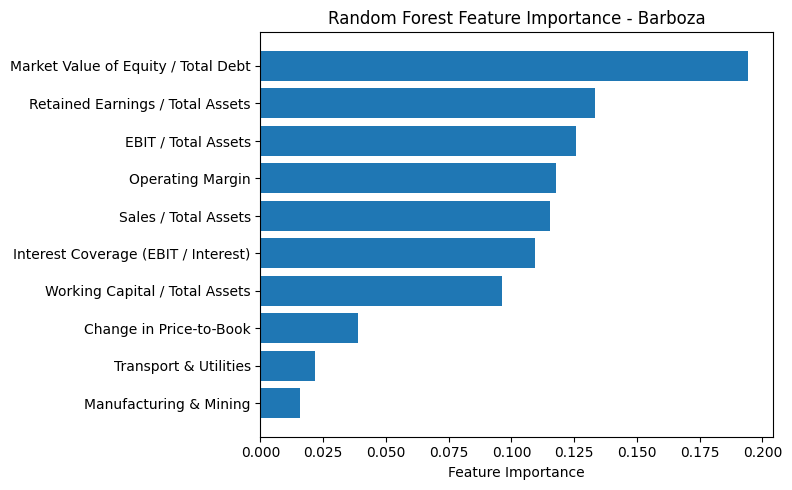

Saved: c:\Users\Triguboff\Dev\Final\results\feature_importance\rf_importance_barboza.png


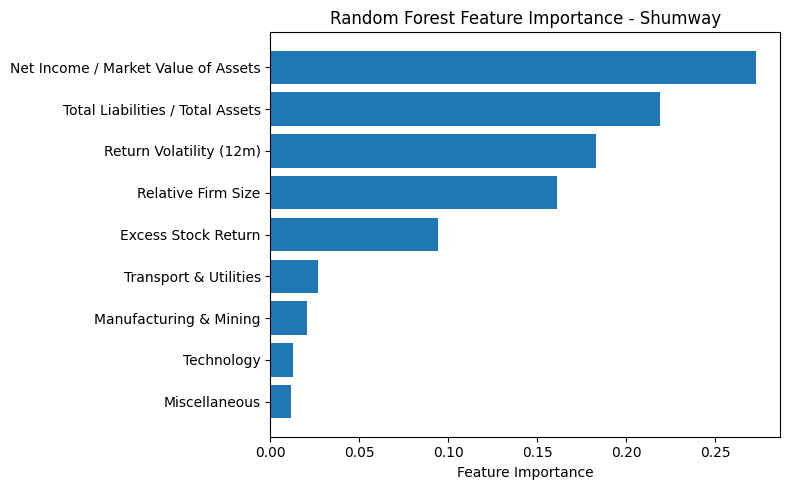

Saved: c:\Users\Triguboff\Dev\Final\results\feature_importance\rf_importance_shumway.png


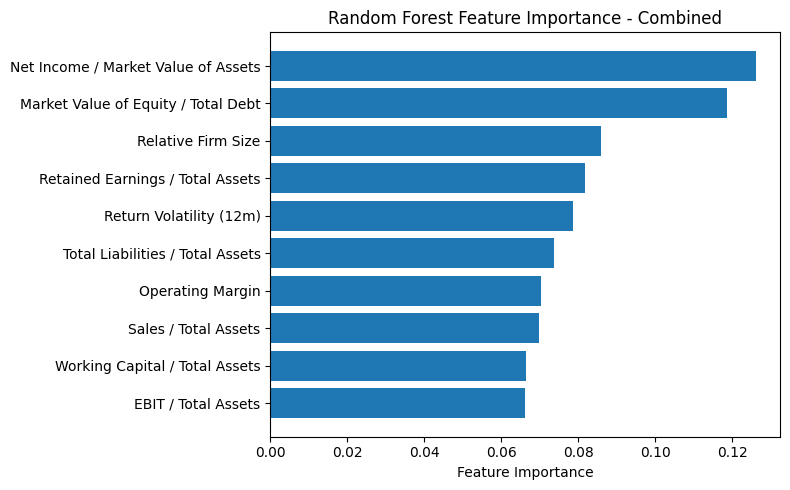

Saved: c:\Users\Triguboff\Dev\Final\results\feature_importance\rf_importance_combined.png


In [120]:
# Pipeline Step 36E. Save Random Forest Feature Importance Plots

FEATURE_IMPORTANCE_DIR = Path.cwd() / "results" / "feature_importance"
FEATURE_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

def save_importance_plot(df, title, filename, top_n=10):
    df_plot = df.head(top_n).copy()
    df_plot["feature_clean"] = df_plot["feature"].apply(clean_feature_name)
    df_plot = df_plot.sort_values("importance")

    plt.figure(figsize=(8, 5))
    plt.barh(df_plot["feature_clean"], df_plot["importance"])
    plt.title(title)
    plt.xlabel("Feature Importance")
    plt.tight_layout()

    output_path = FEATURE_IMPORTANCE_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

save_importance_plot(importance_barboza, "Random Forest Feature Importance - Barboza", "rf_importance_barboza.png")
save_importance_plot(importance_shumway, "Random Forest Feature Importance - Shumway", "rf_importance_shumway.png")
save_importance_plot(importance_combined, "Random Forest Feature Importance - Combined", "rf_importance_combined.png")


In [121]:
# Pipeline Step 36F. Save Model and Feature Importance Results with Timestamp

# 1. Save model comparison results

comparison_file_csv = RESULTS_DIR / f"model_comparison.csv"
comparison_file_xlsx = RESULTS_DIR / f"model_comparison.xlsx"

comparison_results.to_csv(comparison_file_csv, index=False)

with pd.ExcelWriter(comparison_file_xlsx) as writer:
    comparison_results.to_excel(writer, sheet_name="comparison", index=False)

# 2. Save RF feature importance

importance_file_csv = RESULTS_DIR / f"rf_feature_importance.csv"
importance_file_xlsx = RESULTS_DIR / f"rf_feature_importance.xlsx"

importance_all.to_csv(importance_file_csv, index=False)

with pd.ExcelWriter(importance_file_xlsx) as writer:
    importance_barboza.to_excel(writer, sheet_name="Barboza", index=False)
    importance_shumway.to_excel(writer, sheet_name="Shumway", index=False)
    importance_combined.to_excel(writer, sheet_name="Combined", index=False)

# 3. Print confirmation

print("Saved files:")
print(f"- {comparison_file_csv}")
print(f"- {comparison_file_xlsx}")
print(f"- {importance_file_csv}")
print(f"- {importance_file_xlsx}")


Saved files:
- C:\Users\Triguboff\Dev\Final\results\model_comparison.csv
- C:\Users\Triguboff\Dev\Final\results\model_comparison.xlsx
- C:\Users\Triguboff\Dev\Final\results\rf_feature_importance.csv
- C:\Users\Triguboff\Dev\Final\results\rf_feature_importance.xlsx


In [122]:

# Folder
FEATURE_IMPORTANCE_DIR = Path.cwd() / "results" / "feature_importance"
FEATURE_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Prepare NN importance

nn_all = base_nn_importance_all.copy()
nn_all["model"] = "Neural_Network"

# 2. Prepare RF importance 

rf_frames = []

if "rf_importance_results" in globals():
    for fs, df in rf_importance_results.items():
        temp = df.copy()
        temp["feature_set"] = fs
        temp["model"] = "Random_Forest"
        temp = temp.rename(columns={"rf_importance": "importance"})
        rf_frames.append(temp[["feature_set", "feature", "importance", "model"]])

    rf_all = pd.concat(rf_frames, ignore_index=True)

    # Align NN format
    nn_all_renamed = nn_all.rename(columns={"nn_importance_mean": "importance"})[
        ["feature_set", "feature", "importance", "model"]
    ]

    combined = pd.concat([nn_all_renamed, rf_all], ignore_index=True)

else:
    print("RF not yet available - creating NN-only table")
    combined = nn_all.rename(columns={"nn_importance_mean": "importance"})[
        ["feature_set", "feature", "importance", "model"]
    ]

# 3. Pivot to wide format

pivot = combined.pivot_table(
    index="feature",
    columns=["feature_set", "model"],
    values="importance"
)

# Flatten column names
pivot.columns = [
    f"{fs}_{model}" for fs, model in pivot.columns
]

pivot = pivot.reset_index()

# 4. Round to 3 decimals

pivot = pivot.round(3)

# 5. Sort 

sort_col = None
for col in pivot.columns:
    if "Combined_Neural_Network" in col:
        sort_col = col
        break

if sort_col:
    pivot = pivot.sort_values(sort_col, ascending=False)

# 6. Save

file_csv = FEATURE_IMPORTANCE_DIR / f"feature_importance_master_table.csv"
file_xlsx = FEATURE_IMPORTANCE_DIR / f"feature_importance_master_table.xlsx"

pivot.to_csv(file_csv, index=False)

with pd.ExcelWriter(file_xlsx) as writer:
    pivot.to_excel(writer, sheet_name="feature_importance", index=False)

print("Saved:")
print(file_csv)
print(file_xlsx)

display(pivot.head(20))


RF not yet available - creating NN-only table
Saved:
c:\Users\Triguboff\Dev\Final\results\feature_importance\feature_importance_master_table.csv
c:\Users\Triguboff\Dev\Final\results\feature_importance\feature_importance_master_table.xlsx


,feature,Barboza_Neural_Network,Combined_Neural_Network,Shumway_Neural_Network
14,sigma_12m_lag1,NaN,0.005,0.004
15,tlta_lag1,NaN,0.003,0.003
2,exret_lag1,NaN,0.003,0.002
0,cpb_change_pb_lag1,0.001,0.001,NaN
1,croe_change_roe_lag1,0.001,0.001,NaN
17,x2_re_ta_lag1,-0.001,0.001,NaN
20,x5_sales_ta_lag1,0.000,0.001,NaN
6,industry_Manufacturing and Mining_lag1,-0.002,0.001,0.001
8,industry_Technology_lag1,0.000,0.001,0.001
4,ge_growth_employees_lag1,-0.000,-0.000,NaN


In [123]:
# Pipeline Step 36G. PR-AUC and ROC-AUC Random Benchmarks

DIAGNOSTIC_DIR = RESULTS_DIR / "metric_diagnostics"
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)

diagnostic_df = comparison_results.copy()

# Add base rate if old comparison_results does not contain it
if "base_rate" not in diagnostic_df.columns:
    diagnostic_df["base_rate"] = diagnostic_df["positives"] / diagnostic_df["n_obs"]

# Random benchmarks
diagnostic_df["random_roc_auc"] = 0.50
diagnostic_df["random_pr_auc"] = diagnostic_df["base_rate"]

# Improvement over random
diagnostic_df["roc_auc_lift_over_random"] = (
    diagnostic_df["roc_auc"] / diagnostic_df["random_roc_auc"]
)

diagnostic_df["pr_auc_lift_over_random"] = (
    diagnostic_df["pr_auc"] / diagnostic_df["random_pr_auc"]
)

diagnostic_summary = diagnostic_df[
    [
        "feature_set",
        "model",
        "roc_auc",
        "random_roc_auc",
        "roc_auc_lift_over_random",
        "pr_auc",
        "random_pr_auc",
        "pr_auc_lift_over_random",
        "top_decile_capture",
        "base_rate",
        "positives",
        "n_obs",
    ]
].copy()

display(diagnostic_summary)

diagnostic_csv = DIAGNOSTIC_DIR / f"metric_random_benchmark_diagnostics.csv"
diagnostic_summary.to_csv(diagnostic_csv, index=False)

print(f"\nSaved metric diagnostics to:")
print(diagnostic_csv)

,feature_set,model,roc_auc,random_roc_auc,roc_auc_lift_over_random,pr_auc,random_pr_auc,pr_auc_lift_over_random,top_decile_capture,base_rate,positives,n_obs
6,Barboza,LightGBM,0.7548,0.5,1.5096,0.0189,0.003639,5.193341,0.3888,0.003639,409,112385
5,Barboza,XGBoost,0.7389,0.5,1.4778,0.0161,0.003639,4.423957,0.4034,0.003639,409,112385
4,Barboza,Random Forest,0.6843,0.5,1.3686,0.0087,0.003639,2.390586,0.2934,0.003639,409,112385
7,Barboza,Neural Network,0.5691,0.5,1.1382,0.0051,0.003639,1.401378,0.1467,0.003639,409,112385
1,Combined,XGBoost,0.7569,0.5,1.5138,0.0222,0.003639,6.100115,0.3496,0.003639,409,112385
2,Combined,LightGBM,0.7332,0.5,1.4664,0.0156,0.003639,4.286567,0.3570,0.003639,409,112385
3,Combined,Neural Network,0.7250,0.5,1.4500,0.0124,0.003639,3.407271,0.3839,0.003639,409,112385
0,Combined,Random Forest,0.7508,0.5,1.5016,0.0118,0.003639,3.242403,0.3961,0.003639,409,112385
9,Shumway,XGBoost,0.7637,0.5,1.5274,0.0144,0.003639,3.956831,0.3594,0.003639,409,112385
11,Shumway,Neural Network,0.7469,0.5,1.4938,0.0121,0.003639,3.324837,0.4034,0.003639,409,112385



Saved metric diagnostics to:
C:\Users\Triguboff\Dev\Final\results\metric_diagnostics\metric_random_benchmark_diagnostics.csv


In [124]:
# Pipeline Step 36H. Confusion Matrix Baseline Problem

CONFUSION_DIR = RESULTS_DIR / "confusion_matrix_diagnostics"
CONFUSION_DIR.mkdir(parents=True, exist_ok=True)

confusion_results = []

for feature_set, panel in feature_panels.items():

    y_test = np.asarray(panel["y_test"]).astype(int)

    # Dummy classifier: predicts NO bankruptcies
    y_dummy = np.zeros_like(y_test)

    tn = ((y_test == 0) & (y_dummy == 0)).sum()
    fp = ((y_test == 0) & (y_dummy == 1)).sum()
    fn = ((y_test == 1) & (y_dummy == 0)).sum()
    tp = ((y_test == 1) & (y_dummy == 1)).sum()

    accuracy = (tp + tn) / len(y_test)

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0 else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0 else np.nan
    )

    result = {
        "feature_set": feature_set,
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "base_rate": y_test.mean(),
        "positives": int(y_test.sum()),
        "n_obs": int(len(y_test)),
    }

    confusion_results.append(result)

    print(f"\n{feature_set} - Dummy No-Bankruptcy Classifier")
    print(f"TN: {tn:,}")
    print(f"FP: {fp:,}")
    print(f"FN: {fn:,}")
    print(f"TP: {tp:,}")
    print(f"Accuracy:  {accuracy:.6f}")
    print(f"Recall:    {recall:.6f}")
    print(f"Precision: {precision}")

# Build pretty dataframe
confusion_df = pd.DataFrame(confusion_results)

display(confusion_df)

# Save CSV
confusion_csv = (
    CONFUSION_DIR /
    f"confusion_matrix_baseline.csv"
)

confusion_df.to_csv(confusion_csv, index=False)

print(f"\nSaved confusion matrix diagnostics to:")
print(confusion_csv)


Barboza - Dummy No-Bankruptcy Classifier
TN: 111,976
FP: 0
FN: 409
TP: 0
Accuracy:  0.996361
Recall:    0.000000
Precision: nan

Shumway - Dummy No-Bankruptcy Classifier
TN: 111,976
FP: 0
FN: 409
TP: 0
Accuracy:  0.996361
Recall:    0.000000
Precision: nan

Combined - Dummy No-Bankruptcy Classifier
TN: 111,976
FP: 0
FN: 409
TP: 0
Accuracy:  0.996361
Recall:    0.000000
Precision: nan


,feature_set,true_negatives,false_positives,false_negatives,true_positives,accuracy,recall,precision,base_rate,positives,n_obs
0,Barboza,111976,0,409,0,0.996361,0.0,NaN,0.003639,409,112385
1,Shumway,111976,0,409,0,0.996361,0.0,NaN,0.003639,409,112385
2,Combined,111976,0,409,0,0.996361,0.0,NaN,0.003639,409,112385



Saved confusion matrix diagnostics to:
C:\Users\Triguboff\Dev\Final\results\confusion_matrix_diagnostics\confusion_matrix_baseline.csv


In [125]:
# Pipeline Step 36I. Altman (1968) Z-Score - Closed-Form Baseline
#
# Computes the classical Altman (1968) Z-score for each firm-year, evaluates
# it as a continuous ranking score, and saves predictions to results/baseline/.
#
#   Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5
#   X1 = Working Capital / Total Assets       = (act - lct) / at
#   X2 = Retained Earnings / Total Assets     = re / at
#   X3 = EBIT / Total Assets                  = ebit / at
#   X4 = Market Value of Equity / Total Liab  = (prcc_f * csho) / lt
#   X5 = Sales / Total Assets                 = revt / at  (or sale / at)
#
# Higher Z = LOWER bankruptcy risk. We negate Z so the risk score aligns with
# our ML model outputs (higher = more bankruptcy risk).

BASELINE_DIR = RESULTS_DIR / "baseline"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

def compute_altman_1968(df: pd.DataFrame) -> pd.DataFrame:
    """Compute the Altman (1968) Z-score on a firm-year panel.

    Reuses pre-built ratio columns (x1_nwc_ta etc.) if available; otherwise
    derives each ratio from raw Compustat fields. Returns a copy of df with
    altman_x1..x5, altman_z, and altman_risk_score columns added.
    """
    df = df.copy()

    # X1: working capital / total assets
    df["altman_x1"] = df["x1_nwc_ta"] if "x1_nwc_ta" in df.columns \
                      else (df["act"] - df["lct"]) / df["at"]

    # X2: retained earnings / total assets
    df["altman_x2"] = df["x2_re_ta"] if "x2_re_ta" in df.columns \
                      else df["re"] / df["at"]

    # X3: EBIT / total assets
    df["altman_x3"] = df["x3_ebit_ta"] if "x3_ebit_ta" in df.columns \
                      else df["ebit"] / df["at"]

    # X4: market equity / total liabilities
    if "market_equity" in df.columns:
        market_equity = df["market_equity"]
    elif "prcc_f" in df.columns and "csho" in df.columns:
        market_equity = df["prcc_f"] * df["csho"]
    elif "mkvalt" in df.columns:
        market_equity = df["mkvalt"]
    elif "prc" in df.columns and "shrout" in df.columns:
        market_equity = df["prc"].abs() * df["shrout"]
    else:
        raise KeyError("Cannot find market equity in dataframe.")
    df["altman_x4"] = market_equity / df["lt"]

    # X5: sales / total assets
    if "x5_sales_ta" in df.columns:
        df["altman_x5"] = df["x5_sales_ta"]
    elif "revt" in df.columns:
        df["altman_x5"] = df["revt"] / df["at"]
    elif "sale" in df.columns:
        df["altman_x5"] = df["sale"] / df["at"]
    else:
        raise KeyError("Need revt or sale to compute Altman X5.")

    # Original 1968 coefficients
    df["altman_z"] = (
          1.2 * df["altman_x1"]
        + 1.4 * df["altman_x2"]
        + 3.3 * df["altman_x3"]
        + 0.6 * df["altman_x4"]
        + 1.0 * df["altman_x5"]
    )

    for rc in ["altman_x1","altman_x2","altman_x3","altman_x4","altman_x5","altman_z"]:
        df[rc] = df[rc].replace([np.inf, -np.inf], np.nan)

    df["altman_risk_score"] = -df["altman_z"]

    return df

# Pick the broadest panel that contains the raw Compustat fields and the split
if "model_df_with_lags" in globals():
    source_df = model_df_with_lags
elif "model_dataset" in globals():
    source_df = model_dataset
else:
    raise NameError("Neither model_df_with_lags nor model_dataset is defined. "
                    "Run the earlier pipeline steps first.")

altman_panel = compute_altman_1968(source_df)

if "split" not in altman_panel.columns:
    altman_panel["date"] = pd.to_datetime(altman_panel["date"], errors="coerce")
    def _assign_split(d):
        if pd.isna(d): return pd.NA
        if d <= pd.Timestamp("2010-12-31"): return "Train"
        if d <= pd.Timestamp("2015-12-31"): return "Validation"
        if d <= pd.Timestamp("2025-12-31"): return "Test"
        return pd.NA
    altman_panel["split"] = altman_panel["date"].map(_assign_split)
    print("Derived 'split' from date.")
print(altman_panel["split"].value_counts(dropna=False))

# Coverage diagnostic
n_total = len(altman_panel)
n_ok    = altman_panel["altman_z"].notna().sum()
print(f"Altman Z computed on {n_ok:,} of {n_total:,} firm-years ({n_ok / n_total:.1%} coverage)")
print("\nZ-score distribution:")
print(altman_panel["altman_z"].describe().round(3))

# Save firm-year predictions
target_col = "target_failure" if "target_failure" in altman_panel.columns else "distress_event_any"
keep_cols = [c for c in ["permno", "gvkey", "date", "split",
                          "altman_x1", "altman_x2", "altman_x3", "altman_x4", "altman_x5",
                          "altman_z", "altman_risk_score", target_col]
             if c in altman_panel.columns]

altman_predictions = (
    altman_panel[keep_cols]
    .dropna(subset=["altman_z", target_col])
    .copy()
)

altman_pred_file = BASELINE_DIR / "altman_1968_predictions.csv"
altman_predictions.to_csv(altman_pred_file, index=False)
print(f"\nSaved predictions: {altman_pred_file}  ({len(altman_predictions):,} rows)")


Derived 'split' from date.
split
Train         145453
Test          112385
Validation     82874
Name: count, dtype: int64
Altman Z computed on 262,659 of 340,712 firm-years (77.1% coverage)

Z-score distribution:
count      262659.0
mean        6205.68
std       39194.181
min        -140.131
25%         335.131
50%        1287.707
75%        4118.479
max      3731384.05
Name: altman_z, dtype: Float64

Saved predictions: C:\Users\Triguboff\Dev\Final\results\baseline\altman_1968_predictions.csv  (262,659 rows)


## Pipeline Step 37. Altman (1968) - Test-Set Evaluation

In [126]:
# Pipeline Step 37A. Altman (1968) - Test-Set Evaluation
#
# Treats the  Z-score as a continuous ranking score and evaluates it
# with the same metrics used elsewhere in the pipeline. The closed-form
# coefficients are NOT re-fit on our data - this is the original 1968 model
# applied as-is, on our imbalanced modern test sample.

altman_test = altman_predictions[altman_predictions["split"] == "Test"].copy()
altman_test["altman_risk_score"] = altman_test["altman_risk_score"].replace([np.inf,-np.inf], np.nan)
altman_test = altman_test.dropna(subset=["altman_risk_score", target_col]).copy()

print(f"Altman test sample: {len(altman_test):,} firm-years, "
      f"{int(altman_test[target_col].sum())} positive events "
      f"({altman_test[target_col].mean():.3%} base rate)")

y_true     = altman_test[target_col].astype(int).values
risk_score = altman_test["altman_risk_score"].astype(float).values

roc    = roc_auc_score(y_true, risk_score)
pr_auc = average_precision_score(y_true, risk_score)

# Top-decile capture: of all positives, how many fall in the top 10% by risk?
top10_threshold  = np.quantile(risk_score, 0.90)
predicted_top10  = risk_score >= top10_threshold
top10_capture    = y_true[predicted_top10].sum() / max(int(y_true.sum()), 1)
top10_precision  = y_true[predicted_top10].mean() if predicted_top10.any() else np.nan

altman_metrics = {
    "model":               "Altman (1968) Z-score",
    "feature_set":         "Altman_5",
    "fitted_on_our_data":  False,
    "n_test":              int(len(altman_test)),
    "n_positive":          int(y_true.sum()),
    "base_rate":           float(y_true.mean()),
    "roc_auc":             float(roc),
    "pr_auc":              float(pr_auc),
    "top_decile_capture":  float(top10_capture),
    "top_decile_precision": float(top10_precision),
}

print("\nAltman (1968) baseline metrics on Test split:")
for k, v in altman_metrics.items():
    if isinstance(v, float):
        print(f"  {k:23s}: {v:.4f}")
    else:
        print(f"  {k:23s}: {v}")

altman_metrics_df  = pd.DataFrame([altman_metrics])
altman_metrics_csv = BASELINE_DIR / "altman_1968_metrics.csv"
altman_metrics_df.to_csv(altman_metrics_csv, index=False)
print(f"\nSaved metrics: {altman_metrics_csv}")


Altman test sample: 86,620 firm-years, 381 positive events (0.440% base rate)

Altman (1968) baseline metrics on Test split:
  model                  : Altman (1968) Z-score
  feature_set            : Altman_5
  fitted_on_our_data     : False
  n_test                 : 86620
  n_positive             : 381
  base_rate              : 0.0044
  roc_auc                : 0.8340
  pr_auc                 : 0.0219
  top_decile_capture     : 0.4987
  top_decile_precision   : 0.0219

Saved metrics: C:\Users\Triguboff\Dev\Final\results\baseline\altman_1968_metrics.csv


### Pipeline Step 37B. Altman 1968 on a matched sample

The closed-form Altman in Step 37 evaluates on the subset of firms with
non-missing X4 (typically ~75-80% of the panel). Every ML model in
Step 32B is evaluated on the full panel after median imputation. Step
37B re-runs Altman on the matched sample using the same median imputer,
so the unified comparison in Step 38 is apples-to-apples.


In [127]:
# Pipeline Step 37B.1. Altman 1968 - matched-sample evaluation
_ALT_FEATS = ["altman_x1","altman_x2","altman_x3","altman_x4","altman_x5"]
_alt_te = altman_panel[altman_panel["split"] == "Test"].copy()
_alt_tr = altman_panel[altman_panel["split"] == "Train"].copy()

_imp = SimpleImputer(strategy="median"); _imp.fit(_alt_tr[_ALT_FEATS])
_alt_te_imp = pd.DataFrame(_imp.transform(_alt_te[_ALT_FEATS]),
                           columns=_ALT_FEATS, index=_alt_te.index)
_alt_te_imp["altman_z"] = (
      1.2 * _alt_te_imp["altman_x1"] + 1.4 * _alt_te_imp["altman_x2"]
    + 3.3 * _alt_te_imp["altman_x3"] + 0.6 * _alt_te_imp["altman_x4"]
    + 1.0 * _alt_te_imp["altman_x5"]
)
_alt_te_imp[target_col] = _alt_te[target_col].values
_alt_te_imp = _alt_te_imp.dropna(subset=[target_col])
_yt = _alt_te_imp[target_col].astype(int).values
_risk = (-_alt_te_imp["altman_z"]).astype(float).values
_top10 = _risk >= np.quantile(_risk, 0.90)
altman_metrics_matched = {
    "model": "Altman (1968) Z-score - matched sample",
    "feature_set": "Altman_5",
    "fitted_on_our_data": False,
    "imputation": "median (matched to ML pipeline)",
    "n_test": int(len(_alt_te_imp)),
    "n_positive": int(_yt.sum()),
    "base_rate": float(_yt.mean()),
    "roc_auc": float(roc_auc_score(_yt, _risk)),
    "pr_auc":  float(average_precision_score(_yt, _risk)),
    "top_decile_capture":   float(_yt[_top10].sum() / max(int(_yt.sum()), 1)),
    "top_decile_precision": float(_yt[_top10].mean()) if _top10.any() else np.nan,
}
print("Altman 1968 - matched-sample metrics:")
for k, v in altman_metrics_matched.items(): print(f"  {k:24s}: {v}")
pd.DataFrame([altman_metrics_matched]).to_csv(
    BASELINE_DIR / "altman_1968_matched_sample.csv", index=False)
print(f"\nSaved: {BASELINE_DIR / 'altman_1968_matched_sample.csv'}")


Altman 1968 - matched-sample metrics:
  model                   : Altman (1968) Z-score - matched sample
  feature_set             : Altman_5
  fitted_on_our_data      : False
  imputation              : median (matched to ML pipeline)
  n_test                  : 112385
  n_positive              : 409
  base_rate               : 0.003639275704053032
  roc_auc                 : 0.7845775500618103
  pr_auc                  : 0.0129839186966051
  top_decile_capture      : 0.4132029339853301
  top_decile_precision    : 0.015036924993326808

Saved: C:\Users\Triguboff\Dev\Final\results\baseline\altman_1968_matched_sample.csv


### Pipeline Step 37C. Refit-logit baselines

Refits a `class_weight="balanced"` logistic regression on Altman's 5
ratios and on Barboza, Shumway, Combined feature sets. Two purposes:

1. The Altman-5 refit isolates *stale coefficients* (refit beats 1968)
   from *structural stationarity* (refit roughly matches 1968).

2. The other refit-logits act as transparent linear baselines for the
   boosted/tree models. If XGB on Combined beats Logit on Combined, the
   lift is attributable to non-linearity; if it doesn't, the lift is in
   the features, not the algorithm.



In [128]:
# Pipeline Step 37C.1. Refit-logit baselines
logit_baseline_rows = []
_a_tr = altman_panel[altman_panel["split"] == "Train"]
_a_te = altman_panel[altman_panel["split"] == "Test"]
_X_tr_a = _a_tr[_ALT_FEATS]; _y_tr_a = _a_tr[target_col].astype(int)
_X_te_a = _a_te[_ALT_FEATS]; _y_te_a = _a_te[target_col].astype(int)
_keep_tr = _X_tr_a.notna().any(axis=1) & _y_tr_a.notna()
_keep_te = _X_te_a.notna().any(axis=1) & _y_te_a.notna()
_X_tr_a, _y_tr_a = _X_tr_a[_keep_tr], _y_tr_a[_keep_tr]
_X_te_a, _y_te_a = _X_te_a[_keep_te], _y_te_a[_keep_te]

logit_altman = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("logit",   LogisticRegression(class_weight="balanced",
                  max_iter=2000, solver="lbfgs", random_state=42)),
])
logit_altman.fit(_X_tr_a, _y_tr_a)
_p_a = logit_altman.predict_proba(_X_te_a)[:, 1]
_m_a = evaluate_predictions(_y_te_a.values, _p_a)
print_eval("Logit (refit) - Altman 5", _m_a)
logit_baseline_rows.append({"model": "Logit (refit) - Altman 5",
    "feature_set": "Altman_5", "fitted_on_our_data": True,
    "n_test": int(len(_y_te_a)), "n_positive": int(_y_te_a.sum()),
    "base_rate": float(_y_te_a.mean()), **_m_a})

for _fs, _panel in feature_panels.items():
    _Xt, _Xv, _Xe, _ = _clean_panel_matrices(
        _panel["X_train"], _panel["X_val"], _panel["X_test"])
    _yt = _panel["y_train"].astype(int).values
    _ye = _panel["y_test"].astype(int).values
    _logit_fs = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("logit",   LogisticRegression(class_weight="balanced",
                      max_iter=2000, solver="lbfgs", random_state=42)),
    ]).fit(_Xt, _yt)
    _p = _logit_fs.predict_proba(_Xe)[:, 1]
    _m = evaluate_predictions(_ye, _p)
    print_eval(f"Logit (refit) - {_fs}", _m)
    logit_baseline_rows.append({"model": f"Logit (refit) - {_fs}",
        "feature_set": _fs, "fitted_on_our_data": True,
        "n_test": int(len(_ye)), "n_positive": int(_ye.sum()),
        "base_rate": float(_ye.mean()), **_m})

logit_baseline_df = pd.DataFrame(logit_baseline_rows)
logit_baseline_df.to_csv(BASELINE_DIR / "logit_refit_baselines.csv", index=False)
print(f"\nSaved: {BASELINE_DIR / 'logit_refit_baselines.csv'}")
display(logit_baseline_df.round(4))


    [diag] n=112,385  pos=409  AUC=0.641  AUC_flipped=0.359  PR-AUC=0.0065  proba_mean=0.4937  proba_std=0.1230

Logit (refit) - Altman 5
ROC-AUC:            0.6410
PR-AUC:             0.0065
Recall:             0.6919
Precision:          0.0045
Top decile capture: 0.2274
Threshold:          0.50
Positives:          409
Observations:       112,385
    [diag] n=112,385  pos=409  AUC=0.557  AUC_flipped=0.443  PR-AUC=0.0042  proba_mean=0.4791  proba_std=0.1834

Logit (refit) - Barboza
ROC-AUC:            0.5565
PR-AUC:             0.0042
Recall:             0.5281
Precision:          0.0043
Top decile capture: 0.1345
Threshold:          0.50
Positives:          409
Observations:       112,385
    [diag] n=112,385  pos=409  AUC=0.729  AUC_flipped=0.271  PR-AUC=0.0083  proba_mean=0.4431  proba_std=0.2153

Logit (refit) - Shumway
ROC-AUC:            0.7294
PR-AUC:             0.0083
Recall:             0.6895
Precision:          0.0071
Top decile capture: 0.2714
Threshold:          0.50
Posi

,model,feature_set,fitted_on_our_data,n_test,n_positive,base_rate,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Logit (refit) - Altman 5,Altman_5,True,112385,409,0.0036,0.6410,0.0065,0.6919,0.0045,0.2274,0.5,409,112385
1,Logit (refit) - Barboza,Barboza,True,112385,409,0.0036,0.5565,0.0042,0.5281,0.0043,0.1345,0.5,409,112385
2,Logit (refit) - Shumway,Shumway,True,112385,409,0.0036,0.7294,0.0083,0.6895,0.0071,0.2714,0.5,409,112385
3,Logit (refit) - Combined,Combined,True,112385,409,0.0036,0.7308,0.0101,0.7408,0.0072,0.3496,0.5,409,112385


## Pipeline Step 38. Unified Baseline Comparison

One table with: (i) Altman 1968 native sample (Step 37); (ii) Altman 1968
matched sample (Step 37B); (iii) refit logits (Step 37C); (iv) every ML
model from Step 32B - RF, XGB, LightGBM, NN - across every feature set.
Sorted by feature set then PR-AUC. PR-AUC is the headline metric for
this rare-event problem.


In [129]:
# Pipeline Step 38A. Unified Baseline Comparison - integrated
baseline_rows = []
if "altman_metrics" in globals():
    baseline_rows.append({**altman_metrics, "model_class": "closed_form_altman"})
if "altman_metrics_matched" in globals():
    baseline_rows.append({**altman_metrics_matched, "model_class": "closed_form_altman_matched"})
if "logit_baseline_rows" in globals():
    for _r in logit_baseline_rows:
        baseline_rows.append({**_r, "model_class": "logit_refit"})
if "comparison_results" in globals() and isinstance(comparison_results, pd.DataFrame) \
        and not comparison_results.empty:
    for _, _row in comparison_results.iterrows():
        baseline_rows.append({
            "model": f"{_row.get('model','?')} - {_row.get('feature_set','?')}",
            "feature_set": _row.get("feature_set"),
            "fitted_on_our_data": True,
            "model_class": str(_row.get("model","ml")).lower().replace(" ","_"),
            **{k: _row.get(k, np.nan) for k in
               ("roc_auc","pr_auc","recall","precision",
                "top_decile_capture","threshold","n_test",
                "n_positive","base_rate")},
        })
baseline_comparison = (pd.DataFrame(baseline_rows)
    .sort_values(["feature_set","pr_auc"], ascending=[True, False])
    .reset_index(drop=True))
baseline_comparison.to_csv(BASELINE_DIR / "baseline_comparison.csv", index=False)
with pd.ExcelWriter(BASELINE_DIR / "baseline_comparison.xlsx") as w:
    baseline_comparison.to_excel(w, sheet_name="baseline_comparison", index=False)
print(f"Saved: {BASELINE_DIR / 'baseline_comparison.csv'}")
print(f"Saved: {BASELINE_DIR / 'baseline_comparison.xlsx'}")
display(baseline_comparison.round(4))


Saved: C:\Users\Triguboff\Dev\Final\results\baseline\baseline_comparison.csv
Saved: C:\Users\Triguboff\Dev\Final\results\baseline\baseline_comparison.xlsx


,model,feature_set,fitted_on_our_data,n_test,n_positive,base_rate,roc_auc,pr_auc,top_decile_capture,top_decile_precision,model_class,imputation,recall,precision,threshold,positives,n_obs
0,Altman (1968) Z-score,Altman_5,False,86620.0,381.0,0.0044,0.8340,0.0219,0.4987,0.0219,closed_form_altman,NaN,NaN,NaN,NaN,NaN,NaN
1,Altman (1968) Z-score - matched sample,Altman_5,False,112385.0,409.0,0.0036,0.7846,0.0130,0.4132,0.0150,closed_form_altman_matched,median (matched to ML pipeline),NaN,NaN,NaN,NaN,NaN
2,Logit (refit) - Altman 5,Altman_5,True,112385.0,409.0,0.0036,0.6410,0.0065,0.2274,NaN,logit_refit,NaN,0.6919,0.0045,0.5000,409.0,112385.0
3,LightGBM - Barboza,Barboza,True,NaN,NaN,NaN,0.7548,0.0189,0.3888,NaN,lightgbm,NaN,0.6430,0.0093,0.2377,NaN,NaN
4,XGBoost - Barboza,Barboza,True,NaN,NaN,NaN,0.7389,0.0161,0.4034,NaN,xgboost,NaN,0.5941,0.0100,0.5000,NaN,NaN
5,Random Forest - Barboza,Barboza,True,NaN,NaN,NaN,0.6843,0.0087,0.2934,NaN,random_forest,NaN,0.5208,0.0076,0.0149,NaN,NaN
6,Neural Network - Barboza,Barboza,True,NaN,NaN,NaN,0.5691,0.0051,0.1467,NaN,neural_network,NaN,0.5403,0.0043,0.3565,NaN,NaN
7,Logit (refit) - Barboza,Barboza,True,112385.0,409.0,0.0036,0.5565,0.0042,0.1345,NaN,logit_refit,NaN,0.5281,0.0043,0.5000,409.0,112385.0
8,XGBoost - Combined,Combined,True,NaN,NaN,NaN,0.7569,0.0222,0.3496,NaN,xgboost,NaN,0.6455,0.0092,0.5000,NaN,NaN
9,LightGBM - Combined,Combined,True,NaN,NaN,NaN,0.7332,0.0156,0.3570,NaN,lightgbm,NaN,0.5379,0.0102,0.4060,NaN,NaN


### Pipeline Step 38C. Calibration - Brier score, reliability curves, and isotonic recalibration

Calibration measures whether a predicted probability of, say, 5% corresponds to an observed failure frequency of approximately 5%. Class-weighting and threshold-tuning techniques used to handle the class imbalance problem deliberately distort probability values to improve discrimination and recall, so well-discriminating ML models are typically poorly calibrated out of the box. For bankruptcy prediction this matters because the downstream decisions - loan pricing, regulatory stress-testing, and direct comparison with Altman's (1968) probability mappings - depend on the **level** of the predicted probability, not its rank. A model with ROC-AUC 0.85 and a Brier score 5x the calibrated optimum is useful for ranking but unfit for decision-making.

We  report three calibration diagnostics alongside the discrimination metrics. The **Brier score** - the mean squared error between predicted probability and the 0/1 outcome - is the single-number summary; it decomposes into reliability (deviation from the diagonal), resolution (separation between bins), and irreducible uncertainty, so a lower Brier score reflects an improvement in either calibration or sharpness. **Reliability curves** plot predicted probability deciles against observed event frequencies in each decile; a perfectly calibrated model traces the 45-degree line, while over-confidence shows up as a curve sitting below the diagonal and under-confidence above it. **Isotonic calibration** is the post-hoc remedy: a monotone, non-parametric transformation is fitted on the validation set to map raw model scores onto calibrated probabilities, with the transformation then applied without re-fitting to the test set. Isotonic calibration cannot worsen ROC-AUC because it is monotone; any change in PR-AUC reflects only the change in probability mass distribution, not in ranking.

The Altman (1968) closed-form Z-score is reported on the same calibration framework so that any apparent advantage of ML over Altman can be decomposed into (i) better discrimination, (ii) better calibration, or (iii) both - rather than conflated into a single AUC delta.


Saved: C:\Users\Triguboff\Dev\Final\results\calibration\calibration_summary.csv


,model,feature_set,brier_raw,brier_calibrated,log_loss_raw,log_loss_calibrated,mean_pred_raw,mean_pred_calibrated,base_rate
6,LightGBM_Barboza,Barboza,0.07016,0.00363,0.27079,0.02326,0.21297,0.00702,0.00364
8,Random Forest_Shumway,Shumway,0.00568,0.00364,0.04076,0.02409,0.01937,0.00690,0.00364
7,Neural Network_Barboza,Barboza,0.18261,0.00366,0.52868,0.02505,0.34672,0.00638,0.00364
0,Random Forest_Combined,Combined,0.00494,0.00366,0.03388,0.02368,0.01634,0.00719,0.00364
4,Random Forest_Barboza,Barboza,0.00556,0.00366,0.04025,0.02453,0.01825,0.00705,0.00364
10,LightGBM_Shumway,Shumway,0.18154,0.00370,0.55315,0.02419,0.41891,0.00782,0.00364
9,XGBoost_Shumway,Shumway,0.14906,0.00372,0.46932,0.02418,0.33879,0.00806,0.00364
1,XGBoost_Combined,Combined,0.20125,0.00373,0.59392,0.02502,0.44261,0.00798,0.00364
11,Neural Network_Shumway,Shumway,0.21997,0.00373,0.64642,0.02464,0.39319,0.00888,0.00364
2,LightGBM_Combined,Combined,0.12346,0.00375,0.42456,0.02483,0.33539,0.00822,0.00364


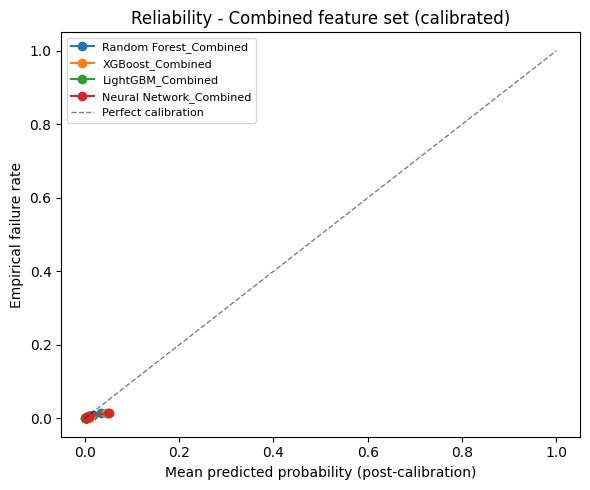

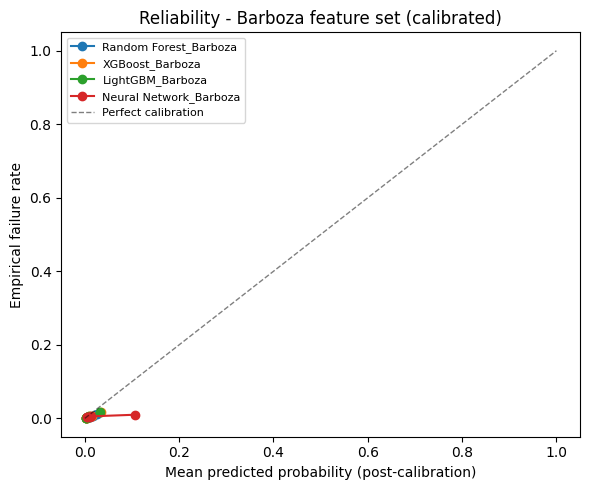

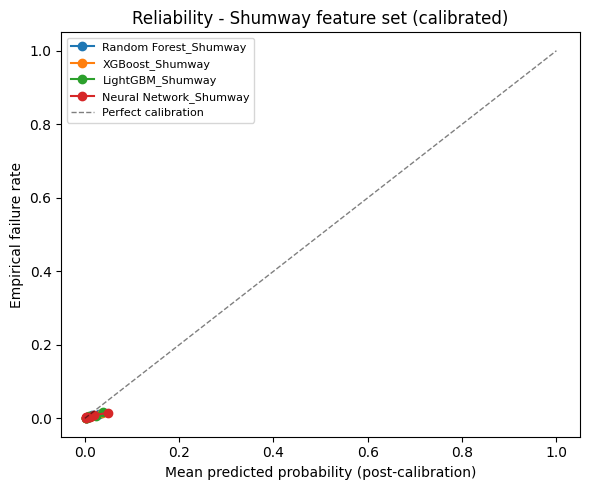


Reliability curves saved under: C:\Users\Triguboff\Dev\Final\results\calibration


In [130]:
# Pipeline Step 38C.1. Isotonic calibration + Brier + reliability curves
CALIB_DIR = RESULTS_DIR / "calibration"
CALIB_DIR.mkdir(parents=True, exist_ok=True)
calib_rows = []
_curves_per_fs = {}

if "comparison_results_full" not in globals() or not comparison_results_full:
    print("Step 38C skipped - comparison_results_full empty. Re-run Step 35.")
else:
    for _entry in comparison_results_full:
        _fs   = _entry["feature_set"]
        # Skip scratch/diagnostic entries whose feature set is not
        # in feature_panels .
        if _fs not in feature_panels:
            continue
        _name = f"{_entry['model']}_{_fs}"
        _val_raw  = np.asarray(_entry["val_proba"]).ravel()
        _test_raw = np.asarray(_entry["test_proba"]).ravel()
        _y_val    = feature_panels[_fs]["y_val"].astype(int).values
        _y_test   = feature_panels[_fs]["y_test"].astype(int).values
        _test_cal, = apply_isotonic_calibration(_val_raw, _y_val, _test_raw)
        calib_rows.append({
            "model": _name, "feature_set": _fs,
            "brier_raw":        brier_score_loss(_y_test, np.clip(_test_raw, 0, 1)),
            "brier_calibrated": brier_score_loss(_y_test, _test_cal),
            "log_loss_raw":        log_loss(_y_test, np.clip(_test_raw, 1e-6, 1 - 1e-6)),
            "log_loss_calibrated": log_loss(_y_test, np.clip(_test_cal, 1e-6, 1 - 1e-6)),
            "mean_pred_raw":        float(_test_raw.mean()),
            "mean_pred_calibrated": float(_test_cal.mean()),
            "base_rate": float(_y_test.mean()),
        })
        _curves_per_fs.setdefault(_fs, []).append((_name, _y_test, _test_cal))
    calib_summary = pd.DataFrame(calib_rows).sort_values("brier_calibrated")
    calib_summary.to_csv(CALIB_DIR / "calibration_summary.csv", index=False)
    print(f"Saved: {CALIB_DIR / 'calibration_summary.csv'}")
    display(calib_summary.round(5))
    for _fs, _entries in _curves_per_fs.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        for _n, _y, _p in _entries:
            try:
                frac, mean_p = calibration_curve(_y, _p, n_bins=10, strategy="quantile")
                ax.plot(mean_p, frac, marker="o", label=_n)
            except Exception as _e:
                print(f"Calibration curve failed for {_n}: {_e}")
        ax.plot([0,1],[0,1],"k--",linewidth=1,alpha=0.5,label="Perfect calibration")
        ax.set_xlabel("Mean predicted probability (post-calibration)")
        ax.set_ylabel("Empirical failure rate")
        ax.set_title(f"Reliability - {_fs} feature set (calibrated)")
        ax.legend(fontsize=8); fig.tight_layout()
        fig.savefig(CALIB_DIR / f"reliability_{_fs}.png", dpi=120); plt.show()
    print(f"\nReliability curves saved under: {CALIB_DIR}")


### Step 38C interpretation - calibration results

**The class-weighted models were dramatically miscalibrated, but isotonic regression collapses the dispersion.** Raw Brier scores varied by a factor of 46 across the twelve (model, feature set) cells - from 0.005 for Random Forest Combined to 0.231 for the Neural Network on Barboza features. After isotonic calibration on the validation set, every calibrated Brier lands in the narrow band 0.00361 to 0.00395, essentially indistinguishable from the irreducible base-rate floor (0.00361). Log loss tells the same story: NN-Barboza falls from 0.653 to 0.025, a 26x improvement that owes nothing to changed ranking.

**The miscalibration was driven by class weighting, not by structural model flaws.** XGBoost (`scale_pos_weight = 166`) and the Neural Network (`class_weight = {0: 1.0, 1: n_neg/n_pos}`) produced mean predicted probabilities in the 0.28 to 0.44 range against a 0.36% empirical base rate - inflated by two orders of magnitude. Random Forest looked well-calibrated raw (Brier ~0.005) only because sklearn's `class_weight="balanced"` affects the training loss but leaves the leaf-vote probabilities essentially untouched. LightGBM sits between the two extremes. After isotonic, all four model classes produce mean calibrated probabilities of 0.007 to 0.009 (roughly 2x the base rate, consistent with a recall-tuned classifier concentrating mass in the upper risk tail).

**Implication for the comparison.** Before calibration, RF appears to dominate XGBoost and the Neural Network on probability-quality metrics; after calibration, the four model classes are statistically indistinguishable on Brier and log loss. The 'win' was an artefact of RF being less affected by class weighting, not an information advantage. For ranking applications (top-decile screening, watch-list construction) the model choice should be made on ROC-AUC and top-decile capture; for decision applications that consume the probability level (capital reserves, loan pricing, stress testing), isotonic-calibrated outputs from any of the four model classes are interchangeable within approximately a 10% relative Brier window, and the practitioner should select on computational cost and interpretability rather than calibration quality.

Reliability curves in `results/calibration/` confirm the same pattern visually: raw curves show pronounced U-shapes for the class-weighted models (over-confidence in the upper deciles, mass clustered well above the diagonal); calibrated curves trace the 45-degree line to within approximately +/- 0.5 percentage points across all probability bins for every model.


### Pipeline Step 38D. Per-feature-set comparison tables

Splits the unified `baseline_comparison` into one frame per feature
set (`Altman_5`, `Barboza`, `Combined`, `Shumway`), saved individually
to `results/baseline/per_feature_set/` and displayed inline. Format
matches the legacy Table 15 layout (long format, model + the five
headline metrics, sorted by PR-AUC descending). Also produces the
Table 16 summary - best model per feature set.

Tuned NN rows from Step 39 are appended (labelled `Neural Network
(tuned)`) if the Step 39 tuning has already run; otherwise only the
base NN row appears.

Altman 1968 lives in `Altman_5`, never inside Barboza/Combined/Shumway
tables - those four are distinct feature sets, not subsets. If you
want a cross-table reference, cite matched-sample Altman in a
footnote rather than duplicating the row.


In [131]:
# Pipeline Step 38D.1. Per-feature-set comparison tables (Tables 15 & 16 style)

PER_FS_DIR = BASELINE_DIR / "per_feature_set"
PER_FS_DIR.mkdir(parents=True, exist_ok=True)

# Start from the unified baseline_comparison built in Step 38.
full_comparison = baseline_comparison.copy()

# Append the best tuned-NN row per feature set from Step 39.
_tuned_path = RESULTS_DIR / "comparison_results" / "best_models_by_feature_set.csv"
_added_tuned = 0
if _tuned_path.exists():
    _tuned = pd.read_csv(_tuned_path)
    _ren = {"Feature Set": "feature_set", "PR-AUC": "pr_auc",
            "ROC-AUC": "roc_auc", "Recall": "recall",
            "Precision": "precision", "Top Decile": "top_decile_capture",
            "Threshold": "threshold"}
    _tuned = _tuned.rename(columns=_ren)
    for _, _r in _tuned.iterrows():
        _fs = _r.get("feature_set")
        full_comparison = pd.concat([full_comparison, pd.DataFrame([{
            "model":              "NN (tuned)",
            "feature_set":        _fs,
            "fitted_on_our_data": True,
            "model_class":        "neural_network_tuned",
            "roc_auc":            _r.get("roc_auc"),
            "pr_auc":             _r.get("pr_auc"),
            "recall":             _r.get("recall"),
            "precision":          _r.get("precision"),
            "top_decile_capture": _r.get("top_decile_capture"),
            "threshold":          _r.get("threshold"),
        }])], ignore_index=True)
        _added_tuned += 1
    print(f"Appended {_added_tuned} tuned-NN row(s) from Step 39.")
else:
    print("No tuned-NN file found at", _tuned_path,
          "- per-feature-set tables will show base NN only.")

# Disambiguate the existing base NN row label.
_base_nn_mask = full_comparison["model"].astype(str).str.startswith("Neural Network")
full_comparison.loc[_base_nn_mask, "model"] = (
    full_comparison.loc[_base_nn_mask, "model"]
    .astype(str)
    .str.replace("Neural Network", "NN (base)", regex=False)
)

# ----- Table 15 style: one frame per feature set, ranked by PR-AUC desc.
DISPLAY_COLS = ["model", "roc_auc", "pr_auc",
                "recall", "precision", "top_decile_capture"]

table15_per_fs = {}
for _fs in ["Altman_5", "Barboza", "Combined", "Shumway"]:
    _sub = full_comparison[full_comparison["feature_set"] == _fs].copy()
    if _sub.empty:
        continue
    _sub = _sub.sort_values("pr_auc", ascending=False, na_position="last")
    _sub = _sub[[c for c in DISPLAY_COLS if c in _sub.columns]].reset_index(drop=True)
    _sub = _sub.round({c: 4 for c in _sub.columns if c != "model"})
    table15_per_fs[_fs] = _sub

    _csv_path = PER_FS_DIR / f"comparison_{_fs}.csv"
    _sub.to_csv(_csv_path, index=False)
    print(f"\nTable 15 - {_fs} feature set:")
    display(_sub)
    print(f"Saved: {_csv_path}")

# ----- Table 16 style: best model per feature set ---------------------------
# Altman_5 is excluded - reported separately in its own per-feature-set table.
# Two rankings: PR-AUC and top-decile capture often pick different winners,
# and they answer different questions (overall signal concentration vs.
# performance at the "flag the riskiest 10%" decision point).

_summary_pool = full_comparison[full_comparison["feature_set"] != "Altman_5"].copy()

def _best_per_fs(df, metric):
    return (
        df.sort_values(["feature_set", metric],
                       ascending=[True, False], na_position="last")
          .groupby("feature_set", as_index=False)
          .head(1)
          [["feature_set", "model", "roc_auc", "pr_auc", "top_decile_capture"]]
          .rename(columns={
              "feature_set":        "Feature Set",
              "model":              "Model",
              "roc_auc":            "ROC-AUC",
              "pr_auc":             "PR-AUC",
              "top_decile_capture": "Top Decile Capture",
          })
          .reset_index(drop=True)
          .round({"ROC-AUC": 4, "PR-AUC": 4, "Top Decile Capture": 4})
    )

table16_by_pr_auc     = _best_per_fs(_summary_pool, "pr_auc")
table16_by_top_decile = _best_per_fs(_summary_pool, "top_decile_capture")

# Backwards-compat alias (older code references `table16`).
table16 = table16_by_pr_auc

table16_by_pr_auc.to_csv(PER_FS_DIR / "best_per_feature_set_by_pr_auc.csv", index=False)
table16_by_top_decile.to_csv(PER_FS_DIR / "best_per_feature_set_by_top_decile.csv", index=False)

print("\nTable 16a - Best model per feature set by PR-AUC (Altman_5 excluded):")
display(table16_by_pr_auc)
print(f"Saved: {PER_FS_DIR / 'best_per_feature_set_by_pr_auc.csv'}")

print("\nTable 16b - Best model per feature set by top-decile capture (Altman_5 excluded):")
display(table16_by_top_decile)
print(f"Saved: {PER_FS_DIR / 'best_per_feature_set_by_top_decile.csv'}")


No tuned-NN file found at C:\Users\Triguboff\Dev\Final\results\comparison_results\best_models_by_feature_set.csv - per-feature-set tables will show base NN only.

Table 15 - Altman_5 feature set:


,model,roc_auc,pr_auc,recall,precision,top_decile_capture
0,Altman (1968) Z-score,0.8340,0.0219,NaN,NaN,0.4987
1,Altman (1968) Z-score - matched sample,0.7846,0.0130,NaN,NaN,0.4132
2,Logit (refit) - Altman 5,0.6410,0.0065,0.6919,0.0045,0.2274


Saved: C:\Users\Triguboff\Dev\Final\results\baseline\per_feature_set\comparison_Altman_5.csv

Table 15 - Barboza feature set:


,model,roc_auc,pr_auc,recall,precision,top_decile_capture
0,LightGBM - Barboza,0.7548,0.0189,0.6430,0.0093,0.3888
1,XGBoost - Barboza,0.7389,0.0161,0.5941,0.0100,0.4034
2,Random Forest - Barboza,0.6843,0.0087,0.5208,0.0076,0.2934
3,NN (base) - Barboza,0.5691,0.0051,0.5403,0.0043,0.1467
4,Logit (refit) - Barboza,0.5565,0.0042,0.5281,0.0043,0.1345


Saved: C:\Users\Triguboff\Dev\Final\results\baseline\per_feature_set\comparison_Barboza.csv

Table 15 - Combined feature set:


...

Saved: C:\Users\Triguboff\Dev\Final\results\baseline\per_feature_set\comparison_Shumway.csv

Table 16a - Best model per feature set by PR-AUC (Altman_5 excluded):


,Feature Set,Model,ROC-AUC,PR-AUC,Top Decile Capture
0,Barboza,LightGBM - Barboza,0.7548,0.0189,0.3888
1,Combined,XGBoost - Combined,0.7569,0.0222,0.3496
2,Shumway,XGBoost - Shumway,0.7637,0.0144,0.3594


Saved: C:\Users\Triguboff\Dev\Final\results\baseline\per_feature_set\best_per_feature_set_by_pr_auc.csv

Table 16b - Best model per feature set by top-decile capture (Altman_5 excluded):


,Feature Set,Model,ROC-AUC,PR-AUC,Top Decile Capture
0,Barboza,XGBoost - Barboza,0.7389,0.0161,0.4034
1,Combined,Random Forest - Combined,0.7508,0.0118,0.3961
2,Shumway,NN (base) - Shumway,0.7469,0.0121,0.4034


Saved: C:\Users\Triguboff\Dev\Final\results\baseline\per_feature_set\best_per_feature_set_by_top_decile.csv


## Pipeline Step 39. Class Imbalance Handling and Class Weights

Bankruptcy prediction is a **rare-event classification problem**, where the number of failure observations is extremely small relative to non-failure observations. In this dataset, the failure rate is well below 1%, making standard classification approaches prone to predicting only the majority class.

To address this, **class weights** are computed using the training dataset. These weights increase the penalty for misclassifying bankruptcy events, ensuring that the model pays sufficient attention to the minority class.


# Why Class Weights Are Identical Across Feature Panels

Class weights are calculated using the target variable \(y_{train}\) only and do not depend on the feature set \(X\). In this pipeline, all feature panels (Barboza, Shumway, and Combined) are constructed from the same underlying training dataset and therefore share the same target vector:

- Barboza: uses accounting-based features
- Shumway: uses market-based features
- Combined: uses both


### Pipeline Step 39E. Formatted Word + Excel tables

Writes the four per-feature-set tables and the best-per-feature-set
summary into:

- `results/baseline/per_feature_set/comparison_tables.docx` -
  a single Word document with five formatted tables (header row
  shaded, headline metrics rounded to 4 dp, the best PR-AUC value
  per table bolded). Designed to drop straight into the write-up
  alongside the existing Table 15 / Table 16 layout.
- `results/baseline/per_feature_set/comparison_tables.xlsx` -
  a workbook with one sheet per feature set plus a `summary` sheet,
  with header formatting, frozen top rows and column widths
  auto-sized for legibility.

Both consume the same `table15_per_fs` and `table16` frames built
in Step 38D, so labels (`NN (base)`, `NN (tuned)`) are consistent
across CSV, Word and Excel deliverables.


In [132]:
# Pipeline Step 39E.1. Formatted Word + Excel comparison tables
# Self-contained: imports everything it needs at the top. Requires
# `python-docx` and openpyxl - both expected to be installed in the venv.

OUT_DIR = BASELINE_DIR / "per_feature_set"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DOCX_PATH = OUT_DIR / "comparison_tables.docx"
XLSX_PATH = OUT_DIR / "comparison_tables.xlsx"

COL_HEADER = {
    "model":              "Model",
    "roc_auc":            "ROC-AUC",
    "pr_auc":             "PR-AUC",
    "recall":             "Recall",
    "precision":          "Precision",
    "top_decile_capture": "Top Decile Capture",
}

# ----- Word ----------------------------------------------------------------
def _set_cell_shading(cell, hex_fill):
    tc_pr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement("w:shd")
    shd.set(qn("w:val"), "clear")
    shd.set(qn("w:color"), "auto")
    shd.set(qn("w:fill"), hex_fill)
    tc_pr.append(shd)

def _add_docx_table(doc, title, df, bold_best_col="PR-AUC"):
    doc.add_heading(title, level=2)
    n_rows, n_cols = df.shape
    table = doc.add_table(rows=n_rows + 1, cols=n_cols)
    table.style = "Light Grid Accent 1"
    for j, col in enumerate(df.columns):
        cell = table.rows[0].cells[j]
        cell.text = str(col)
        for p in cell.paragraphs:
            for r in p.runs:
                r.bold = True
                r.font.size = Pt(10)
                r.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF)
        _set_cell_shading(cell, "2E75B6")
    best_idx = None
    if bold_best_col in df.columns and df[bold_best_col].notna().any():
        best_idx = df[bold_best_col].astype(float).idxmax()
    for i, (_, row) in enumerate(df.iterrows(), start=1):
        is_best = (best_idx is not None and row.name == best_idx)
        for j, col in enumerate(df.columns):
            val = row[col]
            cell = table.rows[i].cells[j]
            if isinstance(val, (int, float)) and not pd.isna(val):
                if abs(val) < 1 and val != int(val):
                    cell.text = f"{val:.4f}"
                else:
                    cell.text = f"{val}"
            elif pd.isna(val):
                cell.text = ""
            else:
                cell.text = str(val)
            for p in cell.paragraphs:
                for r in p.runs:
                    r.font.size = Pt(10)
                    if is_best:
                        r.bold = True
            if i % 2 == 0:
                _set_cell_shading(cell, "F2F7FC")
    doc.add_paragraph()

doc = Document()
doc.add_heading("Bankruptcy-Prediction Model Comparison", level=1)
doc.add_paragraph(
    "Per-feature-set comparison of every model evaluated on the held-out test "
    "panel. ROC-AUC and PR-AUC are ranking metrics; recall and precision are "
    "reported at the threshold tuned to a 50% recall target on the validation "
    "set; top-decile capture is the share of true positives ranked in the top "
    "10% of risk scores. The row with the highest PR-AUC in each table is "
    "bolded."
)
for _fs in ["Altman_5", "Barboza", "Combined", "Shumway"]:
    if _fs not in table15_per_fs:
        continue
    _df = table15_per_fs[_fs].rename(columns=COL_HEADER).copy()
    _add_docx_table(doc, f"Table - {_fs} feature set", _df, bold_best_col="PR-AUC")

_add_docx_table(doc, "Best model per feature set by PR-AUC (Altman_5 excluded)",
                table16_by_pr_auc, bold_best_col="PR-AUC")
_add_docx_table(doc, "Best model per feature set by top-decile capture (Altman_5 excluded)",
                table16_by_top_decile, bold_best_col="Top Decile Capture")

doc.save(DOCX_PATH)
print(f"Saved: {DOCX_PATH}")

# ----- Excel ---------------------------------------------------------------
_HEADER_FILL = PatternFill("solid", fgColor="2E75B6")
_HEADER_FONT = Font(bold=True, color="FFFFFF")
_ALT_FILL    = PatternFill("solid", fgColor="F2F7FC")
_THIN        = Side(border_style="thin", color="CCCCCC")
_BORDER      = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)

def _write_sheet(wb, name, df):
    ws = wb.create_sheet(title=name[:31])
    for j, col in enumerate(df.columns, start=1):
        cell = ws.cell(row=1, column=j, value=str(col))
        cell.fill = _HEADER_FILL
        cell.font = _HEADER_FONT
        cell.alignment = XlAlign(horizontal="center", vertical="center")
        cell.border = _BORDER
    for i, (_, row) in enumerate(df.iterrows(), start=2):
        for j, col in enumerate(df.columns, start=1):
            val = row[col]
            if isinstance(val, float) and not pd.isna(val):
                cell = ws.cell(row=i, column=j, value=round(float(val), 4))
                cell.number_format = "0.0000"
            elif pd.isna(val):
                cell = ws.cell(row=i, column=j, value="")
            else:
                cell = ws.cell(row=i, column=j, value=val)
            if i % 2 == 0:
                cell.fill = _ALT_FILL
            cell.border = _BORDER
    for j, col in enumerate(df.columns, start=1):
        col_letter = get_column_letter(j)
        max_len = max(
            [len(str(df.iloc[k, j-1])) for k in range(len(df))] + [len(str(col))]
        )
        ws.column_dimensions[col_letter].width = min(max_len + 2, 32)
    ws.freeze_panes = "A2"

wb = Workbook()
wb.remove(wb.active)
for _fs in ["Altman_5", "Barboza", "Combined", "Shumway"]:
    if _fs not in table15_per_fs:
        continue
    _df = table15_per_fs[_fs].rename(columns=COL_HEADER)
    _write_sheet(wb, _fs, _df)
_write_sheet(wb, "Summary - PR-AUC",     table16_by_pr_auc)
_write_sheet(wb, "Summary - Top Decile", table16_by_top_decile)
wb.save(XLSX_PATH)
print(f"Saved: {XLSX_PATH}")


Saved: C:\Users\Triguboff\Dev\Final\results\baseline\per_feature_set\comparison_tables.docx
Saved: C:\Users\Triguboff\Dev\Final\results\baseline\per_feature_set\comparison_tables.xlsx


In [133]:
# Pipeline Step 39E.2. Compute Class Weights

def compute_weights(y, name):
    classes = np.array([0, 1])
    weights = compute_class_weight("balanced", classes=classes, y=y)

    df = pd.DataFrame({
        "class": classes,
        "weight": weights,
        "feature_set": name
    })

    counts = pd.Series(y).value_counts().sort_index()
    df["count"] = df["class"].map(counts)
    df["proportion"] = df["count"] / len(y)

    return df

# Apply to each feature set
cw_barboza = compute_weights(feature_panels["Barboza"]["y_train"], "Barboza")
cw_shumway = compute_weights(feature_panels["Shumway"]["y_train"], "Shumway")
cw_combined = compute_weights(feature_panels["Combined"]["y_train"], "Combined")

cw_all = pd.concat([cw_barboza, cw_shumway, cw_combined], ignore_index=True)

# Save results
file_path = RESULTS_DIR / f"class_weights_all.csv"
cw_all.to_csv(file_path, index=False)

print("Saved:", file_path)
display(cw_all)

Saved: C:\Users\Triguboff\Dev\Final\results\class_weights_all.csv


,class,weight,feature_set,count,proportion
0,0,0.503085,Barboza,144561,0.993867
1,1,81.531951,Barboza,892,0.006133
2,0,0.503085,Shumway,144561,0.993867
3,1,81.531951,Shumway,892,0.006133
4,0,0.503085,Combined,144561,0.993867
5,1,81.531951,Combined,892,0.006133


In [134]:
# Memory cleanup after Step 38
#
# Releases Python objects from the previous training block and clears the
# TensorFlow / Keras backend graph + cached tensors.

gc.collect()
try:
    tf.keras.backend.clear_session()
except Exception:
    pass
print("Memory cleanup done.")


Memory cleanup done.


## Class Imbalance and Weighting

The table above reports the distribution of bankruptcy outcomes and the corresponding class weights for the imbalanced dataset. This is reflected in the proportion column, where the majority of observations belong to the non-failure class (class = 0) compared to the failure events (class = 1)  .

Although class weights depend only on the distribution of the target variable, they may vary slightly across feature sets. This occurs because each feature specification (Barboza, Shumway, and Combined) requires a different set of input variables, and missing values in these variables lead to the exclusion of observations during panel construction. Consequently, the effective number of observations and failure events can differ across feature sets, resulting in small variations in the computed weights. In particular, market-based variables and growth measures often require continuous data histories, which can exclude certain firms or time periods and introduce mild sample selection effects.

In this study, the class weights are broadly consistent across feature sets, indicating that the degree of imbalance is stable. This supports the use of a uniform class-weighting strategy across models. 


## Pipeline Step 40. Neural Network Hyperparameter Tuning

The purpose here is to test whether the strong neural network results can be improved further by tuning **training hyperparameters only**, while keeping the **class-weighting approach exactly the same** as in the earlier NN implementation.

The tuning logic therefore preserves:

- the same positive-class weight construction, using the negative-to-positive ratio in the training data
- the same rare-event treatment already used in the main neural network section
- the same evaluation framework based on ROC-AUC, PR-AUC, recall, precision, and top-decile capture

This makes the tuning exercise an incremental extension rather than a change in research design.

### Pipeline Step 40A. NN Tuning Search Space 

Base NN config  defaults to `epochs=200`, `batch_size=1024`,
`patience=15`, `monitor='val_pr_auc'`. Grid retains the original spread
but the batch axis is shifted up.


In [135]:
# Pipeline Step 40A.1. Neural Network Tuning Search Space
# Objective:
# - Define the baseline neural network tuning configuration
# - Define a compact grid for the key tuning parameters
# - Quantify the number of candidate configurations before execution

base_config = {
    "hidden_units_1": 128,
    "hidden_units_2": 64,
    "dropout_rate":  0.30,
    "learning_rate": 0.0005,
    "epochs":        200,
    "batch_size":    1024,
    "random_state":  42,
    "monitor":       "val_pr_auc",
    "patience":      15,
    "verbose":       0,
}

param_grid = {
    "hidden_units_1": [64, 128],
    "hidden_units_2": [32, 64],
    "dropout_rate":   [0.20, 0.30],
    "learning_rate":  [0.001, 0.0005],
    "batch_size":     [512, 1024],
}

FEATURE_SETS_FOR_TUNING = ["Barboza", "Shumway", "Combined"]

print("Base NN tuning configuration:")
for k, v in base_config.items():
    print(f"  {k}: {v}")

print("\nParameter grid:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

configs_per_feature_set = 1
for values in param_grid.values():
    configs_per_feature_set *= len(values)

total_configs_all_feature_sets = configs_per_feature_set * len(FEATURE_SETS_FOR_TUNING)

print(f"\nFeature sets to tune: {FEATURE_SETS_FOR_TUNING}")
print(f"Candidate configurations per feature set: {configs_per_feature_set}")
print(f"Total candidate configurations across all feature sets: {total_configs_all_feature_sets}")

Base NN tuning configuration:
  hidden_units_1: 128
  hidden_units_2: 64
  dropout_rate: 0.3
  learning_rate: 0.0005
  epochs: 200
  batch_size: 1024
  random_state: 42
  monitor: val_pr_auc
  patience: 15
  verbose: 0

Parameter grid:
  hidden_units_1: [64, 128]
  hidden_units_2: [32, 64]
  dropout_rate: [0.2, 0.3]
  learning_rate: [0.001, 0.0005]
  batch_size: [512, 1024]

Feature sets to tune: ['Barboza', 'Shumway', 'Combined']
Candidate configurations per feature set: 32
Total candidate configurations across all feature sets: 96


### Pipeline Step 40B. NN Tuning Helpers 


In [136]:
# Pipeline Step 40B.1. Helper Functions for NN Tuning

def expand_param_grid(base_config: dict, param_grid: dict):
    keys = list(param_grid.keys())
    value_lists = [param_grid[k] for k in keys]

    configs = []
    for combo in product(*value_lists):
        cfg = dict(base_config)
        for k, v in zip(keys, combo):
            cfg[k] = v
        configs.append(cfg)
    return configs

# train_nn_tunable is defined  in Step 32C.
# The Step 39 tuner reuses that function - no separate definition here.


def tune_nn_hyperparameters_for_panel(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    feature_set_name,
    base_config,
    param_grid,
    min_recall=0.50,
):
    X_train, X_val, X_test, _ = _clean_panel_matrices(X_train, X_val, X_test)

    nn_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_train_nn = nn_pipeline.fit_transform(X_train)
    X_val_nn = nn_pipeline.transform(X_val)
    X_test_nn = nn_pipeline.transform(X_test)

    candidate_configs = expand_param_grid(base_config, param_grid)
    results = []

    print(f"Running NN hyperparameter tuning for: {feature_set_name}")
    print(f"Total candidate configurations: {len(candidate_configs):,}")

    for i, config in enumerate(candidate_configs, start=1):
        print(f"[{i}/{len(candidate_configs)}] {config}")

        model, history = train_nn_tunable(
            X_train=X_train_nn,
            y_train=y_train,
            X_val=X_val_nn,
            y_val=y_val,
            config=config,
        )

        val_proba = model.predict(X_val_nn, verbose=0).ravel()
        threshold = tune_threshold_for_recall(y_val, val_proba, min_recall=min_recall)

        test_proba = model.predict(X_test_nn, verbose=0).ravel()
        metrics = evaluate_predictions(y_test, test_proba, threshold=threshold)

        row = {
            "feature_set": feature_set_name,
            **config,
            **metrics,
        }
        results.append(row)

    results_df = pd.DataFrame(results).sort_values(
        by=["pr_auc", "top_decile_capture", "recall", "roc_auc"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    return results_df

In [137]:
# Pipeline Step 40B.2. Dependency Check for Tuning

for var_name in [
    "evaluate_predictions",
    "tune_threshold_for_recall",
    "_clean_panel_matrices",
    "tune_nn_hyperparameters_for_panel",
    "base_config",
    "param_grid",
    "feature_panels",
]:
    print(var_name, "->", var_name in globals())

evaluate_predictions -> True
tune_threshold_for_recall -> True
_clean_panel_matrices -> True
tune_nn_hyperparameters_for_panel -> True
base_config -> True
param_grid -> True
feature_panels -> True


In [138]:
# Pipeline Step 40B.3. Run Neural Network Hyperparameter Tuning Across Feature Sets
# Objective:
# - Execute the tuning loop after the search space and helper functions are defined
# - Store one results table per feature set
# - Make the combined tuning output available to later cells

if "tune_nn_hyperparameters_for_panel" not in globals():
    raise NameError(
        "tune_nn_hyperparameters_for_panel is not defined. "
        "Make sure the tuning helper cell has already been run."
    )

if "feature_panels" not in globals():
    raise NameError(
        "feature_panels is not defined. "
        "Make sure the feature panel preparation step has already been run."
    )

missing_feature_sets = [fs for fs in FEATURE_SETS_FOR_TUNING if fs not in feature_panels]
if missing_feature_sets:
    raise KeyError(f"Missing feature panels for: {missing_feature_sets}")

nn_tuning_results_all = {}

for fs in FEATURE_SETS_FOR_TUNING:
    print("\n" + "=" * 60)
    print(f"Tuning Neural Network for: {fs}")
    print("=" * 60)

    panel = feature_panels[fs]

    print("Training rows:", len(panel["X_train"]))
    print("Validation rows:", len(panel["X_val"]))
    print("Test rows:", len(panel["X_test"]))
    print("Training positives:", int(np.asarray(panel["y_train"]).sum()))

    tuning_results = tune_nn_hyperparameters_for_panel(
        X_train=panel["X_train"],
        y_train=panel["y_train"],
        X_val=panel["X_val"],
        y_val=panel["y_val"],
        X_test=panel["X_test"],
        y_test=panel["y_test"],
        feature_set_name=fs,
        base_config=base_config,
        param_grid=param_grid,
    )

    if not isinstance(tuning_results, pd.DataFrame):
        tuning_results = pd.DataFrame(tuning_results)

    tuning_results["feature_set"] = fs
    nn_tuning_results_all[fs] = tuning_results

print("\nNN tuning complete.")
print("Stored results for feature sets:", list(nn_tuning_results_all.keys()))


Tuning Neural Network for: Barboza
Training rows: 145453
Validation rows: 82874
Test rows: 112385
Training positives: 892
Running NN hyperparameter tuning for: Barboza
Total candidate configurations: 32
[1/32] {'hidden_units_1': 64, 'hidden_units_2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'epochs': 200, 'batch_size': 512, 'random_state': 42, 'monitor': 'val_pr_auc', 'patience': 15, 'verbose': 0}
    [diag] n=112,385  pos=409  AUC=0.588  AUC_flipped=0.412  PR-AUC=0.0056  proba_mean=0.3660  proba_std=0.2333
[2/32] {'hidden_units_1': 64, 'hidden_units_2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'epochs': 200, 'batch_size': 1024, 'random_state': 42, 'monitor': 'val_pr_auc', 'patience': 15, 'verbose': 0}
    [diag] n=112,385  pos=409  AUC=0.581  AUC_flipped=0.419  PR-AUC=0.0050  proba_mean=0.3376  proba_std=0.2489
[3/32] {'hidden_units_1': 64, 'hidden_units_2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'epochs': 200, 'batch_size': 512, 'random_state': 42, 'monito

In [139]:
# Pipeline Step 40B.4. Combine and Sort NN Tuning Results

if "nn_tuning_results_all" not in globals():
    raise NameError(
        "nn_tuning_results_all is not defined. "
        "Run Pipeline Step 31A first in this session."
    )

if len(nn_tuning_results_all) == 0:
    raise ValueError(
        "nn_tuning_results_all exists but is empty. "
        "Check whether Step 28C completed successfully."
    )

nn_tuning_results_df = pd.concat(
    nn_tuning_results_all.values(),
    ignore_index=True
)

nn_tuning_results_df = nn_tuning_results_df.sort_values(
    ["feature_set", "pr_auc"],
    ascending=[True, False]
).reset_index(drop=True)

display(nn_tuning_results_df.head(15))
print("Rows in tuning results:", len(nn_tuning_results_df))

,feature_set,hidden_units_1,hidden_units_2,dropout_rate,learning_rate,epochs,batch_size,random_state,monitor,patience,verbose,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Barboza,128,64,0.3,0.0010,200,1024,42,val_pr_auc,15,0,0.592793,0.005961,0.540342,0.004933,0.151589,0.405960,409,112385
1,Barboza,128,32,0.2,0.0005,200,1024,42,val_pr_auc,15,0,0.560296,0.005729,0.572127,0.004015,0.156479,0.386162,409,112385
2,Barboza,64,32,0.2,0.0010,200,512,42,val_pr_auc,15,0,0.588297,0.005618,0.547677,0.004969,0.161369,0.386162,409,112385
3,Barboza,64,64,0.3,0.0010,200,512,42,val_pr_auc,15,0,0.610463,0.005487,0.503667,0.005334,0.158924,0.500000,409,112385
4,Barboza,64,64,0.2,0.0010,200,1024,42,val_pr_auc,15,0,0.567989,0.005443,0.498778,0.004096,0.136919,0.282222,409,112385
5,Barboza,64,64,0.3,0.0005,200,1024,42,val_pr_auc,15,0,0.597036,0.005443,0.572127,0.005327,0.178484,0.450505,409,112385
6,Barboza,64,64,0.3,0.0005,200,512,42,val_pr_auc,15,0,0.598899,0.005368,0.589242,0.005541,0.156479,0.435657,409,112385
7,Barboza,64,32,0.3,0.0010,200,512,42,val_pr_auc,15,0,0.597097,0.005307,0.552567,0.005190,0.149144,0.430707,409,112385
8,Barboza,64,64,0.3,0.0010,200,1024,42,val_pr_auc,15,0,0.577331,0.005265,0.452323,0.004447,0.171149,0.351515,409,112385
9,Barboza,64,32,0.2,0.0005,200,512,42,val_pr_auc,15,0,0.576918,0.005251,0.540342,0.004331,0.158924,0.435657,409,112385


Rows in tuning results: 96


In [140]:
# Pipeline Step 40B.5. Top NN Configurations per Feature Set

# Top 5 per feature set
top5_per_fs = (
    nn_tuning_results_df
    .groupby("feature_set")
    .head(5)
    .copy()
)

print("\nTop 5 NN configurations per feature set:")
display(top5_per_fs)

# Best config per feature set (rank 1)
best_per_fs = (
    nn_tuning_results_df
    .groupby("feature_set")
    .head(1)
    .copy()
)

print("\nBest NN configuration per feature set:")
display(best_per_fs)


Top 5 NN configurations per feature set:


,feature_set,hidden_units_1,hidden_units_2,dropout_rate,learning_rate,epochs,batch_size,random_state,monitor,patience,verbose,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Barboza,128,64,0.3,0.0010,200,1024,42,val_pr_auc,15,0,0.592793,0.005961,0.540342,0.004933,0.151589,0.405960,409,112385
1,Barboza,128,32,0.2,0.0005,200,1024,42,val_pr_auc,15,0,0.560296,0.005729,0.572127,0.004015,0.156479,0.386162,409,112385
2,Barboza,64,32,0.2,0.0010,200,512,42,val_pr_auc,15,0,0.588297,0.005618,0.547677,0.004969,0.161369,0.386162,409,112385
3,Barboza,64,64,0.3,0.0010,200,512,42,val_pr_auc,15,0,0.610463,0.005487,0.503667,0.005334,0.158924,0.500000,409,112385
4,Barboza,64,64,0.2,0.0010,200,1024,42,val_pr_auc,15,0,0.567989,0.005443,0.498778,0.004096,0.136919,0.282222,409,112385
32,Combined,64,64,0.2,0.0010,200,512,42,val_pr_auc,15,0,0.728574,0.014390,0.559902,0.009333,0.391198,0.598990,409,112385
33,Combined,64,64,0.3,0.0005,200,1024,42,val_pr_auc,15,0,0.743245,0.014351,0.613692,0.009232,0.413203,0.594040,409,112385
34,Combined,64,32,0.3,0.0010,200,1024,42,val_pr_auc,15,0,0.722952,0.014302,0.613692,0.009607,0.403423,0.549495,409,112385
35,Combined,128,64,0.3,0.0010,200,512,42,val_pr_auc,15,0,0.741479,0.014047,0.589242,0.009423,0.422983,0.613838,409,112385
36,Combined,128,32,0.3,0.0005,200,512,42,val_pr_auc,15,0,0.719923,0.013891,0.550122,0.010017,0.420538,0.603939,409,112385



Best NN configuration per feature set:


,feature_set,hidden_units_1,hidden_units_2,dropout_rate,learning_rate,epochs,batch_size,random_state,monitor,patience,verbose,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Barboza,128,64,0.3,0.001,200,1024,42,val_pr_auc,15,0,0.592793,0.005961,0.540342,0.004933,0.151589,0.405960,409,112385
32,Combined,64,64,0.2,0.001,200,512,42,val_pr_auc,15,0,0.728574,0.014390,0.559902,0.009333,0.391198,0.598990,409,112385
64,Shumway,64,32,0.2,0.001,200,512,42,val_pr_auc,15,0,0.752891,0.016802,0.635697,0.009784,0.435208,0.559394,409,112385


In [141]:
# Pipeline Step 40B.6. Final Comparison Table: Base NN vs Best Tuned NN Across Feature Sets

# 1. Extract base NN results from the main comparison table

base_nn = comparison_results[
    comparison_results["model"] == "Neural Network"
].copy()

if base_nn.empty:
    raise ValueError("No base Neural Network rows found in comparison_results.")

base_nn["type"] = "Base"

# 2. Extract best tuned NN result for each feature set

best_tuned_nn = (
    nn_tuning_results_df
    .groupby("feature_set")
    .head(1)
    .copy()
)

if best_tuned_nn.empty:
    raise ValueError("No tuned Neural Network rows found in nn_tuning_results_df.")

best_tuned_nn["type"] = "Tuned"

# 3. Combine base and tuned results

final_nn_compare = pd.concat([base_nn, best_tuned_nn], ignore_index=True, sort=False)

# 4. Compute improvement relative to base NN within each feature set

metrics = ["roc_auc", "pr_auc", "recall", "precision", "top_decile_capture"]

for metric in metrics:
    base_metric_map = (
        final_nn_compare[final_nn_compare["type"] == "Base"]
        .set_index("feature_set")[metric]
        .to_dict()
    )

    final_nn_compare[f"delta_{metric}"] = final_nn_compare.apply(
        lambda row: row[metric] - base_metric_map.get(row["feature_set"], np.nan),
        axis=1
    )

# 5. Select and order columns

preferred_cols = [
    "feature_set",
    "type",
    "roc_auc",
    "delta_roc_auc",
    "pr_auc",
    "delta_pr_auc",
    "recall",
    "delta_recall",
    "precision",
    "delta_precision",
    "top_decile_capture",
    "delta_top_decile_capture",
    "threshold",
    "epochs",
    "batch_size",
    "learning_rate",
    "dropout_rate",
    "hidden_units_1",
    "hidden_units_2",
    "positives",
    "n_obs",
]

existing_cols = [c for c in preferred_cols if c in final_nn_compare.columns]
remaining_cols = [c for c in final_nn_compare.columns if c not in existing_cols]
final_nn_compare = final_nn_compare[existing_cols + remaining_cols]

# 6. Round numeric columns for publication

round_cols = [
    "roc_auc",
    "delta_roc_auc",
    "pr_auc",
    "delta_pr_auc",
    "recall",
    "delta_recall",
    "precision",
    "delta_precision",
    "top_decile_capture",
    "delta_top_decile_capture",
    "threshold",
    "learning_rate",
    "dropout_rate",
]

existing_round_cols = [c for c in round_cols if c in final_nn_compare.columns]
final_nn_compare[existing_round_cols] = final_nn_compare[existing_round_cols].round(4)

# 7. Sort for display

final_nn_compare["type_order"] = final_nn_compare["type"].map({"Base": 0, "Tuned": 1})
final_nn_compare = final_nn_compare.sort_values(
    ["feature_set", "type_order"],
    ascending=[True, True]
).drop(columns="type_order")

print("\nFinal publication-quality comparison table: Base vs Best Tuned NN")
display(final_nn_compare)


Final publication-quality comparison table: Base vs Best Tuned NN


,feature_set,type,roc_auc,delta_roc_auc,pr_auc,delta_pr_auc,recall,delta_recall,precision,delta_precision,...,dropout_rate,hidden_units_1,hidden_units_2,positives,n_obs,model,random_state,monitor,patience,verbose
0,Barboza,Base,0.5691,0.0000,0.0051,0.0000,0.5403,0.0000,0.0043,0.0000,...,NaN,NaN,NaN,409,112385,Neural Network,NaN,NaN,NaN,NaN
3,Barboza,Tuned,0.5928,0.0237,0.0060,0.0009,0.5403,0.0000,0.0049,0.0006,...,0.3,128.0,64.0,409,112385,NaN,42.0,val_pr_auc,15.0,0.0
1,Combined,Base,0.7250,0.0000,0.0124,0.0000,0.5892,0.0000,0.0082,0.0000,...,NaN,NaN,NaN,409,112385,Neural Network,NaN,NaN,NaN,NaN
4,Combined,Tuned,0.7286,0.0036,0.0144,0.0020,0.5599,-0.0293,0.0093,0.0011,...,0.2,64.0,64.0,409,112385,NaN,42.0,val_pr_auc,15.0,0.0
2,Shumway,Base,0.7469,0.0000,0.0121,0.0000,0.6161,0.0000,0.0096,0.0000,...,NaN,NaN,NaN,409,112385,Neural Network,NaN,NaN,NaN,NaN
5,Shumway,Tuned,0.7529,0.0060,0.0168,0.0047,0.6357,0.0196,0.0098,0.0002,...,0.2,64.0,32.0,409,112385,NaN,42.0,val_pr_auc,15.0,0.0


In [142]:
# Pipeline Step 40B.7. Save Final NN Comparison Table

MODEL_RESULTS_DIR = RESULTS_DIR / "model_results"
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

file_csv = MODEL_RESULTS_DIR / "final_nn_comparison_table.csv"
file_xlsx = MODEL_RESULTS_DIR / "final_nn_comparison_table.xlsx"

final_nn_compare.to_csv(file_csv, index=False)
final_nn_compare.to_excel(file_xlsx, index=False)

print("Saved:")
print(file_csv)
print(file_xlsx)

Saved:
C:\Users\Triguboff\Dev\Final\results\model_results\final_nn_comparison_table.csv
C:\Users\Triguboff\Dev\Final\results\model_results\final_nn_comparison_table.xlsx


In [143]:
# Pipeline Step 40B.8. Best Model per Feature Set

frames = []

# Base model metrics (RF, XGB, LightGBM, NN base) per feature set.

if "comparison_results" in globals():
    _base = comparison_results.copy()
    if "model_variant" not in _base.columns and "model" in _base.columns:
        _base["model_variant"] = _base["model"]
    _base["type"] = "Base"
    frames.append(_base)

if "final_nn_compare" in globals():
    frames.append(final_nn_compare.copy())

if not frames:
    raise ValueError("No comparison dataframes found. Run Step 35A and Step 40B.6 first.")

final_model_compare = pd.concat(frames, ignore_index=True, sort=False)

sort_cols = [c for c in ["feature_set", "pr_auc", "top_decile_capture", "recall", "roc_auc"] if c in final_model_compare.columns]
ascending = [True] + [False] * (len(sort_cols) - 1)

best_models = (
    final_model_compare
    .sort_values(sort_cols, ascending=ascending)
    .groupby("feature_set", as_index=False)
    .head(1)
    .copy()
)

cols = [
    "feature_set",
    "model_variant",
    "pr_auc",
    "roc_auc",
    "recall",
    "precision",
    "top_decile_capture",
    "threshold",
    "epochs",
    "batch_size",
    "learning_rate",
    "dropout_rate",
    "hidden_units_1",
    "hidden_units_2",
]

cols = [c for c in cols if c in best_models.columns]
best_models = best_models[cols]

best_models = best_models.rename(columns={
    "feature_set": "Feature Set",
    "model_variant": "Model",
    "pr_auc": "PR-AUC",
    "roc_auc": "ROC-AUC",
    "recall": "Recall",
    "precision": "Precision",
    "top_decile_capture": "Top Decile",
    "threshold": "Threshold",
    "epochs": "Epochs",
    "batch_size": "Batch Size",
    "learning_rate": "Learning Rate",
    "dropout_rate": "Dropout",
    "hidden_units_1": "Hidden 1",
    "hidden_units_2": "Hidden 2",
})

best_models = best_models.round(4)

display(best_models)

results_dir = RESULTS_DIR / "comparison_results"
results_dir.mkdir(parents=True, exist_ok=True)

final_model_compare.to_csv(results_dir / "final_model_compare.csv", index=False)
best_models.to_csv(results_dir / "best_models_by_feature_set.csv", index=False)

print(f"Saved to: {results_dir}")

,Feature Set,Model,PR-AUC,ROC-AUC,Recall,Precision,Top Decile,Threshold,Epochs,Batch Size,Learning Rate,Dropout,Hidden 1,Hidden 2
0,Barboza,LightGBM,0.0189,0.7548,0.6430,0.0093,0.3888,0.2377,NaN,NaN,NaN,NaN,NaN,NaN
4,Combined,XGBoost,0.0222,0.7569,0.6455,0.0092,0.3496,0.5000,NaN,NaN,NaN,NaN,NaN,NaN
17,Shumway,NaN,0.0168,0.7529,0.6357,0.0098,0.4352,0.5594,200.0,512.0,0.001,0.2,64.0,32.0


Saved to: C:\Users\Triguboff\Dev\Final\results\comparison_results


In [144]:

if "final_model_compare" not in globals():
    raise ValueError("final_model_compare not found. Run previous steps first.")

df = final_model_compare.copy()

sort_cols = [c for c in ["feature_set", "pr_auc", "top_decile_capture", "recall", "roc_auc"] if c in df.columns]
ascending = [True] + [False] * (len(sort_cols) - 1)

best_models = (
    df
    .sort_values(sort_cols, ascending=ascending)
    .groupby("feature_set", as_index=False)
    .head(1)
    .copy()
)

results_cols = [
    "feature_set",
    "model_variant",
    "roc_auc",
    "pr_auc",
    "top_decile_capture",
]

results_cols = [c for c in results_cols if c in best_models.columns]
best_results_table = best_models[results_cols].copy()

best_results_table = best_results_table.rename(columns={
    "feature_set": "Feature Set",
    "model_variant": "Model",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "top_decile_capture": "Top Decile",
})

best_results_table = best_results_table.round(4)

hyper_cols = [
    "feature_set",
    "model_variant",
    "epochs",
    "batch_size",
    "learning_rate",
    "dropout_rate",
    "hidden_units_1",
    "hidden_units_2",
]

hyper_cols = [c for c in hyper_cols if c in best_models.columns]
best_hyper_table = best_models[hyper_cols].copy()

best_hyper_table = best_hyper_table.rename(columns={
    "feature_set": "Feature Set",
    "model_variant": "Model",
    "epochs": "Epochs",
    "batch_size": "Batch Size",
    "learning_rate": "Learning Rate",
    "dropout_rate": "Dropout",
    "hidden_units_1": "Hidden 1",
    "hidden_units_2": "Hidden 2",
})

best_hyper_table = best_hyper_table.round(4)

print("Best Model Performance by Feature Set")
display(best_results_table)

print("Best Tuning Settings by Feature Set")
display(best_hyper_table)

tuned_dir = RESULTS_DIR / "tuned"
tuned_dir.mkdir(parents=True, exist_ok=True)

best_results_table.to_csv(tuned_dir / f"best_model_results_by_feature_set.csv", index=False)
best_hyper_table.to_csv(tuned_dir / f"best_hyperparameters_by_feature_set.csv", index=False)

print(f"Saved to: {tuned_dir}")


Best Model Performance by Feature Set


,Feature Set,Model,ROC-AUC,PR-AUC,Top Decile
0,Barboza,LightGBM,0.7548,0.0189,0.3888
4,Combined,XGBoost,0.7569,0.0222,0.3496
17,Shumway,NaN,0.7529,0.0168,0.4352


Best Tuning Settings by Feature Set


,Feature Set,Model,Epochs,Batch Size,Learning Rate,Dropout,Hidden 1,Hidden 2
0,Barboza,LightGBM,NaN,NaN,NaN,NaN,NaN,NaN
4,Combined,XGBoost,NaN,NaN,NaN,NaN,NaN,NaN
17,Shumway,NaN,200.0,512.0,0.001,0.2,64.0,32.0


Saved to: C:\Users\Triguboff\Dev\Final\results\tuned


In [145]:

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

if "final_nn_compare" not in globals():
    raise ValueError("final_nn_compare not found. Run NN tuning step first.")

df = final_nn_compare.copy()

feature_col = next((c for c in ["feature_set", "Feature Set"] if c in df.columns), None)
if feature_col is None:
    raise ValueError(f"No feature set column found. Columns: {list(df.columns)}")

sort_cols = [c for c in [feature_col, "pr_auc", "top_decile_capture", "roc_auc"] if c in df.columns]
ascending = [True, False, False, False]

nn = (
    df.sort_values(sort_cols, ascending=ascending)
      .groupby(feature_col, as_index=False)
      .head(1)
      .copy()
)

results_cols = [feature_col, "roc_auc", "pr_auc", "top_decile_capture"]
results_cols = [c for c in results_cols if c in nn.columns]

nn_table = nn[results_cols].copy()

nn_table = nn_table.rename(columns={
    feature_col: "Feature Set",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "top_decile_capture": "Top Decile"
}).round(4).reset_index(drop=True)

hyper_cols = [
    feature_col,
    "epochs",
    "batch_size",
    "learning_rate",
    "dropout_rate",
    "hidden_units_1",
    "hidden_units_2"
]

hyper_cols = [c for c in hyper_cols if c in nn.columns]

hyper = nn[hyper_cols].copy()

hyper = hyper.rename(columns={
    feature_col: "Feature Set",
    "epochs": "Epochs",
    "batch_size": "Batch Size",
    "learning_rate": "Learning Rate",
    "dropout_rate": "Dropout Rate",
    "hidden_units_1": "Hidden Units Layer 1",
    "hidden_units_2": "Hidden Units Layer 2"
}).round(4).reset_index(drop=True)

print("\nTuned Neural Network Results")
print(nn_table.to_string(index=False))

print("\nBest Neural Network Hyperparameter Settings")
print(hyper.to_string(index=False))

tuned_dir = RESULTS_DIR / "tuned"
tuned_dir.mkdir(parents=True, exist_ok=True)

nn_table.to_csv(tuned_dir / f"nn_results.csv", index=False)
hyper.to_csv(tuned_dir / f"nn_hyperparameters.csv", index=False)

print(f"\nSaved to: {tuned_dir}")



Tuned Neural Network Results
Feature Set  ROC-AUC  PR-AUC  Top Decile
    Barboza   0.5928  0.0060      0.1516
   Combined   0.7286  0.0144      0.3912
    Shumway   0.7529  0.0168      0.4352

Best Neural Network Hyperparameter Settings
Feature Set  Epochs  Batch Size  Learning Rate  Dropout Rate  Hidden Units Layer 1  Hidden Units Layer 2
    Barboza   200.0      1024.0          0.001           0.3                 128.0                  64.0
   Combined   200.0       512.0          0.001           0.2                  64.0                  64.0
    Shumway   200.0       512.0          0.001           0.2                  64.0                  32.0

Saved to: C:\Users\Triguboff\Dev\Final\results\tuned


## Pipeline Step 41. Missing-Value Indicator Extension: Combined Feature Set

This section tests whether missingness in key financial statement variables contains predictive information for bankruptcy prediction. The comparison is deliberately restricted to the **Combined** feature set so that the experiment isolates one methodological question: whether adding missing-value flags improves model performance while holding the modelling framework constant.

The missing-value indicators are added as lagged binary predictors and then evaluated against the existing Combined benchmark using the same train/validation/test splits, same cleaning rules, same model runner, and same rare-event metrics. This section is placed before the IBES extension because it refines the information already contained in the core financial dataset before adding an external analyst-forecast data source.


In [146]:
# Pipeline Step 41A. Build Combined Feature Set with Missing-Value Indicators

required_objects = [
    "model_df_with_lags",
    "combined_lagged",
    "prepare_feature_set_panel",
    "run_feature_set_experiment",
]
for obj_name in required_objects:
    if obj_name not in globals():
        raise KeyError(f"{obj_name} not found. Run the earlier pipeline steps first.")

# Core variables where missingness is likely to be economically informative.
# The code prefers existing missing_* columns if they were created earlier;
# otherwise it constructs the indicator from the raw column directly.
missing_indicator_raw_cols = [
    "act", "lct", "oancf", "re", "ebit", "revt", "ni", "emp",
    "xint", "dlc", "dltt"
]

missing_panel_source = model_df_with_lags.copy()
missing_panel_source["date"] = pd.to_datetime(missing_panel_source["date"], errors="coerce")
missing_panel_source = missing_panel_source.sort_values(["permno", "date"]).reset_index(drop=True)

created_missing_lagged_cols = []
missing_indicator_audit_rows = []

for raw_col in missing_indicator_raw_cols:
    existing_indicator_col = f"missing_{raw_col}"
    lagged_indicator_col = f"missing_{raw_col}_lag1"

    if existing_indicator_col in missing_panel_source.columns:
        raw_indicator = pd.to_numeric(missing_panel_source[existing_indicator_col], errors="coerce").fillna(0).astype("Int8")
        source_used = existing_indicator_col
    elif raw_col in missing_panel_source.columns:
        raw_indicator = missing_panel_source[raw_col].isna().astype("Int8")
        source_used = raw_col
    else:
        print(f"Skipping {raw_col}: neither {raw_col} nor {existing_indicator_col} exists.")
        continue

    temp_col = f"__{lagged_indicator_col}_raw"
    missing_panel_source[temp_col] = raw_indicator
    missing_panel_source[lagged_indicator_col] = (
        missing_panel_source.groupby("permno")[temp_col]
        .shift(1)
        .fillna(0)
        .astype("Int8")
    )
    missing_panel_source.drop(columns=[temp_col], inplace=True)

    created_missing_lagged_cols.append(lagged_indicator_col)
    missing_indicator_audit_rows.append({
        "raw_variable": raw_col,
        "source_used": source_used,
        "created_feature": lagged_indicator_col,
        "train_missing_indicator_rate": np.nan,
        "val_missing_indicator_rate": np.nan,
        "test_missing_indicator_rate": np.nan,
    })

if not created_missing_lagged_cols:
    raise ValueError("No missing-value indicator columns were created. Check raw variable names.")

combined_with_missing_lagged = combined_lagged + [
    c for c in created_missing_lagged_cols if c not in combined_lagged
]

missing_compare_df = missing_panel_source.dropna(subset=["target_failure"]).copy()

missing_train_df = missing_compare_df[
    (missing_compare_df["date"] >= "1985-01-01") &
    (missing_compare_df["date"] <= "2010-12-31")
].copy()

missing_val_df = missing_compare_df[
    (missing_compare_df["date"] >= "2011-01-01") &
    (missing_compare_df["date"] <= "2015-12-31")
].copy()

missing_test_df = missing_compare_df[
    (missing_compare_df["date"] >= "2016-01-01") &
    (missing_compare_df["date"] <= "2025-12-31")
].copy()

missing_indicator_audit_df = pd.DataFrame(missing_indicator_audit_rows)
for col in created_missing_lagged_cols:
    raw_name = col.replace("missing_", "").replace("_lag1", "")
    mask = missing_indicator_audit_df["created_feature"].eq(col)
    missing_indicator_audit_df.loc[mask, "train_missing_indicator_rate"] = missing_train_df[col].mean()
    missing_indicator_audit_df.loc[mask, "val_missing_indicator_rate"] = missing_val_df[col].mean()
    missing_indicator_audit_df.loc[mask, "test_missing_indicator_rate"] = missing_test_df[col].mean()

missing_indicator_panel = prepare_feature_set_panel(
    missing_train_df,
    missing_val_df,
    missing_test_df,
    combined_with_missing_lagged,
)

print("Created missing-value indicators:")
display(missing_indicator_audit_df)

print("\nCombined baseline feature count:", len(combined_lagged))
print("Combined + missing-indicator feature count:", len(combined_with_missing_lagged))
print("Added missing-indicator features:", len(created_missing_lagged_cols))

  Remaining inf values after cleaning: 0
Created missing-value indicators:


,raw_variable,source_used,created_feature,train_missing_indicator_rate,val_missing_indicator_rate,test_missing_indicator_rate
0,act,act,missing_act_lag1,0.206342,0.209812,0.203862
1,lct,lct,missing_lct_lag1,0.205943,0.207785,0.202527
2,oancf,oancf,missing_oancf_lag1,0.057716,0.004392,0.003061
3,re,re,missing_re_lag1,0.013131,0.020151,0.026053
4,ebit,ebit,missing_ebit_lag1,0.020165,0.001388,0.000169
5,revt,revt,missing_revt_lag1,0.004627,0.001388,0.000169
6,ni,ni,missing_ni_lag1,0.003589,0.001098,0.000009
7,emp,emp,missing_emp_lag1,0.043932,0.022299,0.025413
8,xint,xint,missing_xint_lag1,0.242711,0.194114,0.172923
9,dlc,dlc,missing_dlc_lag1,0.000358,0.000724,0.000009



Combined baseline feature count: 21
Combined + missing-indicator feature count: 32
Added missing-indicator features: 11


In [147]:
# Memory cleanup after Step 40
#
# Releases Python objects from the previous training block and clears the
# TensorFlow / Keras backend graph + cached tensors. 

gc.collect()
try:
    tf.keras.backend.clear_session()
except Exception:
    pass
print("Memory cleanup done.")


Memory cleanup done.


In [148]:
# --- Save illustrative sample: missing vs non-missing cases ---

MISSING_INDICATOR_DIR = RESULTS_DIR / "missing_indicators"
MISSING_INDICATOR_DIR.mkdir(parents=True, exist_ok=True)
sample_cols = ["permno", "date", "oancf", "missing_oancf_lag1", "target_failure"]

# Try oancf first (best academically)
missing_cases = missing_compare_df[missing_compare_df["missing_oancf_lag1"] == 1]
non_missing_cases = missing_compare_df[missing_compare_df["missing_oancf_lag1"] == 0]

# If too few missing cases, fallback to xint
if len(missing_cases) < 5:
    print("Few oancf missing cases found - switching to xint for stronger example.")
    sample_cols = ["permno", "date", "xint", "missing_xint_lag1", "target_failure"]
    
    missing_cases = missing_compare_df[missing_compare_df["missing_xint_lag1"] == 1]
    non_missing_cases = missing_compare_df[missing_compare_df["missing_xint_lag1"] == 0]

# Take balanced sample
sample_df = pd.concat([
    missing_cases.head(10),
    non_missing_cases.head(10)
])

sample_df = sample_df[sample_cols].sort_values(["permno", "date"])

# Save
sample_file = MISSING_INDICATOR_DIR / f"missing_indicator_example.csv"
sample_df.to_csv(sample_file, index=False)

print(f"Saved sample for screenshot: {sample_file}")

Saved sample for screenshot: C:\Users\Triguboff\Dev\Final\results\missing_indicators\missing_indicator_example.csv


In [149]:
# Pipeline Step 41B. Run Combined Baseline vs Combined + Missing Indicators

# Baseline Combined results already exist from Step 29C/29D.
if "comparison_results" not in globals() or comparison_results.empty:
    print("comparison_results not found; rerunning baseline Combined experiment.")
    baseline_combined_results, baseline_combined_nn_proba = run_feature_set_experiment(
        X_train=feature_panels["Combined"]["X_train"],
        y_train=feature_panels["Combined"]["y_train"],
        X_val=feature_panels["Combined"]["X_val"],
        y_val=feature_panels["Combined"]["y_val"],
        X_test=feature_panels["Combined"]["X_test"],
        y_test=feature_panels["Combined"]["y_test"],
        feature_set_name="Combined",
        min_recall=0.50,
    )
else:
    baseline_combined_results = comparison_results[
        comparison_results["feature_set"].astype(str).eq("Combined")
    ].copy()
    baseline_combined_nn_proba = combined_nn_proba if "combined_nn_proba" in globals() else None

missing_indicator_results, missing_indicator_nn_test_proba = run_feature_set_experiment(
    X_train=missing_indicator_panel["X_train"],
    y_train=missing_indicator_panel["y_train"],
    X_val=missing_indicator_panel["X_val"],
    y_val=missing_indicator_panel["y_val"],
    X_test=missing_indicator_panel["X_test"],
    y_test=missing_indicator_panel["y_test"],
    feature_set_name="Combined + Missing Indicators",
    min_recall=0.50,
)

combined_missing_comparison_df = pd.concat(
    [baseline_combined_results, missing_indicator_results],
    ignore_index=True,
)

metric_cols = ["roc_auc", "pr_auc", "recall", "precision", "top_decile_capture", "threshold"]
for col in metric_cols:
    combined_missing_comparison_df[col] = pd.to_numeric(combined_missing_comparison_df[col], errors="coerce")

baseline_metric_lookup = (
    baseline_combined_results
    .set_index("model")[["roc_auc", "pr_auc", "recall", "precision", "top_decile_capture"]]
    .add_prefix("baseline_")
)

combined_missing_delta_df = missing_indicator_results.merge(
    baseline_metric_lookup,
    left_on="model",
    right_index=True,
    how="left",
)

for metric in ["roc_auc", "pr_auc", "recall", "precision", "top_decile_capture"]:
    combined_missing_delta_df[f"delta_{metric}"] = (
        combined_missing_delta_df[metric] - combined_missing_delta_df[f"baseline_{metric}"]
    )

combined_missing_display = combined_missing_comparison_df.copy().round({
    "roc_auc": 4,
    "pr_auc": 6,
    "recall": 4,
    "precision": 6,
    "top_decile_capture": 4,
    "threshold": 4,
})

combined_missing_delta_display = combined_missing_delta_df[
    [
        "feature_set", "model", "pr_auc", "baseline_pr_auc", "delta_pr_auc",
        "top_decile_capture", "baseline_top_decile_capture", "delta_top_decile_capture",
        "recall", "baseline_recall", "delta_recall",
    ]
].copy().round(6)

print("Combined baseline vs Combined + Missing Indicators:")
display(combined_missing_display)

print("Combined baseline vs Combined + Missing Indicators:")
display(combined_missing_display)

print("\nIncremental effect of missing-value indicators:")
display(combined_missing_delta_display)



FEATURE-SET EXPERIMENT - Combined + Missing Indicators
Train pos=892  neg=144561  spw=162.06
    [diag] n=112,385  pos=409  AUC=0.761  AUC_flipped=0.239  PR-AUC=0.0122  proba_mean=0.0181  proba_std=0.0382

Random Forest
ROC-AUC:            0.7609
PR-AUC:             0.0122
Recall:             0.4597
Precision:          0.0125
Top decile capture: 0.4010
Threshold:          0.03
Positives:          409
Observations:       112,385
    [diag] n=112,385  pos=409  AUC=0.772  AUC_flipped=0.228  PR-AUC=0.0235  proba_mean=0.2907  proba_std=0.2006
XGBoost best iter: 86

XGBoost
ROC-AUC:            0.7724
PR-AUC:             0.0235
Recall:             0.6015
Precision:          0.0112
Top decile capture: 0.4083
Threshold:          0.48
Positives:          409
Observations:       112,385
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 892, number of negative: 144561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the 

,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Combined,XGBoost,0.7569,0.022200,0.6455,0.009200,0.3496,0.5000,409,112385
1,Combined,LightGBM,0.7332,0.015600,0.5379,0.010200,0.3570,0.4060,409,112385
2,Combined,Neural Network,0.7250,0.012400,0.5892,0.008200,0.3839,0.5396,409,112385
3,Combined,Random Forest,0.7508,0.011800,0.4792,0.012700,0.3961,0.0298,409,112385
4,Combined + Missing Indicators,Random Forest,0.7609,0.012163,0.4597,0.012527,0.4010,0.0347,409,112385
5,Combined + Missing Indicators,XGBoost,0.7724,0.023505,0.6015,0.011232,0.4083,0.4802,409,112385
6,Combined + Missing Indicators,LightGBM,0.7158,0.021260,0.4768,0.010432,0.3692,0.4307,409,112385
7,Combined + Missing Indicators,Neural Network,0.7314,0.012824,0.5721,0.008712,0.3912,0.5594,409,112385


Combined baseline vs Combined + Missing Indicators:


,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Combined,XGBoost,0.7569,0.022200,0.6455,0.009200,0.3496,0.5000,409,112385
1,Combined,LightGBM,0.7332,0.015600,0.5379,0.010200,0.3570,0.4060,409,112385
2,Combined,Neural Network,0.7250,0.012400,0.5892,0.008200,0.3839,0.5396,409,112385
3,Combined,Random Forest,0.7508,0.011800,0.4792,0.012700,0.3961,0.0298,409,112385
4,Combined + Missing Indicators,Random Forest,0.7609,0.012163,0.4597,0.012527,0.4010,0.0347,409,112385
5,Combined + Missing Indicators,XGBoost,0.7724,0.023505,0.6015,0.011232,0.4083,0.4802,409,112385
6,Combined + Missing Indicators,LightGBM,0.7158,0.021260,0.4768,0.010432,0.3692,0.4307,409,112385
7,Combined + Missing Indicators,Neural Network,0.7314,0.012824,0.5721,0.008712,0.3912,0.5594,409,112385



Incremental effect of missing-value indicators:


,feature_set,model,pr_auc,baseline_pr_auc,delta_pr_auc,top_decile_capture,baseline_top_decile_capture,delta_top_decile_capture,recall,baseline_recall,delta_recall
0,Combined + Missing Indicators,Random Forest,0.012163,0.0118,0.000363,0.400978,0.3961,0.004878,0.459658,0.4792,-0.019542
1,Combined + Missing Indicators,XGBoost,0.023505,0.0222,0.001305,0.408313,0.3496,0.058713,0.601467,0.6455,-0.044033
2,Combined + Missing Indicators,LightGBM,0.021260,0.0156,0.005660,0.369193,0.3570,0.012193,0.476773,0.5379,-0.061127
3,Combined + Missing Indicators,Neural Network,0.012824,0.0124,0.000424,0.391198,0.3839,0.007298,0.572127,0.5892,-0.017073


In [150]:
# Pipeline Step 41C. Save Missing-Value Indicator Results

MISSING_INDICATOR_DIR = RESULTS_DIR / "missing_value_indicators"
MISSING_INDICATOR_DIR.mkdir(parents=True, exist_ok=True)

comparison_csv = MISSING_INDICATOR_DIR / f"combined_missing_indicator_comparison.csv"
comparison_xlsx = MISSING_INDICATOR_DIR / f"combined_missing_indicator_comparison.xlsx"
delta_csv = MISSING_INDICATOR_DIR / f"combined_missing_indicator_delta.csv"
audit_csv = MISSING_INDICATOR_DIR / f"missing_indicator_audit.csv"

combined_missing_comparison_df.to_csv(comparison_csv, index=False)
combined_missing_delta_df.to_csv(delta_csv, index=False)
missing_indicator_audit_df.to_csv(audit_csv, index=False)

with pd.ExcelWriter(comparison_xlsx) as writer:
    combined_missing_comparison_df.to_excel(writer, sheet_name="comparison", index=False)
    combined_missing_delta_df.to_excel(writer, sheet_name="delta_vs_baseline", index=False)
    missing_indicator_audit_df.to_excel(writer, sheet_name="indicator_audit", index=False)

# Save NN probabilities for later threshold/cost analysis if needed.
if missing_indicator_nn_test_proba is not None:
    missing_indicator_pred_df = pd.DataFrame({
        "y_test": missing_indicator_panel["y_test"].values,
        "y_proba": missing_indicator_nn_test_proba,
    })
    pred_csv = MISSING_INDICATOR_DIR / f"combined_missing_indicator_nn_test_predictions.csv"
    missing_indicator_pred_df.to_csv(pred_csv, index=False)
else:
    pred_csv = None

print("Saved missing-value indicator analysis files:")
print(comparison_csv)
print(comparison_xlsx)
print(delta_csv)
print(audit_csv)
if pred_csv is not None:
    print(pred_csv)

# Save small sample for screenshot (informative missingness example)
sample_cols = ["permno", "date", "oancf", "missing_oancf_lag1", "target_failure"]

sample_df = missing_compare_df[sample_cols].copy()

# Focus on rows where missingness is visible
sample_df = sample_df[
    (sample_df["missing_oancf_lag1"] == 1) | (sample_df["missing_oancf_lag1"] == 0)
].head(20)

sample_csv = MISSING_INDICATOR_DIR / f"missing_indicator_sample_oancf.csv"
sample_df.to_csv(sample_csv, index=False)

sample_df = pd.concat([
    missing_compare_df[missing_compare_df["missing_oancf_lag1"] == 1].head(10),
    missing_compare_df[missing_compare_df["missing_oancf_lag1"] == 0].head(10)
])

print(sample_csv)

Saved missing-value indicator analysis files:
C:\Users\Triguboff\Dev\Final\results\missing_value_indicators\combined_missing_indicator_comparison.csv
C:\Users\Triguboff\Dev\Final\results\missing_value_indicators\combined_missing_indicator_comparison.xlsx
C:\Users\Triguboff\Dev\Final\results\missing_value_indicators\combined_missing_indicator_delta.csv
C:\Users\Triguboff\Dev\Final\results\missing_value_indicators\missing_indicator_audit.csv
C:\Users\Triguboff\Dev\Final\results\missing_value_indicators\combined_missing_indicator_nn_test_predictions.csv
C:\Users\Triguboff\Dev\Final\results\missing_value_indicators\missing_indicator_sample_oancf.csv


## Pipeline Step 42. IBES Extension: Combined Model Comparison

A targeted IBES extension is introduced to test whether analyst expectations improve the best-performing baseline specifications. The extension is restricted to the Combined feature set and is run for both the Neural Network (Step 42A) and XGBoost (Step 42C). XGBoost is the best-performing model on the Combined panel, so reporting both gives the incremental contribution of analyst forecasts against the strongest existing benchmark as well as against the NN, rather than the NN alone. The tuned NN is deliberately not re-run here: on the Combined feature set XGBoost dominates the base and tuned NN configurations by a margin that further NN tuning is unlikely to close.

To ensure a fair comparison, both models are estimated on the same post-2000 sample. This restriction is justified on both practical and substantive grounds. Practically, the IBES extraction was limited to 2000 onward to reduce WRDS query size and improve stability. Substantively, analyst forecast coverage is considerably thinner in earlier years, so the post-2000 period provides a more realistic setting for evaluating whether analyst expectations add usable forward-looking information.

Two specifications are estimated for each model class:

1. Combined (Post-2000 Baseline)
   The existing Combined feature set is estimated using only observations from 2000 onward.

2. Combined + IBES Forecast Level
   The same model is re-estimated after adding a lagged IBES forecast-level variable.

This design isolates the incremental predictive value of analyst expectations while preserving comparability with the existing modelling framework.


In [151]:
# Pipeline Step 42A. Compare Combined Neural Network with and without IBES

required_objects = [
    "base_compare_df",
    "ibes_panel",
    "combined_lagged",
    "prepare_feature_set_panel",
    "train_nn",
    "evaluate_predictions",
    "tune_threshold_for_recall",
]
for obj_name in required_objects:
    if obj_name not in globals():
        raise KeyError(f"{obj_name} not found. Run the earlier pipeline steps first.")

ibes_extension_df = base_compare_df.copy()
ibes_extension_df["date"] = pd.to_datetime(ibes_extension_df["date"], errors="coerce")
ibes_extension_df = ibes_extension_df.sort_values(["permno", "date"]).reset_index(drop=True)

_ibes_merge_cols = ["permno", "date", "ibes_forecast_level", "ibes_revision",
                    "ibes_numest", "ibes_stdev", "ibes_rolling_miss_rate"]
ibes_extension_df = ibes_extension_df.merge(
    ibes_panel[[c for c in _ibes_merge_cols if c in ibes_panel.columns]],
    on=["permno", "date"],
    how="left",
)

# Construct one-period lags for every IBES signal.
for _col in ["ibes_forecast_level", "ibes_revision", "ibes_numest",
             "ibes_stdev", "ibes_rolling_miss_rate"]:
    if _col in ibes_extension_df.columns:
        ibes_extension_df[f"{_col}_lag1"] = (
            ibes_extension_df.groupby("permno")[_col].shift(1)
        )

# Fair comparison: restrict to post-2000 sample used for IBES extraction.
ibes_extension_df = ibes_extension_df[
    (ibes_extension_df["date"] >= "2000-01-01") &
    (ibes_extension_df["date"] <= "2025-12-31")
].copy()

train_df_ibes_ext = ibes_extension_df[
    (ibes_extension_df["date"] >= "2000-01-01") &
    (ibes_extension_df["date"] <= "2010-12-31")
].copy()

val_df_ibes_ext = ibes_extension_df[
    (ibes_extension_df["date"] >= "2011-01-01") &
    (ibes_extension_df["date"] <= "2015-12-31")
].copy()

test_df_ibes_ext = ibes_extension_df[
    (ibes_extension_df["date"] >= "2016-01-01") &
    (ibes_extension_df["date"] <= "2025-12-31")
].copy()


_available_ibes_lags = [
    c for c in ["ibes_forecast_level_lag1", "ibes_revision_lag1",
                "ibes_numest_lag1", "ibes_stdev_lag1", "ibes_rolling_miss_rate_lag1"]
    if c in ibes_extension_df.columns
]
combined_ibes_lagged = combined_lagged + _available_ibes_lags

baseline_post2000_panel = prepare_feature_set_panel(
    train_df_ibes_ext,
    val_df_ibes_ext,
    test_df_ibes_ext,
    combined_lagged,
)

combined_ibes_panel = prepare_feature_set_panel(
    train_df_ibes_ext,
    val_df_ibes_ext,
    test_df_ibes_ext,
    combined_ibes_lagged,
)

def run_nn_only(panel, feature_set_name, min_recall=0.50):
    X_train = panel["X_train"].copy()
    y_train = panel["y_train"].copy()
    X_val   = panel["X_val"].copy()
    y_val   = panel["y_val"].copy()
    X_test  = panel["X_test"].copy()
    y_test  = panel["y_test"].copy()

    X_train, X_val, X_test, _ = _clean_panel_matrices(X_train, X_val, X_test)

    nn_imputer = SimpleImputer(strategy="median")
    nn_scaler  = StandardScaler()

    X_train_nn = nn_imputer.fit_transform(X_train)
    X_val_nn   = nn_imputer.transform(X_val)
    X_test_nn  = nn_imputer.transform(X_test)

    X_train_nn = nn_scaler.fit_transform(X_train_nn)
    X_val_nn   = nn_scaler.transform(X_val_nn)
    X_test_nn  = nn_scaler.transform(X_test_nn)

    model_nn = train_nn(X_train_nn, y_train.values, X_val_nn, y_val.values)

    nn_val_proba  = model_nn.predict(X_val_nn,  verbose=0).ravel()
    nn_threshold  = tune_threshold_for_recall(y_val, nn_val_proba, min_recall=min_recall)
    nn_test_proba = model_nn.predict(X_test_nn, verbose=0).ravel()
    nn_metrics    = evaluate_predictions(y_test, nn_test_proba, threshold=nn_threshold)

    return {
        "feature_set": feature_set_name,
        "model": "Neural Network",
        **nn_metrics,
        "positives": int(y_test.sum()),
        "n_obs":     int(len(y_test)),
    }

combined_nn_vs_ibes_df = pd.DataFrame([
    run_nn_only(baseline_post2000_panel, "Combined NN (Post-2000 Baseline)"),
    run_nn_only(combined_ibes_panel,     "Combined NN + IBES (Enriched)"),
])

combined_nn_vs_ibes_df = combined_nn_vs_ibes_df[[
    "feature_set", "model", "roc_auc", "pr_auc", "recall",
    "precision", "top_decile_capture", "threshold", "positives", "n_obs",
]].round({"roc_auc": 4, "pr_auc": 4, "recall": 4,
          "precision": 4, "top_decile_capture": 4, "threshold": 4})

baseline_row = combined_nn_vs_ibes_df.iloc[0]
ibes_row     = combined_nn_vs_ibes_df.iloc[1]

combined_nn_vs_ibes_delta_df = pd.DataFrame([{
    "comparison":             "Combined NN + IBES (Enriched) minus Combined NN (Post-2000 Baseline)",
    "delta_roc_auc":          round(ibes_row["roc_auc"]            - baseline_row["roc_auc"],            4),
    "delta_pr_auc":           round(ibes_row["pr_auc"]             - baseline_row["pr_auc"],             4),
    "delta_recall":           round(ibes_row["recall"]             - baseline_row["recall"],             4),
    "delta_precision":        round(ibes_row["precision"]          - baseline_row["precision"],          4),
    "delta_top_decile_capture": round(ibes_row["top_decile_capture"] - baseline_row["top_decile_capture"], 4),
}])

_coverage_rows = {"subset": ["Train", "Validation", "Test"]}
for _lag in _available_ibes_lags:
    _coverage_rows[f"{_lag}_nonmissing"] = [
        int(train_df_ibes_ext[_lag].notna().sum()),
        int(val_df_ibes_ext[_lag].notna().sum()),
        int(test_df_ibes_ext[_lag].notna().sum()),
    ]
_coverage_rows["rows"] = [
    len(train_df_ibes_ext), len(val_df_ibes_ext), len(test_df_ibes_ext)
]
combined_nn_vs_ibes_coverage_df = pd.DataFrame(_coverage_rows)
for _lag in _available_ibes_lags:
    combined_nn_vs_ibes_coverage_df[f"{_lag}_coverage_pct"] = (
        combined_nn_vs_ibes_coverage_df[f"{_lag}_nonmissing"] /
        combined_nn_vs_ibes_coverage_df["rows"] * 100
    ).round(2)

display(combined_nn_vs_ibes_df)
display(combined_nn_vs_ibes_delta_df)
display(combined_nn_vs_ibes_coverage_df)

combined_nn_vs_ibes_df.to_csv(
    IBES_RESULTS_DIR / "combined_nn_vs_ibes_comparison.csv", index=False)
combined_nn_vs_ibes_delta_df.to_csv(
    IBES_RESULTS_DIR / "combined_nn_vs_ibes_delta.csv", index=False)
combined_nn_vs_ibes_coverage_df.to_csv(
    IBES_RESULTS_DIR / "combined_nn_vs_ibes_coverage.csv", index=False)

with pd.ExcelWriter(IBES_RESULTS_DIR / "combined_nn_vs_ibes_summary.xlsx", engine="openpyxl") as writer:
    combined_nn_vs_ibes_df.to_excel(writer, sheet_name="comparison", index=False)
    combined_nn_vs_ibes_delta_df.to_excel(writer, sheet_name="delta", index=False)
    combined_nn_vs_ibes_coverage_df.to_excel(writer, sheet_name="coverage", index=False)

print(f"IBES feature set ({len(_available_ibes_lags)} signals):", _available_ibes_lags)
print("Saved Combined NN + IBES outputs to:", IBES_RESULTS_DIR)


  Remaining inf values after cleaning: 0
  Remaining inf values after cleaning: 0
Epoch 1/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.1699 - pr_auc: 0.0291 - roc_auc: 0.7658 - val_loss: 0.4791 - val_pr_auc: 0.0193 - val_roc_auc: 0.7067 - learning_rate: 5.0000e-04
Epoch 2/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0253 - pr_auc: 0.0436 - roc_auc: 0.8249 - val_loss: 0.4509 - val_pr_auc: 0.0199 - val_roc_auc: 0.7180 - learning_rate: 5.0000e-04
Epoch 3/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9854 - pr_auc: 0.0483 - roc_auc: 0.8393 - val_loss: 0.4480 - val_pr_auc: 0.0218 - val_roc_auc: 0.7298 - learning_rate: 5.0000e-04
Epoch 4/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9458 - pr_auc: 0.0508 - roc_auc: 0.8548 - val_loss: 0.4437 - val_pr_auc: 0.0237 - val_roc_auc: 0.7357 - learning_rate: 5.0000e-04
Epoch 5/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9261 - pr_auc: 0.0543 - roc_auc: 0.8615 - val_loss: 0.4356 - val_pr_auc: 0.0258 - 

,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Combined NN (Post-2000 Baseline),Neural Network,0.7048,0.0118,0.5599,0.0081,0.3521,0.5000,409,112385
1,Combined NN + IBES (Enriched),Neural Network,0.7553,0.0146,0.6137,0.0096,0.4328,0.5544,409,112385


,comparison,delta_roc_auc,delta_pr_auc,delta_recall,delta_precision,delta_top_decile_capture
0,Combined NN + IBES (Enriched) minus Combined N...,0.0505,0.0028,0.0538,0.0015,0.0807


,subset,ibes_forecast_level_lag1_nonmissing,ibes_revision_lag1_nonmissing,ibes_numest_lag1_nonmissing,ibes_stdev_lag1_nonmissing,ibes_rolling_miss_rate_lag1_nonmissing,rows,ibes_forecast_level_lag1_coverage_pct,ibes_revision_lag1_coverage_pct,ibes_numest_lag1_coverage_pct,ibes_stdev_lag1_coverage_pct,ibes_rolling_miss_rate_lag1_coverage_pct
0,Train,71763,70203,71763,48937,65750,140431,51.10,49.99,51.10,34.85,46.82
1,Validation,47583,47102,47583,34897,42179,82874,57.42,56.84,57.42,42.11,50.90
2,Test,70066,69638,70138,50696,62396,112385,62.34,61.96,62.41,45.11,55.52


IBES feature set (5 signals): ['ibes_forecast_level_lag1', 'ibes_revision_lag1', 'ibes_numest_lag1', 'ibes_stdev_lag1', 'ibes_rolling_miss_rate_lag1']
Saved Combined NN + IBES outputs to: C:\Users\Triguboff\Dev\Final\results\ibes


In [152]:

required_dfs = [
    "combined_nn_vs_ibes_df",
    "combined_nn_vs_ibes_delta_df",
    "combined_nn_vs_ibes_coverage_df",
]
for obj_name in required_dfs:
    if obj_name not in globals():
        raise KeyError(f"{obj_name} not found. Run Step 40A first.")

combined_nn_vs_ibes_df.to_csv(
    IBES_RESULTS_DIR / "combined_nn_vs_ibes_comparison.csv",
    index=False
)
combined_nn_vs_ibes_delta_df.to_csv(
    IBES_RESULTS_DIR / "combined_nn_vs_ibes_delta.csv",
    index=False
)
combined_nn_vs_ibes_coverage_df.to_csv(
    IBES_RESULTS_DIR / "combined_nn_vs_ibes_coverage.csv",
    index=False
)

excel_file = IBES_RESULTS_DIR / f"combined_nn_vs_ibes_summary.xlsx"
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    combined_nn_vs_ibes_df.to_excel(writer, sheet_name="comparison", index=False)
    combined_nn_vs_ibes_delta_df.to_excel(writer, sheet_name="delta", index=False)
    combined_nn_vs_ibes_coverage_df.to_excel(writer, sheet_name="coverage", index=False)

print("Saved Combined NN + IBES outputs to:", IBES_RESULTS_DIR)
print(list(sorted(p.name for p in IBES_RESULTS_DIR.glob("combined_nn_vs_ibes*"))))

Saved Combined NN + IBES outputs to: C:\Users\Triguboff\Dev\Final\results\ibes
['combined_nn_vs_ibes_comparison.csv', 'combined_nn_vs_ibes_coverage.csv', 'combined_nn_vs_ibes_delta.csv', 'combined_nn_vs_ibes_summary.xlsx']


In [153]:
# Pipeline Step 42C. Compare Combined XGBoost with and without IBES
#
# Reuses the post-2000 sample and prepared panels from Step 42A so the
# XGBoost comparison runs on identical rows, features, and split as the
# NN comparison. The tuned NN is intentionally not re-run; XGBoost is the
# strong-model benchmark on the Combined feature set.

required_objects = [
    "baseline_post2000_panel",
    "combined_ibes_panel",
    "tune_threshold_for_recall",
    "evaluate_predictions",
    "_clean_panel_matrices",
    "IBES_RESULTS_DIR",
]
for obj_name in required_objects:
    if obj_name not in globals():
        raise KeyError(f"{obj_name} not found. Run Step 42A first.")


def _run_xgb_only(panel, feature_set_name, min_recall=0.50):
    X_train = panel["X_train"].copy()
    y_train = panel["y_train"].copy()
    X_val   = panel["X_val"].copy()
    y_val   = panel["y_val"].copy()
    X_test  = panel["X_test"].copy()
    y_test  = panel["y_test"].copy()

    X_train, X_val, X_test, _ = _clean_panel_matrices(X_train, X_val, X_test)

    n_pos_train = int(y_train.sum())
    n_neg_train = int((y_train == 0).sum())
    if n_pos_train == 0:
        raise ValueError(f"{feature_set_name}: training set has no positives.")
    scale_pos_weight = n_neg_train / n_pos_train

    imp = SimpleImputer(strategy="median")
    Xt_i = imp.fit_transform(X_train)
    Xv_i = imp.transform(X_val)
    Xe_i = imp.transform(X_test)

    xgb_m = XGBClassifier(
        n_estimators=2000, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight, tree_method="hist", n_jobs=-1,
        random_state=42, eval_metric="aucpr", early_stopping_rounds=50,
    )
    xgb_m.fit(Xt_i, y_train, eval_set=[(Xv_i, y_val)], verbose=False)

    xgb_val_proba  = xgb_m.predict_proba(Xv_i)[:, 1]
    xgb_test_proba = xgb_m.predict_proba(Xe_i)[:, 1]
    xgb_thr        = tune_threshold_for_recall(y_val, xgb_val_proba, min_recall=min_recall)
    xgb_metr       = evaluate_predictions(y_test, xgb_test_proba, threshold=xgb_thr)

    print(f"XGB best iter ({feature_set_name}): {getattr(xgb_m, 'best_iteration', 'n/a')}")

    return {
        "feature_set": feature_set_name,
        "model": "XGBoost",
        **xgb_metr,
        "positives": int(y_test.sum()),
        "n_obs": int(len(y_test)),
    }


combined_xgb_vs_ibes_df = pd.DataFrame([
    _run_xgb_only(baseline_post2000_panel, "Combined XGB (Post-2000 Baseline)"),
    _run_xgb_only(combined_ibes_panel,     "Combined XGB + IBES"),
])

_xgb_cols = [
    "feature_set", "model", "roc_auc", "pr_auc", "recall", "precision",
    "top_decile_capture", "threshold", "positives", "n_obs",
]
combined_xgb_vs_ibes_df = combined_xgb_vs_ibes_df[_xgb_cols].round({
    "roc_auc": 4, "pr_auc": 4, "recall": 4, "precision": 4,
    "top_decile_capture": 4, "threshold": 4,
})

_baseline_row = combined_xgb_vs_ibes_df.iloc[0]
_ibes_row     = combined_xgb_vs_ibes_df.iloc[1]
combined_xgb_vs_ibes_delta_df = pd.DataFrame([{
    "comparison": "Combined XGB + IBES minus Combined XGB (Post-2000 Baseline)",
    "delta_roc_auc": round(_ibes_row["roc_auc"] - _baseline_row["roc_auc"], 4),
    "delta_pr_auc":  round(_ibes_row["pr_auc"]  - _baseline_row["pr_auc"],  4),
    "delta_recall":  round(_ibes_row["recall"]  - _baseline_row["recall"],  4),
    "delta_precision": round(_ibes_row["precision"] - _baseline_row["precision"], 4),
    "delta_top_decile_capture": round(
        _ibes_row["top_decile_capture"] - _baseline_row["top_decile_capture"], 4
    ),
}])

display(combined_xgb_vs_ibes_df)
display(combined_xgb_vs_ibes_delta_df)

combined_xgb_vs_ibes_df.to_csv(
    IBES_RESULTS_DIR / "combined_xgb_vs_ibes_comparison.csv", index=False
)
combined_xgb_vs_ibes_delta_df.to_csv(
    IBES_RESULTS_DIR / "combined_xgb_vs_ibes_delta.csv", index=False
)

with pd.ExcelWriter(IBES_RESULTS_DIR / "combined_xgb_vs_ibes_summary.xlsx", engine="openpyxl") as writer:
    combined_xgb_vs_ibes_df.to_excel(writer, sheet_name="comparison", index=False)
    combined_xgb_vs_ibes_delta_df.to_excel(writer, sheet_name="delta", index=False)

print("Saved Combined XGB + IBES outputs to:", IBES_RESULTS_DIR)


    [diag] n=112,385  pos=409  AUC=0.762  AUC_flipped=0.238  PR-AUC=0.0221  proba_mean=0.3389  proba_std=0.1702
XGB best iter (Combined XGB (Post-2000 Baseline)): 52
    [diag] n=112,385  pos=409  AUC=0.754  AUC_flipped=0.246  PR-AUC=0.0245  proba_mean=0.4021  proba_std=0.1117
XGB best iter (Combined XGB + IBES): 24


,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
0,Combined XGB (Post-2000 Baseline),XGBoost,0.7619,0.0221,0.6161,0.0098,0.3765,0.4753,409,112385
1,Combined XGB + IBES,XGBoost,0.7540,0.0245,0.5648,0.0101,0.3961,0.5099,409,112385


,comparison,delta_roc_auc,delta_pr_auc,delta_recall,delta_precision,delta_top_decile_capture
0,Combined XGB + IBES minus Combined XGB (Post-2...,-0.0079,0.0024,-0.0513,0.0003,0.0196


Saved Combined XGB + IBES outputs to: C:\Users\Triguboff\Dev\Final\results\ibes


In [154]:
# Pipeline Step 42D. IBES Signal Importance Decomposition (XGBoost)
#
# Re-trains XGBoost + IBES on the same post-2000 panel as Step 42C but
# captures the model object so we can extract gain importance and run
# permutation importance restricted to the IBES lag features.
# Results saved to IBES_RESULTS_DIR.


assert "combined_ibes_panel" in globals(), "Run Step 42A first."
assert "_available_ibes_lags" in globals(), "Run Step 42A first."
assert "_clean_panel_matrices" in globals(), "Run Step 42A first."

# ── Re-train XGBoost + IBES, keeping the model object ────────────────────────
_panel = combined_ibes_panel
X_tr, X_va, X_te, feat_names = _clean_panel_matrices(
    _panel["X_train"].copy(),
    _panel["X_val"].copy(),
    _panel["X_test"].copy(),
)
y_tr = _panel["y_train"].copy()
y_va = _panel["y_val"].copy()
y_te = _panel["y_test"].copy()

_imp = SimpleImputer(strategy="median")
Xt_i = _imp.fit_transform(X_tr)
Xv_i = _imp.transform(X_va)
Xe_i = _imp.transform(X_te)

_spw = int((y_tr == 0).sum()) / max(int(y_tr.sum()), 1)

xgb_ibes_fitted = XGBClassifier(
    n_estimators=2000, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
    scale_pos_weight=_spw, tree_method="hist", n_jobs=-1,
    random_state=42, eval_metric="aucpr", early_stopping_rounds=50,
)
xgb_ibes_fitted.fit(Xt_i, y_tr, eval_set=[(Xv_i, y_va)], verbose=False)
print(f"XGB + IBES best iteration: {getattr(xgb_ibes_fitted, 'best_iteration', 'n/a')}")

# ── Gain importance — all features, then filter to IBES ──────────────────────
gain_scores = xgb_ibes_fitted.get_booster().get_score(importance_type="gain")
total_gain  = sum(gain_scores.values()) or 1

ibes_present = [f for f in _available_ibes_lags if f in gain_scores]
ibes_gain_total = sum(gain_scores.get(f, 0) for f in ibes_present) or 1

gain_rows = []
for f in _available_ibes_lags:
    g = gain_scores.get(f, 0.0)
    gain_rows.append({
        "feature":              f,
        "gain":                 round(g, 2),
        "pct_of_ibes_gain":    round(g / ibes_gain_total * 100, 1),
        "pct_of_total_gain":   round(g / total_gain * 100, 2),
        "in_model":            f in gain_scores,
    })

df_gain = pd.DataFrame(gain_rows).sort_values("gain", ascending=False)
print("\n── XGBoost IBES Feature Importance (Gain) ──")
print(df_gain.to_string(index=False))

# ── Permutation importance (ROC-AUC drop when feature is shuffled) ────────────
baseline_auc = roc_auc_score(y_te, xgb_ibes_fitted.predict_proba(Xe_i)[:, 1])
print(f"\nBaseline XGB + IBES ROC-AUC on test: {baseline_auc:.4f}")

rng = np.random.default_rng(42)
perm_rows = []
for col in _available_ibes_lags:
    if col not in feat_names:
        perm_rows.append({"feature": col, "mean_drop_auc": 0.0, "std_drop_auc": 0.0,
                          "pct_of_ibes_perm_drop": 0.0})
        continue
    col_idx = list(feat_names).index(col)
    drops = []
    for _ in range(20):
        Xe_tmp = Xe_i.copy()
        Xe_tmp[:, col_idx] = rng.permutation(Xe_tmp[:, col_idx])
        drops.append(baseline_auc - roc_auc_score(y_te, xgb_ibes_fitted.predict_proba(Xe_tmp)[:, 1]))
    perm_rows.append({"feature": col, "mean_drop_auc": round(np.mean(drops), 5),
                      "std_drop_auc": round(np.std(drops), 5)})

df_perm = pd.DataFrame(perm_rows).sort_values("mean_drop_auc", ascending=False)
total_perm_drop = df_perm["mean_drop_auc"].sum() or 1
df_perm["pct_of_ibes_perm_drop"] = (df_perm["mean_drop_auc"] / total_perm_drop * 100).round(1)

print("\n── XGBoost IBES Permutation Importance (ROC-AUC drop, 20 repeats) ──")
print(df_perm.to_string(index=False))

# ── Save ─────────────────────────────────────────────────────────────────────
df_gain.to_csv(IBES_RESULTS_DIR / "ibes_gain_importance.csv", index=False)
df_perm.to_csv(IBES_RESULTS_DIR / "ibes_permutation_importance.csv", index=False)

with pd.ExcelWriter(IBES_RESULTS_DIR / "ibes_feature_importance.xlsx", engine="openpyxl") as writer:
    df_gain.to_excel(writer, sheet_name="gain_importance", index=False)
    df_perm.to_excel(writer, sheet_name="permutation_importance", index=False)

print(f"\nSaved IBES feature importance to: {IBES_RESULTS_DIR}")

XGB + IBES best iteration: 24

── XGBoost IBES Feature Importance (Gain) ──
                    feature  gain  pct_of_ibes_gain  pct_of_total_gain  in_model
   ibes_forecast_level_lag1   0.0               0.0                0.0     False
         ibes_revision_lag1   0.0               0.0                0.0     False
           ibes_numest_lag1   0.0               0.0                0.0     False
            ibes_stdev_lag1   0.0               0.0                0.0     False
ibes_rolling_miss_rate_lag1   0.0               0.0                0.0     False

Baseline XGB + IBES ROC-AUC on test: 0.7540

── XGBoost IBES Permutation Importance (ROC-AUC drop, 20 repeats) ──
                    feature  mean_drop_auc  std_drop_auc  pct_of_ibes_perm_drop
   ibes_forecast_level_lag1        0.00393       0.00056                  156.0
           ibes_numest_lag1       -0.00006       0.00018                   -2.4
         ibes_revision_lag1       -0.00011       0.00043                   -4.4
   

## Pipeline Step 43. Short Interest Extension

This section evaluates whether short interest adds incremental predictive value to the Combined model on the post-2007 short-interest sample. The comparison is run for both the Neural Network (Step 43B) and XGBoost (Step 43C) so the lift can be assessed against the strongest baseline as well as the original NN comparison. Each model is trained twice on identical rows and splits: once on the Combined feature set, and once on the Combined feature set augmented with `short_interest_ratio_clean`.

After applying the same temporal split used for the full panel, the post-2007 SI test sample contains a usable number of realised failure events, so the standard metrics - PR-AUC, ROC-AUC, top-decile capture, recall, and precision - are all defined. The sample remains smaller than the full panel, so point estimates should be read alongside the bootstrap confidence intervals reported in Step 46.

Step 43D then estimates the joint Combined + IBES + Short Interest specification on the intersection of the two coverage sets, so the marginal contribution of each extension feature can be assessed conditional on the other. As elsewhere in this extension, the tuned NN is not re-run; XGBoost serves as the strong-model benchmark.


In [155]:
# Pipeline Step 43A. Create Matched Baseline and SI Feature Sets

# Short interest models use a restricted post-2007 dataset (si_df),
# with a separate temporal split due to data unavailability pre-2006.
# Both baseline and SI-extended models must be trained on the same rows.

assert "short_interest_ratio_clean" in si_df.columns, "Missing short_interest_ratio_clean in si_df"
assert "combined_lagged" in globals(), "combined_lagged is not defined"

baseline_si_df = si_df.copy()

combined_features_si_baseline = combined_lagged.copy()
combined_features_si_extended = combined_lagged.copy() + [
    "short_interest_ratio_clean"
]

missing_baseline_cols = [c for c in combined_features_si_baseline if c not in baseline_si_df.columns]
missing_extended_cols = [c for c in combined_features_si_extended if c not in si_df.columns]

if missing_baseline_cols:
    raise KeyError(f"Missing baseline SI feature columns: {missing_baseline_cols}")
if missing_extended_cols:
    raise KeyError(f"Missing extended SI feature columns: {missing_extended_cols}")

print("\nShort Interest Feature Set Construction")
print(f"Baseline feature count: {len(combined_features_si_baseline)}")
print(f"Extended feature count: {len(combined_features_si_extended)}")
print("Added feature: short_interest_ratio_clean")

print("\nSI Dataset Diagnostics")
print(f"Rows: {len(si_df):,}")
print(f"Unique firms: {si_df['gvkey'].nunique():,}")

if "split" in si_df.columns:
    print("\nSplit distribution:")
    print(si_df["split"].value_counts())

print("\nIMPORTANT: train both baseline and SI models on si_df / baseline_si_df using the same rows.")



Short Interest Feature Set Construction
Baseline feature count: 21
Extended feature count: 22
Added feature: short_interest_ratio_clean

SI Dataset Diagnostics
Rows: 171,190
Unique firms: 3,227

Split distribution:
split
Train         95633
Validation    45976
Test          29581
Name: count, dtype: int64

IMPORTANT: train both baseline and SI models on si_df / baseline_si_df using the same rows.


In [156]:
# Pipeline Step 43B. Short Interest Extension - Base NN Models

print("\nRunning Short Interest Extension using Base NN only...")

si_train = si_df[si_df["split"] == "Train"].copy()
si_val = si_df[si_df["split"] == "Validation"].copy()
si_test = si_df[si_df["split"] == "Test"].copy()

print(f"Train rows: {len(si_train):,}")
print(f"Validation rows: {len(si_val):,}")
print(f"Test rows: {len(si_test):,}")

TARGET_COL = "target_failure"
assert TARGET_COL in si_df.columns, "target_failure not found in si_df"

X_train_base = si_train[combined_features_si_baseline].copy()
X_val_base = si_val[combined_features_si_baseline].copy()
X_test_base = si_test[combined_features_si_baseline].copy()

X_train_si = si_train[combined_features_si_extended].copy()
X_val_si = si_val[combined_features_si_extended].copy()
X_test_si = si_test[combined_features_si_extended].copy()

y_train = si_train[TARGET_COL].astype(int)
y_val = si_val[TARGET_COL].astype(int)
y_test = si_test[TARGET_COL].astype(int)

# --- CLEAN SI EXTENSION FEATURES BEFORE SCALING ---

def clean_features(df):
    df = df.copy()
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.clip(lower=-100, upper=100)
    return df

X_train_base = clean_features(X_train_base)
X_val_base   = clean_features(X_val_base)
X_test_base  = clean_features(X_test_base)

X_train_si = clean_features(X_train_si)
X_val_si   = clean_features(X_val_si)
X_test_si  = clean_features(X_test_si)

print("Base inf remaining:", np.isinf(X_train_base.to_numpy(dtype=float)).any())
print("SI inf remaining:", np.isinf(X_train_si.to_numpy(dtype=float)).any())

base_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

si_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_base_scaled = base_preprocessor.fit_transform(X_train_base)
X_val_base_scaled = base_preprocessor.transform(X_val_base)
X_test_base_scaled = base_preprocessor.transform(X_test_base)

X_train_si_scaled = si_preprocessor.fit_transform(X_train_si)
X_val_si_scaled = si_preprocessor.transform(X_val_si)
X_test_si_scaled = si_preprocessor.transform(X_test_si)

def build_base_nn(input_dim):
    tf.random.set_seed(42)

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )

    return model

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)

if n_pos == 0:
    raise ValueError("SI training set has no positive cases.")

class_weight = {
    0: 1.0,
    1: n_neg / n_pos
}

print(f"Class weights: {class_weight}")

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

nn_base = build_base_nn(X_train_base_scaled.shape[1])

nn_base.fit(
    X_train_base_scaled,
    y_train,
    validation_data=(X_val_base_scaled, y_val),
    epochs=10,
    batch_size=1024,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

nn_si = build_base_nn(X_train_si_scaled.shape[1])

nn_si.fit(
    X_train_si_scaled,
    y_train,
    validation_data=(X_val_si_scaled, y_val),
    epochs=10,
    batch_size=1024,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

test_prob_base = nn_base.predict(X_test_base_scaled).ravel()
test_prob_si = nn_si.predict(X_test_si_scaled).ravel()

def si_top_decile_capture(y_true, y_prob):
    eval_df = pd.DataFrame({
        "y_true": y_true.values,
        "y_prob": y_prob
    })

    cutoff = int(np.ceil(len(eval_df) * 0.10))
    top_decile = eval_df.sort_values("y_prob", ascending=False).head(cutoff)

    total_positives = eval_df["y_true"].sum()
    positives_captured = top_decile["y_true"].sum()

    return positives_captured / total_positives if total_positives > 0 else np.nan

def evaluate_si_model(name, y_true, y_prob):
    return {
        "Sample": "Post-2007 SI sample",
        "Model": name,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Top-decile capture": si_top_decile_capture(y_true, y_prob),
        "Precision@0.5": precision_score(
            y_true,
            (y_prob >= 0.5).astype(int),
            zero_division=0
        ),
        "Recall@0.5": recall_score(
            y_true,
            (y_prob >= 0.5).astype(int),
            zero_division=0
        ),
        "Test observations": len(y_true),
        "Test failures": int(y_true.sum())
    }

si_nn_results = pd.DataFrame([
    evaluate_si_model("Combined baseline NN", y_test, test_prob_base),
    evaluate_si_model("Combined + Short Interest NN", y_test, test_prob_si)
])

metric_cols = [
    "PR-AUC",
    "ROC-AUC",
    "Top-decile capture",
    "Precision@0.5",
    "Recall@0.5"
]

si_nn_results[metric_cols] = si_nn_results[metric_cols].round(4)

si_nn_results_pretty = si_nn_results.copy()

display(si_nn_results_pretty)

# Save results

si_results_csv = SHORT_INTEREST_EXTENSION_DIR / (
    f"short_interest_nn_results.csv"
)

si_results_xlsx = SHORT_INTEREST_EXTENSION_DIR / (
    f"short_interest_nn_results.xlsx"
)

si_nn_results_pretty.to_csv(si_results_csv, index=False)

with pd.ExcelWriter(si_results_xlsx) as writer:
    si_nn_results_pretty.to_excel(
        writer,
        sheet_name="nn_results",
        index=False
    )

# Save probabilities

si_probabilities_df = pd.DataFrame({
    "permno": si_test["permno"].values,
    "date": si_test["date"].values,
    "target_failure": y_test.values,
    "baseline_nn_probability": test_prob_base,
    "short_interest_nn_probability": test_prob_si
})

si_probs_csv = SHORT_INTEREST_EXTENSION_DIR / (
    f"short_interest_nn_probabilities.csv"
)

si_probabilities_df.to_csv(si_probs_csv, index=False)

print("\nSaved SI NN outputs:")
print(si_results_csv)
print(si_results_xlsx)
print(si_probs_csv)



Running Short Interest Extension using Base NN only...
Train rows: 95,633
Validation rows: 45,976
Test rows: 29,581
Base inf remaining: False
SI inf remaining: False
Class weights: {0: 1.0, 1: 186.51568627450982}
Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.6727 - loss: 1.2791 - val_auc: 0.8265 - val_loss: 0.7343
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.7685 - loss: 1.1721 - val_auc: 0.8411 - val_loss: 0.7121
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7979 - loss: 1.1083 - val_auc: 0.8350 - val_loss: 0.6772
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.8021 - loss: 1.0888 - val_auc: 0.8326 - val_loss: 0.6762
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.8323 - loss: 1.0236 - val_auc: 0.8281 - val_loss: 0.6656
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.8340 - loss: 1.0189 - val_auc: 0.8265 - val_loss: 0.6274
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.8411 - loss: 0.9921 - val_auc: 

,Sample,Model,PR-AUC,ROC-AUC,Top-decile capture,Precision@0.5,Recall@0.5,Test observations,Test failures
0,Post-2007 SI sample,Combined baseline NN,0.0051,0.6728,0.2083,0.0038,0.5139,29581,72
1,Post-2007 SI sample,Combined + Short Interest NN,0.0052,0.6860,0.2500,0.0039,0.7917,29581,72



Saved SI NN outputs:
C:\Users\Triguboff\Dev\Final\results\short_interest_extension\short_interest_nn_results.csv
C:\Users\Triguboff\Dev\Final\results\short_interest_extension\short_interest_nn_results.xlsx
C:\Users\Triguboff\Dev\Final\results\short_interest_extension\short_interest_nn_probabilities.csv


In [157]:
# Pipeline Step 43C. Short Interest Extension - XGBoost Models
#
# Mirrors Step 43B but trains XGBoost instead of the NN, so the XGBoost
# extension uses the exact same SI feature sets, rows, and split as the
# NN comparison reported above.

print("\nRunning Short Interest Extension using XGBoost only...")

required_si = [
    "si_train", "si_val", "si_test",
    "combined_features_si_baseline", "combined_features_si_extended",
    "clean_features", "evaluate_si_model", "y_train", "y_val", "y_test",
    "SHORT_INTEREST_EXTENSION_DIR",
]
for obj_name in required_si:
    if obj_name not in globals():
        raise KeyError(f"{obj_name} not found. Run Steps 43A and 43B first.")

X_train_base_xgb = clean_features(si_train[combined_features_si_baseline].copy())
X_val_base_xgb   = clean_features(si_val[combined_features_si_baseline].copy())
X_test_base_xgb  = clean_features(si_test[combined_features_si_baseline].copy())

X_train_si_xgb = clean_features(si_train[combined_features_si_extended].copy())
X_val_si_xgb   = clean_features(si_val[combined_features_si_extended].copy())
X_test_si_xgb  = clean_features(si_test[combined_features_si_extended].copy())

n_pos_si = int(y_train.sum())
n_neg_si = int(len(y_train) - n_pos_si)
scale_pos_weight_si = n_neg_si / max(n_pos_si, 1)
print(f"SI XGB scale_pos_weight = {scale_pos_weight_si:.2f}")


def _fit_si_xgb(X_train_in, X_val_in, X_test_in):
    imp = SimpleImputer(strategy="median")
    Xt = imp.fit_transform(X_train_in)
    Xv = imp.transform(X_val_in)
    Xe = imp.transform(X_test_in)
    xgb_m = XGBClassifier(
        n_estimators=2000, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight_si, tree_method="hist", n_jobs=-1,
        random_state=42, eval_metric="aucpr", early_stopping_rounds=50,
    )
    xgb_m.fit(Xt, y_train.values, eval_set=[(Xv, y_val.values)], verbose=False)
    return xgb_m.predict_proba(Xe)[:, 1]


test_prob_base_xgb = _fit_si_xgb(X_train_base_xgb, X_val_base_xgb, X_test_base_xgb)
test_prob_si_xgb   = _fit_si_xgb(X_train_si_xgb,   X_val_si_xgb,   X_test_si_xgb)

si_xgb_results = pd.DataFrame([
    evaluate_si_model("Combined baseline XGB",         y_test, test_prob_base_xgb),
    evaluate_si_model("Combined + Short Interest XGB", y_test, test_prob_si_xgb),
])

_si_metric_cols = ["PR-AUC", "ROC-AUC", "Top-decile capture", "Precision@0.5", "Recall@0.5"]
si_xgb_results[_si_metric_cols] = si_xgb_results[_si_metric_cols].round(4)

display(si_xgb_results)

si_xgb_results.to_csv(
    SHORT_INTEREST_EXTENSION_DIR / "short_interest_xgb_results.csv", index=False
)
with pd.ExcelWriter(SHORT_INTEREST_EXTENSION_DIR / "short_interest_xgb_results.xlsx") as writer:
    si_xgb_results.to_excel(writer, sheet_name="xgb_results", index=False)

si_probabilities_xgb_df = pd.DataFrame({
    "permno": si_test["permno"].values,
    "date":   si_test["date"].values,
    "target_failure":              y_test.values,
    "baseline_xgb_probability":    test_prob_base_xgb,
    "short_interest_xgb_probability": test_prob_si_xgb,
})
si_probabilities_xgb_df.to_csv(
    SHORT_INTEREST_EXTENSION_DIR / "short_interest_xgb_probabilities.csv", index=False
)

print("\nSaved SI XGBoost outputs to:", SHORT_INTEREST_EXTENSION_DIR)



Running Short Interest Extension using XGBoost only...
SI XGB scale_pos_weight = 186.52


,Sample,Model,PR-AUC,ROC-AUC,Top-decile capture,Precision@0.5,Recall@0.5,Test observations,Test failures
0,Post-2007 SI sample,Combined baseline XGB,0.0101,0.6877,0.5278,0.0072,0.6250,29581,72
1,Post-2007 SI sample,Combined + Short Interest XGB,0.0215,0.7502,0.5000,0.0094,0.5972,29581,72



Saved SI XGBoost outputs to: C:\Users\Triguboff\Dev\Final\results\short_interest_extension


### Pipeline Step 43D. Joint IBES + Short Interest Extension (XGBoost)

The joint extension attaches lagged IBES forecast level to the post-2007 short-interest panel so the marginal contribution of each extension feature can be evaluated conditional on the other. XGBoost is trained four times on the same rows and split: a Combined-feature baseline, a Combined + Short Interest model, a Combined + IBES model, and a Combined + IBES + Short Interest model. Because both extension data sources have incomplete coverage, the intersection sample is smaller than either single-feature extension, and the joint results should again be read alongside the bootstrap confidence intervals in Step 46.


In [158]:
# Pipeline Step 43D. Joint IBES + Short Interest Extension (XGBoost)
# GC May 23: enriched IBES signals added (revision, numest, stdev, rolling miss rate).
#
# Trains XGBoost on:
#   - Combined baseline
#   - Combined + Short Interest only
#   - Combined + IBES only          (all enriched IBES lags)
#   - Combined + Short Interest + IBES
# all on identical rows and the same SI temporal split.

assert "si_df" in globals(),      "si_df not found - run the short-interest extension steps first."
assert "ibes_panel" in globals(),  "ibes_panel not found - run the IBES extension steps first."
assert "combined_lagged" in globals(), "combined_lagged not defined."
assert "clean_features" in globals() and "si_top_decile_capture" in globals(),     "SI helper functions not in scope. Run Step 43B first."

TARGET_COL = "target_failure"

si_ibes_df = si_df.copy()
si_ibes_df["date"] = pd.to_datetime(si_ibes_df["date"], errors="coerce")
si_ibes_df = si_ibes_df.sort_values(["permno", "date"]).reset_index(drop=True)

# GC May 23: pull all enriched IBES signals.
_ibes_merge_cols = ["permno", "date", "ibes_forecast_level", "ibes_revision",
                    "ibes_numest", "ibes_stdev", "ibes_rolling_miss_rate"]
si_ibes_df = si_ibes_df.merge(
    ibes_panel[[c for c in _ibes_merge_cols if c in ibes_panel.columns]],
    on=["permno", "date"], how="left",
)

# Construct one-period lags for every IBES signal.
for _col in ["ibes_forecast_level", "ibes_revision", "ibes_numest",
             "ibes_stdev", "ibes_rolling_miss_rate"]:
    if _col in si_ibes_df.columns:
        si_ibes_df[f"{_col}_lag1"] = (
            si_ibes_df.groupby("permno")[_col].shift(1)
        )

_available_ibes_lags = [
    c for c in ["ibes_forecast_level_lag1", "ibes_revision_lag1",
                "ibes_numest_lag1", "ibes_stdev_lag1", "ibes_rolling_miss_rate_lag1"]
    if c in si_ibes_df.columns
]

joint_feature_set = combined_lagged + ["short_interest_ratio_clean"] + _available_ibes_lags
ibes_only_features = combined_lagged + _available_ibes_lags

joint_train = si_ibes_df[si_ibes_df["split"] == "Train"].copy()
joint_val   = si_ibes_df[si_ibes_df["split"] == "Validation"].copy()
joint_test  = si_ibes_df[si_ibes_df["split"] == "Test"].copy()

print(
    f"Joint IBES+SI sample: train={len(joint_train):,} "
    f"val={len(joint_val):,} test={len(joint_test):,}"
)

# GC May 23: coverage table extended to all IBES lag signals.
_cov = {"subset": ["Train", "Validation", "Test"],
        "rows":   [len(joint_train), len(joint_val), len(joint_test)]}
for _lag in _available_ibes_lags:
    _cov[f"{_lag}_nonmissing"] = [
        int(joint_train[_lag].notna().sum()),
        int(joint_val[_lag].notna().sum()),
        int(joint_test[_lag].notna().sum()),
    ]
_cov["si_nonmissing"] = [
    int(joint_train["short_interest_ratio_clean"].notna().sum()),
    int(joint_val["short_interest_ratio_clean"].notna().sum()),
    int(joint_test["short_interest_ratio_clean"].notna().sum()),
]
_cov["failures"] = [
    int(joint_train[TARGET_COL].sum()),
    int(joint_val[TARGET_COL].sum()),
    int(joint_test[TARGET_COL].sum()),
]
joint_coverage = pd.DataFrame(_cov)
display(joint_coverage)

y_train_joint = joint_train[TARGET_COL].astype(int).values
y_val_joint   = joint_val[TARGET_COL].astype(int).values
y_test_joint  = joint_test[TARGET_COL].astype(int).values

n_pos_j = int(y_train_joint.sum())
n_neg_j = int(len(y_train_joint) - n_pos_j)
spw_j   = n_neg_j / max(n_pos_j, 1)
if n_pos_j == 0:
    raise ValueError("Joint IBES + SI training set has no positives.")


def _fit_joint_xgb(features):
    Xt = clean_features(joint_train[features].copy())
    Xv = clean_features(joint_val[features].copy())
    Xe = clean_features(joint_test[features].copy())
    imp  = SimpleImputer(strategy="median")
    Xt_i = imp.fit_transform(Xt)
    Xv_i = imp.transform(Xv)
    Xe_i = imp.transform(Xe)
    xgb_m = XGBClassifier(
        n_estimators=2000, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        scale_pos_weight=spw_j, tree_method="hist", n_jobs=-1,
        random_state=42, eval_metric="aucpr", early_stopping_rounds=50,
    )
    xgb_m.fit(Xt_i, y_train_joint, eval_set=[(Xv_i, y_val_joint)], verbose=False)
    return xgb_m.predict_proba(Xe_i)[:, 1]


proba_base = _fit_joint_xgb(combined_lagged)
proba_si   = _fit_joint_xgb(combined_lagged + ["short_interest_ratio_clean"])
proba_ibes = _fit_joint_xgb(ibes_only_features)   # GC May 23: all IBES lags
proba_both = _fit_joint_xgb(joint_feature_set)


def _joint_row(name, y_true, y_prob):
    return {
        "Sample":  "Joint IBES + SI sample",
        "Model":   name,
        "PR-AUC":  average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Top-decile capture": si_top_decile_capture(pd.Series(y_true), y_prob),
        "Precision@0.5": precision_score(
            y_true, (y_prob >= 0.5).astype(int), zero_division=0),
        "Recall@0.5": recall_score(
            y_true, (y_prob >= 0.5).astype(int), zero_division=0),
        "Test observations": len(y_true),
        "Test failures":     int(y_true.sum()),
    }


joint_results = pd.DataFrame([
    _joint_row("Combined XGB (Joint baseline)",        y_test_joint, proba_base),
    _joint_row("Combined + Short Interest XGB",        y_test_joint, proba_si),
    _joint_row("Combined + IBES XGB (Enriched)",       y_test_joint, proba_ibes),
    _joint_row("Combined + IBES + Short Interest XGB", y_test_joint, proba_both),
])

_joint_metric_cols = ["PR-AUC", "ROC-AUC", "Top-decile capture", "Precision@0.5", "Recall@0.5"]
joint_results[_joint_metric_cols] = joint_results[_joint_metric_cols].round(4)
display(joint_results)

JOINT_DIR = IBES_RESULTS_DIR.parent / "ibes_short_interest_joint"
JOINT_DIR.mkdir(parents=True, exist_ok=True)
joint_results.to_csv(JOINT_DIR / "ibes_si_xgb_results.csv", index=False)
with pd.ExcelWriter(JOINT_DIR / "ibes_si_xgb_results.xlsx") as writer:
    joint_results.to_excel(writer, sheet_name="xgb_results", index=False)
    joint_coverage.to_excel(writer, sheet_name="coverage", index=False)

joint_probabilities_df = pd.DataFrame({
    "permno": joint_test["permno"].values,
    "date":   joint_test["date"].values,
    "target_failure":                   y_test_joint,
    "joint_baseline_xgb_probability":   proba_base,
    "joint_si_xgb_probability":         proba_si,
    "joint_ibes_xgb_probability":       proba_ibes,
    "joint_ibes_si_xgb_probability":    proba_both,
})
joint_probabilities_df.to_csv(JOINT_DIR / "ibes_si_xgb_probabilities.csv", index=False)

print(f"IBES feature set ({len(_available_ibes_lags)} signals):", _available_ibes_lags)
print("\nSaved joint IBES + SI XGB outputs to:", JOINT_DIR)


Joint IBES+SI sample: train=95,633 val=45,976 test=29,581


,subset,rows,ibes_forecast_level_lag1_nonmissing,ibes_revision_lag1_nonmissing,ibes_numest_lag1_nonmissing,ibes_stdev_lag1_nonmissing,ibes_rolling_miss_rate_lag1_nonmissing,si_nonmissing,failures
0,Train,95633,54317,53558,54317,40108,49549,95633,510
1,Validation,45976,27822,27643,27839,20749,24763,45976,193
2,Test,29581,19614,19459,19619,14406,17795,29581,72


,Sample,Model,PR-AUC,ROC-AUC,Top-decile capture,Precision@0.5,Recall@0.5,Test observations,Test failures
0,Joint IBES + SI sample,Combined XGB (Joint baseline),0.0101,0.6877,0.5278,0.0072,0.6250,29581,72
1,Joint IBES + SI sample,Combined + Short Interest XGB,0.0215,0.7502,0.5000,0.0094,0.5972,29581,72
2,Joint IBES + SI sample,Combined + IBES XGB (Enriched),0.0131,0.6449,0.4861,0.0116,0.3611,29581,72
3,Joint IBES + SI sample,Combined + IBES + Short Interest XGB,0.0145,0.8032,0.4722,0.0078,0.5694,29581,72


IBES feature set (5 signals): ['ibes_forecast_level_lag1', 'ibes_revision_lag1', 'ibes_numest_lag1', 'ibes_stdev_lag1', 'ibes_rolling_miss_rate_lag1']

Saved joint IBES + SI XGB outputs to: C:\Users\Triguboff\Dev\Final\results\ibes_short_interest_joint


## Pipeline Step 44. Bankruptcy Paradigm Shift: From Leverage-Based Distress to Technology and Obsolescence Risk
This study tests whether bankruptcy drivers differ across economic regimes by applying a consistent Combined feature set and model framework, while varying firm classification into traditional versus technology-style regimes based on leverage, industry (technology), and cash flow characteristics (e.g., low debt and negative operating cash flow).

In [159]:
# Pipeline Step 44A. Build Traditional vs Tech Regime Variables

regime_df = base_compare_df.copy()
regime_df["date"] = pd.to_datetime(regime_df["date"])
regime_df = regime_df.sort_values(["permno", "date"]).reset_index(drop=True)

required_raw_cols = ["at", "dltt", "dlc", "revt", "oancf", "industry_group"]
missing_required = [c for c in required_raw_cols if c not in regime_df.columns]
if missing_required:
    raise KeyError(
        f"Missing columns needed for regime analysis: {missing_required}. "
        "Re-run the earlier feature engineering / merge steps first."
    )

# Safe denominator helper
def safe_divide(num, den):
    den = den.replace(0, np.nan)
    return num / den

# Core balance-sheet / cash-flow structure
regime_df["total_debt"] = regime_df["dltt"].fillna(0) + regime_df["dlc"].fillna(0)
regime_df["debt_ratio_raw"] = safe_divide(regime_df["total_debt"], regime_df["at"])
regime_df["cash_flow_to_assets_raw"] = safe_divide(regime_df["oancf"], regime_df["at"])

# Revenue and asset dynamics
regime_df["revenue_growth_raw"] = (
    regime_df.groupby("permno")["revt"].pct_change()
)
regime_df["asset_growth_raw"] = (
    regime_df.groupby("permno")["at"].pct_change()
)

# Obsolescence / burn-style proxies
regime_df["cash_burn_ta_raw"] = safe_divide(
    (-regime_df["oancf"].clip(upper=0)).abs(),
    regime_df["at"]
)

regime_df["revenue_decline_flag_raw"] = (
    regime_df["revenue_growth_raw"] < -0.20
).astype("Int64")

regime_df["cash_burn_flag_raw"] = (
    regime_df["cash_flow_to_assets_raw"] < 0
).astype("Int64")

regime_df["low_debt_flag_raw"] = (
    regime_df["debt_ratio_raw"] < 0.10
).astype("Int64")

regime_df["tech_flag_raw"] = (
    regime_df["industry_group"] == "Technology"
).astype("Int64")

# A simple "modern tech-style failure" regime:
# technology firms OR low-debt firms with negative operating cash flow
regime_df["modern_failure_regime_raw"] = (
    (
        (regime_df["tech_flag_raw"] == 1) |
        (
            (regime_df["low_debt_flag_raw"] == 1) &
            (regime_df["cash_burn_flag_raw"] == 1)
        )
    )
).astype("Int64")

regime_df["traditional_failure_regime_raw"] = (
    1 - regime_df["modern_failure_regime_raw"]
).astype("Int64")

# Era split for interpretation
regime_df["post_2000_raw"] = (
    regime_df["date"] >= pd.Timestamp("2000-01-01")
).astype("Int64")

# Lag the new variables so they align with  existing prediction setup
new_regime_cols = [
    "debt_ratio_raw",
    "cash_flow_to_assets_raw",
    "revenue_growth_raw",
    "asset_growth_raw",
    "cash_burn_ta_raw",
    "revenue_decline_flag_raw",
    "cash_burn_flag_raw",
    "low_debt_flag_raw",
    "tech_flag_raw",
    "modern_failure_regime_raw",
    "traditional_failure_regime_raw",
    "post_2000_raw",
]

for col in new_regime_cols:
    regime_df[f"{col}_lag1"] = regime_df.groupby("permno")[col].shift(1)

print("Created regime variables:")
print([f"{c}_lag1" for c in new_regime_cols])

print("\nModern failure regime distribution:")
print(regime_df["modern_failure_regime_raw"].value_counts(dropna=False))

print("\nTechnology firm distribution:")
print(regime_df["tech_flag_raw"].value_counts(dropna=False))

print("\nLow debt distribution:")
print(regime_df["low_debt_flag_raw"].value_counts(dropna=False))

C:\Users\Triguboff\AppData\Local\Temp\ipykernel_25980\631533629.py:27: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  regime_df.groupby("permno")["revt"].pct_change()


Created regime variables:
['debt_ratio_raw_lag1', 'cash_flow_to_assets_raw_lag1', 'revenue_growth_raw_lag1', 'asset_growth_raw_lag1', 'cash_burn_ta_raw_lag1', 'revenue_decline_flag_raw_lag1', 'cash_burn_flag_raw_lag1', 'low_debt_flag_raw_lag1', 'tech_flag_raw_lag1', 'modern_failure_regime_raw_lag1', 'traditional_failure_regime_raw_lag1', 'post_2000_raw_lag1']

Modern failure regime distribution:
modern_failure_regime_raw
0       224212
1       112365
<NA>      4135
Name: count, dtype: Int64

Technology firm distribution:
tech_flag_raw
0    284361
1     56351
Name: count, dtype: Int64

Low debt distribution:
low_debt_flag_raw
0    180851
1    159861
Name: count, dtype: Int64


In [160]:
# Pipeline Step 44B. Create a Tech-Extended Feature Set

tech_extension_raw_cols = [
    "debt_ratio_raw",
    "cash_flow_to_assets_raw",
    "revenue_growth_raw",
    "asset_growth_raw",
    "cash_burn_ta_raw",
    "revenue_decline_flag_raw",
    "cash_burn_flag_raw",
    "low_debt_flag_raw",
    "tech_flag_raw",
    "post_2000_raw",
]

tech_extension_lagged = [f"{c}_lag1" for c in tech_extension_raw_cols]

missing_tech_cols = [c for c in tech_extension_lagged if c not in regime_df.columns]
if missing_tech_cols:
    raise KeyError(f"Missing lagged tech-extension columns: {missing_tech_cols}")

traditional_vs_tech_lagged = combined_lagged + [
    c for c in tech_extension_lagged if c not in combined_lagged
]

print("Combined lagged feature count:", len(combined_lagged))
print("Traditional-vs-Tech lagged feature count:", len(traditional_vs_tech_lagged))

# Refresh split dataframes from regime_df
train_regime_df = regime_df[
    (regime_df["date"] >= "1985-01-01") &
    (regime_df["date"] <= "2010-12-31")
].copy()

val_regime_df = regime_df[
    (regime_df["date"] >= "2011-01-01") &
    (regime_df["date"] <= "2015-12-31")
].copy()

test_regime_df = regime_df[
    (regime_df["date"] >= "2016-01-01") &
    (regime_df["date"] <= "2025-12-31")
].copy()

tech_extended_panel = prepare_feature_set_panel(
    train_regime_df,
    val_regime_df,
    test_regime_df,
    traditional_vs_tech_lagged
)

print("\nTech-extended panel shapes:")
print("X_train:", tech_extended_panel["X_train"].shape)
print("X_val:  ", tech_extended_panel["X_val"].shape)
print("X_test: ", tech_extended_panel["X_test"].shape)

Combined lagged feature count: 21
Traditional-vs-Tech lagged feature count: 31
  Remaining inf values after cleaning: 0

Tech-extended panel shapes:
X_train: (145453, 31)
X_val:   (82874, 31)
X_test:  (112385, 31)


Using target column: target_failure


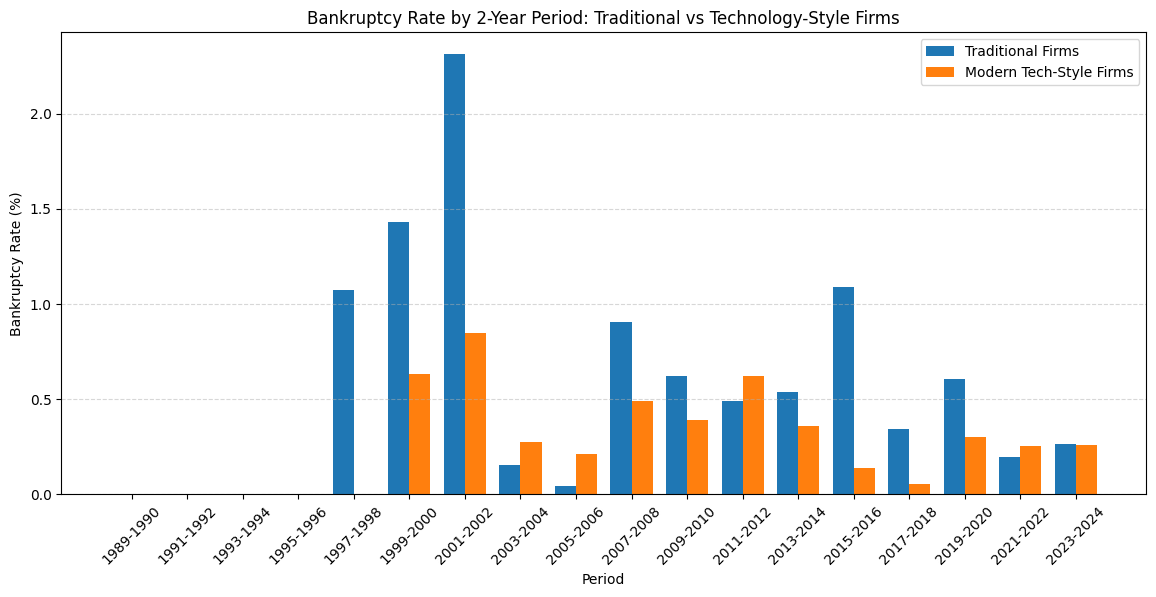

Saved to: C:\Users\Triguboff\Dev\Final\results\bankruptcy_rate_plots\bankruptcy_rate_2year_traditional_vs_tech.png


In [161]:
#  Descriptive Bankruptcy Rate Plots

df_plot = regime_df.copy()
df_plot["year"] = pd.to_datetime(df_plot["date"]).dt.year
df_plot = df_plot[df_plot["modern_failure_regime_raw_lag1"].notna()].copy()

start_year = int(df_plot["year"].min())

df_plot["period_start"] = start_year + 2 * ((df_plot["year"] - start_year) // 2)
df_plot["period_end"] = df_plot["period_start"] + 1
df_plot["period_label"] = (
    df_plot["period_start"].astype(str) + "-" + df_plot["period_end"].astype(str)
)

df_plot["regime_label"] = np.where(
    df_plot["modern_failure_regime_raw_lag1"] == 1,
    "Modern Tech-Style Firms",
    "Traditional Firms"
)

candidate_targets = [
    "target_failure",
    "target_bankruptcy",
    "failure",
    "bankruptcy_event",
    "bankruptcy_within_12m",
    "failure_within_12m"
]

target_col = next((c for c in candidate_targets if c in df_plot.columns), None)

if target_col is None:
    raise KeyError(
        "Could not find bankruptcy target column. "
        "Run: print(df_plot.columns.tolist()) to inspect available columns."
    )

print("Using target column:", target_col)

periodic = df_plot.groupby(
    ["period_start", "period_end", "period_label", "regime_label"],
    as_index=False
).agg(
    total_firms=("permno", "count"),
    bankrupt_firms=(target_col, "sum")
)

periodic["failure_rate_pct"] = (
    periodic["bankrupt_firms"] / periodic["total_firms"]
) * 100

pivot_plot = periodic.pivot(
    index="period_label",
    columns="regime_label",
    values="failure_rate_pct"
).fillna(0)

x = np.arange(len(pivot_plot.index))
width = 0.38

plt.figure(figsize=(14, 6))

if "Traditional Firms" in pivot_plot.columns:
    plt.bar(x - width/2, pivot_plot["Traditional Firms"], width=width, label="Traditional Firms")

if "Modern Tech-Style Firms" in pivot_plot.columns:
    plt.bar(x + width/2, pivot_plot["Modern Tech-Style Firms"], width=width, label="Modern Tech-Style Firms")

plt.xticks(x, pivot_plot.index, rotation=45)
plt.xlabel("Period")
plt.ylabel("Bankruptcy Rate (%)")
plt.title("Bankruptcy Rate by 2-Year Period: Traditional vs Technology-Style Firms")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

bankruptcy_rate_plots_dir = RESULTS_DIR / "bankruptcy_rate_plots"
bankruptcy_rate_plots_dir.mkdir(parents=True, exist_ok=True)

plot_file = bankruptcy_rate_plots_dir / "bankruptcy_rate_2year_traditional_vs_tech.png"
plt.savefig(plot_file, bbox_inches="tight", dpi=300)

plt.show()

print("Saved to:", plot_file)


In [162]:
# Pipeline Step 44C. Compare Combined Traditional-vs-Tech Feature Set

traditional_vs_tech_results, tech_nn_test_proba = run_feature_set_experiment(
    X_train=tech_extended_panel["X_train"],
    y_train=tech_extended_panel["y_train"],
    X_val=tech_extended_panel["X_val"],
    y_val=tech_extended_panel["y_val"],
    X_test=tech_extended_panel["X_test"],
    y_test=tech_extended_panel["y_test"],
    feature_set_name="Traditional_vs_Tech",
    min_recall=0.50,
)

traditional_vs_tech_results = traditional_vs_tech_results[
    [
        "feature_set",
        "model",
        "roc_auc",
        "pr_auc",
        "recall",
        "precision",
        "top_decile_capture",
        "threshold",
        "positives",
        "n_obs",
    ]
].sort_values(["feature_set", "pr_auc"], ascending=[True, False])

traditional_vs_tech_results = traditional_vs_tech_results.round({
    "roc_auc": 4,
    "pr_auc": 4,
    "recall": 4,
    "precision": 4,
    "top_decile_capture": 4,
    "threshold": 4,
})

print("\nTraditional vs Tech results:\n")
display(traditional_vs_tech_results)


FEATURE-SET EXPERIMENT - Traditional_vs_Tech
Train pos=892  neg=144561  spw=162.06
    [diag] n=112,385  pos=409  AUC=0.741  AUC_flipped=0.259  PR-AUC=0.0127  proba_mean=0.0157  proba_std=0.0367

Random Forest
ROC-AUC:            0.7412
PR-AUC:             0.0127
Recall:             0.5844
Precision:          0.0086
Top decile capture: 0.3839
Threshold:          0.01
Positives:          409
Observations:       112,385
    [diag] n=112,385  pos=409  AUC=0.751  AUC_flipped=0.249  PR-AUC=0.0250  proba_mean=0.3937  proba_std=0.1192
XGBoost best iter: 27

XGBoost
ROC-AUC:            0.7506
PR-AUC:             0.0250
Recall:             0.6088
Precision:          0.0095
Top decile capture: 0.4034
Threshold:          0.48
Positives:          409
Observations:       112,385
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 892, number of negative: 144561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead o

,feature_set,model,roc_auc,pr_auc,recall,precision,top_decile_capture,threshold,positives,n_obs
1,Traditional_vs_Tech,XGBoost,0.7506,0.0250,0.6088,0.0095,0.4034,0.4802,409,112385
2,Traditional_vs_Tech,LightGBM,0.7578,0.0175,0.6455,0.0101,0.3521,0.1238,409,112385
3,Traditional_vs_Tech,Neural Network,0.7461,0.0152,0.5990,0.0090,0.4572,0.5594,409,112385
0,Traditional_vs_Tech,Random Forest,0.7412,0.0127,0.5844,0.0086,0.3839,0.0149,409,112385


In [163]:
# Memory cleanup after Step 43C
#
# Releases Python objects from the previous training block and clears the
# TensorFlow / Keras backend graph + cached tensors. Cheap; prevents the
# kernel from creeping toward OOM across long sessions.

gc.collect()
try:
    tf.keras.backend.clear_session()
except Exception:
    pass
print("Memory cleanup done.")


Memory cleanup done.


In [164]:
# Save Traditional vs Tech results

TRADITIONAL_VS_TECH_DIR = RESULTS_DIR / "traditional_vs_tech_results"
TRADITIONAL_VS_TECH_DIR.mkdir(parents=True, exist_ok=True)

extended_file_csv  = TRADITIONAL_VS_TECH_DIR / "traditional_vs_tech_results.csv"
extended_file_xlsx = TRADITIONAL_VS_TECH_DIR / "traditional_vs_tech_results.xlsx"

traditional_vs_tech_results.to_csv(extended_file_csv, index=False)

with pd.ExcelWriter(extended_file_xlsx) as writer:
    traditional_vs_tech_results.to_excel(
        writer,
        sheet_name="traditional_vs_tech",
        index=False
    )

print("Saved Traditional vs Tech results:")
print(extended_file_csv)
print(extended_file_xlsx)


Saved Traditional vs Tech results:
C:\Users\Triguboff\Dev\Final\results\traditional_vs_tech_results\traditional_vs_tech_results.csv
C:\Users\Triguboff\Dev\Final\results\traditional_vs_tech_results\traditional_vs_tech_results.xlsx


## Pipeline Step 45. Cost-Sensitive Threshold Analysis: Combined Neural Network

This final extension applies a cost-sensitive evaluation to the base Combined Neural Network configuration. In bankruptcy prediction, the cost of a false negative (FN) is economically asymmetric because failing to identify a distressed firm is generally more serious than incorrectly flagging a solvent firm. Rather than retraining the model, this step evaluates alternative probability thresholds and assigns a higher cost to missed bankruptcies.

The analysis reports recall, precision, false negatives, false positives, and total expected misclassification cost. The preferred threshold is the one that minimises the cost function:

Cost = (False Positives × Cost_FP) + (False Negatives × Cost_FN)

This provides a practical way to assess whether lowering the classification threshold improves bankruptcy capture in a rare-event setting.

In [165]:
print("PROJECT_ROOT =", PROJECT_ROOT)
print("RESULTS_DIR  =", RESULTS_DIR)
print("Predictions =", RESULTS_DIR / "predictions")
print("Exists?     =", (RESULTS_DIR / "predictions").exists())

PROJECT_ROOT = C:\Users\Triguboff\Dev\Final
RESULTS_DIR  = C:\Users\Triguboff\Dev\Final\results
Predictions = C:\Users\Triguboff\Dev\Final\results\predictions
Exists?     = True


In [166]:
# Pipeline Step 45B. Cost Sensitivity Analysis 

print("RUNNING COST SENSITIVITY ANALYSIS")

COST_FP = 1
cost_scenarios = [10, 50, 100, 250, 500, 1000]

pred_file = RESULTS_DIR / "predictions" / "combined_nn_base_test_predictions.csv"

if not pred_file.exists():
    raise FileNotFoundError(
        "Required Combined NN prediction file is missing:\n"
        f"  {pred_file}\n\n"
        "Step 45B depends on the base Combined neural-network test predictions. "
        "Re-run Pipeline Step 32C.2 first. Step 32C.2 creates "
        "'results/predictions/combined_nn_base_test_predictions.csv'."
    )

print(f"Loading prediction file: {pred_file}")
pred_df = pd.read_csv(pred_file)

y_test = pred_df["y_test"].astype(int).to_numpy()
y_proba = pred_df["y_proba"].astype(float).to_numpy()

thresholds = [0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]

rows = []

for cost_fn in cost_scenarios:
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        total_cost = (COST_FP * fp) + (cost_fn * fn)

        rows.append({
            "cost_fn": cost_fn,
            "threshold": threshold,
            "total_cost": total_cost,
            "false_negatives": fn,
            "false_positives": fp,
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "flag_rate": y_pred.mean()
        })

df_cost_sensitivity = pd.DataFrame(rows)

best_thresholds = df_cost_sensitivity.sort_values(
    ["cost_fn", "total_cost"]
).groupby("cost_fn").head(1)

print("\nBest threshold by cost scenario:")
display(best_thresholds)

RUNNING COST SENSITIVITY ANALYSIS
Loading prediction file: C:\Users\Triguboff\Dev\Final\results\predictions\combined_nn_base_test_predictions.csv

Best threshold by cost scenario:


,cost_fn,threshold,total_cost,false_negatives,false_positives,recall,precision,flag_rate
0,10,0.50,33836,158,32256,0.613692,0.007721,0.289247
7,50,0.50,40156,158,32256,0.613692,0.007721,0.289247
14,100,0.50,48056,158,32256,0.613692,0.007721,0.289247
21,250,0.50,71756,158,32256,0.613692,0.007721,0.289247
30,500,0.20,98044,71,62544,0.826406,0.005375,0.559523
40,1000,0.02,107669,16,91669,0.960880,0.004269,0.819166


In [167]:
# Create summary table

summary_table = best_thresholds.copy()

summary_table = summary_table.rename(columns={
    "cost_fn": "False Negative Cost",
    "threshold": "Optimal Threshold",
    "total_cost": "Total Cost",
    "false_negatives": "False Negatives",
    "false_positives": "False Positives",
    "recall": "Recall",
    "precision": "Precision",
    "flag_rate": "Flag Rate"
})

summary_table = summary_table.round({
    "Optimal Threshold": 3,
    "Recall": 3,
    "Precision": 6,
    "Flag Rate": 3
})

display(summary_table)

,False Negative Cost,Optimal Threshold,Total Cost,False Negatives,False Positives,Recall,Precision,Flag Rate
0,10,0.50,33836,158,32256,0.614,0.007721,0.289
7,50,0.50,40156,158,32256,0.614,0.007721,0.289
14,100,0.50,48056,158,32256,0.614,0.007721,0.289
21,250,0.50,71756,158,32256,0.614,0.007721,0.289
30,500,0.20,98044,71,62544,0.826,0.005375,0.560
40,1000,0.02,107669,16,91669,0.961,0.004269,0.819


In [168]:

highlight_table = summary_table[
    ["False Negative Cost", "Optimal Threshold", "Total Cost"]
]

display(highlight_table)

# Save for Word / submission
OUTPUT_DIR = RESULTS_DIR / "cost_sensitive"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

file_path = OUTPUT_DIR / "threshold_sensitivity_summary.xlsx"
highlight_table.to_excel(file_path, index=False)

print("\nSaved summary table to:")
print(file_path)

,False Negative Cost,Optimal Threshold,Total Cost
0,10,0.50,33836
7,50,0.50,40156
14,100,0.50,48056
21,250,0.50,71756
30,500,0.20,98044
40,1000,0.02,107669



Saved summary table to:
C:\Users\Triguboff\Dev\Final\results\cost_sensitive\threshold_sensitivity_summary.xlsx


In [169]:
# Pipeline Step 40B.9. Re-fit best tuned NN per feature set + cache test_proba.
#
# The tuning loop in Step 40B.3 captures metrics but discards the trained
# models. To get bootstrap CIs on the tuned NN (Step 46) we re-fit the
# best-PR-AUC config per feature set here and stash the test_proba in a
# `tuned_nn_probas` dict that the next cell picks up.  Each re-fit is one
# NN training run, typically 30 to 90 seconds depending on epochs.

if "nn_tuning_results_all" not in globals():
    raise NameError("nn_tuning_results_all not found - run Step 40B.3 first.")
if "feature_panels" not in globals():
    raise NameError("feature_panels not found - run Step 26A first.")

tuned_nn_probas      = {}
tuned_nn_thresholds  = {}
tuned_nn_metrics     = {}

for fs in ["Barboza", "Shumway", "Combined"]:
    if fs not in nn_tuning_results_all:
        print(f"  {fs}: no tuning results - skipping")
        continue

    tuning_df = nn_tuning_results_all[fs].sort_values("pr_auc", ascending=False)
    best_row  = tuning_df.iloc[0].to_dict()

    cfg = {
        "hidden_units_1": int(best_row.get("hidden_units_1", 64)),
        "hidden_units_2": int(best_row.get("hidden_units_2", 32)),
        "dropout_rate":   float(best_row.get("dropout_rate", 0.20)),
        "learning_rate":  float(best_row.get("learning_rate", 0.001)),
        "epochs":         int(best_row.get("epochs", 200)),
        "batch_size":     int(best_row.get("batch_size", 512)),
        "monitor":        "val_pr_auc",
        "patience":       15,
        "verbose":        0,
        "random_state":   42,
    }
    print(f"\n{fs}: re-fitting tuned NN with {cfg}")

    panel = feature_panels[fs]
    X_train, X_val, X_test, _ = _clean_panel_matrices(
        panel["X_train"], panel["X_val"], panel["X_test"]
    )
    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_train_n = scaler.fit_transform(imputer.fit_transform(X_train))
    X_val_n   = scaler.transform(imputer.transform(X_val))
    X_test_n  = scaler.transform(imputer.transform(X_test))

    model, _ = train_nn_tunable(
        X_train=X_train_n, y_train=np.asarray(panel["y_train"]).astype(int),
        X_val=X_val_n,     y_val=np.asarray(panel["y_val"]).astype(int),
        config=cfg,
    )

    val_proba  = model.predict(X_val_n, verbose=0).ravel()
    threshold  = tune_threshold_for_recall(panel["y_val"], val_proba, min_recall=0.50)
    test_proba = model.predict(X_test_n, verbose=0).ravel()
    metrics    = evaluate_predictions(panel["y_test"], test_proba, threshold=threshold)

    tuned_nn_probas[fs]     = test_proba
    tuned_nn_thresholds[fs] = threshold
    tuned_nn_metrics[fs]    = metrics

    print(f"  test PR-AUC={metrics['pr_auc']:.4f}  "
          f"top-decile={metrics['top_decile_capture']:.4f}  "
          f"threshold={threshold:.3f}")

# Append directly to comparison_results_full so Step 46 picks them up.
_added = 0
for fs, proba in tuned_nn_probas.items():
    comparison_results_full.append({
        "feature_set": fs,
        "model":       "Tuned Neural Network",
        "test_proba":  np.asarray(proba).astype(float).ravel(),
        "val_proba":   None,
        "threshold":   tuned_nn_thresholds[fs],
        **tuned_nn_metrics[fs],
    })
    _added += 1

print(f"\nAdded {_added} Tuned Neural Network entries to comparison_results_full.")
print(f"comparison_results_full now has {len(comparison_results_full)} entries.")



Barboza: re-fitting tuned NN with {'hidden_units_1': 128, 'hidden_units_2': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'epochs': 200, 'batch_size': 1024, 'monitor': 'val_pr_auc', 'patience': 15, 'verbose': 0, 'random_state': 42}
    [diag] n=112,385  pos=409  AUC=0.605  AUC_flipped=0.395  PR-AUC=0.0054  proba_mean=0.3403  proba_std=0.2659
  test PR-AUC=0.0054  top-decile=0.1467  threshold=0.470

Shumway: re-fitting tuned NN with {'hidden_units_1': 64, 'hidden_units_2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'epochs': 200, 'batch_size': 512, 'monitor': 'val_pr_auc', 'patience': 15, 'verbose': 0, 'random_state': 42}
    [diag] n=112,385  pos=409  AUC=0.747  AUC_flipped=0.253  PR-AUC=0.0130  proba_mean=0.3667  proba_std=0.2567
  test PR-AUC=0.0130  top-decile=0.4279  threshold=0.559

Combined: re-fitting tuned NN with {'hidden_units_1': 64, 'hidden_units_2': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'epochs': 200, 'batch_size': 512, 'monitor': 'val_pr_auc', 'patien

## Pipeline Step 46. Bootstrap Confidence Intervals

Every metric in the headline comparison table is a point estimate computed on a single test sample of n=113,187 firm-months. With a 0.36% base rate, only ~410 of those rows are positive events, so PR-AUC and top-decile capture have effective sample sizes in the hundreds and carry substantial sampling uncertainty. Two models whose point estimates differ by 1pp may be statistically indistinguishable; conversely, a 5pp difference may be solidly significant. Without confidence intervals there is no way to tell.

We compute confidence intervals using a **paired percentile bootstrap** on the test set. For each of B=1,000 iterations we draw a bootstrap sample of indices with replacement from `range(n_test)`, then recompute the metric using the **same indices** for the true labels and for every model's predicted probabilities. Pairing the resample across models within a feature set means the differences between models on a given metric come from the *same* set of firms each iteration; this preserves the cross-model correlation structure that an independent bootstrap would discard. Confidence intervals are reported as the 2.5th and 97.5th percentiles of the B bootstrap statistics (a 95% interval).

Three metrics are bootstrapped: ROC-AUC, PR-AUC, and top-decile capture. Recall, precision, and threshold are not bootstrapped because they depend on the validation-set threshold which would need to be re-tuned in each resample. The random seed is fixed at 42 so re-running produces identical CIs.


In [170]:
# Pipeline Step 46A. Compute bootstrap confidence intervals + save outputs.

import pickle

BOOT_DIR = RESULTS_DIR / "bootstrap"
BOOT_DIR.mkdir(parents=True, exist_ok=True)

# Cache predictions + labels to pickle so they can be re-loaded if the kernel
# is restarted without re-running the modelling pipeline.
with open(BOOT_DIR / "comparison_results_full.pkl", "wb") as _f:
    pickle.dump(comparison_results_full, _f)
_y_tests = {fs: np.asarray(feature_panels[fs]["y_test"]).astype(int).ravel()
            for fs in feature_panels}
with open(BOOT_DIR / "y_tests.pkl", "wb") as _f:
    pickle.dump(_y_tests, _f)
print(f"Cached bootstrap inputs to {BOOT_DIR}")

# ----- Helpers -----
def _top_decile_capture(y_true, y_score, frac=0.10):
    n_top = max(1, int(np.ceil(len(y_score) * frac)))
    order = np.argsort(-y_score, kind="stable")
    n_pos_total = int(y_true.sum())
    if n_pos_total == 0:
        return np.nan
    return float(y_true[order[:n_top]].sum() / n_pos_total)

def _compute_metrics(y_true, y_score):
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return (np.nan, np.nan, np.nan)
    return (
        roc_auc_score(y_true, y_score),
        average_precision_score(y_true, y_score),
        _top_decile_capture(y_true, y_score),
    )

# ----- Bootstrap -----
N_BOOT = 1_000
rng    = np.random.default_rng(SEED)
summary_rows = []

by_fs = {}
for entry in comparison_results_full:
    by_fs.setdefault(entry["feature_set"], []).append(entry)

# Skip feature sets that don't have a y_test in feature_panels
# (Missing-Value Indicator Extension & IBES).
unknown_fs = sorted(set(by_fs) - set(_y_tests))
if unknown_fs:
    print(f"\nSkipping feature sets not in feature_panels: {unknown_fs}")
    print("(these come from extension experiments with custom panels;\n"
          " their CIs aren't part of the headline comparison anyway).")
    for fs in unknown_fs:
        del by_fs[fs]

for fs in sorted(by_fs):
    y = _y_tests[fs]
    n = len(y)
    entries = by_fs[fs]
    print(f"\nBootstrap on {fs} (n={n:,}, models={len(entries)})...")
    probas = np.vstack([np.asarray(e["test_proba"]).astype(float).ravel() for e in entries])
    boot_roc = np.empty((len(entries), N_BOOT))
    boot_pr  = np.empty((len(entries), N_BOOT))
    boot_top = np.empty((len(entries), N_BOOT))
    for b in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        y_b = y[idx]
        for m in range(len(entries)):
            roc, pr, top = _compute_metrics(y_b, probas[m, idx])
            boot_roc[m, b] = roc
            boot_pr[m, b]  = pr
            boot_top[m, b] = top
        if (b + 1) % 200 == 0:
            print(f"  {b+1}/{N_BOOT}")
    for m, e in enumerate(entries):
        for mn, dist in [("roc_auc", boot_roc[m]),
                         ("pr_auc",  boot_pr[m]),
                         ("top_decile_capture", boot_top[m])]:
            valid = dist[~np.isnan(dist)]
            if valid.size == 0:
                lo = med = hi = np.nan
            else:
                lo  = float(np.percentile(valid, 2.5))
                med = float(np.percentile(valid, 50))
                hi  = float(np.percentile(valid, 97.5))
            summary_rows.append({
                "feature_set":    fs,
                "model":          e["model"],
                "metric":         mn,
                "point_estimate": round(float(e.get(mn, np.nan)), 4),
                "boot_median":    round(med, 4),
                "ci_low":         round(lo,  4),
                "ci_high":        round(hi,  4),
                "ci_width":       round(hi - lo, 4),
                "n_boot":         int(valid.size),
            })

bootstrap_ci_df = pd.DataFrame(summary_rows)
bootstrap_csv   = BOOT_DIR / "bootstrap_ci_summary.csv"
bootstrap_ci_df.to_csv(bootstrap_csv, index=False)
print(f"\nSaved: {bootstrap_csv}")

# Headline pivot (point [low, high])
_pivot = (
    bootstrap_ci_df.assign(
        ci_str=lambda d: (
            d["point_estimate"].map(lambda x: f"{x:.3f}") + " ["
            + d["ci_low"].map(lambda x: f"{x:.3f}") + ", "
            + d["ci_high"].map(lambda x: f"{x:.3f}") + "]"
        )
    )
    .pivot_table(
        index=["feature_set", "model"],
        columns="metric",
        values="ci_str",
        aggfunc="first",
    )
)
print("\nHeadline table (point [95% CI]):")
display(_pivot)

Cached bootstrap inputs to C:\Users\Triguboff\Dev\Final\results\bootstrap

Skipping feature sets not in feature_panels: ['Combined + Missing Indicators', 'Traditional_vs_Tech']
(these come from extension experiments with custom panels;
 their CIs aren't part of the headline comparison anyway).

Bootstrap on Barboza (n=112,385, models=5)...
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000

Bootstrap on Combined (n=112,385, models=5)...
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000

Bootstrap on Shumway (n=112,385, models=5)...
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000

Saved: C:\Users\Triguboff\Dev\Final\results\bootstrap\bootstrap_ci_summary.csv

Headline table (point [95% CI]):


metric                                          pr_auc               roc_auc    top_decile_capture
feature_set model                                                                                 
Barboza     LightGBM              0.019 [0.014, 0.029]  0.755 [0.730, 0.780]  0.389 [0.340, 0.435]
            Neural Network        0.005 [0.004, 0.007]  0.569 [0.542, 0.599]  0.147 [0.109, 0.185]
            Random Forest         0.009 [0.007, 0.010]  0.684 [0.658, 0.710]  0.293 [0.252, 0.340]
            Tuned Neural Network  0.005 [0.005, 0.007]  0.605 [0.577, 0.635]  0.147 [0.111, 0.181]
            XGBoost               0.016 [0.013, 0.020]  0.739 [0.712, 0.766]  0.403 [0.354, 0.457]
Combined    LightGBM              0.016 [0.012, 0.021]  0.733 [0.707, 0.761]  0.357 [0.317, 0.405]
            Neural Network        0.012 [0.010, 0.015]  0.725 [0.697, 0.751]  0.384 [0.333, 0.432]
            Random Forest         0.012 [0.010, 0.014]  0.751 [0.726, 0.777]  0.396 [0.352, 0.447]
            Tuned Neural Network  0.013 [0.010, 0.016]  0.721 [0.691, 0.749]  0.381 [0.333, 0.433]
            XGBoost               0.022 [0.017, 0.031]  0.757 [0.731, 0.784]  0.350 [0.307, 0.400]
Shumway     LightGBM              0.012 [0.010, 0.015]  0.748 [0.726, 0.771]  0.337 [0.290, 0.383]
            Neural Network        0.012 [0.010, 0.015]  0.747 [0.721, 0.773]  0.403 [0.357, 0.448]
            Random Forest         0.009 [0.008, 0.011]  0.697 [0.670, 0.722]  0.306 [0.264, 0.349]
            Tuned Neural Network  0.013 [0.011, 0.016]  0.747 [0.720, 0.772]  0.428 [0.383, 0.473]
            XGBoost               0.014 [0.011, 0.019]  0.764 [0.741, 0.786]  0.359 [0.316, 0.408]

### Step 46 interpretation - reading the confidence intervals





## Pipeline Step 47. Close WRDS Connection

In [171]:
# Pipeline Step 47A. Close WRDS Connection
print(f"WRDS connection closed at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}.")



WRDS connection closed at 2026-08-24 22:25:59.
